In [1]:
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, mean_absolute_error, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import joblib
from sklearn.svm import SVC
from xgboost import XGBClassifier
import warnings

In [17]:
DISPOSITIVOS = ['dish washer', 'kettle', 'microwave', 'washing machine', 'fridge']
IMAGENS = ['gasf', 'gadf', 'mtf', 'rp', 'tbg']
RUNS = ['0', '1', '2', '3', '4']#, '5', '6', '7', '8', '9']
MODELS = ['MLP', 'XGBoost', 'SVM']

iterables = [DISPOSITIVOS,IMAGENS, MODELS]

index = pd.MultiIndex.from_product(iterables, names=['dispositivo','imagem','modelo'])

dados_vazios = [[[] for _ in ['f1_score', 'accuracy']] for _ in range(len(index))]

resultados = pd.DataFrame(dados_vazios, columns=['f1_score', 'accuracy'], index=index)
resultados

f1_score accuracy
dispositivo imagem modelo                   
dish washer gasf   MLP           []       []
                   XGBoost       []       []
                   SVM           []       []
            gadf   MLP           []       []
                   XGBoost       []       []
...                             ...      ...
fridge      rp     XGBoost       []       []
                   SVM           []       []
            tbg    MLP           []       []
                   XGBoost       []       []
                   SVM           []       []

[75 rows x 2 columns]

In [18]:
def test_data_eval(model, X_test, y_test, dispositivo, imagem, tipo_modelo, execucao):
    print(dispositivo)
    print(imagem)
    print(tipo_modelo)
    print(execucao + '\n')

    prediction = model.predict(X_test)

    y_pred = []
    for p in prediction:
        if p > 0.5:
            y_pred.append(True)
        else:
            y_pred.append(False)

    inty_test = []
    inty_pred = []
    for test,pred in zip(y_test,y_pred):
        inty_test.append(int(test))
        inty_pred.append(int(pred))

    f1 = f1_score(y_test, y_pred, average='macro')
    accuracy = accuracy_score(inty_test, inty_pred)

    print(f"f1_score: {f1}")
    print(f"accuracy: {accuracy}")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    display = ConfusionMatrixDisplay(confusion_matrix=cm)
    display.plot(colorbar=False)
    plt.show()

    lista_f1_atual = resultados.loc[(dispositivo, imagem, tipo_modelo), 'f1_score']
    resultados.at[(dispositivo, imagem, tipo_modelo), 'f1_score'] = lista_f1_atual + [f1]

    lista_acc_atual = resultados.loc[(dispositivo, imagem, tipo_modelo), 'accuracy']
    resultados.at[(dispositivo, imagem, tipo_modelo), 'accuracy'] = lista_acc_atual + [accuracy]

    
    return y_pred

## Testando modelos com Base de dados teste balanceada

dish washer
gasf
MLP
0

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
f1_score: 0.8699324324324325
accuracy: 0.8701298701298701
              precision    recall  f1-score   support

       False       0.84      0.91      0.88        77
        True       0.90      0.83      0.86        77

    accuracy                           0.87       154
   macro avg       0.87      0.87      0.87       154
weighted avg       0.87      0.87      0.87       154



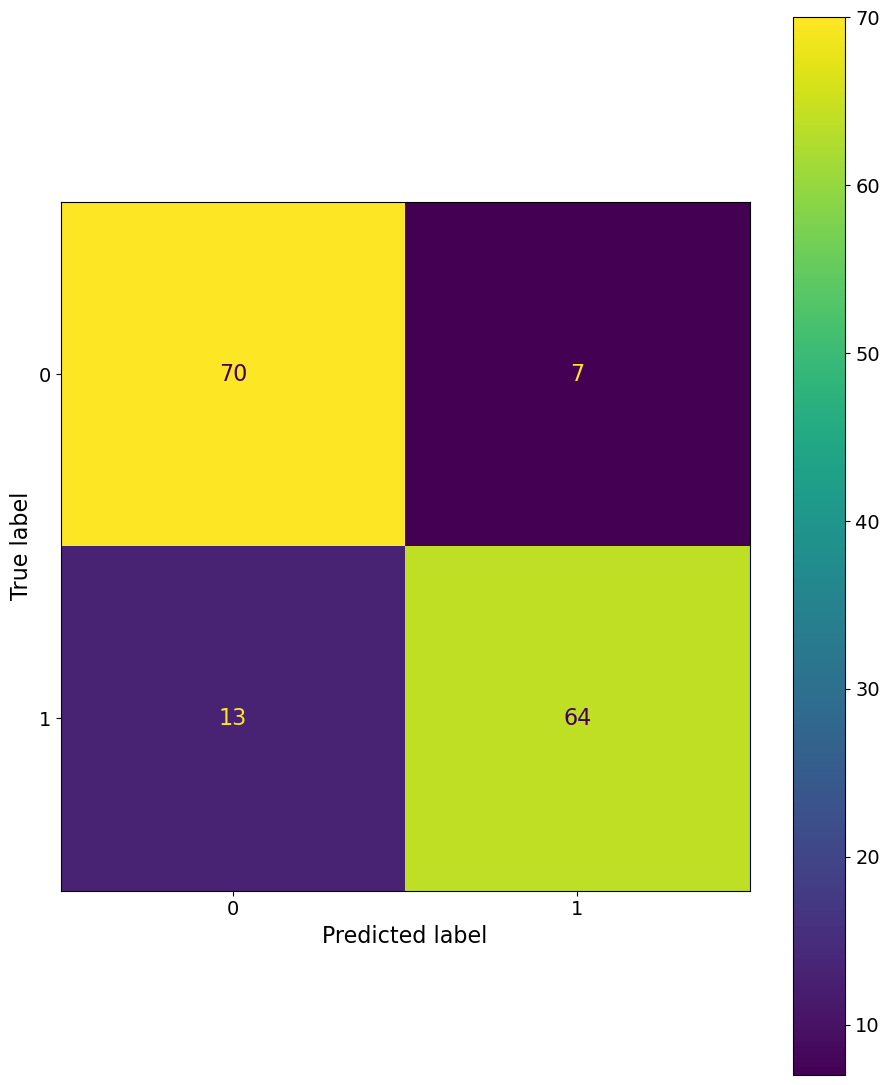

dish washer
gasf
MLP
1

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
f1_score: 0.8234169957956428
accuracy: 0.8246753246753247
              precision    recall  f1-score   support

       False       0.78      0.91      0.84        77
        True       0.89      0.74      0.81        77

    accuracy                           0.82       154
   macro avg       0.83      0.82      0.82       154
weighted avg       0.83      0.82      0.82       154



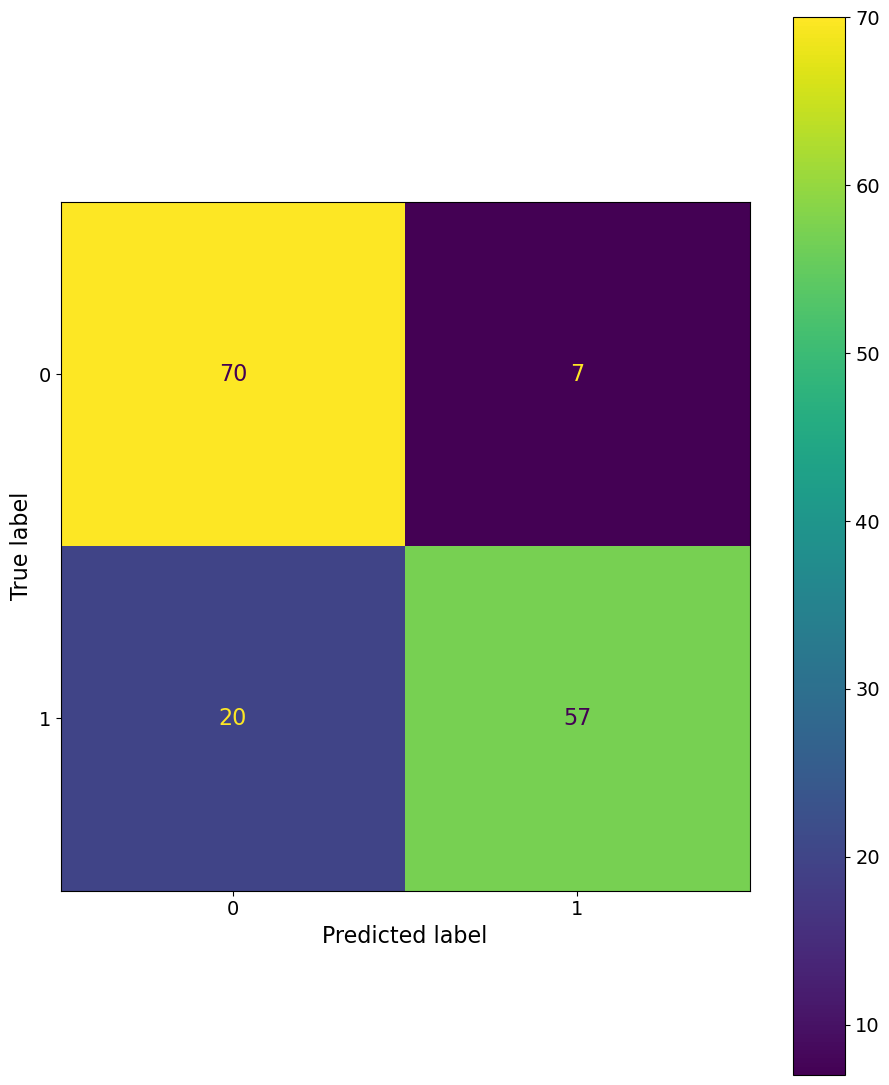

dish washer
gasf
MLP
2

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
f1_score: 0.8018528049408131
accuracy: 0.8051948051948052
              precision    recall  f1-score   support

       False       0.74      0.94      0.83        77
        True       0.91      0.68      0.78        77

    accuracy                           0.81       154
   macro avg       0.83      0.81      0.80       154
weighted avg       0.83      0.81      0.80       154



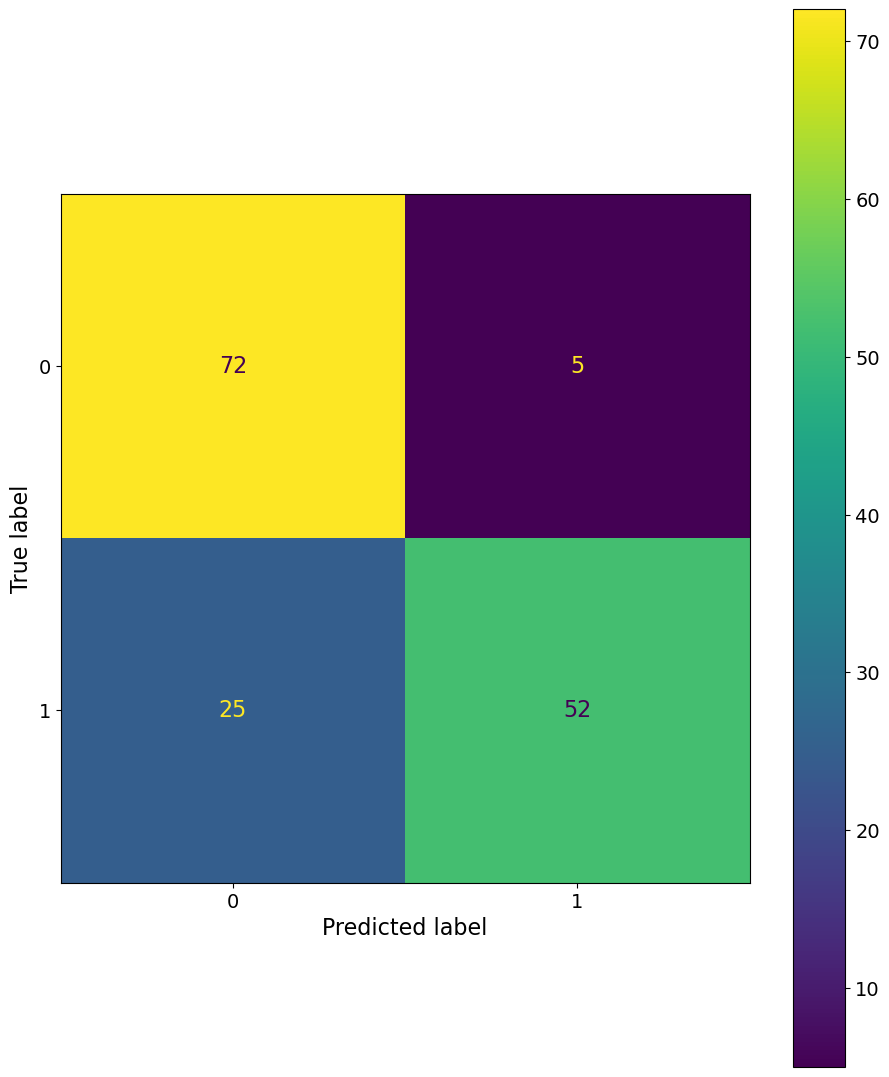

dish washer
gasf
MLP
3

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
f1_score: 0.7570126227208976
accuracy: 0.7662337662337663
              precision    recall  f1-score   support

       False       0.69      0.96      0.80        77
        True       0.94      0.57      0.71        77

    accuracy                           0.77       154
   macro avg       0.81      0.77      0.76       154
weighted avg       0.81      0.77      0.76       154



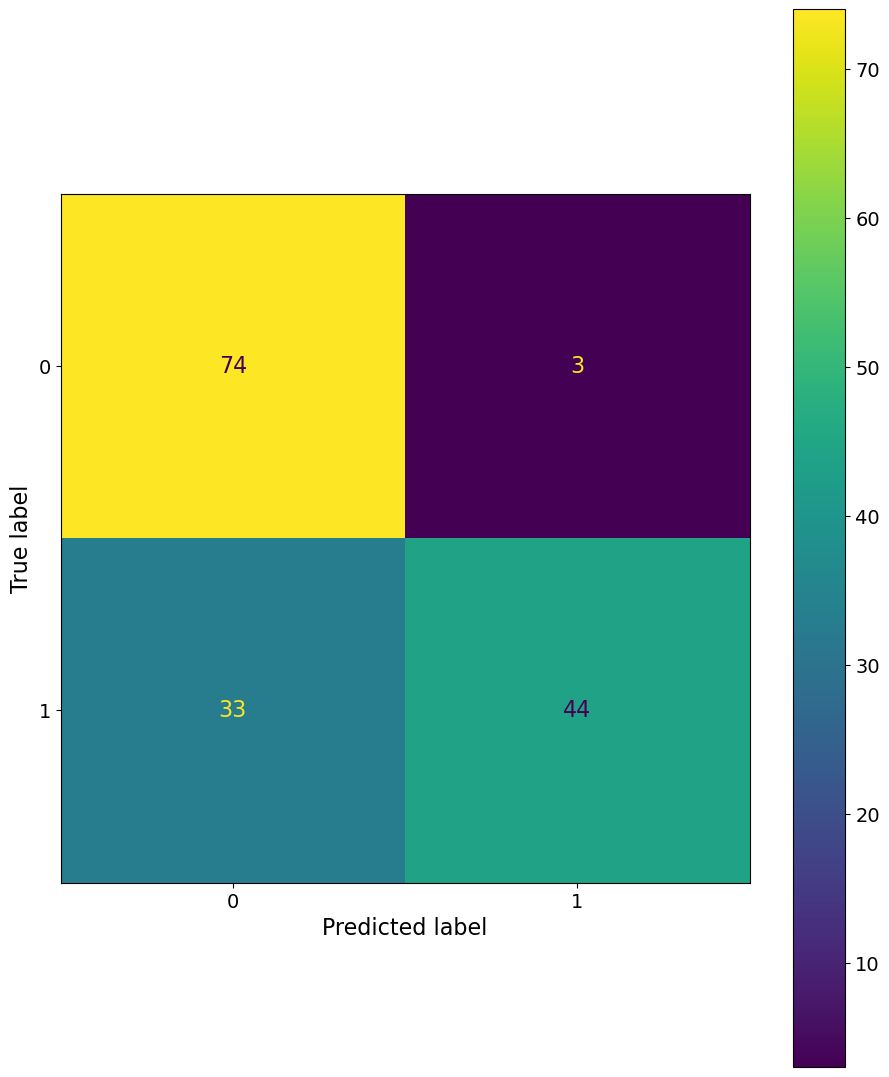

dish washer
gasf
MLP
4

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
f1_score: 0.8368298368298368
accuracy: 0.8376623376623377
              precision    recall  f1-score   support

       False       0.80      0.91      0.85        77
        True       0.89      0.77      0.83        77

    accuracy                           0.84       154
   macro avg       0.84      0.84      0.84       154
weighted avg       0.84      0.84      0.84       154



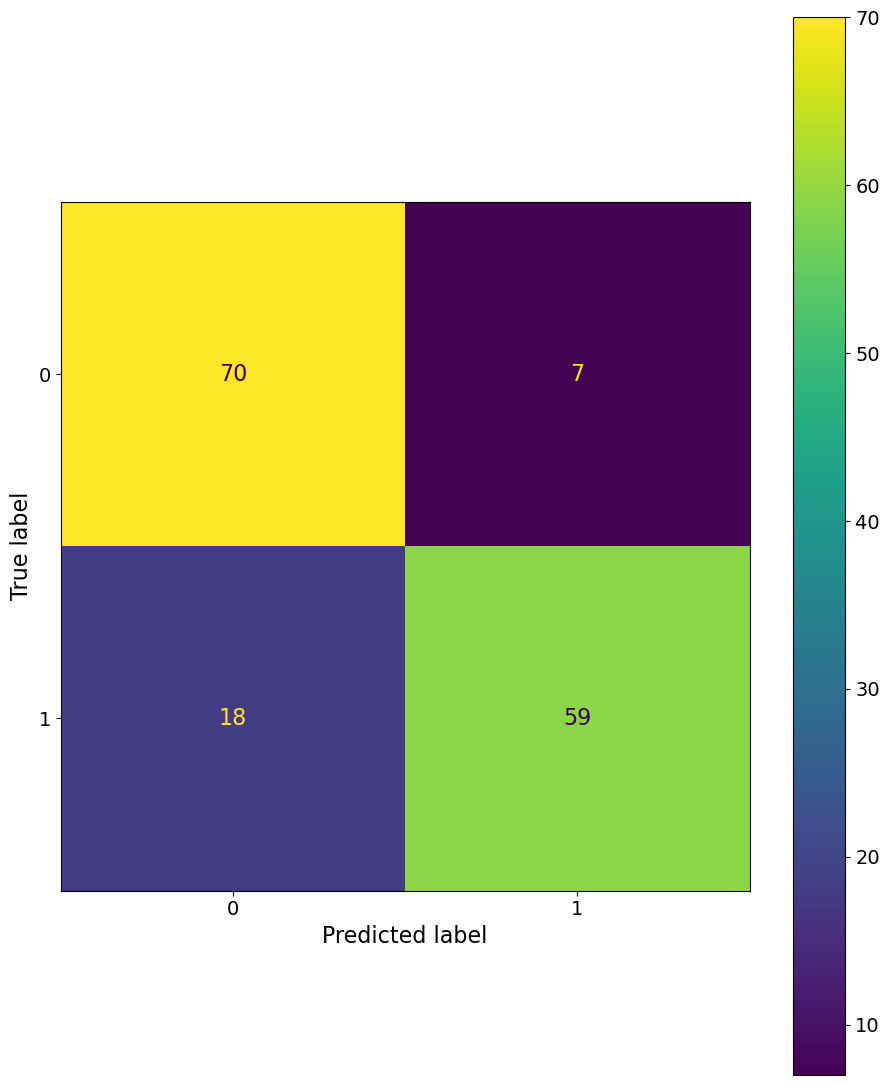

dish washer
gasf
XGBoost
0

f1_score: 0.7629958960328318
accuracy: 0.7662337662337663
              precision    recall  f1-score   support

       False       0.85      0.65      0.74        77
        True       0.72      0.88      0.79        77

    accuracy                           0.77       154
   macro avg       0.78      0.77      0.76       154
weighted avg       0.78      0.77      0.76       154



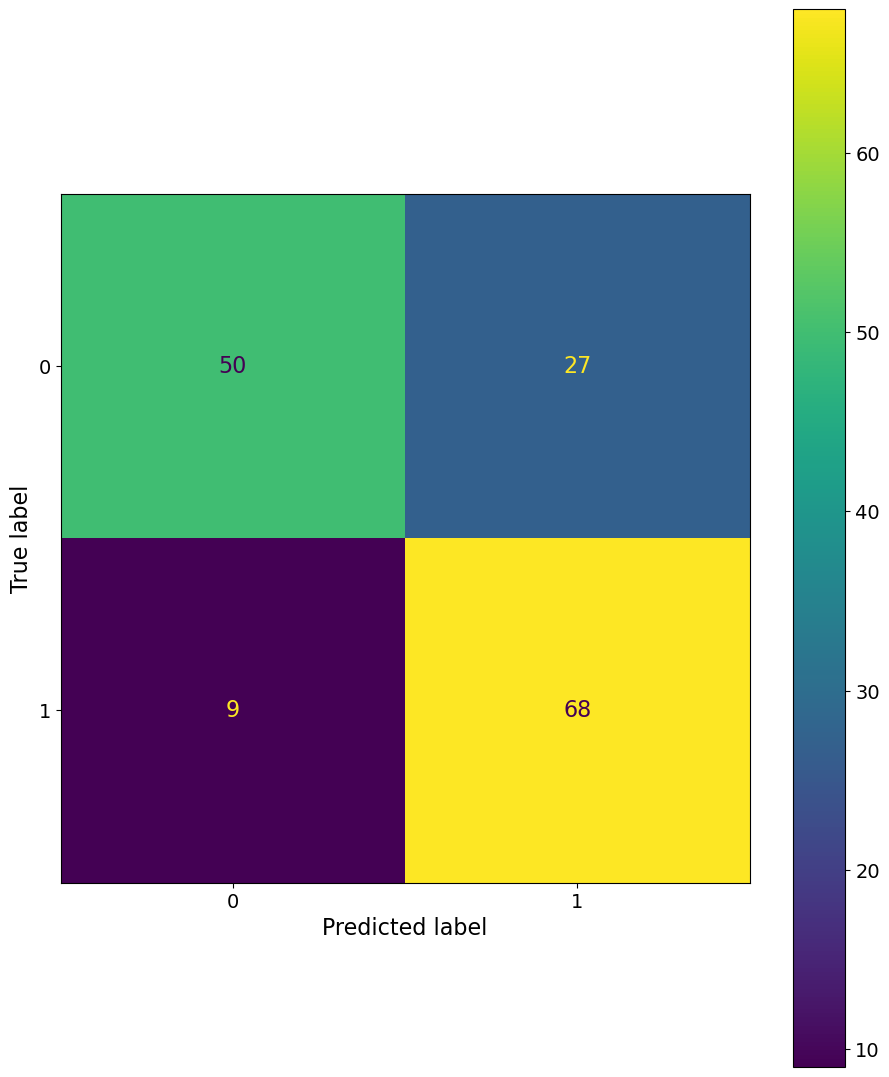

dish washer
gasf
SVM
0

f1_score: 0.7727430555555556
accuracy: 0.7792207792207793
              precision    recall  f1-score   support

       False       0.71      0.95      0.81        77
        True       0.92      0.61      0.73        77

    accuracy                           0.78       154
   macro avg       0.82      0.78      0.77       154
weighted avg       0.82      0.78      0.77       154



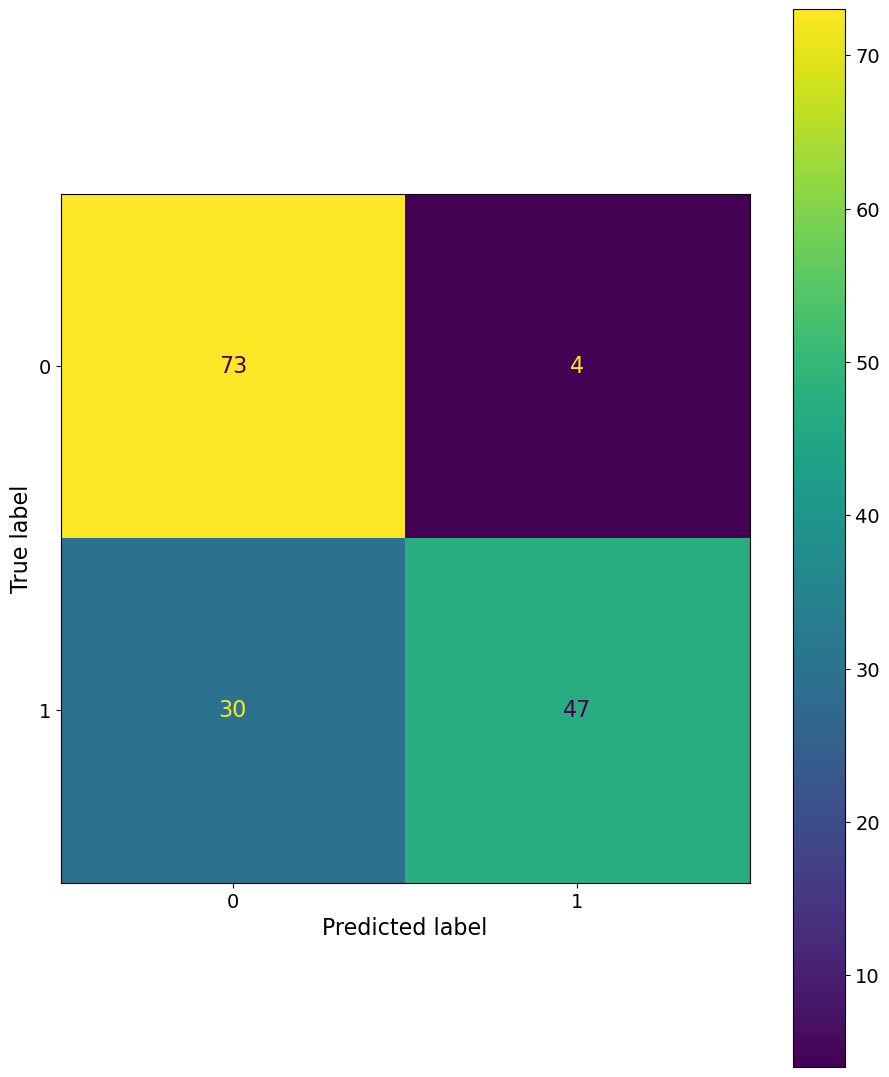

dish washer
gadf
MLP
0

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
f1_score: 0.7567763691467111
accuracy: 0.7597402597402597
              precision    recall  f1-score   support

       False       0.71      0.87      0.78        77
        True       0.83      0.65      0.73        77

    accuracy                           0.76       154
   macro avg       0.77      0.76      0.76       154
weighted avg       0.77      0.76      0.76       154



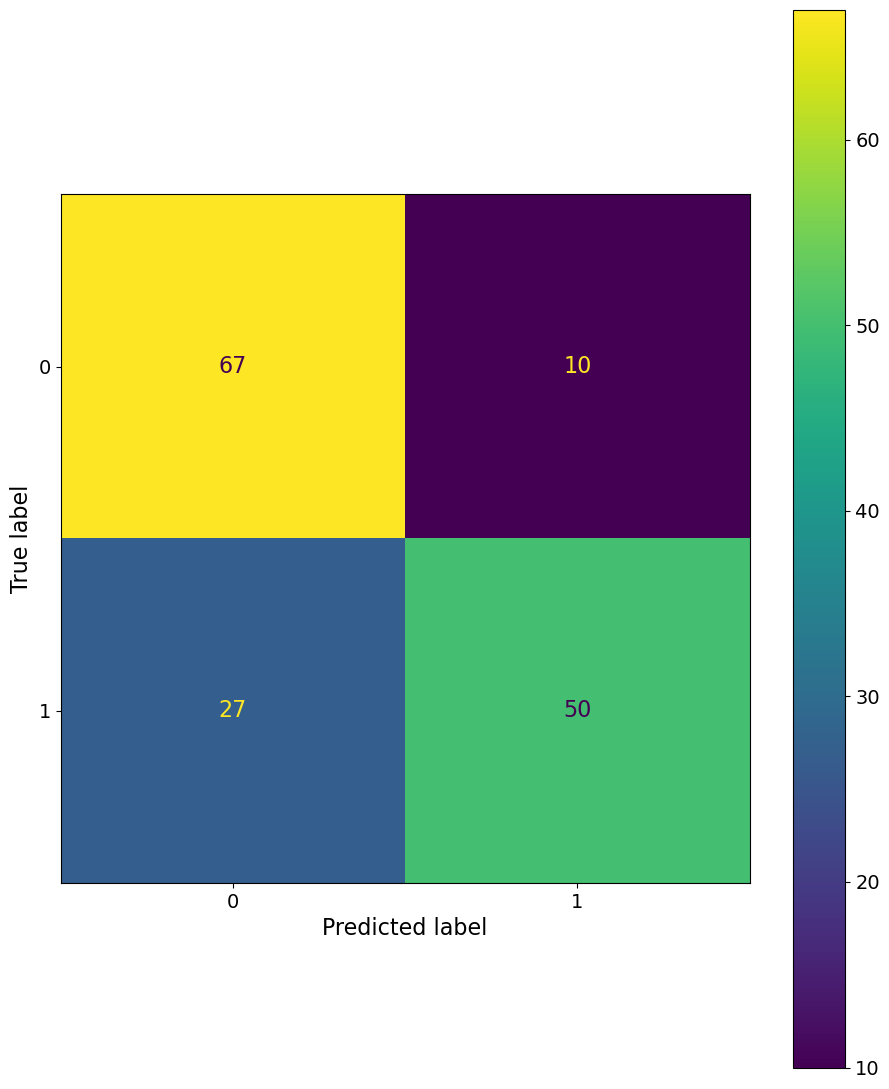

dish washer
gadf
MLP
1

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
f1_score: 0.7225939269171384
accuracy: 0.7272727272727273
              precision    recall  f1-score   support

       False       0.81      0.60      0.69        77
        True       0.68      0.86      0.76        77

    accuracy                           0.73       154
   macro avg       0.74      0.73      0.72       154
weighted avg       0.74      0.73      0.72       154



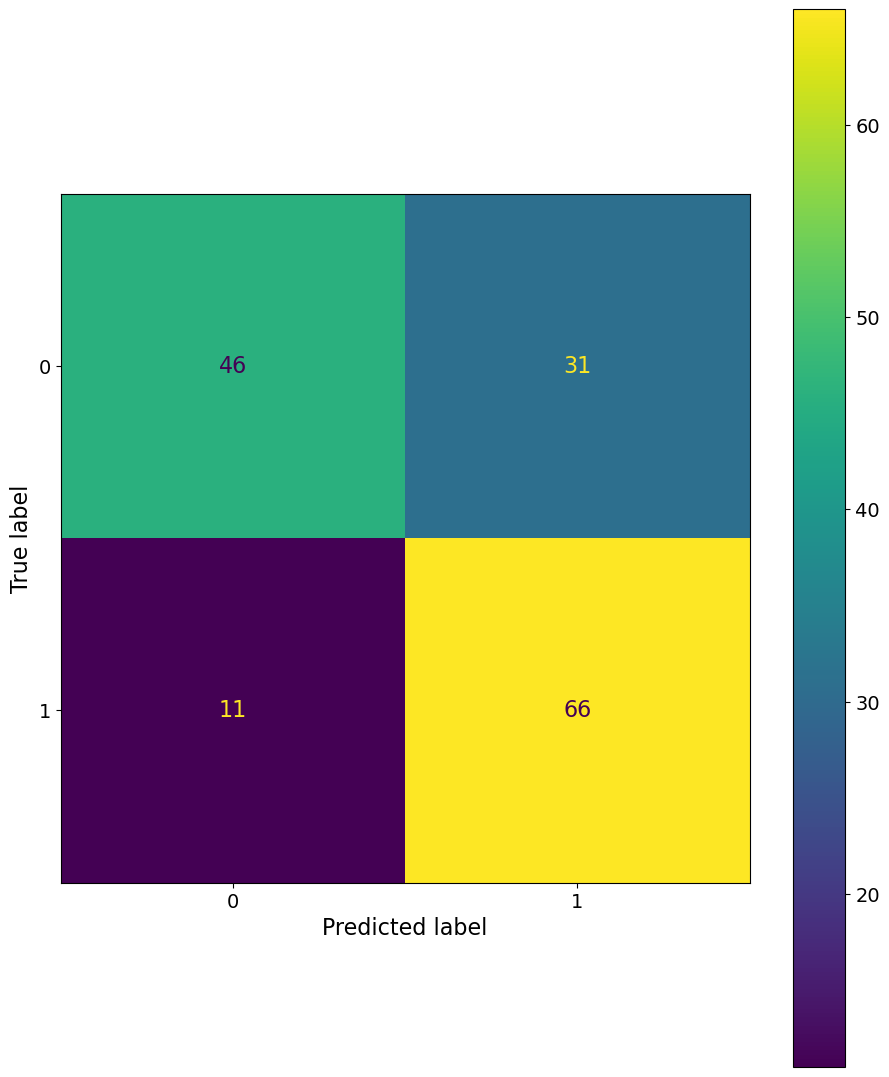

dish washer
gadf
MLP
2

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
f1_score: 0.7705504235664723
accuracy: 0.7727272727272727
              precision    recall  f1-score   support

       False       0.73      0.87      0.79        77
        True       0.84      0.68      0.75        77

    accuracy                           0.77       154
   macro avg       0.78      0.77      0.77       154
weighted avg       0.78      0.77      0.77       154



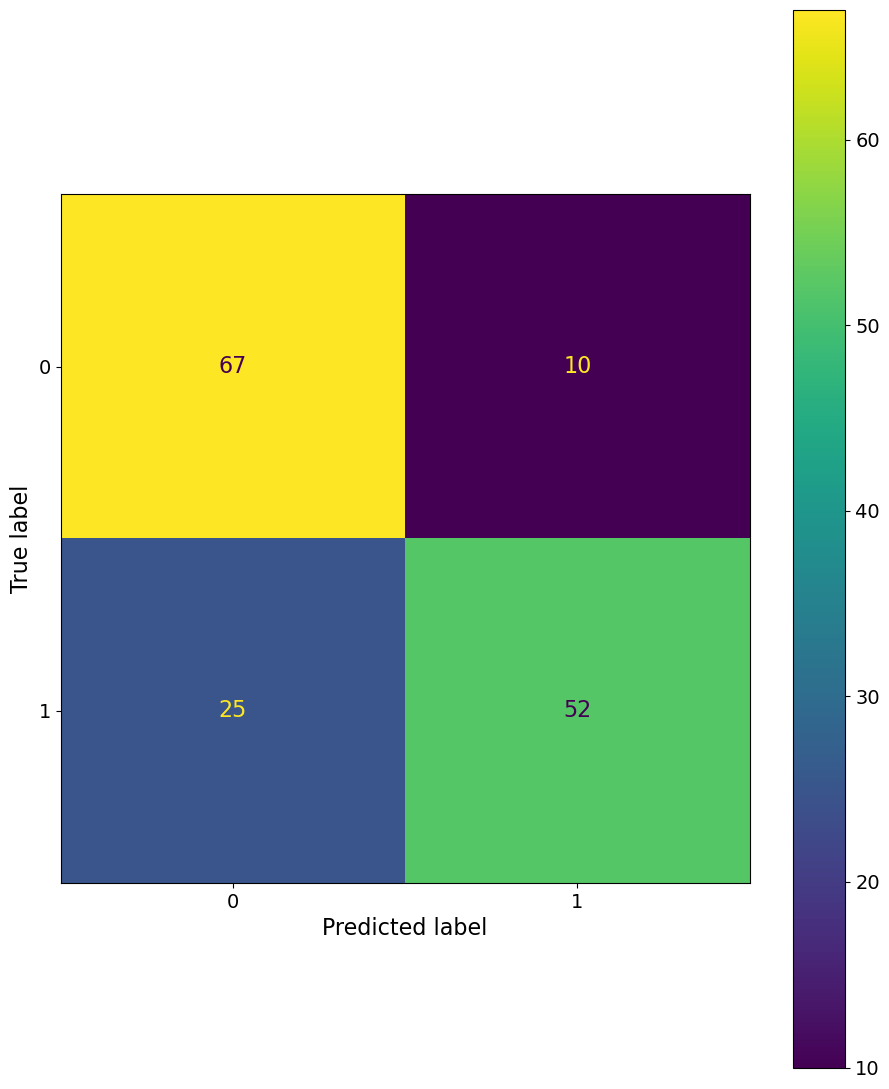

dish washer
gadf
MLP
3

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
f1_score: 0.5459905660377358
accuracy: 0.6103896103896104
              precision    recall  f1-score   support

       False       0.56      0.99      0.72        77
        True       0.95      0.23      0.38        77

    accuracy                           0.61       154
   macro avg       0.76      0.61      0.55       154
weighted avg       0.76      0.61      0.55       154



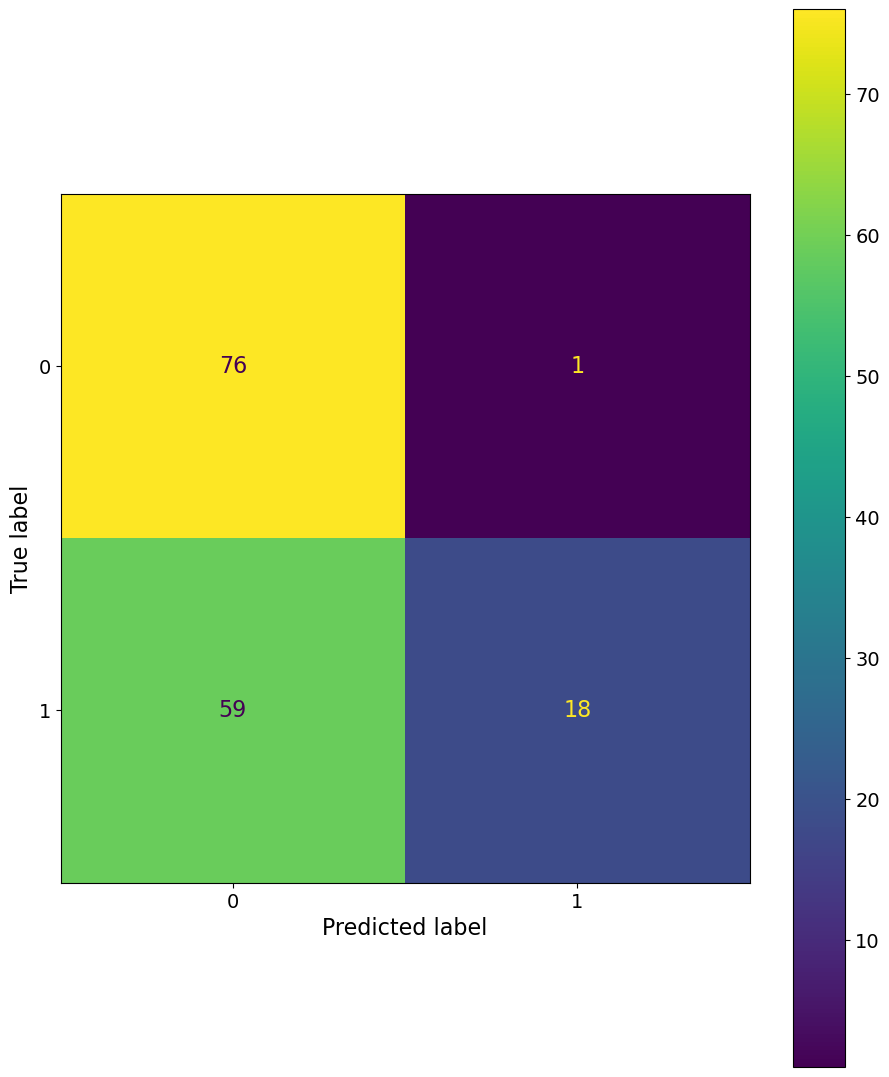

dish washer
gadf
MLP
4

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
f1_score: 0.7761627906976745
accuracy: 0.7792207792207793
              precision    recall  f1-score   support

       False       0.73      0.90      0.80        77
        True       0.86      0.66      0.75        77

    accuracy                           0.78       154
   macro avg       0.80      0.78      0.78       154
weighted avg       0.80      0.78      0.78       154



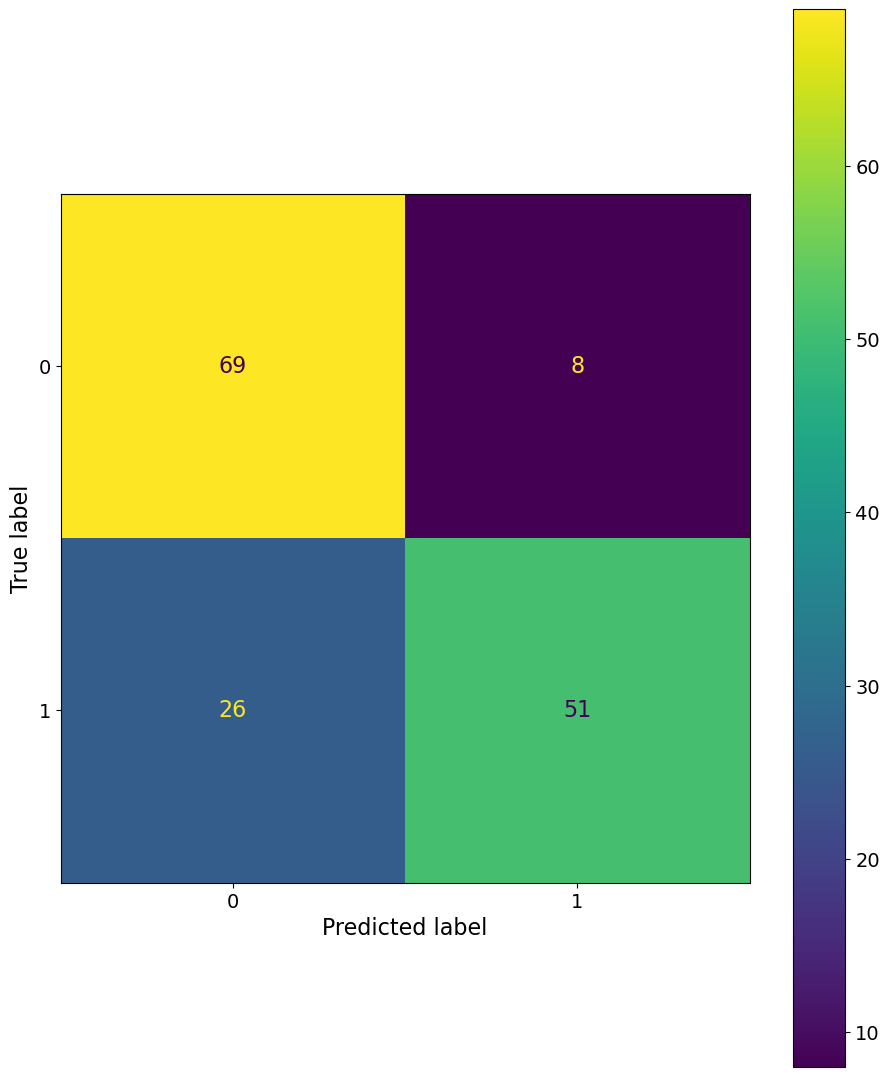

dish washer
gadf
XGBoost
0

f1_score: 0.6373626373626373
accuracy: 0.6493506493506493
              precision    recall  f1-score   support

       False       0.73      0.47      0.57        77
        True       0.61      0.83      0.70        77

    accuracy                           0.65       154
   macro avg       0.67      0.65      0.64       154
weighted avg       0.67      0.65      0.64       154



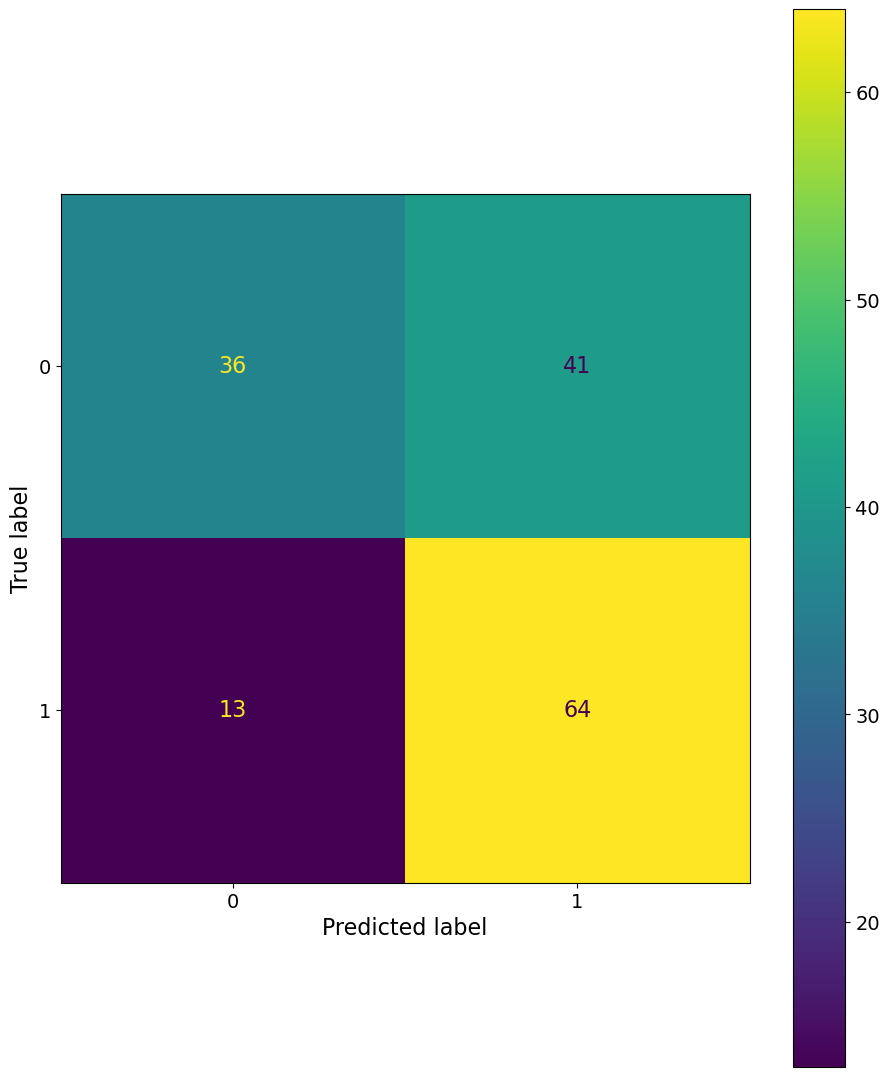

dish washer
gadf
SVM
0

f1_score: 0.4774902516838001
accuracy: 0.564935064935065
              precision    recall  f1-score   support

       False       0.54      0.97      0.69        77
        True       0.86      0.16      0.26        77

    accuracy                           0.56       154
   macro avg       0.70      0.56      0.48       154
weighted avg       0.70      0.56      0.48       154



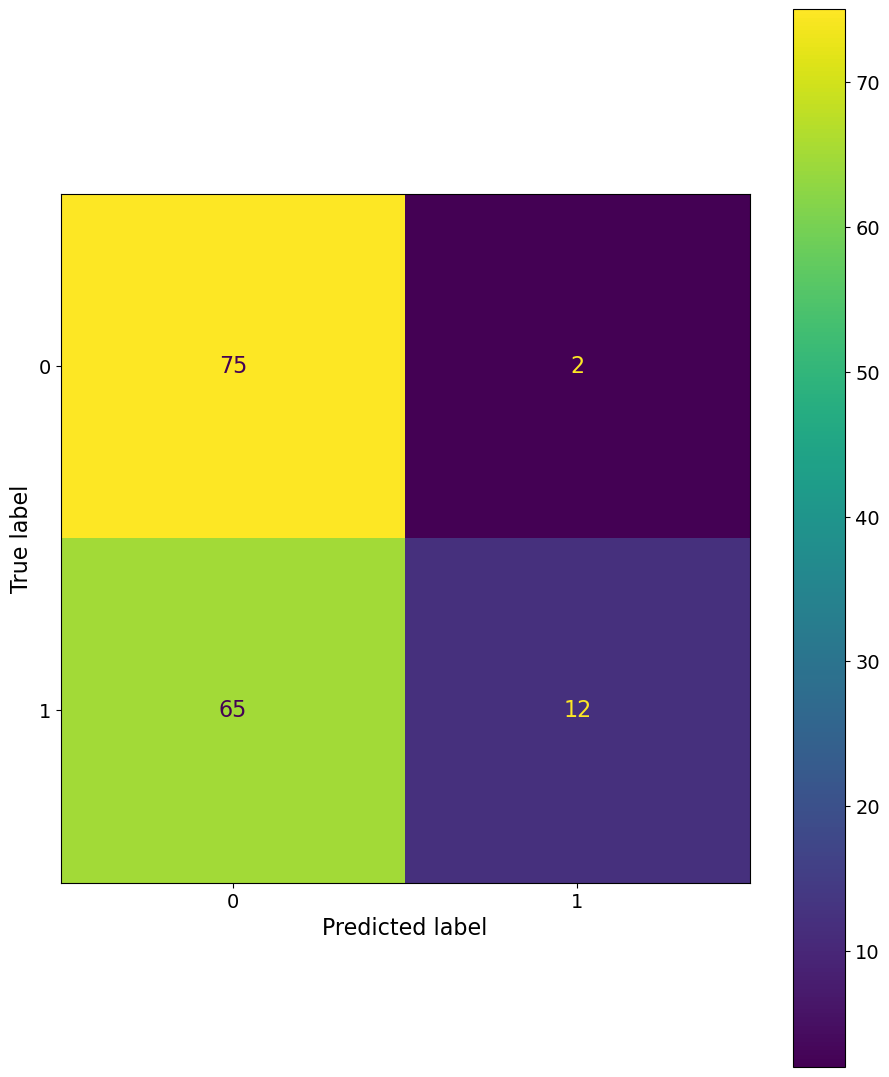

dish washer
mtf
MLP
0

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
f1_score: 0.8428571428571429
accuracy: 0.8441558441558441
              precision    recall  f1-score   support

       False       0.92      0.75      0.83        77
        True       0.79      0.94      0.86        77

    accuracy                           0.84       154
   macro avg       0.86      0.84      0.84       154
weighted avg       0.86      0.84      0.84       154



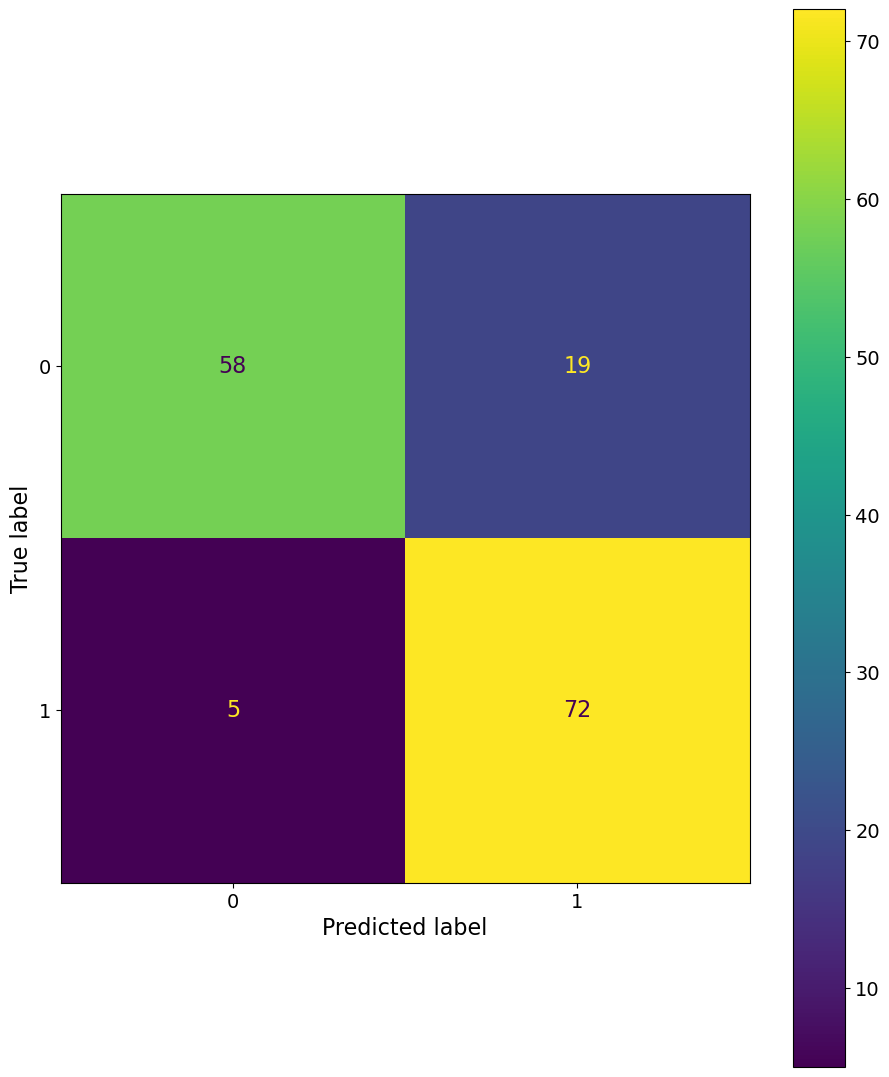

dish washer
mtf
MLP
1

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
f1_score: 0.9025932953826692
accuracy: 0.9025974025974026
              precision    recall  f1-score   support

       False       0.91      0.90      0.90        77
        True       0.90      0.91      0.90        77

    accuracy                           0.90       154
   macro avg       0.90      0.90      0.90       154
weighted avg       0.90      0.90      0.90       154



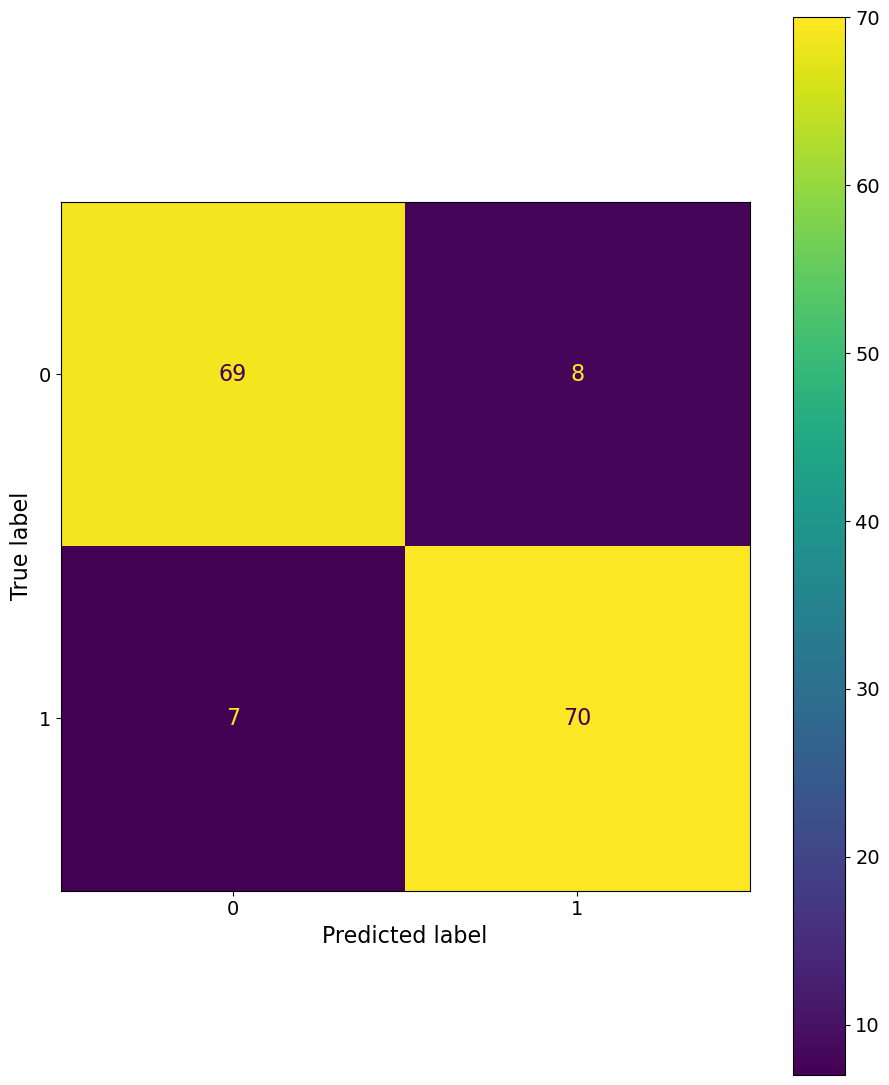

dish washer
mtf
MLP
2

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
f1_score: 0.849577440862955
accuracy: 0.8506493506493507
              precision    recall  f1-score   support

       False       0.92      0.77      0.84        77
        True       0.80      0.94      0.86        77

    accuracy                           0.85       154
   macro avg       0.86      0.85      0.85       154
weighted avg       0.86      0.85      0.85       154



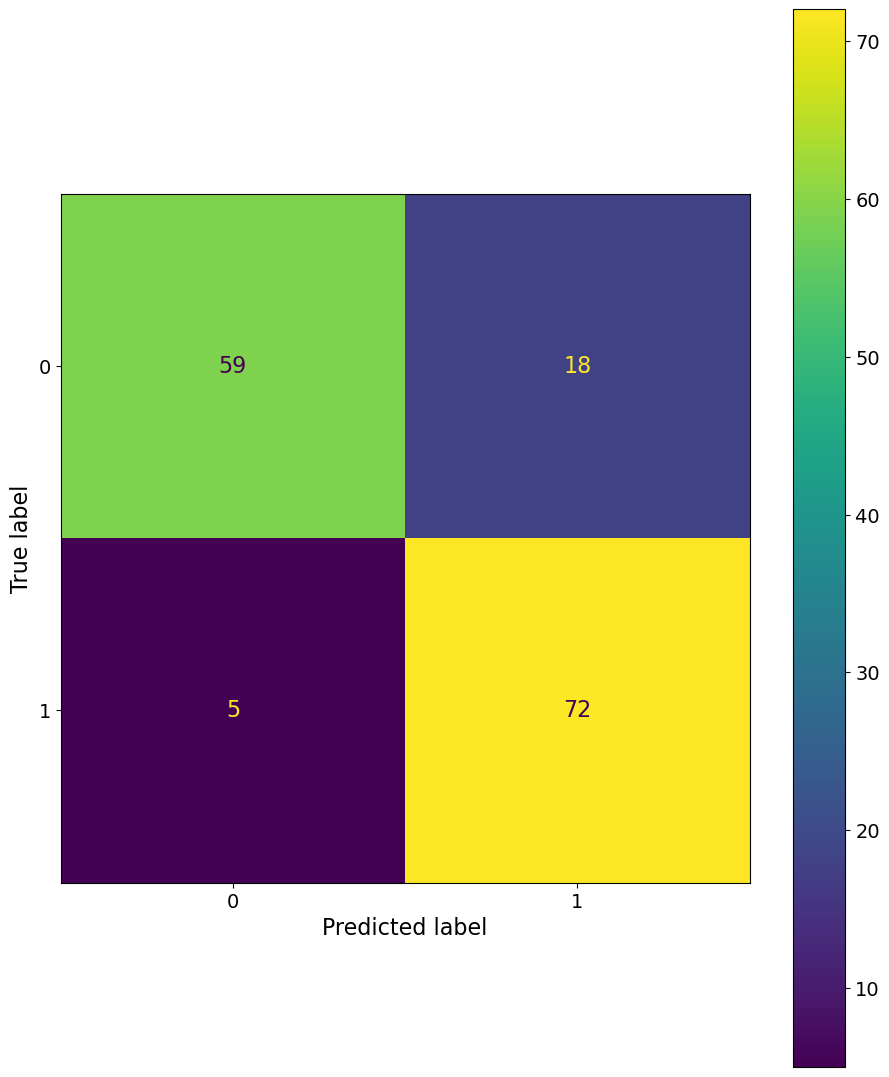

dish washer
mtf
MLP
3

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
f1_score: 0.9025604251908719
accuracy: 0.9025974025974026
              precision    recall  f1-score   support

       False       0.92      0.88      0.90        77
        True       0.89      0.92      0.90        77

    accuracy                           0.90       154
   macro avg       0.90      0.90      0.90       154
weighted avg       0.90      0.90      0.90       154



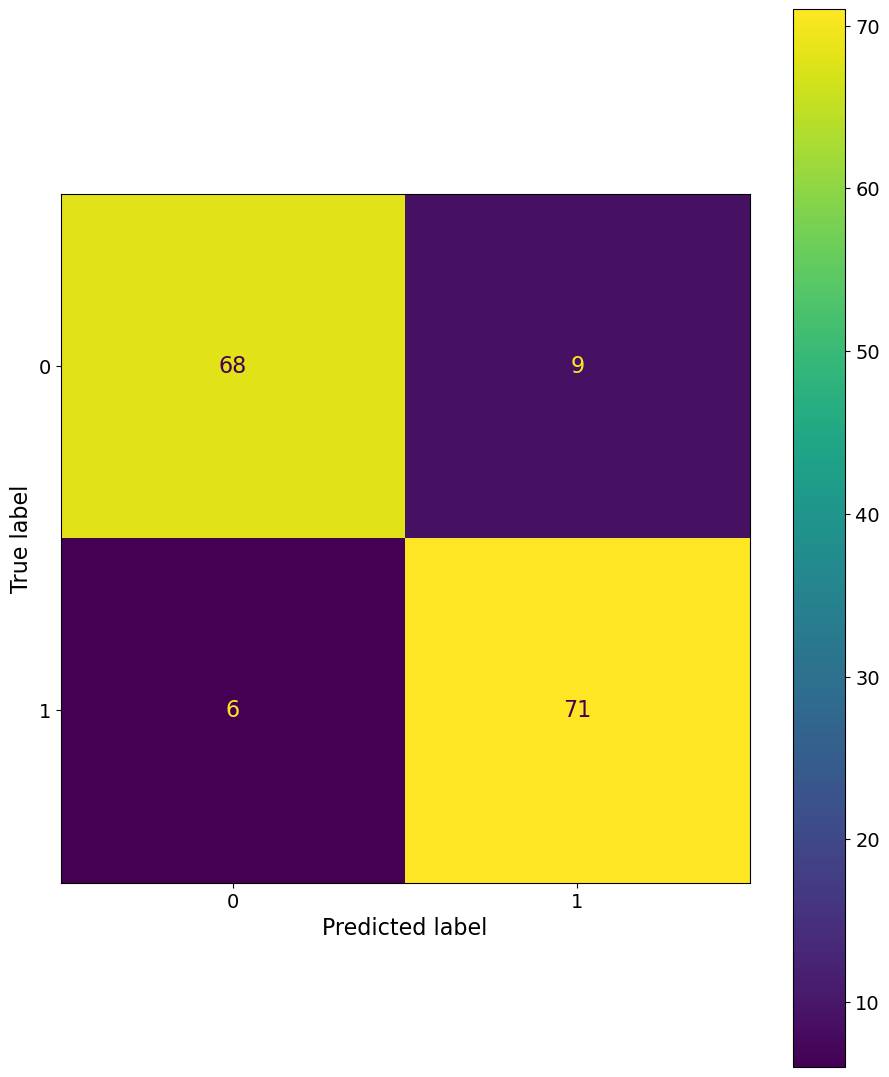

dish washer
mtf
MLP
4

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
f1_score: 0.8697784542533401
accuracy: 0.8701298701298701
              precision    recall  f1-score   support

       False       0.91      0.82      0.86        77
        True       0.84      0.92      0.88        77

    accuracy                           0.87       154
   macro avg       0.87      0.87      0.87       154
weighted avg       0.87      0.87      0.87       154



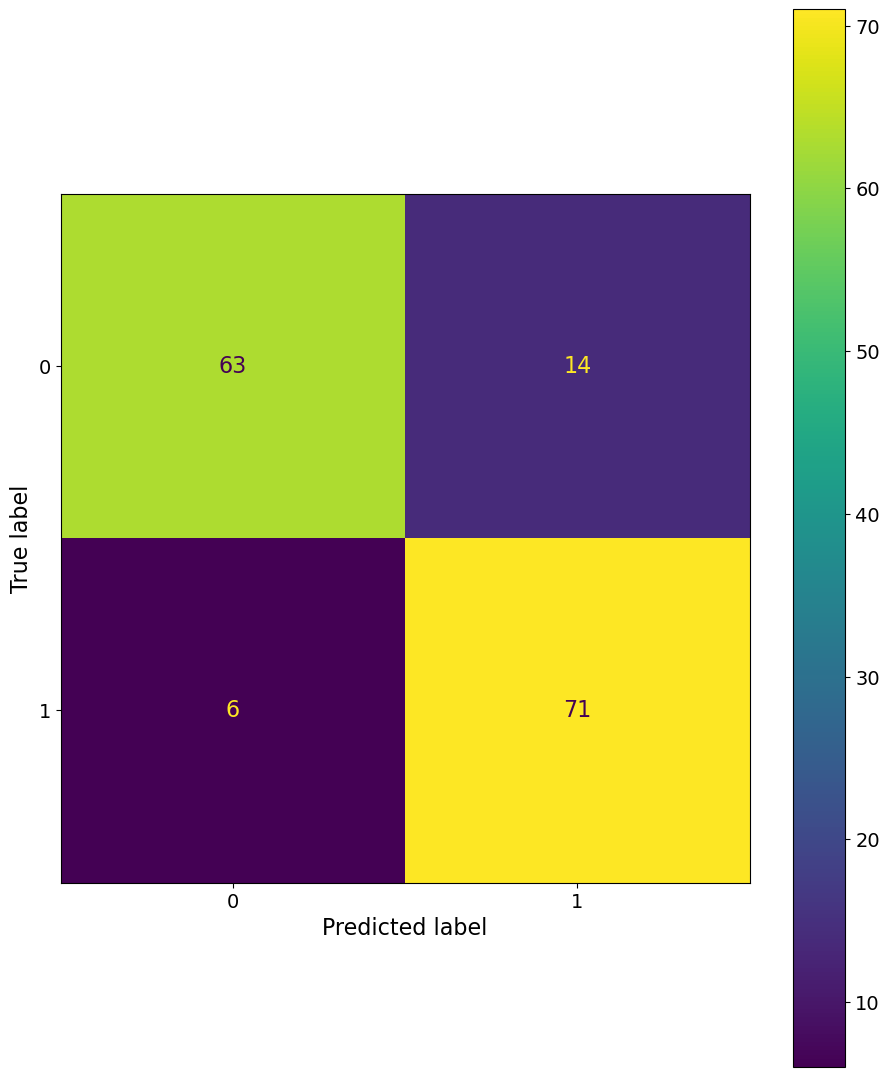

dish washer
mtf
XGBoost
0

f1_score: 0.8073920731444344
accuracy: 0.8116883116883117
              precision    recall  f1-score   support

       False       0.94      0.66      0.78        77
        True       0.74      0.96      0.84        77

    accuracy                           0.81       154
   macro avg       0.84      0.81      0.81       154
weighted avg       0.84      0.81      0.81       154



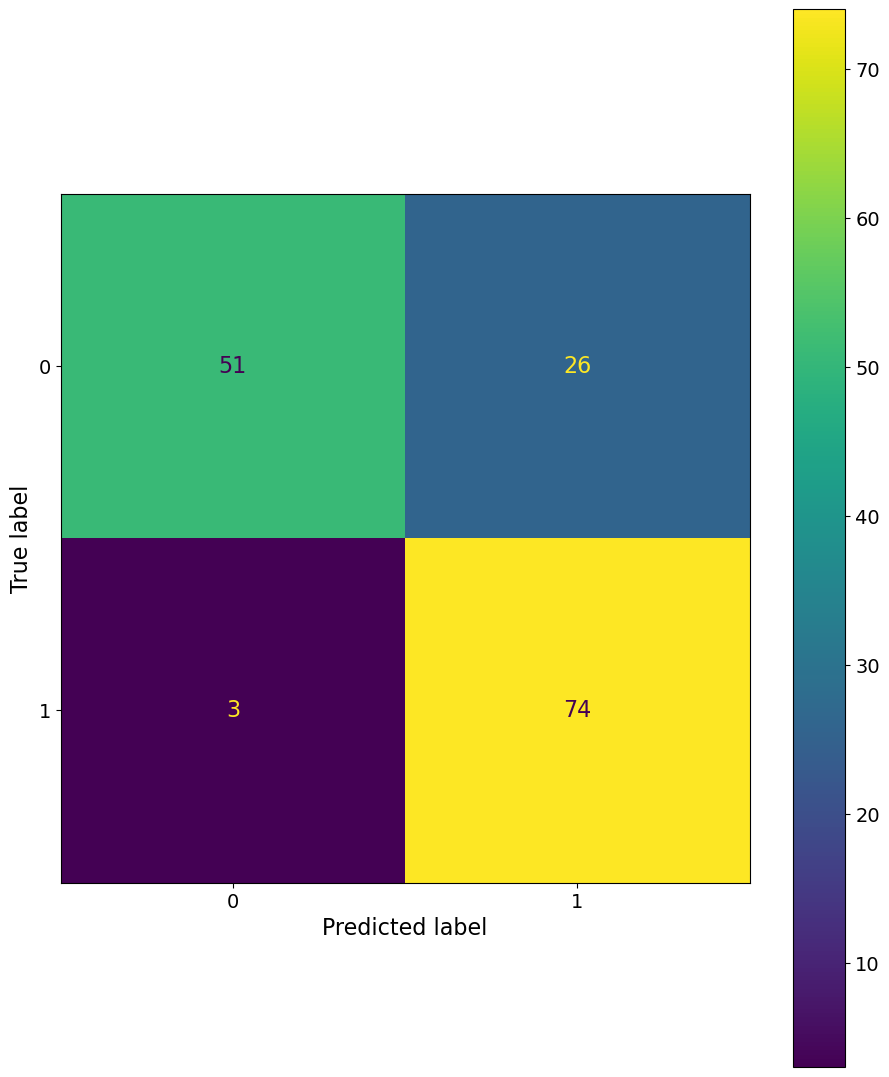

dish washer
mtf
SVM
0

f1_score: 0.8757378859302671
accuracy: 0.8766233766233766
              precision    recall  f1-score   support

       False       0.82      0.96      0.89        77
        True       0.95      0.79      0.87        77

    accuracy                           0.88       154
   macro avg       0.89      0.88      0.88       154
weighted avg       0.89      0.88      0.88       154



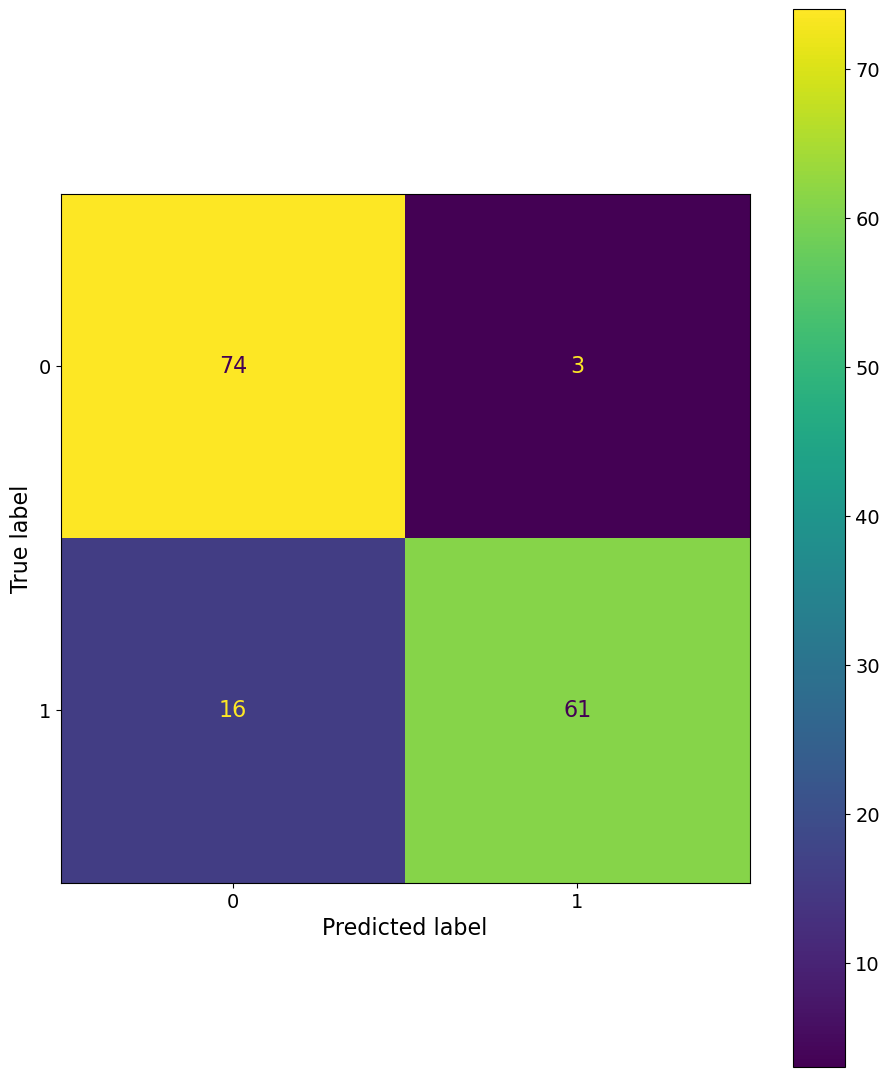

dish washer
rp
MLP
0

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
f1_score: 0.8234169957956428
accuracy: 0.8246753246753247
              precision    recall  f1-score   support

       False       0.78      0.91      0.84        77
        True       0.89      0.74      0.81        77

    accuracy                           0.82       154
   macro avg       0.83      0.82      0.82       154
weighted avg       0.83      0.82      0.82       154



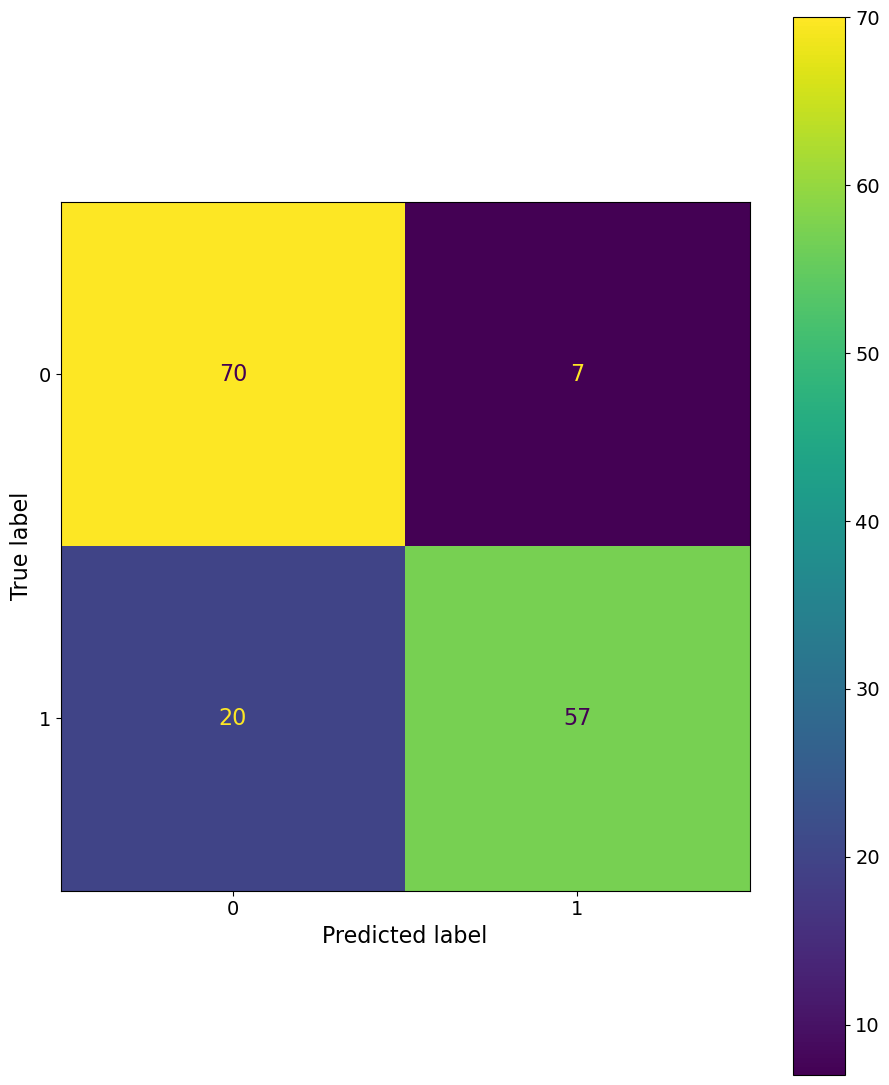

dish washer
rp
MLP
1

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
f1_score: 0.8011363636363636
accuracy: 0.8051948051948052
              precision    recall  f1-score   support

       False       0.74      0.95      0.83        77
        True       0.93      0.66      0.77        77

    accuracy                           0.81       154
   macro avg       0.83      0.81      0.80       154
weighted avg       0.83      0.81      0.80       154



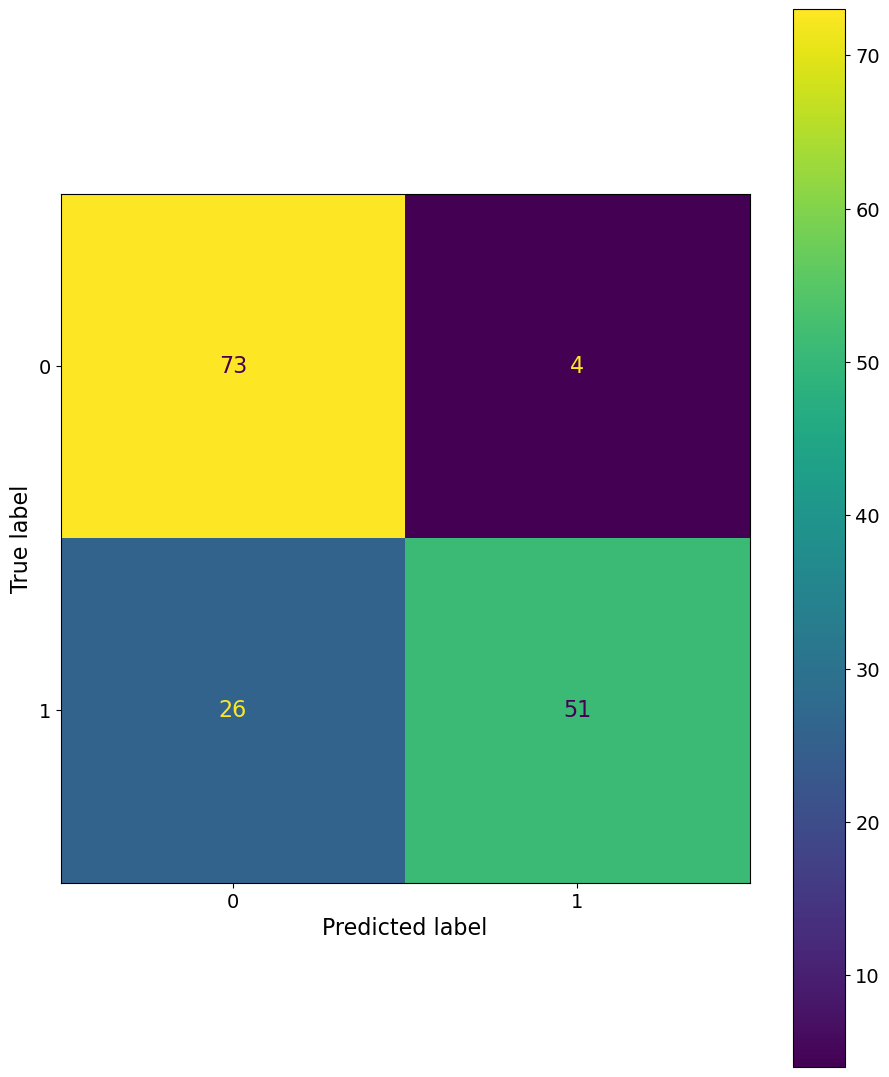

dish washer
rp
MLP
2

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
f1_score: 0.7870354364736387
accuracy: 0.7922077922077922
              precision    recall  f1-score   support

       False       0.72      0.95      0.82        77
        True       0.92      0.64      0.75        77

    accuracy                           0.79       154
   macro avg       0.82      0.79      0.79       154
weighted avg       0.82      0.79      0.79       154



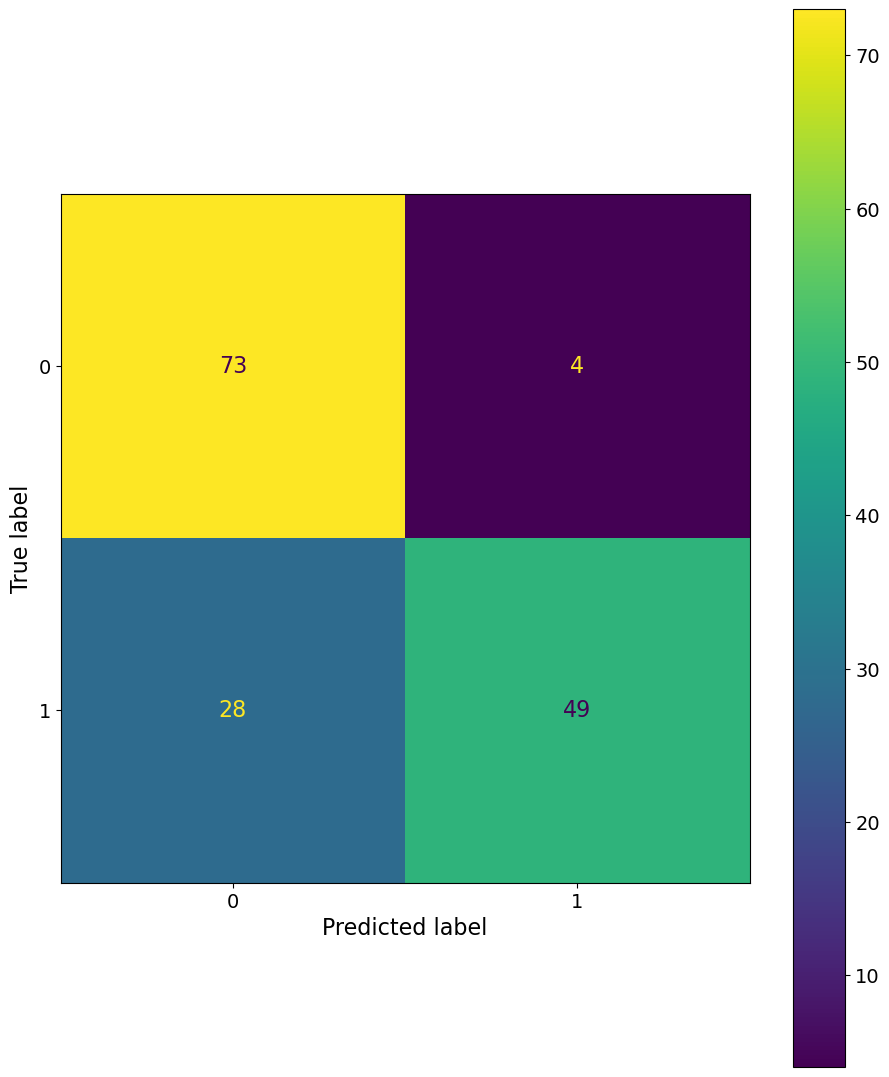

dish washer
rp
MLP
3

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
f1_score: 0.7799142523060933
accuracy: 0.7857142857142857
              precision    recall  f1-score   support

       False       0.72      0.95      0.82        77
        True       0.92      0.62      0.74        77

    accuracy                           0.79       154
   macro avg       0.82      0.79      0.78       154
weighted avg       0.82      0.79      0.78       154



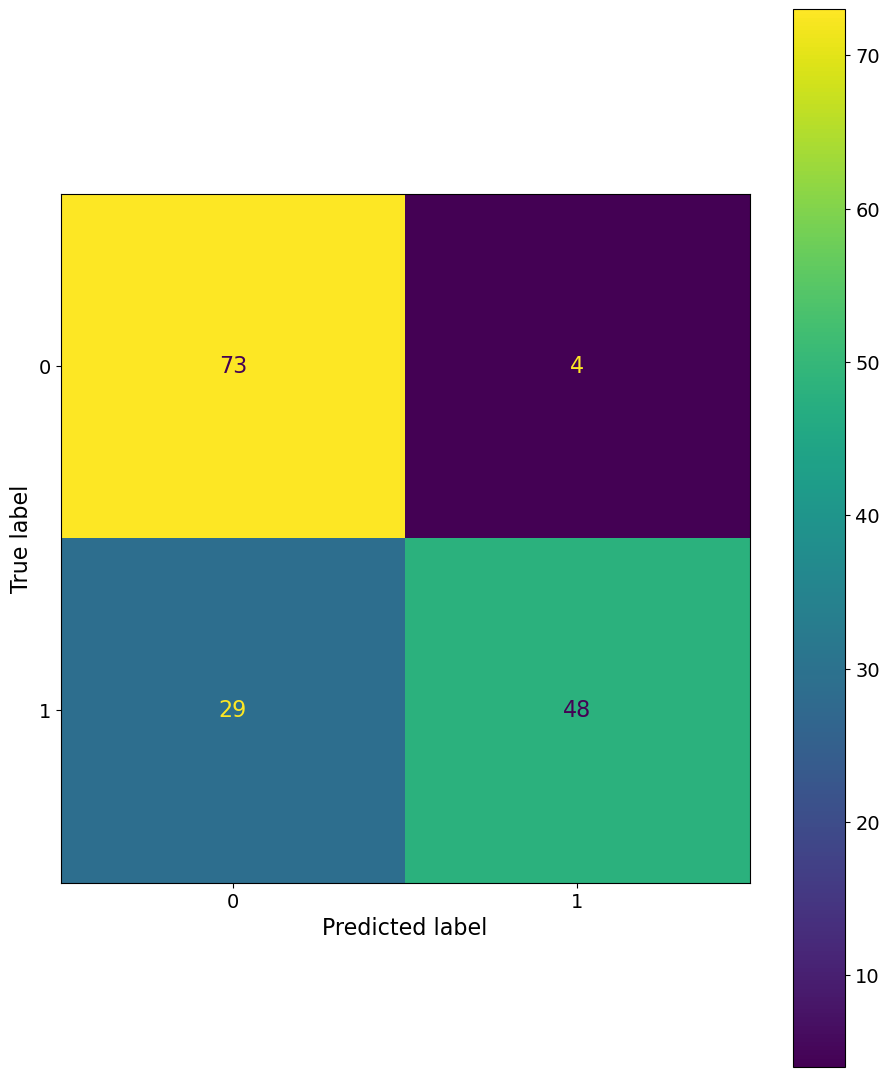

dish washer
rp
MLP
4

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
f1_score: 0.8011363636363636
accuracy: 0.8051948051948052
              precision    recall  f1-score   support

       False       0.74      0.95      0.83        77
        True       0.93      0.66      0.77        77

    accuracy                           0.81       154
   macro avg       0.83      0.81      0.80       154
weighted avg       0.83      0.81      0.80       154



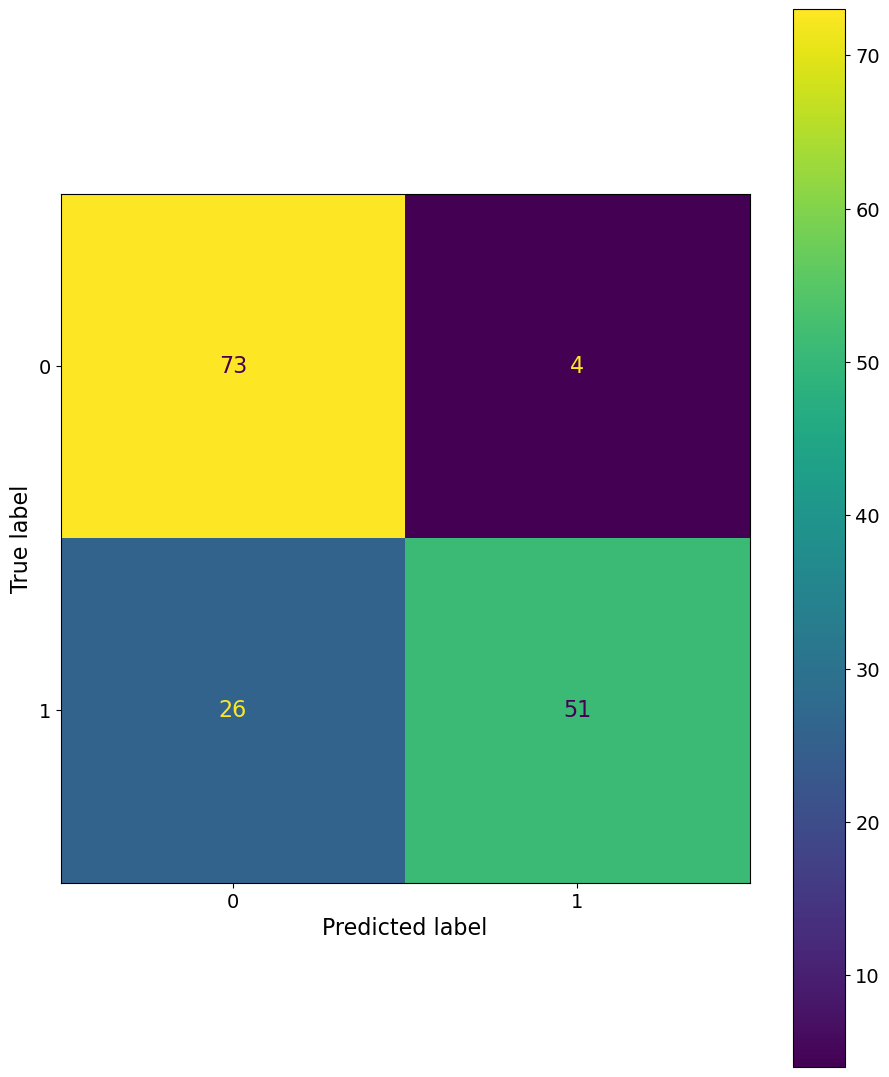

dish washer
rp
XGBoost
0

f1_score: 0.733215025140491
accuracy: 0.7337662337662337
              precision    recall  f1-score   support

       False       0.76      0.69      0.72        77
        True       0.71      0.78      0.75        77

    accuracy                           0.73       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.74      0.73      0.73       154



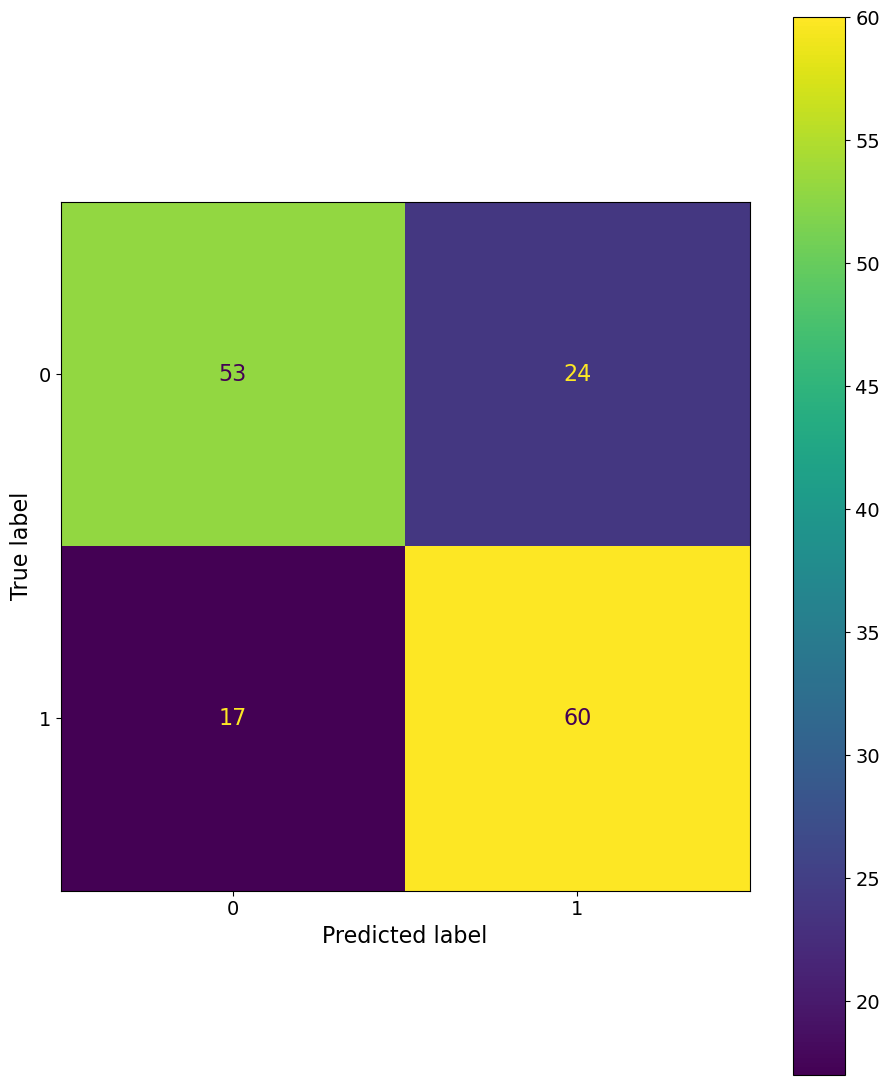

dish washer
rp
SVM
0

f1_score: 0.7570126227208976
accuracy: 0.7662337662337663
              precision    recall  f1-score   support

       False       0.69      0.96      0.80        77
        True       0.94      0.57      0.71        77

    accuracy                           0.77       154
   macro avg       0.81      0.77      0.76       154
weighted avg       0.81      0.77      0.76       154



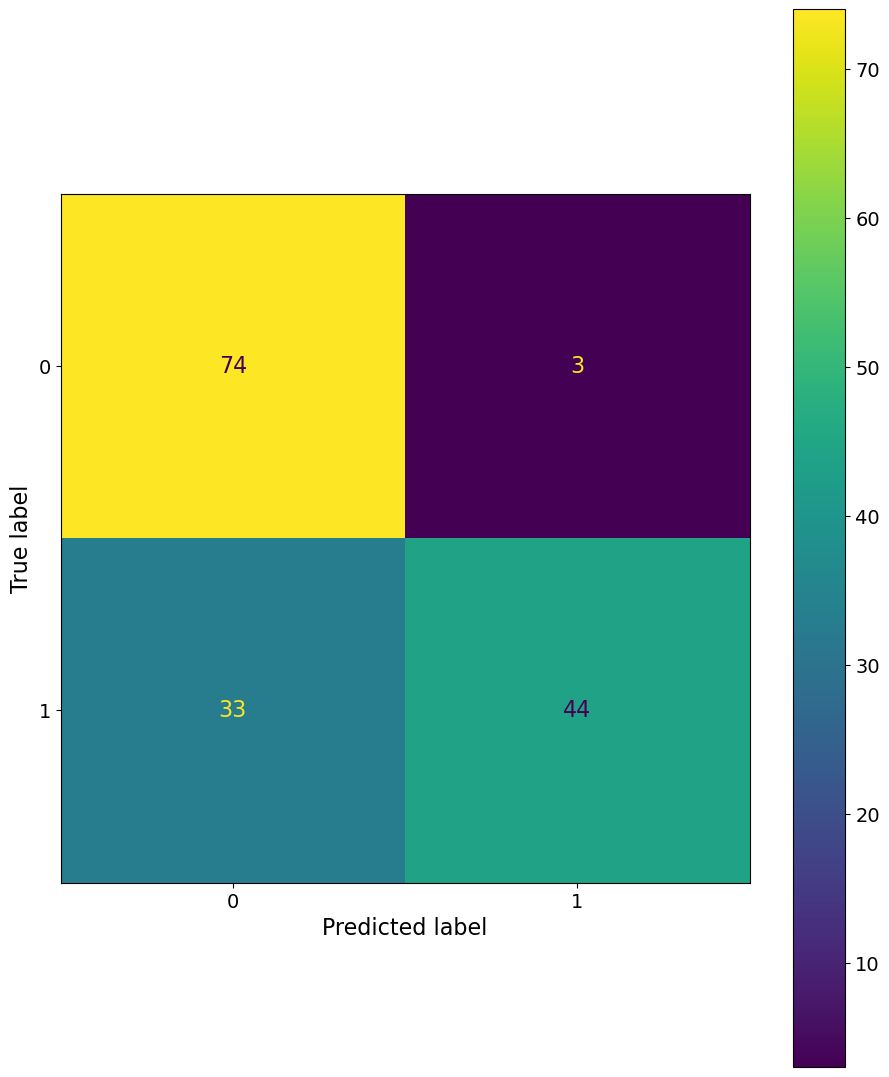

dish washer
tbg
MLP
0

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
f1_score: 0.948051948051948
accuracy: 0.948051948051948
              precision    recall  f1-score   support

       False       0.95      0.95      0.95        77
        True       0.95      0.95      0.95        77

    accuracy                           0.95       154
   macro avg       0.95      0.95      0.95       154
weighted avg       0.95      0.95      0.95       154



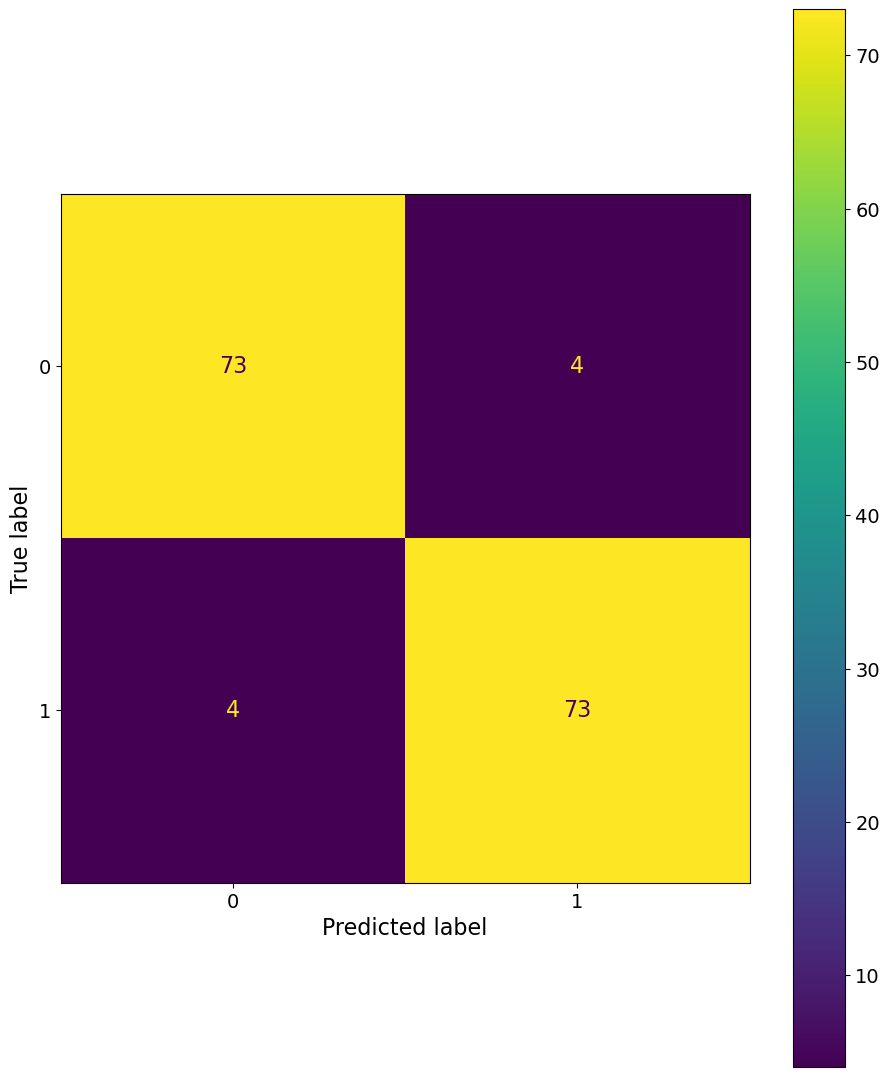

dish washer
tbg
MLP
1

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
f1_score: 0.9350210970464135
accuracy: 0.935064935064935
              precision    recall  f1-score   support

       False       0.91      0.96      0.94        77
        True       0.96      0.91      0.93        77

    accuracy                           0.94       154
   macro avg       0.94      0.94      0.94       154
weighted avg       0.94      0.94      0.94       154



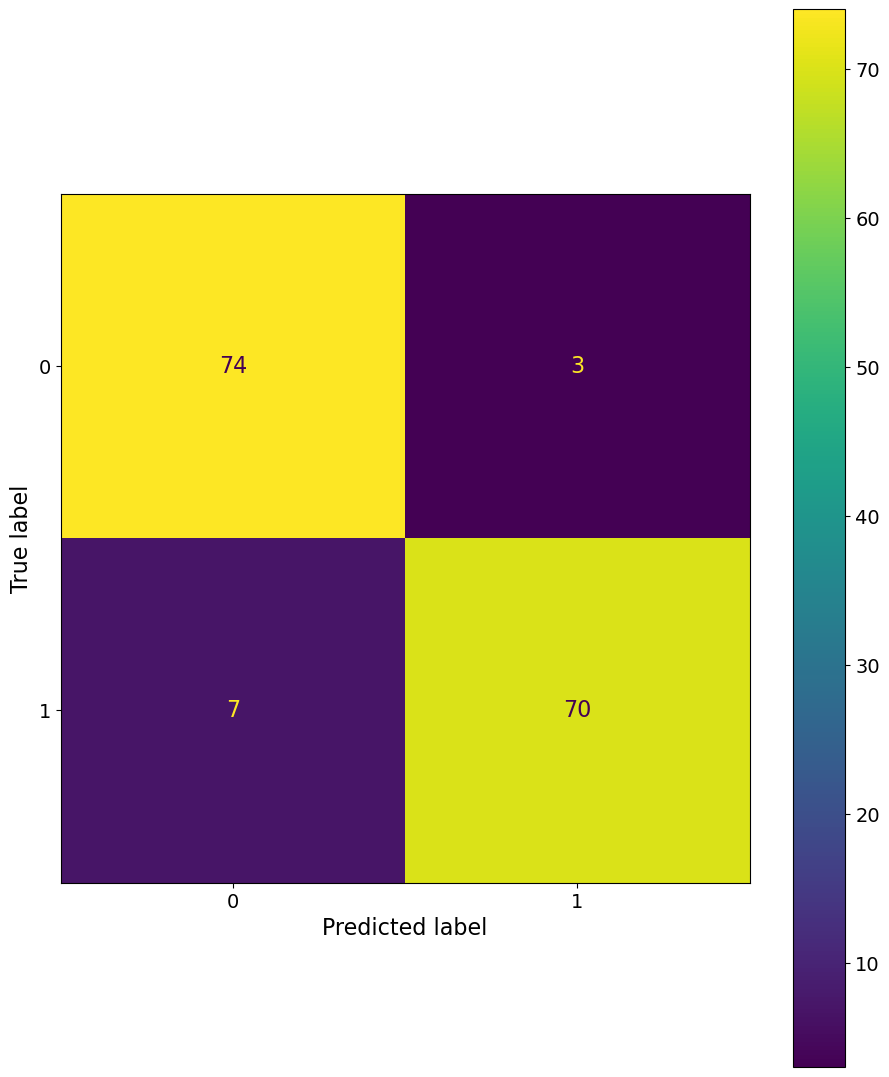

dish washer
tbg
MLP
2

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
f1_score: 0.948051948051948
accuracy: 0.948051948051948
              precision    recall  f1-score   support

       False       0.95      0.95      0.95        77
        True       0.95      0.95      0.95        77

    accuracy                           0.95       154
   macro avg       0.95      0.95      0.95       154
weighted avg       0.95      0.95      0.95       154



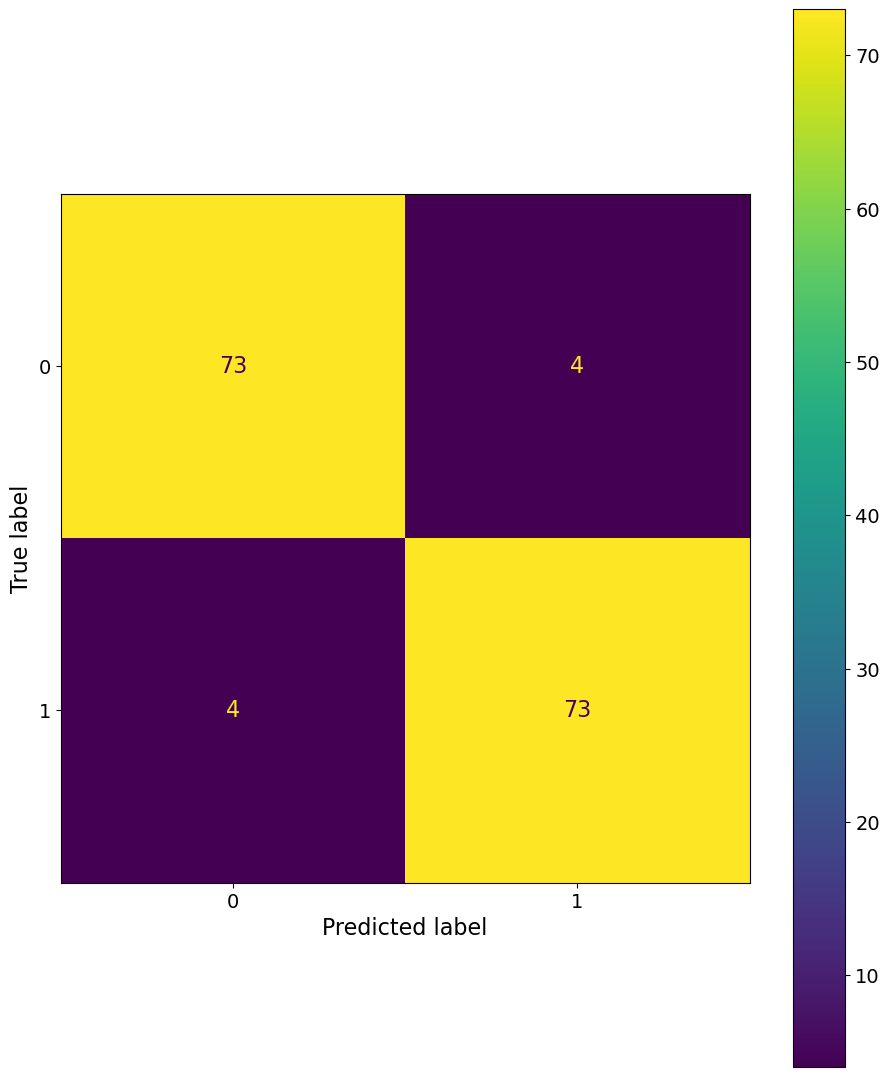

dish washer
tbg
MLP
3

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
f1_score: 0.9154953357815204
accuracy: 0.9155844155844156
              precision    recall  f1-score   support

       False       0.89      0.95      0.92        77
        True       0.94      0.88      0.91        77

    accuracy                           0.92       154
   macro avg       0.92      0.92      0.92       154
weighted avg       0.92      0.92      0.92       154



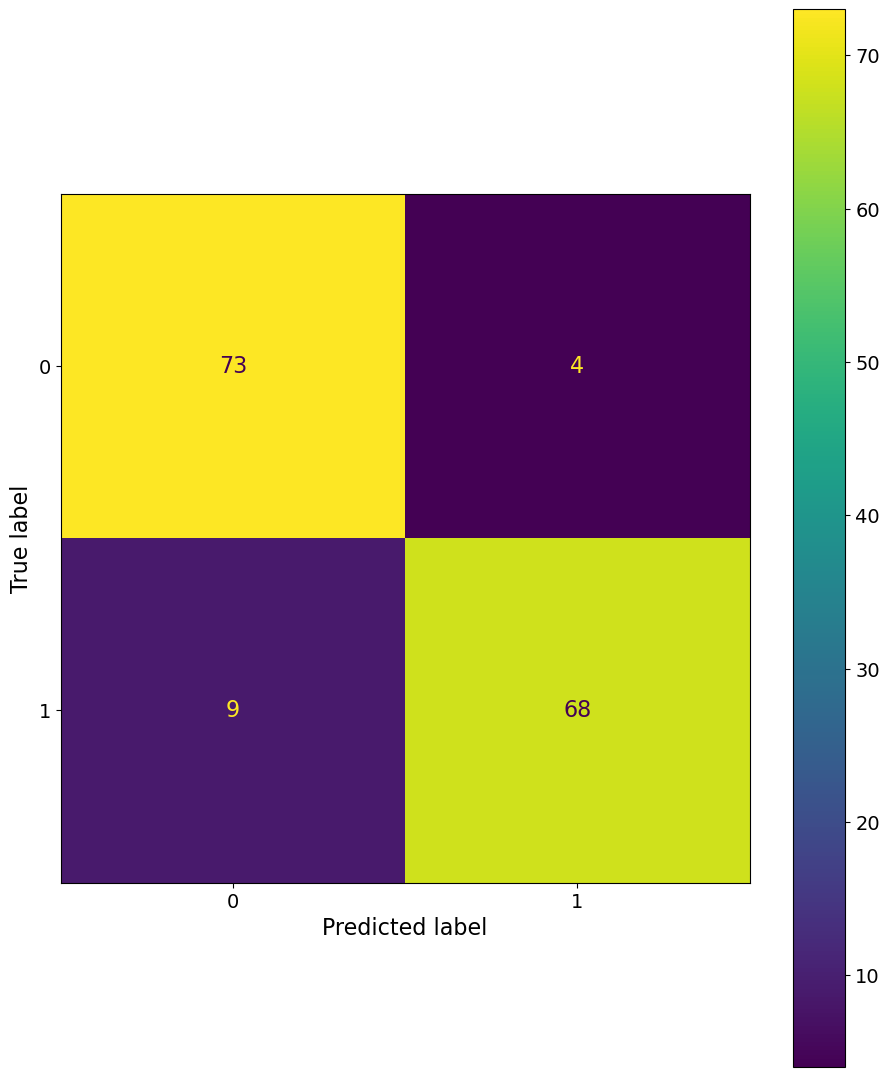

dish washer
tbg
MLP
4

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
f1_score: 0.9219594594594596
accuracy: 0.922077922077922
              precision    recall  f1-score   support

       False       0.89      0.96      0.93        77
        True       0.96      0.88      0.92        77

    accuracy                           0.92       154
   macro avg       0.92      0.92      0.92       154
weighted avg       0.92      0.92      0.92       154



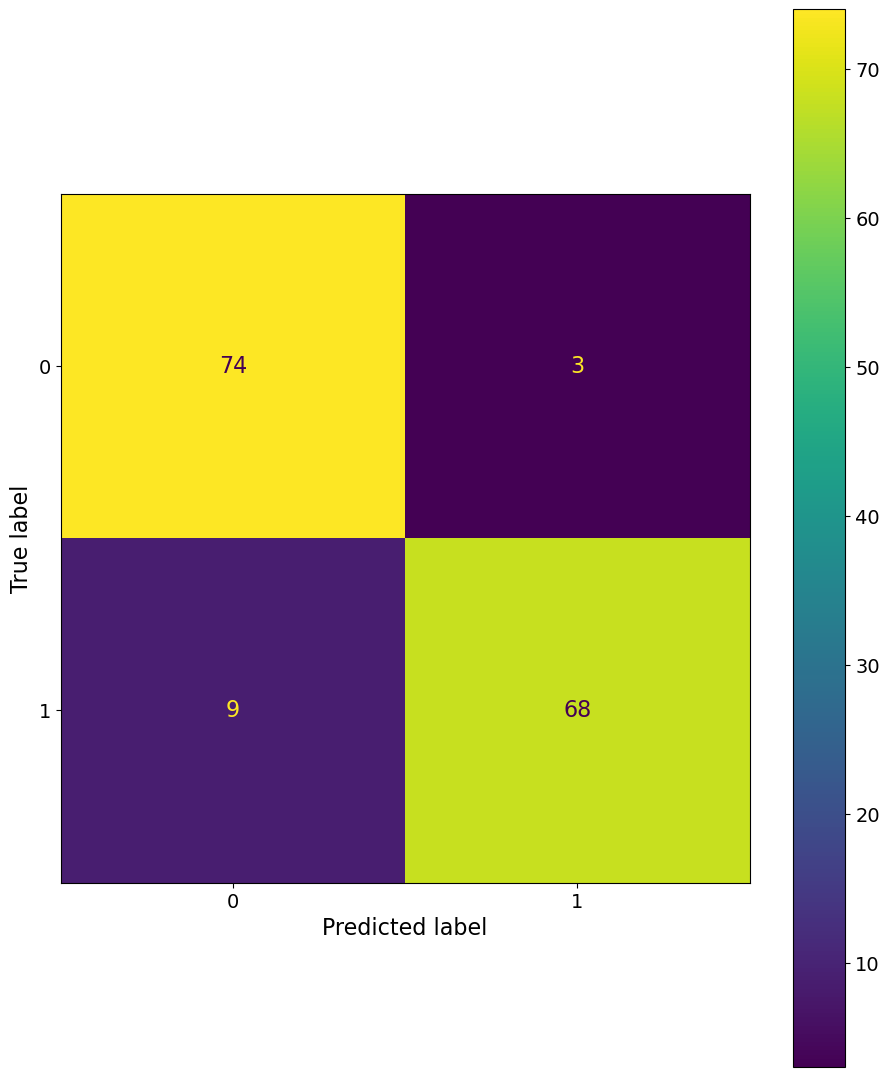

dish washer
tbg
XGBoost
0

f1_score: 0.8757378859302671
accuracy: 0.8766233766233766
              precision    recall  f1-score   support

       False       0.95      0.79      0.87        77
        True       0.82      0.96      0.89        77

    accuracy                           0.88       154
   macro avg       0.89      0.88      0.88       154
weighted avg       0.89      0.88      0.88       154



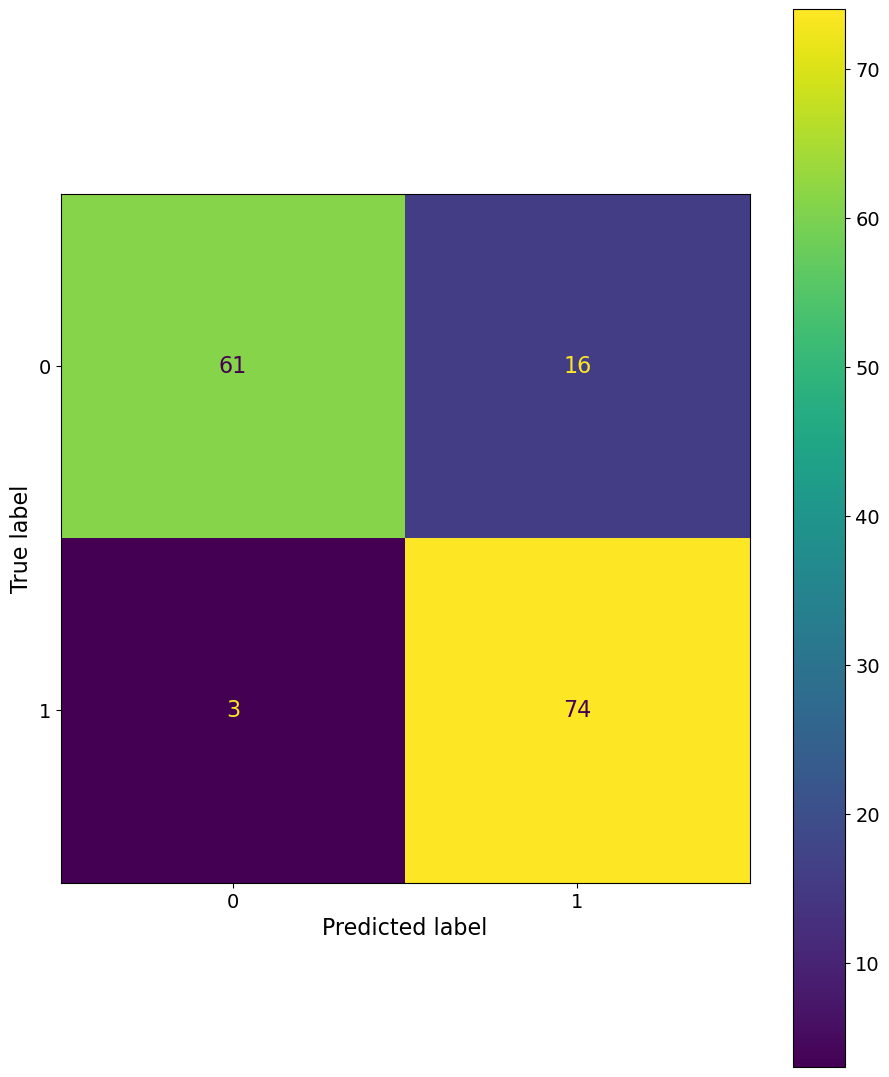

dish washer
tbg
SVM
0

f1_score: 0.8757378859302671
accuracy: 0.8766233766233766
              precision    recall  f1-score   support

       False       0.82      0.96      0.89        77
        True       0.95      0.79      0.87        77

    accuracy                           0.88       154
   macro avg       0.89      0.88      0.88       154
weighted avg       0.89      0.88      0.88       154



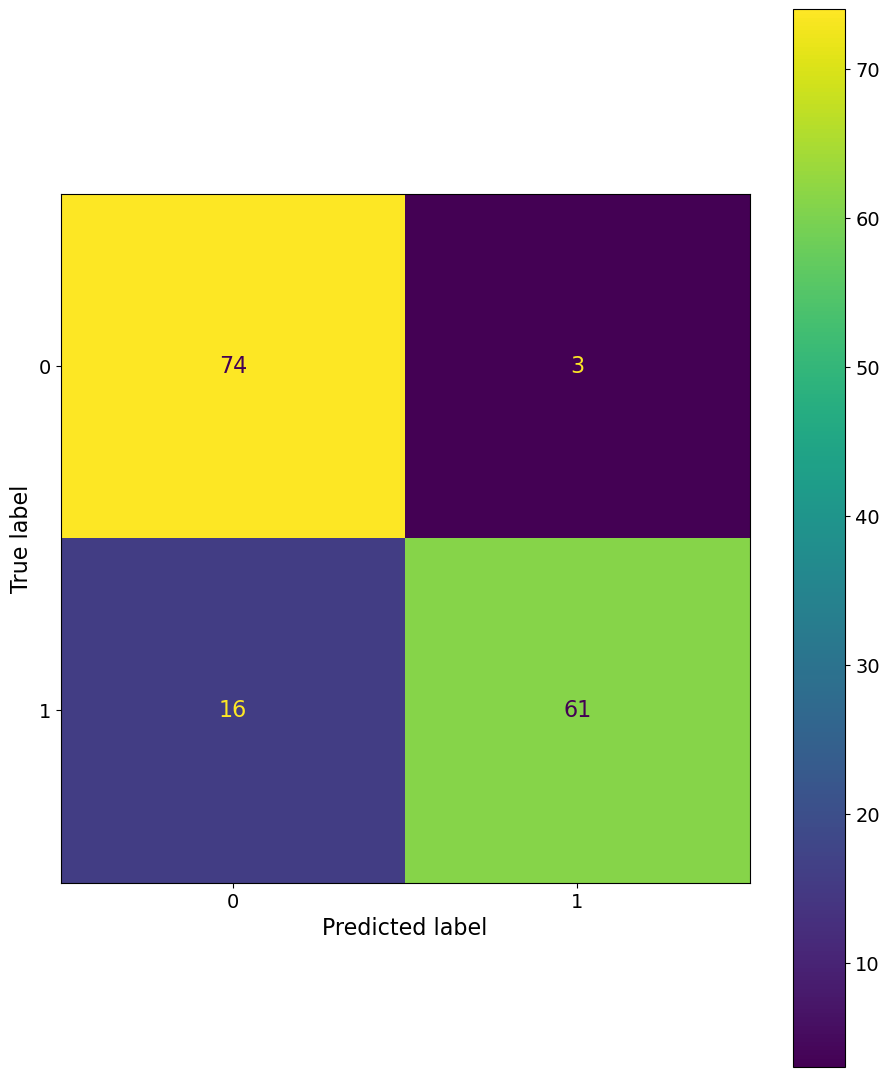

kettle
gasf
MLP
0

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
f1_score: 0.96875
accuracy: 0.96875
              precision    recall  f1-score   support

       False       0.97      0.97      0.97        96
        True       0.97      0.97      0.97        96

    accuracy                           0.97       192
   macro avg       0.97      0.97      0.97       192
weighted avg       0.97      0.97      0.97       192



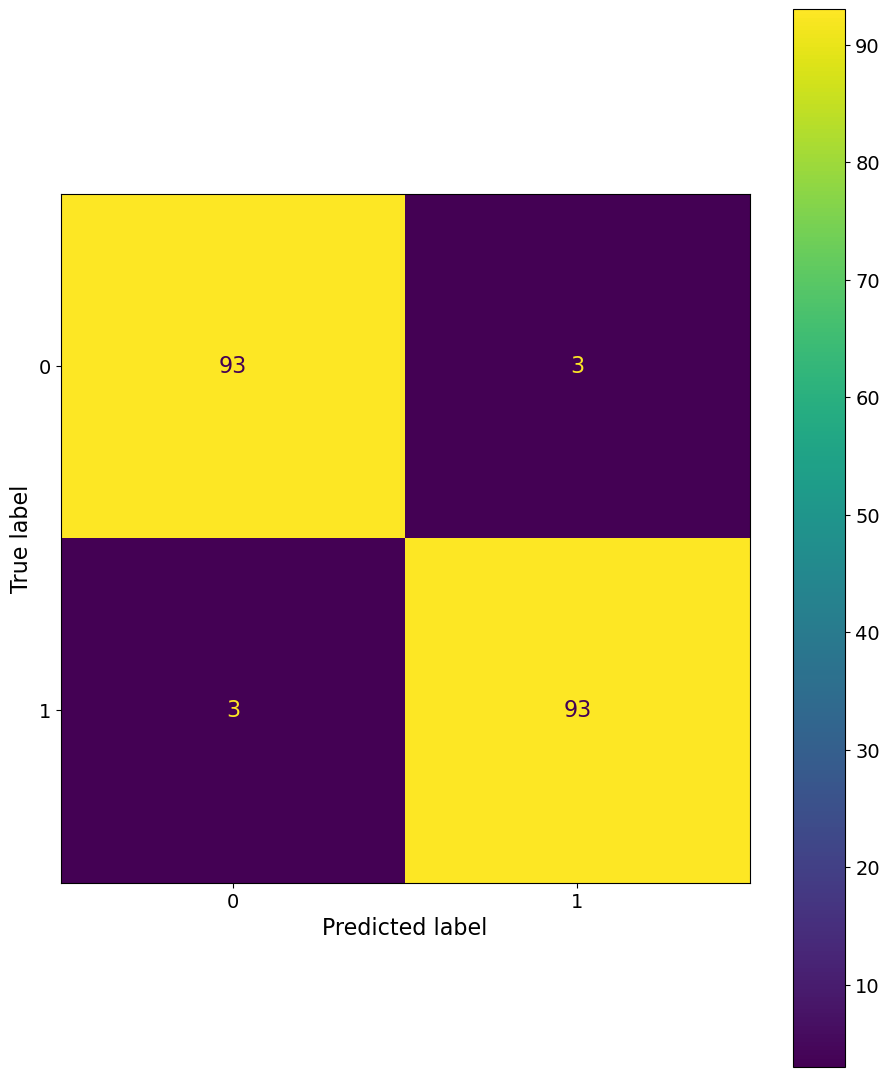

kettle
gasf
MLP
1

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
f1_score: 0.96875
accuracy: 0.96875
              precision    recall  f1-score   support

       False       0.97      0.97      0.97        96
        True       0.97      0.97      0.97        96

    accuracy                           0.97       192
   macro avg       0.97      0.97      0.97       192
weighted avg       0.97      0.97      0.97       192



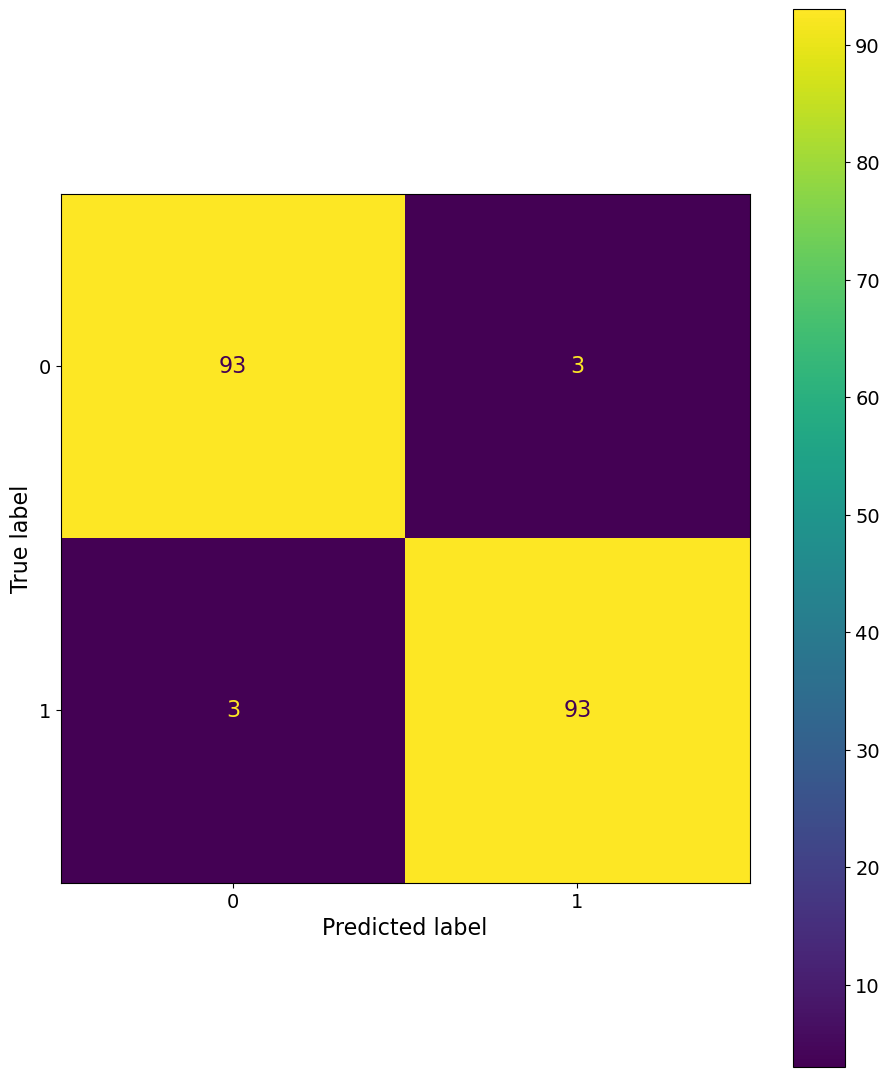

kettle
gasf
MLP
2

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
f1_score: 0.96875
accuracy: 0.96875
              precision    recall  f1-score   support

       False       0.97      0.97      0.97        96
        True       0.97      0.97      0.97        96

    accuracy                           0.97       192
   macro avg       0.97      0.97      0.97       192
weighted avg       0.97      0.97      0.97       192



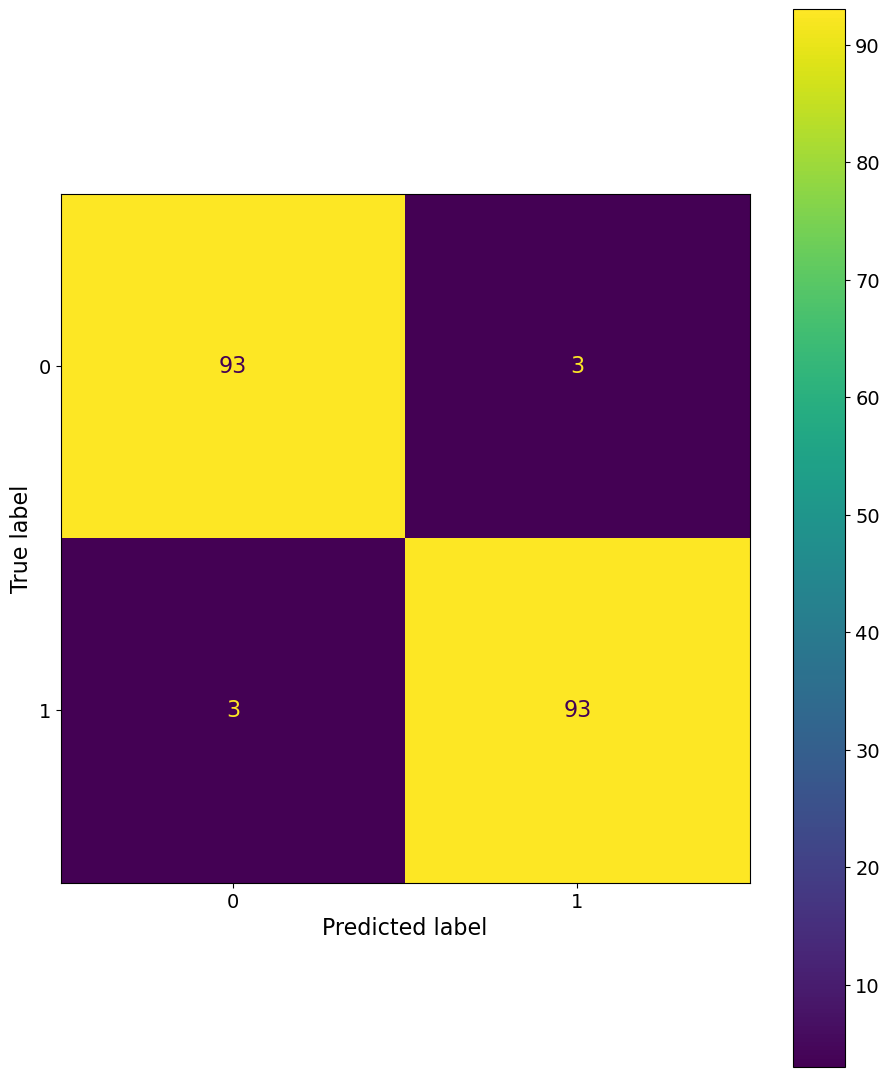

kettle
gasf
MLP
3

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
f1_score: 0.96875
accuracy: 0.96875
              precision    recall  f1-score   support

       False       0.97      0.97      0.97        96
        True       0.97      0.97      0.97        96

    accuracy                           0.97       192
   macro avg       0.97      0.97      0.97       192
weighted avg       0.97      0.97      0.97       192



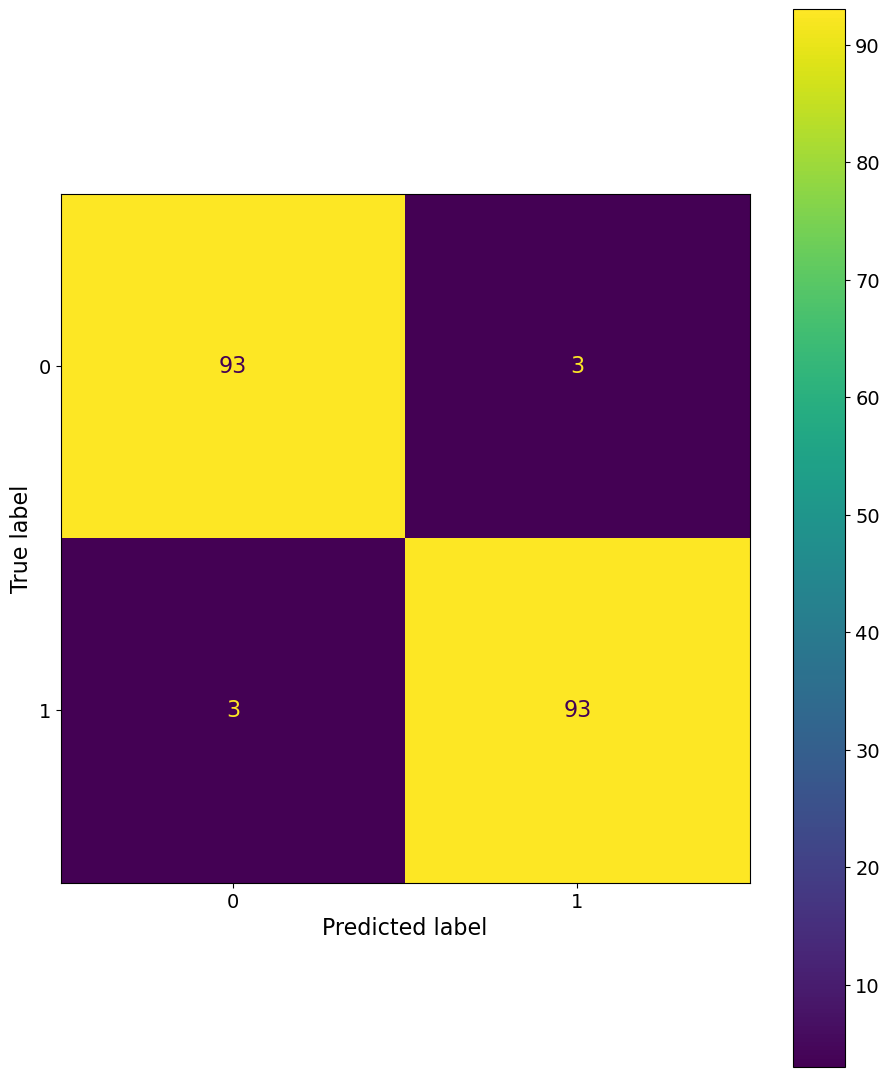

kettle
gasf
MLP
4

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
f1_score: 0.96875
accuracy: 0.96875
              precision    recall  f1-score   support

       False       0.97      0.97      0.97        96
        True       0.97      0.97      0.97        96

    accuracy                           0.97       192
   macro avg       0.97      0.97      0.97       192
weighted avg       0.97      0.97      0.97       192



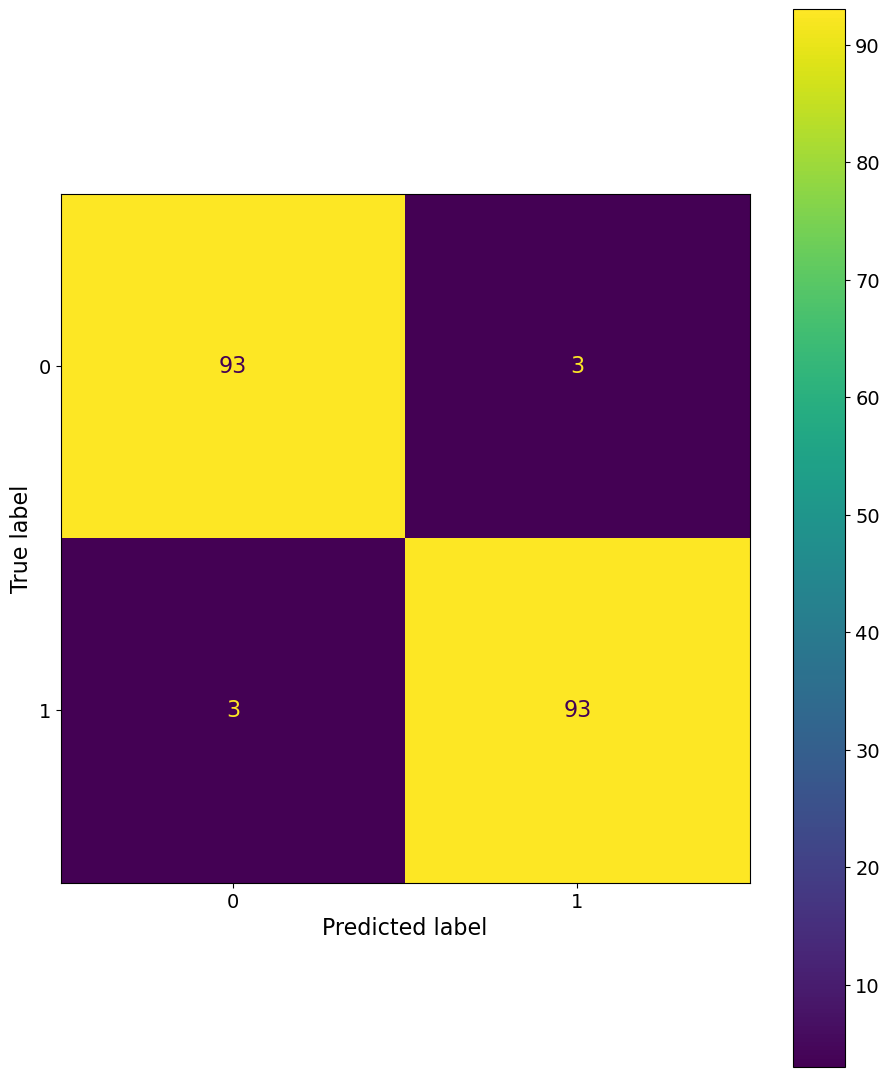

kettle
gasf
XGBoost
0

f1_score: 0.9635406776442503
accuracy: 0.9635416666666666
              precision    recall  f1-score   support

       False       0.97      0.96      0.96        96
        True       0.96      0.97      0.96        96

    accuracy                           0.96       192
   macro avg       0.96      0.96      0.96       192
weighted avg       0.96      0.96      0.96       192



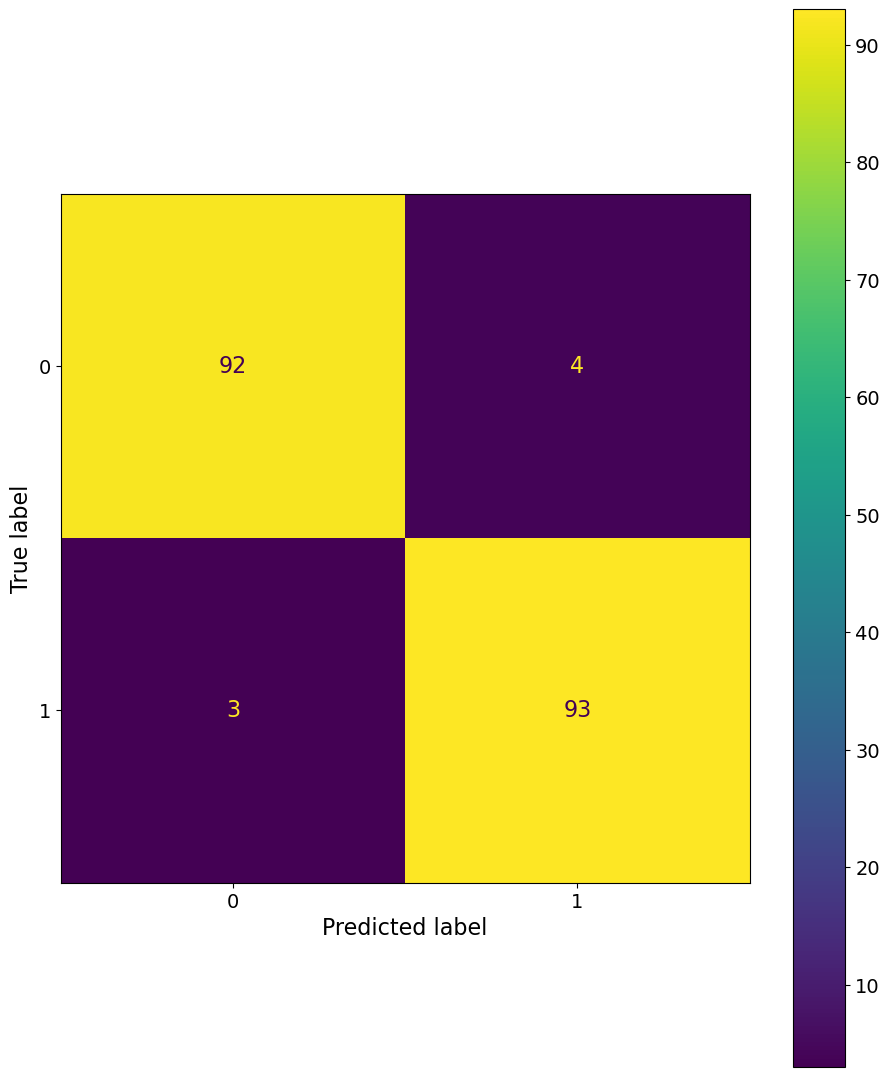

kettle
gasf
SVM
0

f1_score: 0.9583288117200217
accuracy: 0.9583333333333334
              precision    recall  f1-score   support

       False       0.97      0.95      0.96        96
        True       0.95      0.97      0.96        96

    accuracy                           0.96       192
   macro avg       0.96      0.96      0.96       192
weighted avg       0.96      0.96      0.96       192



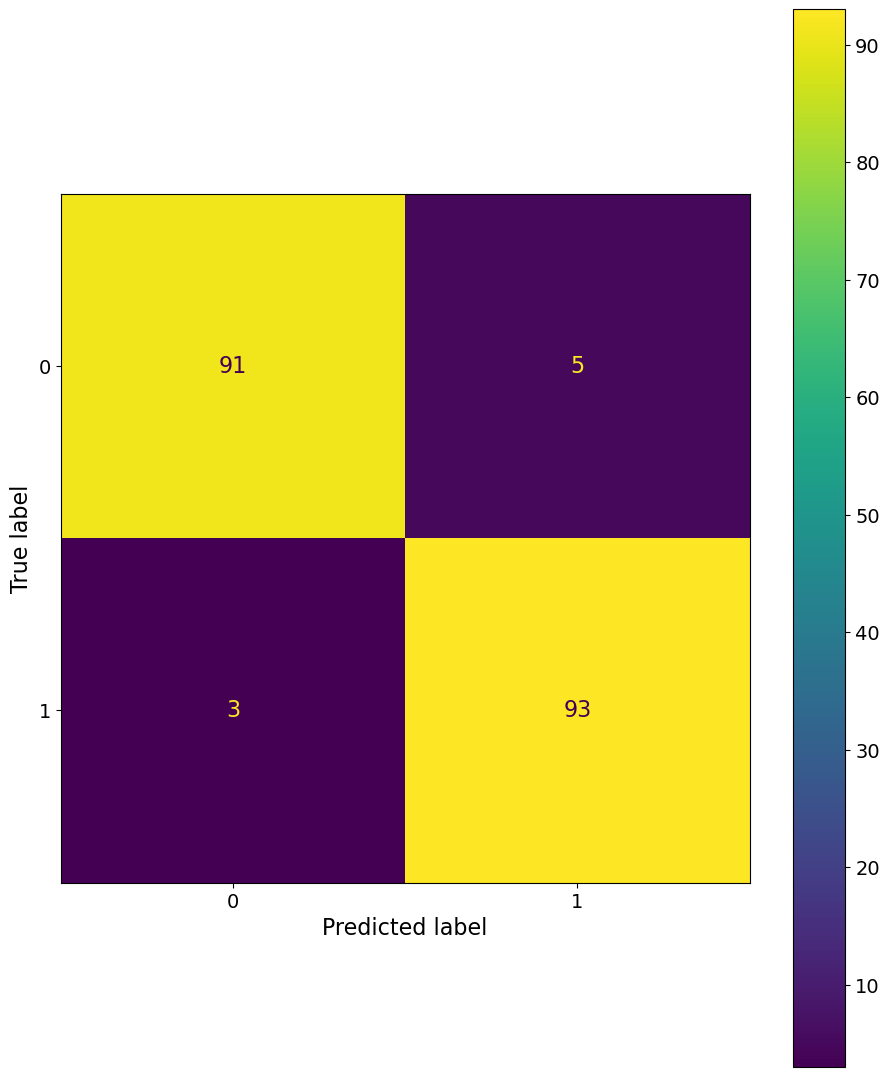

kettle
gadf
MLP
0

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
f1_score: 0.800328407224959
accuracy: 0.8020833333333334
              precision    recall  f1-score   support

       False       0.87      0.71      0.78        96
        True       0.75      0.90      0.82        96

    accuracy                           0.80       192
   macro avg       0.81      0.80      0.80       192
weighted avg       0.81      0.80      0.80       192



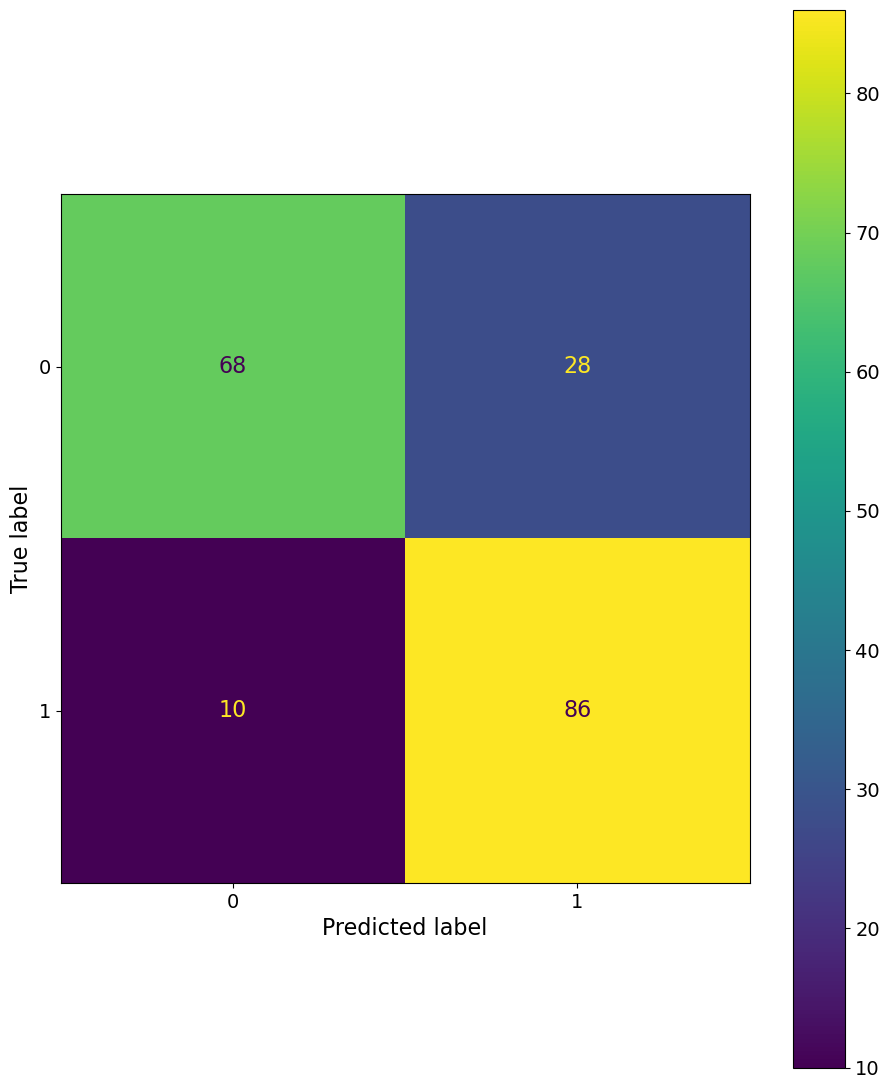

kettle
gadf
MLP
1

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
f1_score: 0.7653130517452126
accuracy: 0.765625
              precision    recall  f1-score   support

       False       0.75      0.80      0.77        96
        True       0.79      0.73      0.76        96

    accuracy                           0.77       192
   macro avg       0.77      0.77      0.77       192
weighted avg       0.77      0.77      0.77       192



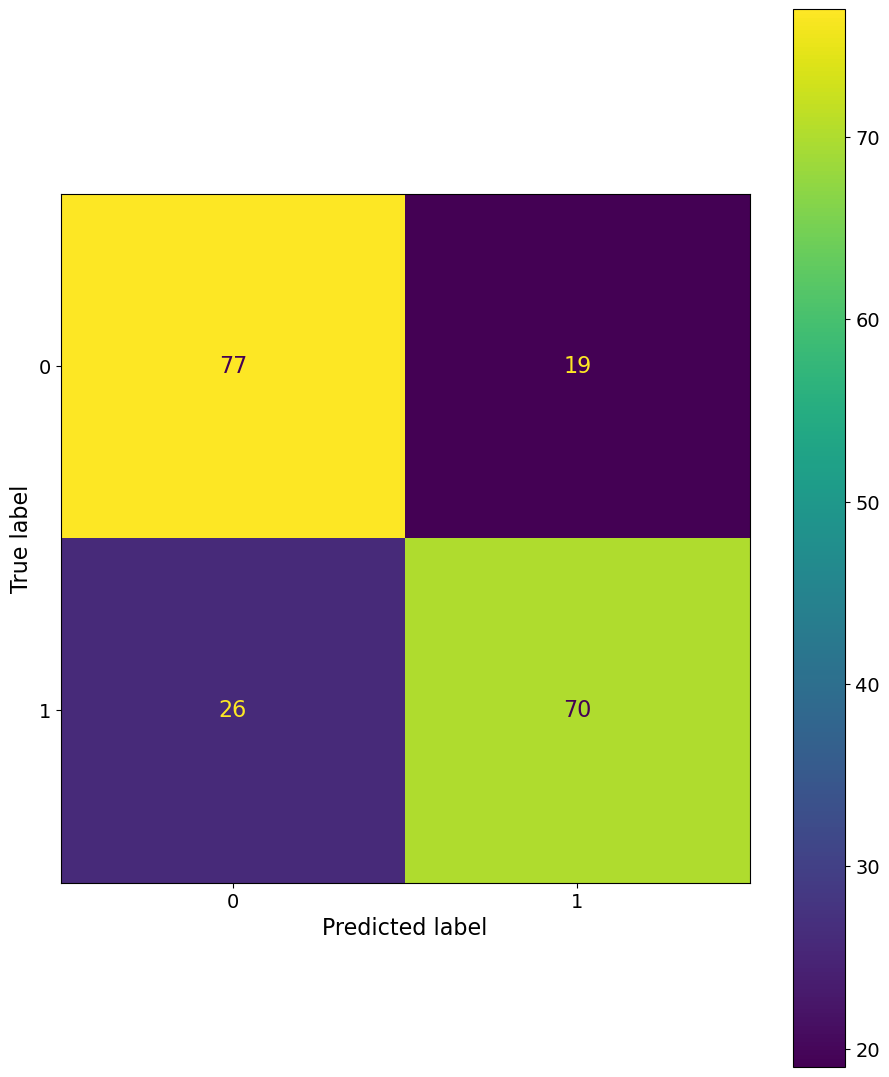

kettle
gadf
MLP
2

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
f1_score: 0.786452540487752
accuracy: 0.7864583333333334
              precision    recall  f1-score   support

       False       0.79      0.78      0.79        96
        True       0.78      0.79      0.79        96

    accuracy                           0.79       192
   macro avg       0.79      0.79      0.79       192
weighted avg       0.79      0.79      0.79       192



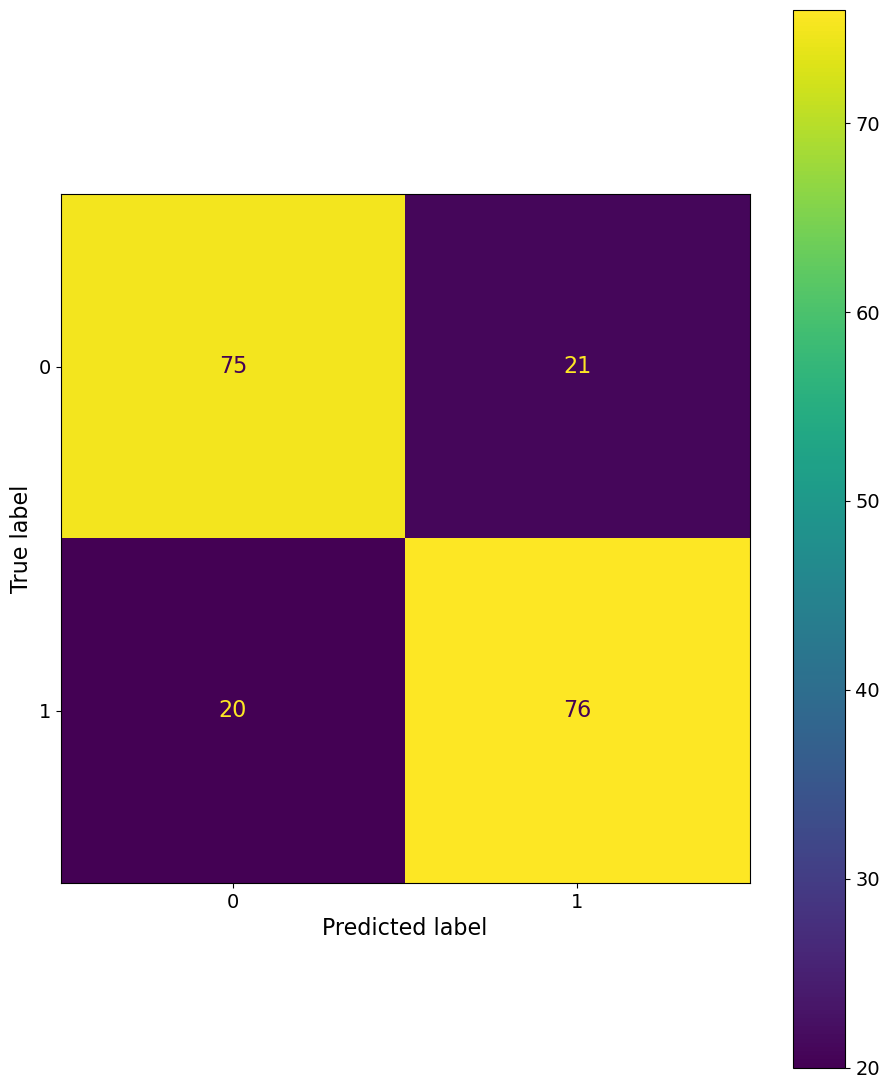

kettle
gadf
MLP
3

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
f1_score: 0.806108245312372
accuracy: 0.8072916666666666
              precision    recall  f1-score   support

       False       0.86      0.73      0.79        96
        True       0.77      0.89      0.82        96

    accuracy                           0.81       192
   macro avg       0.81      0.81      0.81       192
weighted avg       0.81      0.81      0.81       192



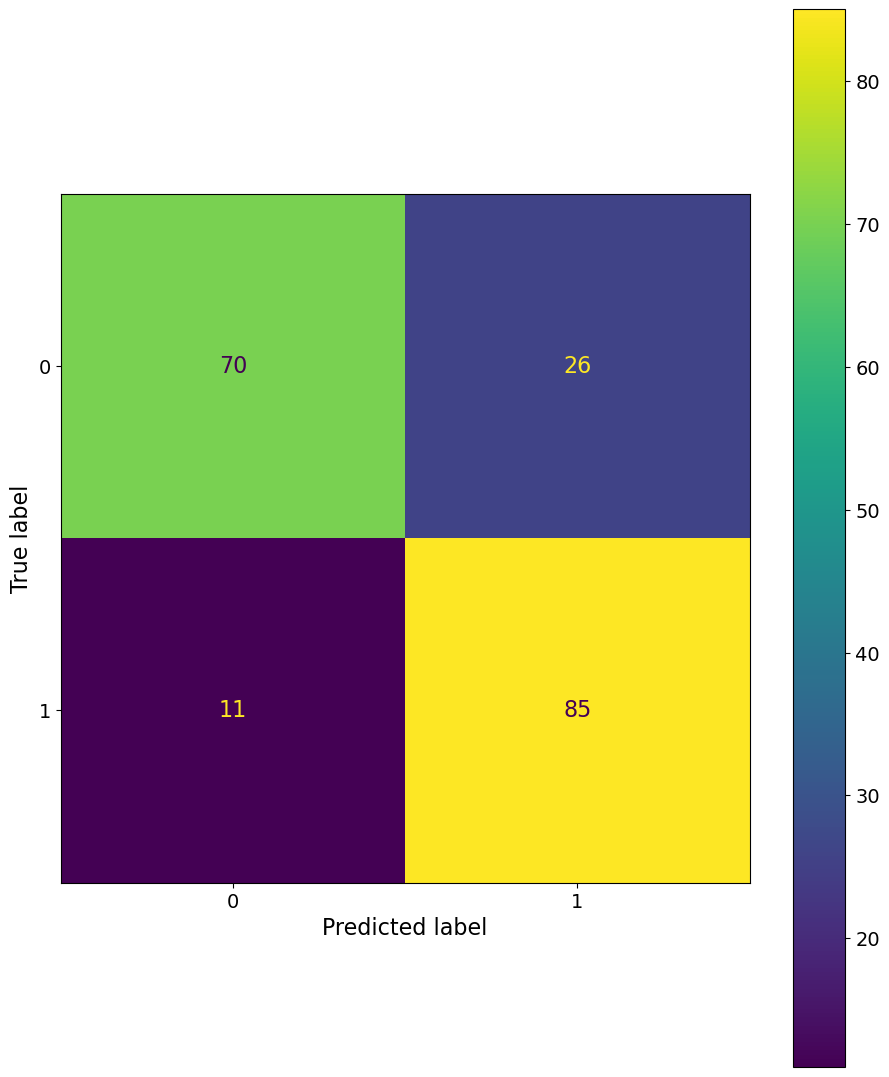

kettle
gadf
MLP
4

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
f1_score: 0.7483760683760684
accuracy: 0.7604166666666666
              precision    recall  f1-score   support

       False       0.96      0.54      0.69        96
        True       0.68      0.98      0.80        96

    accuracy                           0.76       192
   macro avg       0.82      0.76      0.75       192
weighted avg       0.82      0.76      0.75       192



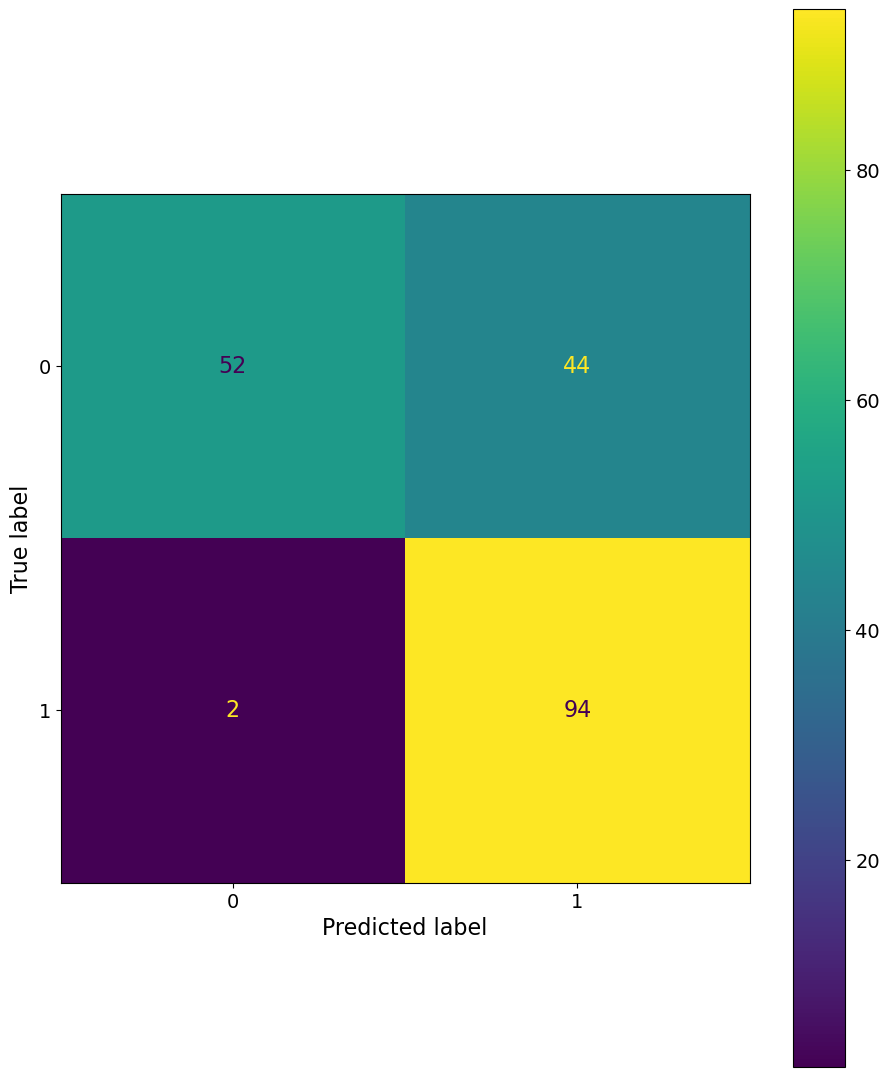

kettle
gadf
XGBoost
0

f1_score: 0.7811550151975684
accuracy: 0.78125
              precision    recall  f1-score   support

       False       0.77      0.80      0.79        96
        True       0.79      0.76      0.78        96

    accuracy                           0.78       192
   macro avg       0.78      0.78      0.78       192
weighted avg       0.78      0.78      0.78       192



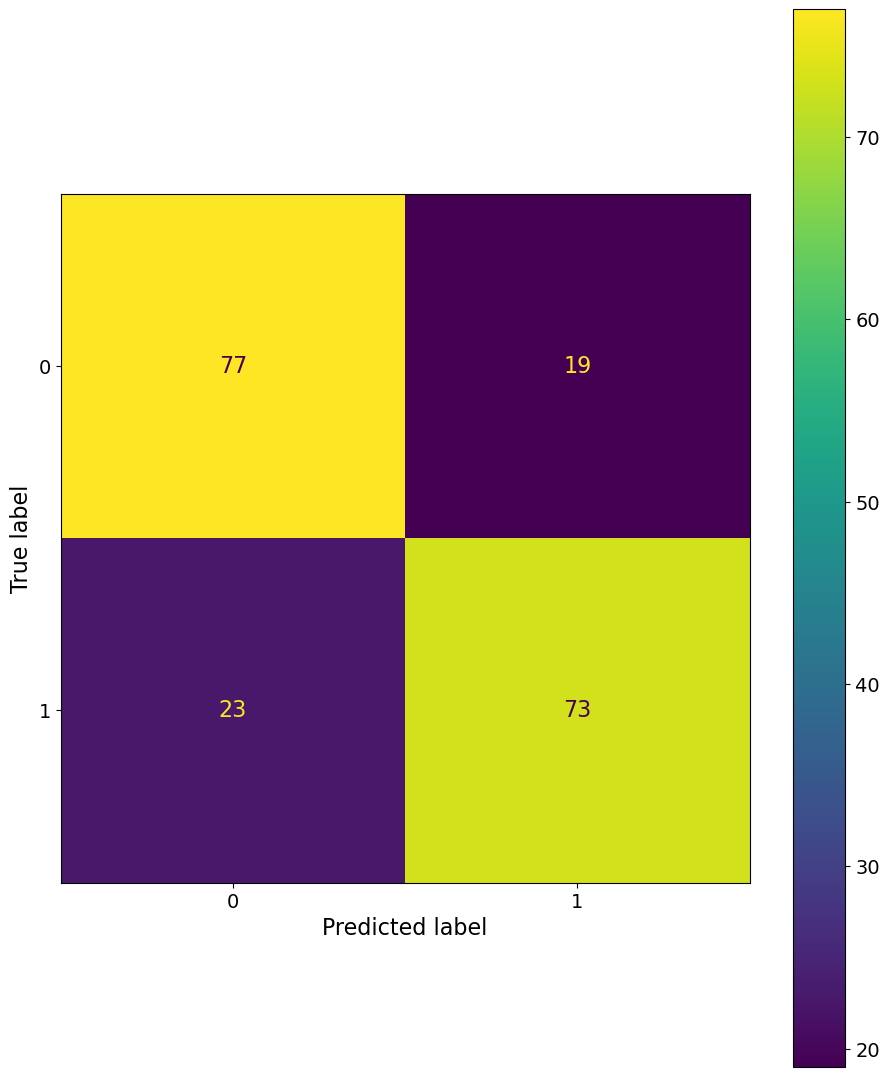

kettle
gadf
SVM
0

f1_score: 0.6146541652937123
accuracy: 0.6510416666666666
              precision    recall  f1-score   support

       False       0.59      0.96      0.73        96
        True       0.89      0.34      0.50        96

    accuracy                           0.65       192
   macro avg       0.74      0.65      0.61       192
weighted avg       0.74      0.65      0.61       192



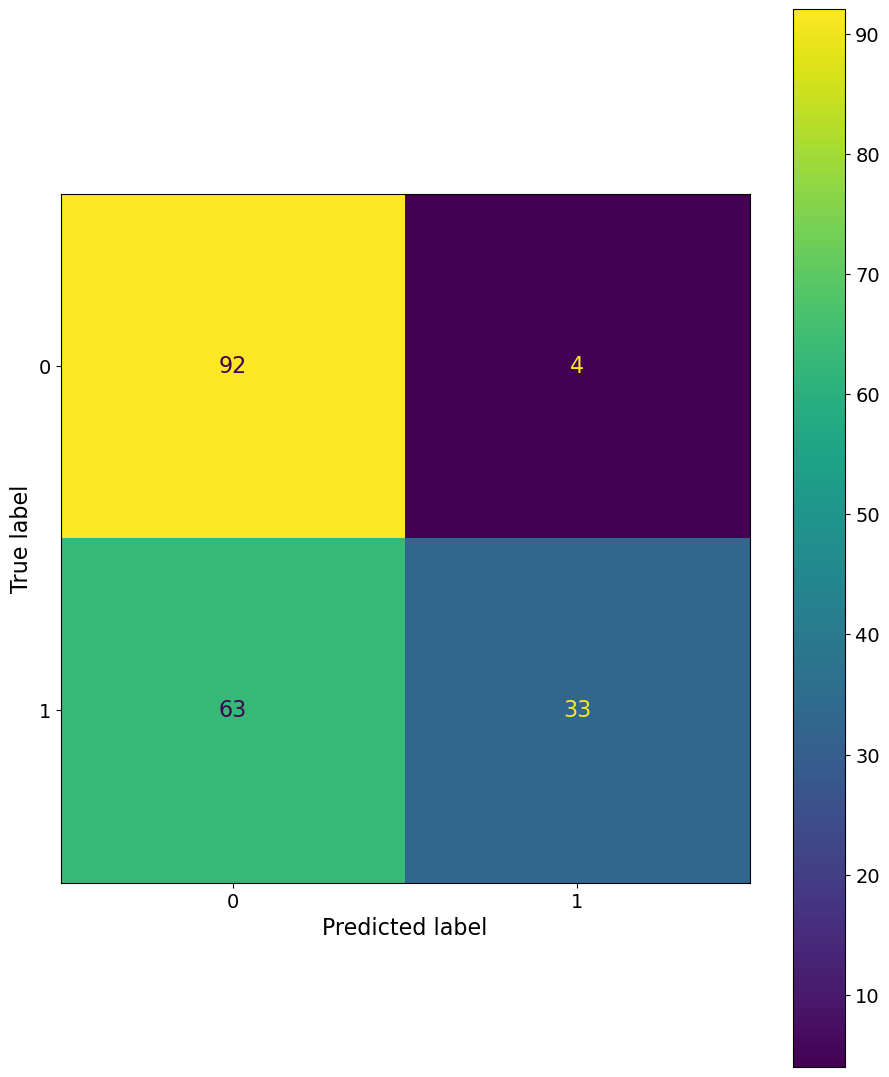

kettle
mtf
MLP
0

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
f1_score: 0.9687466087900163
accuracy: 0.96875
              precision    recall  f1-score   support

       False       0.98      0.96      0.97        96
        True       0.96      0.98      0.97        96

    accuracy                           0.97       192
   macro avg       0.97      0.97      0.97       192
weighted avg       0.97      0.97      0.97       192



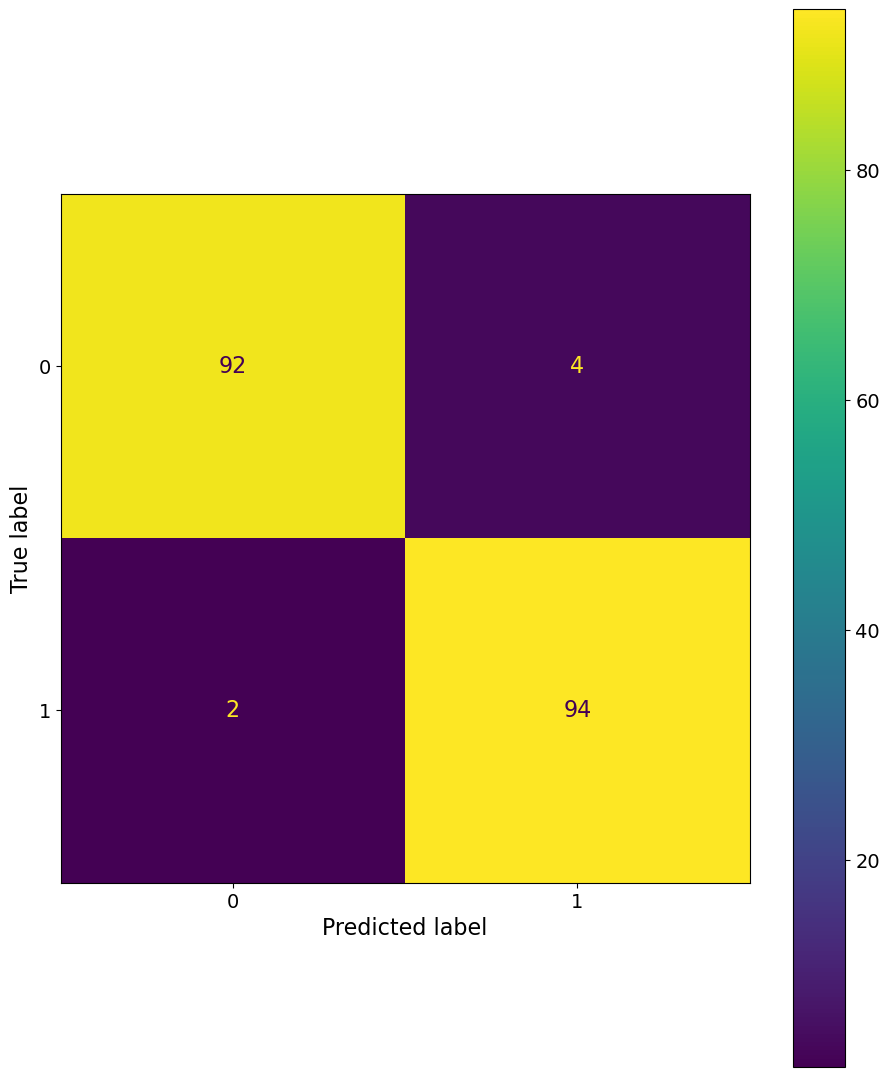

kettle
mtf
MLP
1

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
f1_score: 0.9739576268887502
accuracy: 0.9739583333333334
              precision    recall  f1-score   support

       False       0.98      0.97      0.97        96
        True       0.97      0.98      0.97        96

    accuracy                           0.97       192
   macro avg       0.97      0.97      0.97       192
weighted avg       0.97      0.97      0.97       192



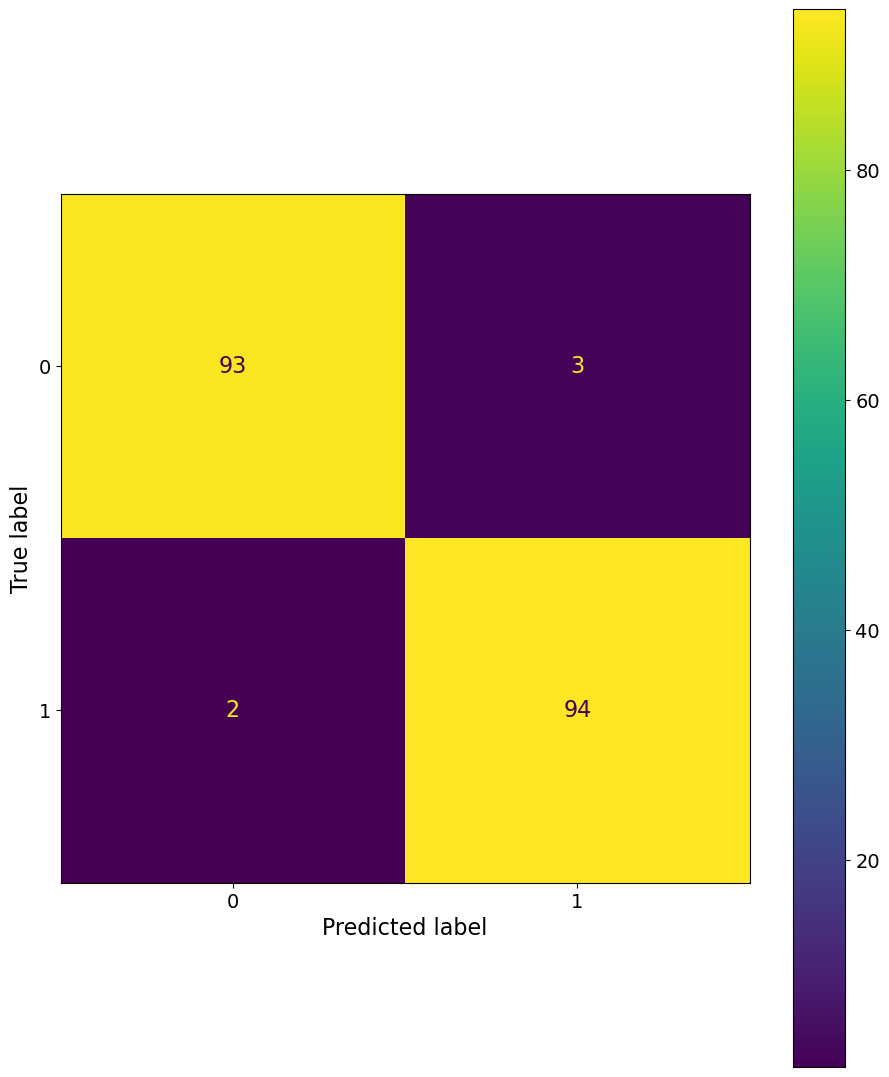

kettle
mtf
MLP
2

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
f1_score: 0.9687466087900163
accuracy: 0.96875
              precision    recall  f1-score   support

       False       0.98      0.96      0.97        96
        True       0.96      0.98      0.97        96

    accuracy                           0.97       192
   macro avg       0.97      0.97      0.97       192
weighted avg       0.97      0.97      0.97       192



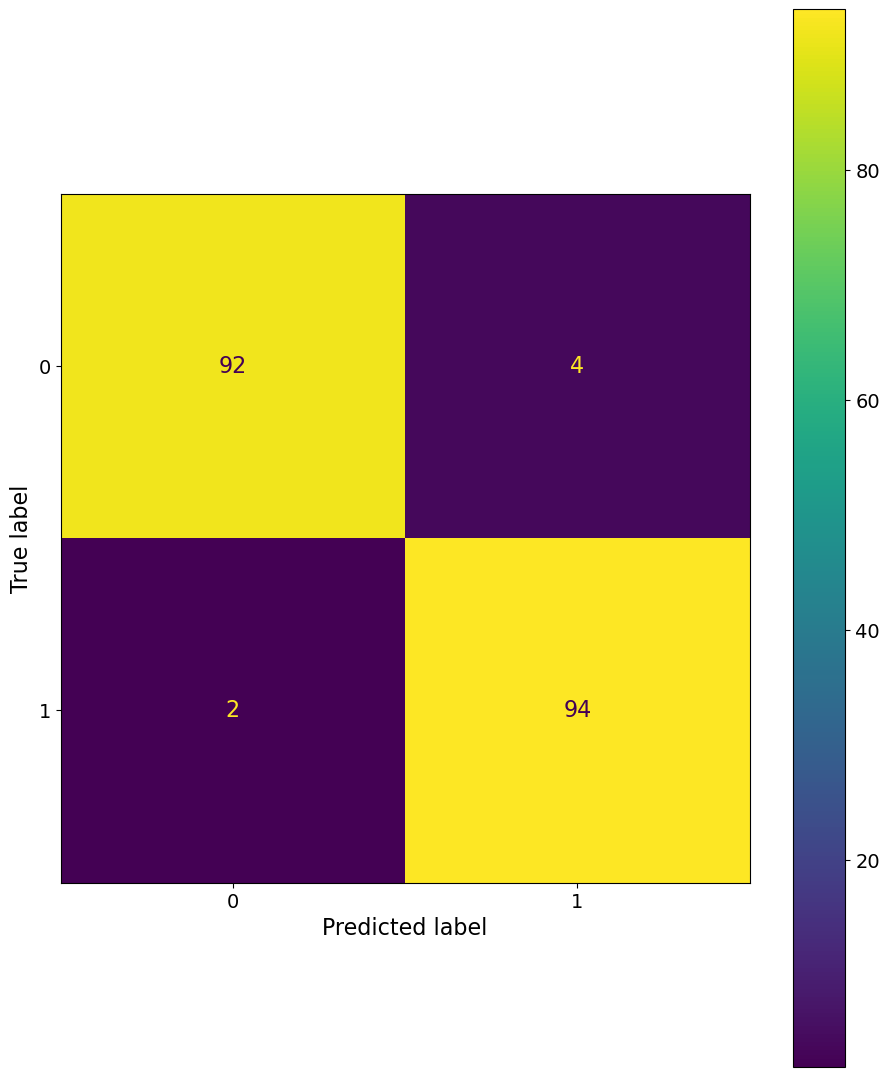

kettle
mtf
MLP
3

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
f1_score: 0.9687466087900163
accuracy: 0.96875
              precision    recall  f1-score   support

       False       0.98      0.96      0.97        96
        True       0.96      0.98      0.97        96

    accuracy                           0.97       192
   macro avg       0.97      0.97      0.97       192
weighted avg       0.97      0.97      0.97       192



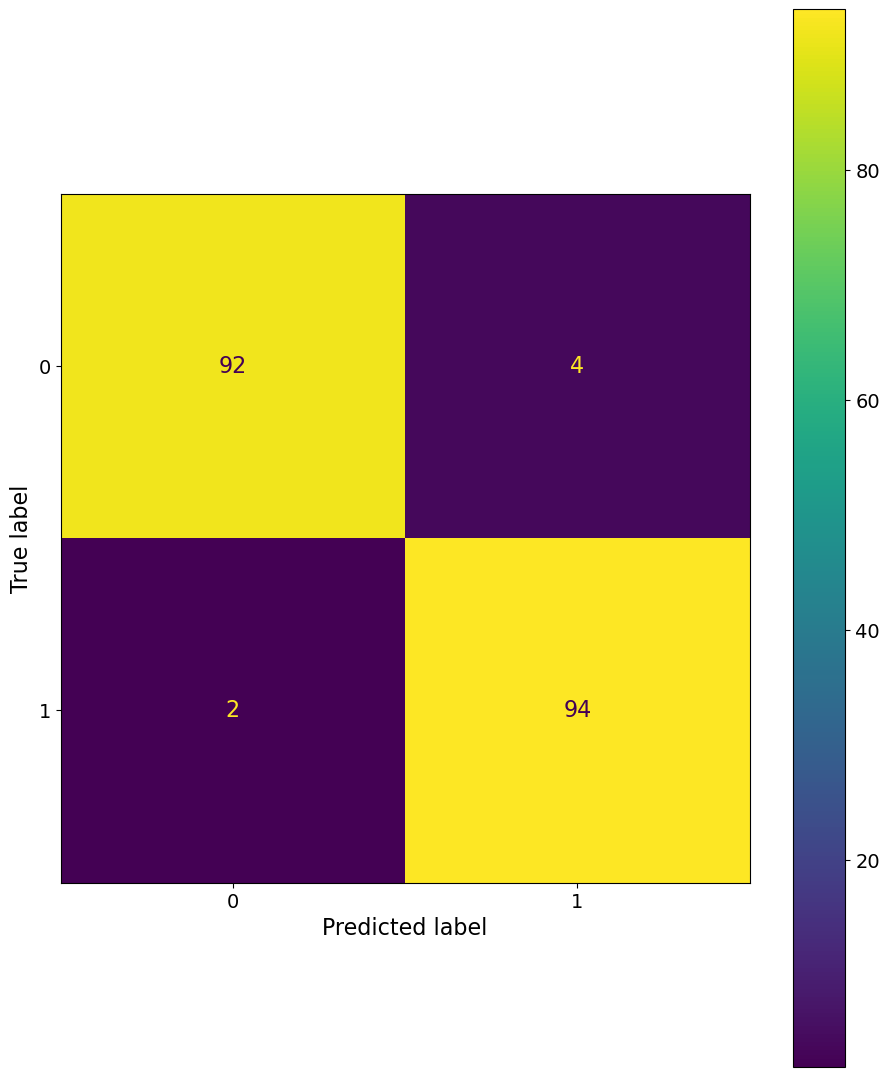

kettle
mtf
MLP
4

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
f1_score: 0.9687466087900163
accuracy: 0.96875
              precision    recall  f1-score   support

       False       0.98      0.96      0.97        96
        True       0.96      0.98      0.97        96

    accuracy                           0.97       192
   macro avg       0.97      0.97      0.97       192
weighted avg       0.97      0.97      0.97       192



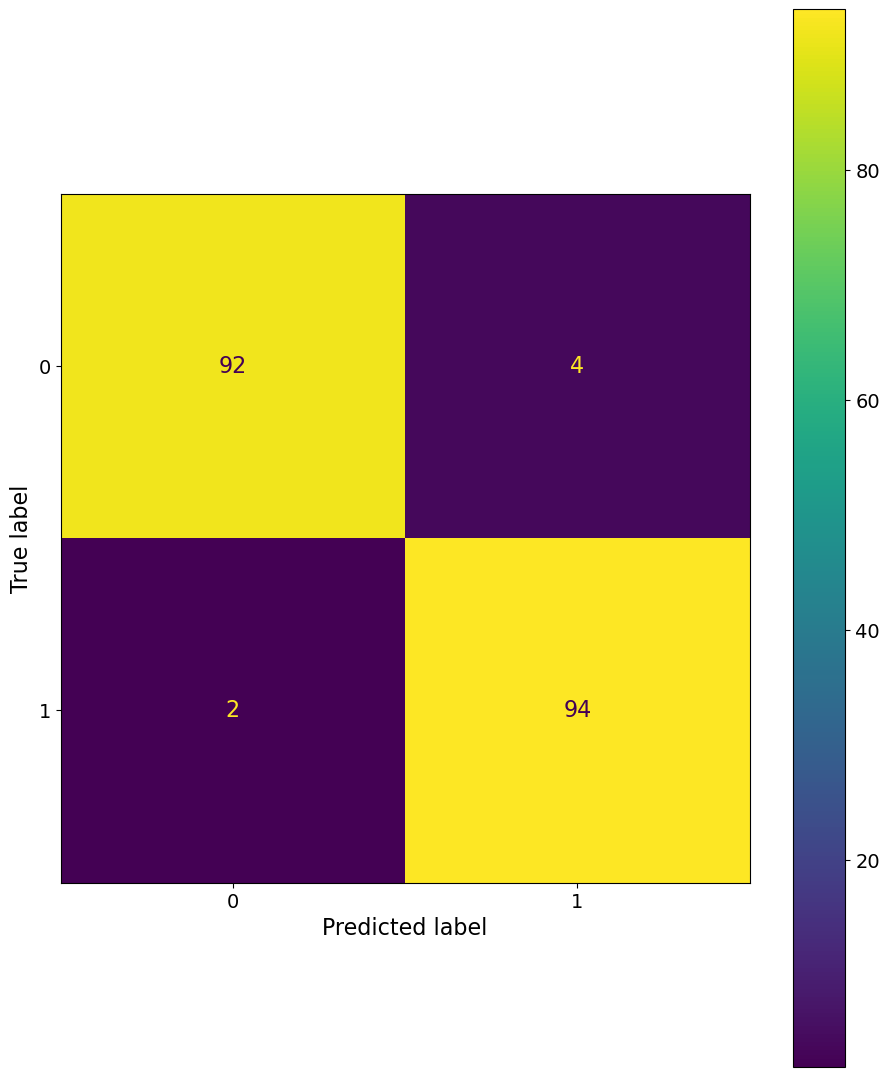

kettle
mtf
XGBoost
0

f1_score: 0.96875
accuracy: 0.96875
              precision    recall  f1-score   support

       False       0.97      0.97      0.97        96
        True       0.97      0.97      0.97        96

    accuracy                           0.97       192
   macro avg       0.97      0.97      0.97       192
weighted avg       0.97      0.97      0.97       192



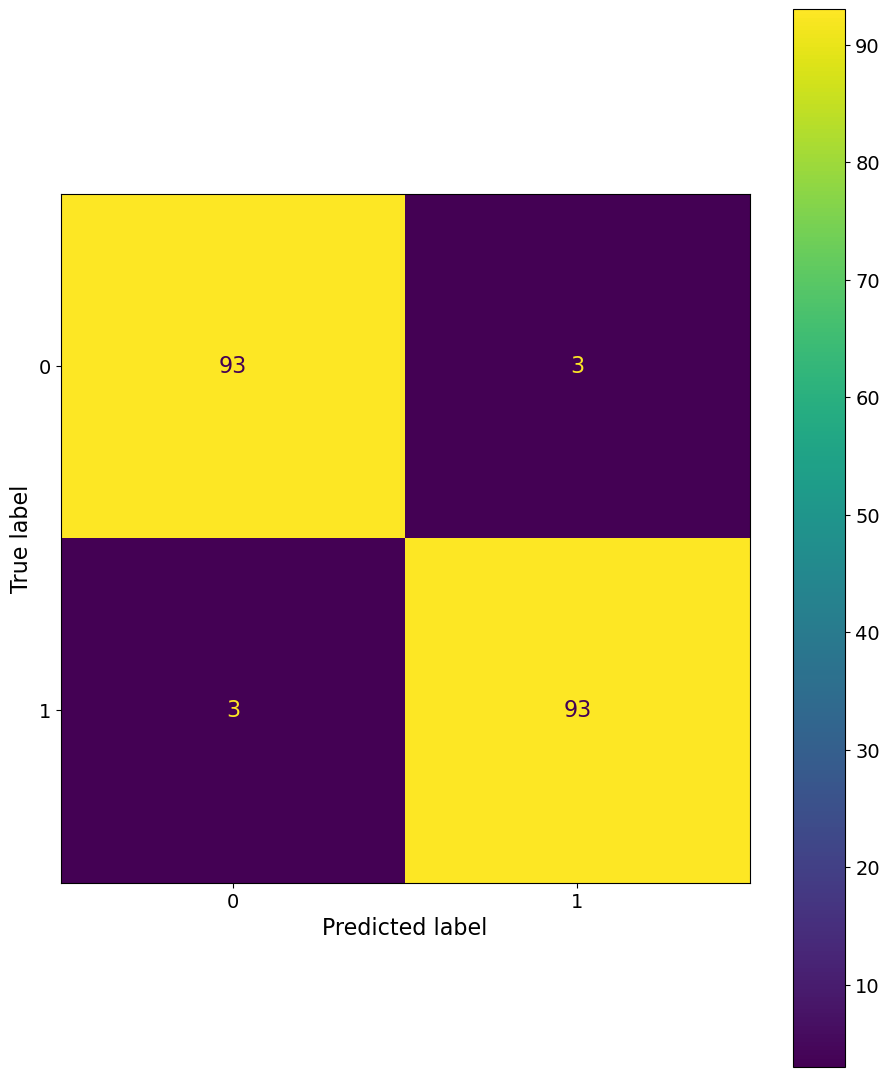

kettle
mtf
SVM
0

f1_score: 0.9635406776442503
accuracy: 0.9635416666666666
              precision    recall  f1-score   support

       False       0.96      0.97      0.96        96
        True       0.97      0.96      0.96        96

    accuracy                           0.96       192
   macro avg       0.96      0.96      0.96       192
weighted avg       0.96      0.96      0.96       192



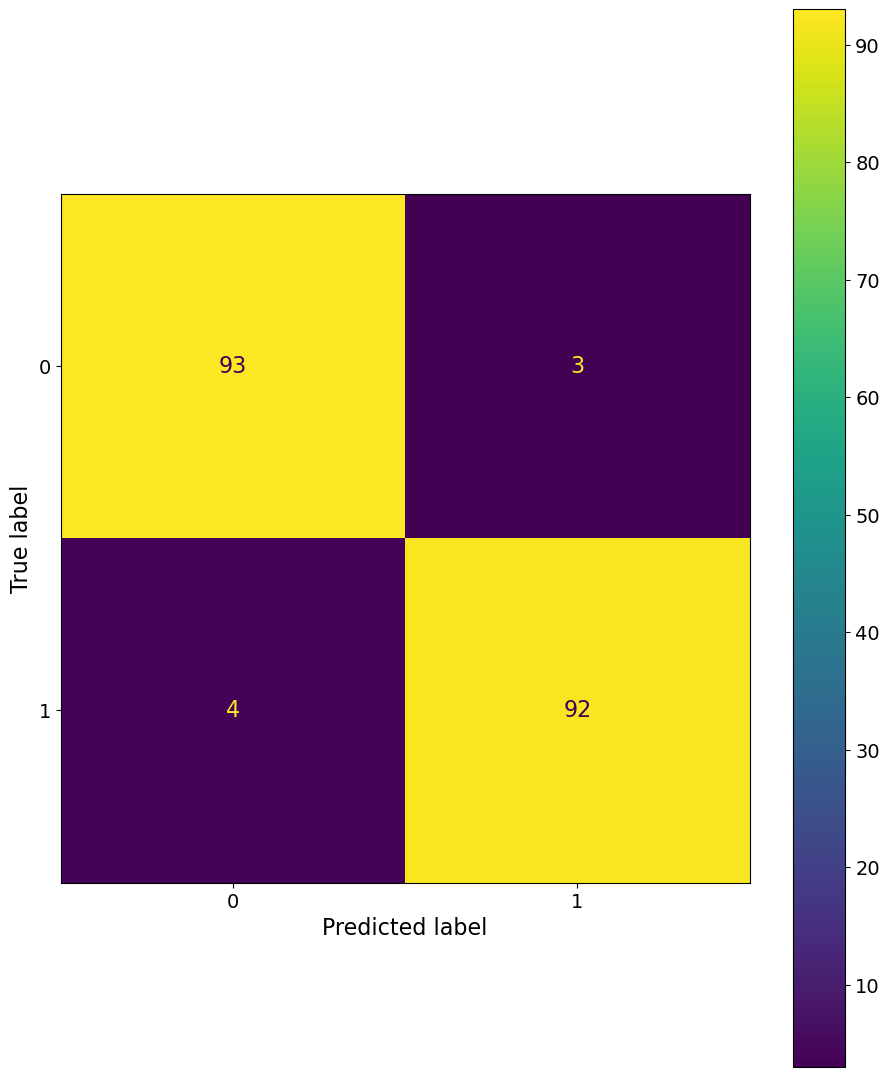

kettle
rp
MLP
0

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
f1_score: 0.9531237283997505
accuracy: 0.953125
              precision    recall  f1-score   support

       False       0.96      0.95      0.95        96
        True       0.95      0.96      0.95        96

    accuracy                           0.95       192
   macro avg       0.95      0.95      0.95       192
weighted avg       0.95      0.95      0.95       192



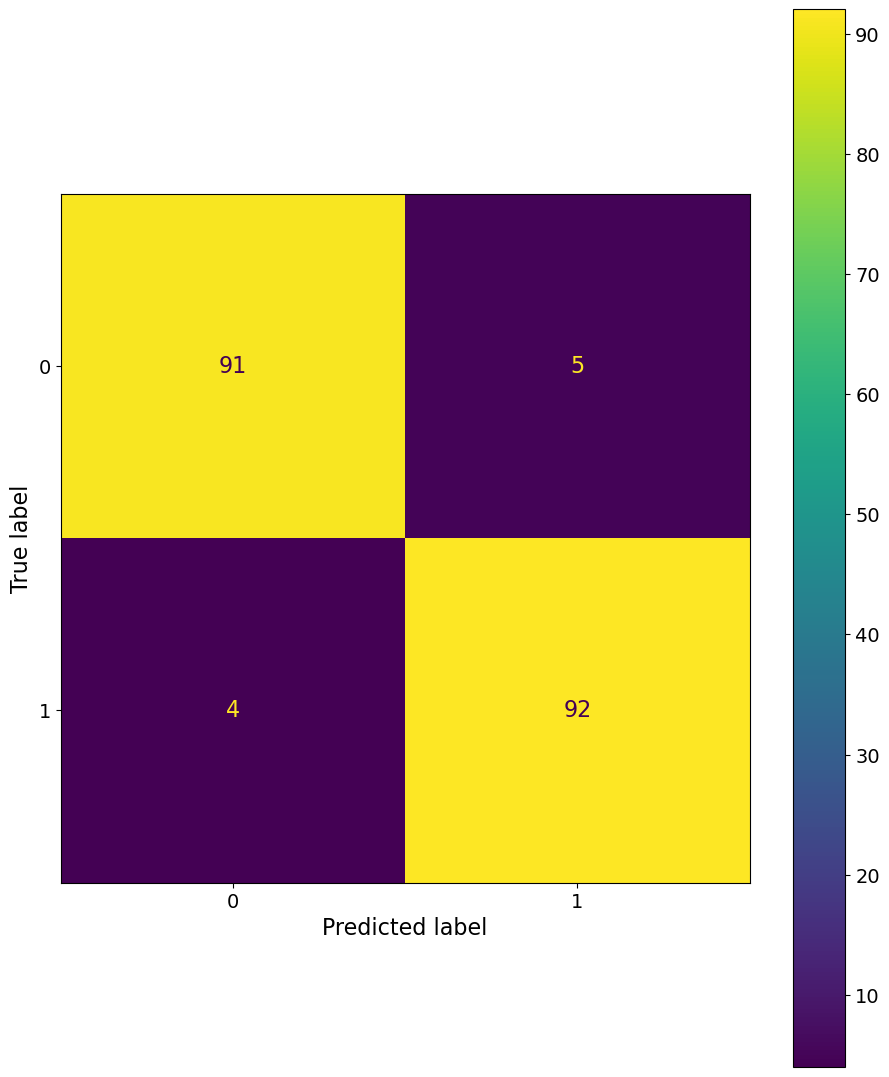

kettle
rp
MLP
1

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
f1_score: 0.9479166666666666
accuracy: 0.9479166666666666
              precision    recall  f1-score   support

       False       0.95      0.95      0.95        96
        True       0.95      0.95      0.95        96

    accuracy                           0.95       192
   macro avg       0.95      0.95      0.95       192
weighted avg       0.95      0.95      0.95       192



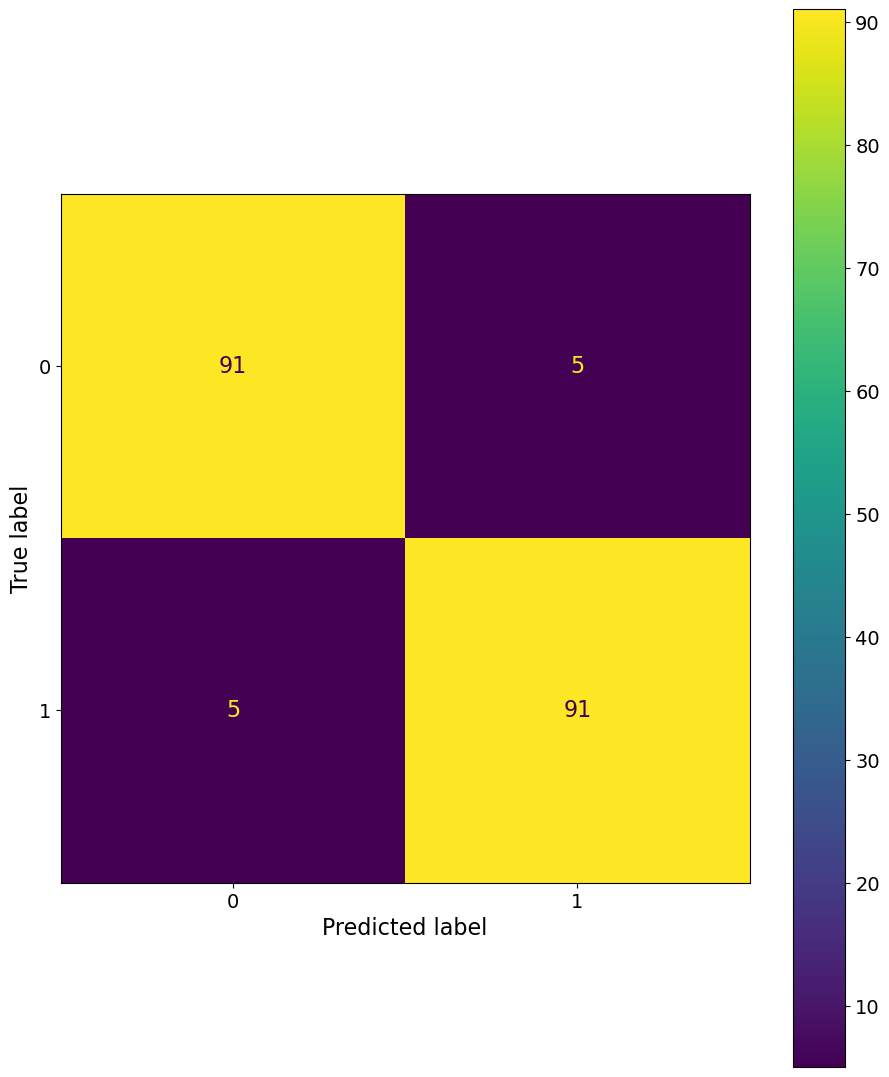

kettle
rp
MLP
2

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
f1_score: 0.9479166666666666
accuracy: 0.9479166666666666
              precision    recall  f1-score   support

       False       0.95      0.95      0.95        96
        True       0.95      0.95      0.95        96

    accuracy                           0.95       192
   macro avg       0.95      0.95      0.95       192
weighted avg       0.95      0.95      0.95       192



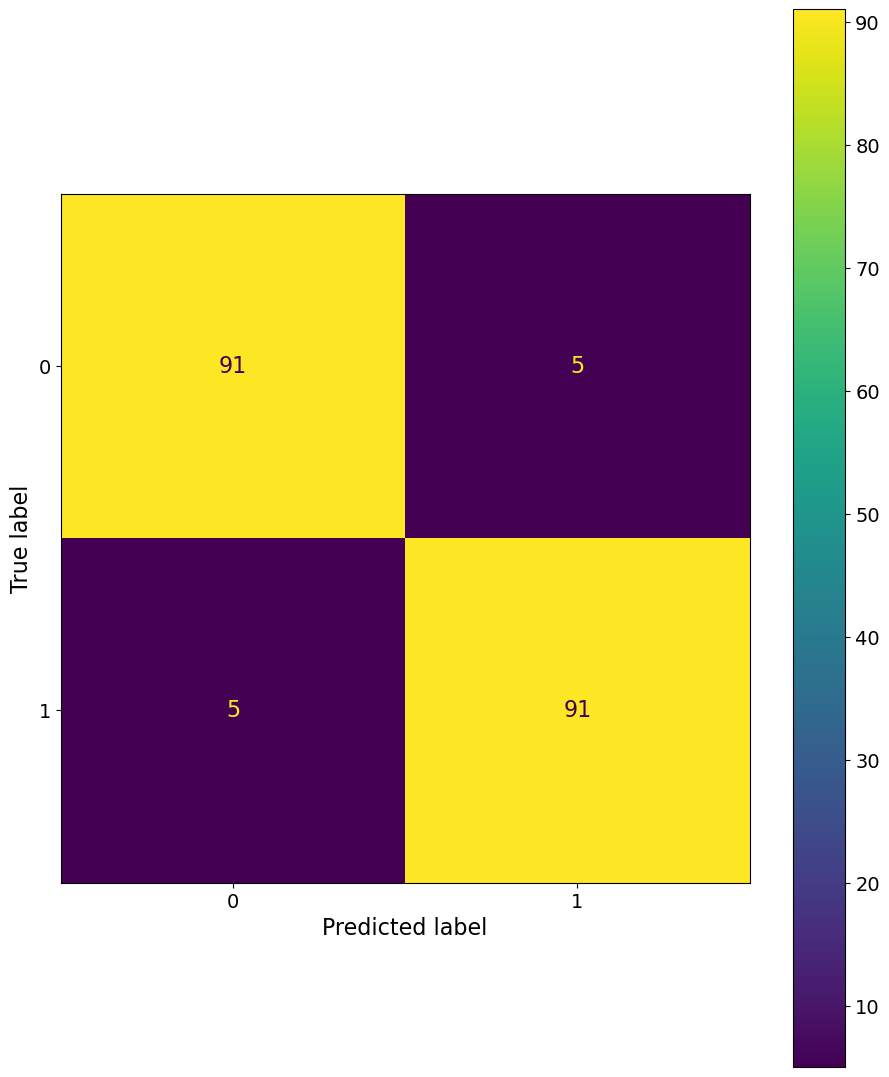

kettle
rp
MLP
3

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
f1_score: 0.9479166666666666
accuracy: 0.9479166666666666
              precision    recall  f1-score   support

       False       0.95      0.95      0.95        96
        True       0.95      0.95      0.95        96

    accuracy                           0.95       192
   macro avg       0.95      0.95      0.95       192
weighted avg       0.95      0.95      0.95       192



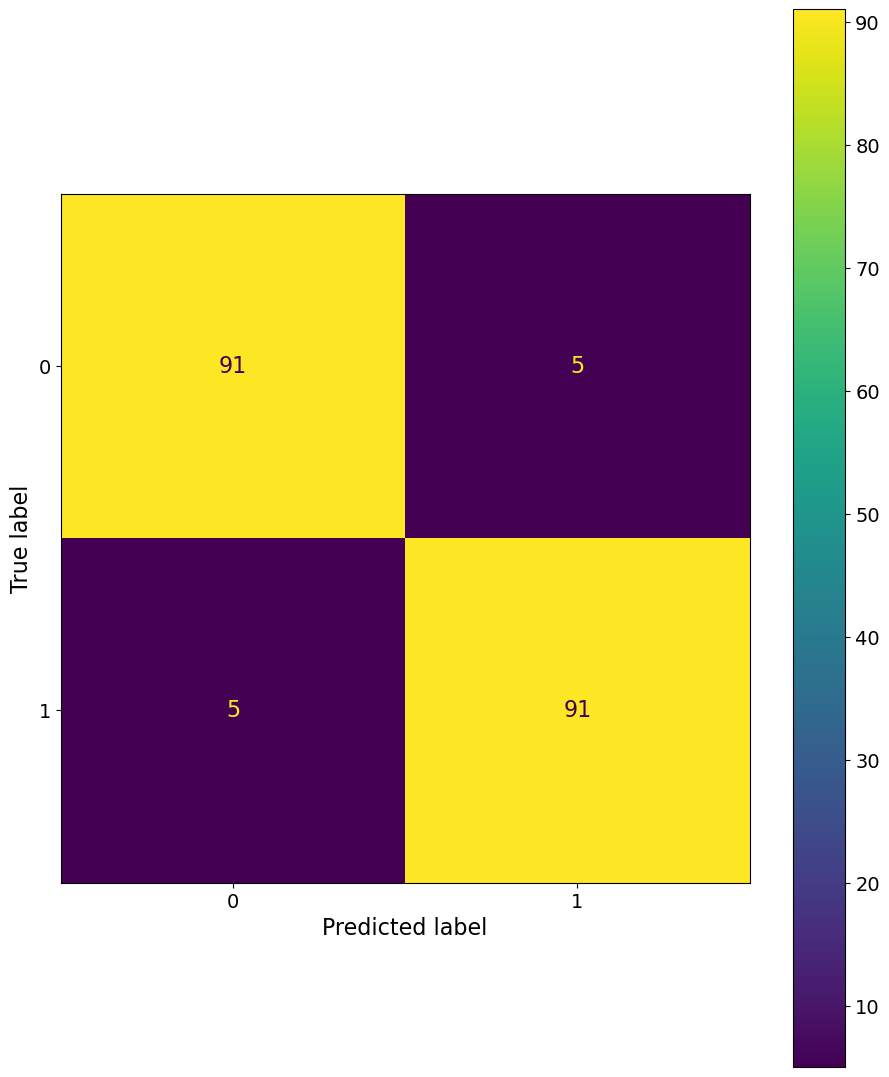

kettle
rp
MLP
4

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
f1_score: 0.9479166666666666
accuracy: 0.9479166666666666
              precision    recall  f1-score   support

       False       0.95      0.95      0.95        96
        True       0.95      0.95      0.95        96

    accuracy                           0.95       192
   macro avg       0.95      0.95      0.95       192
weighted avg       0.95      0.95      0.95       192



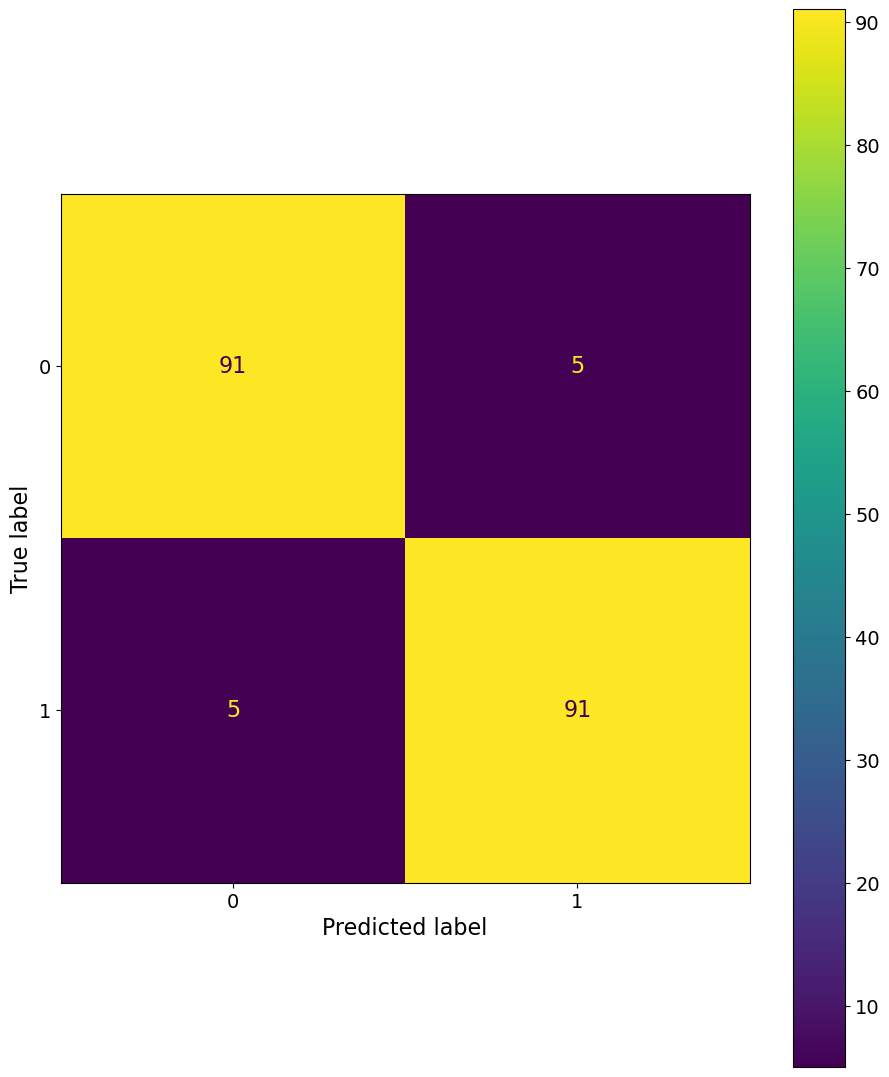

kettle
rp
XGBoost
0

f1_score: 0.9530931892830967
accuracy: 0.953125
              precision    recall  f1-score   support

       False       0.98      0.93      0.95        96
        True       0.93      0.98      0.95        96

    accuracy                           0.95       192
   macro avg       0.95      0.95      0.95       192
weighted avg       0.95      0.95      0.95       192



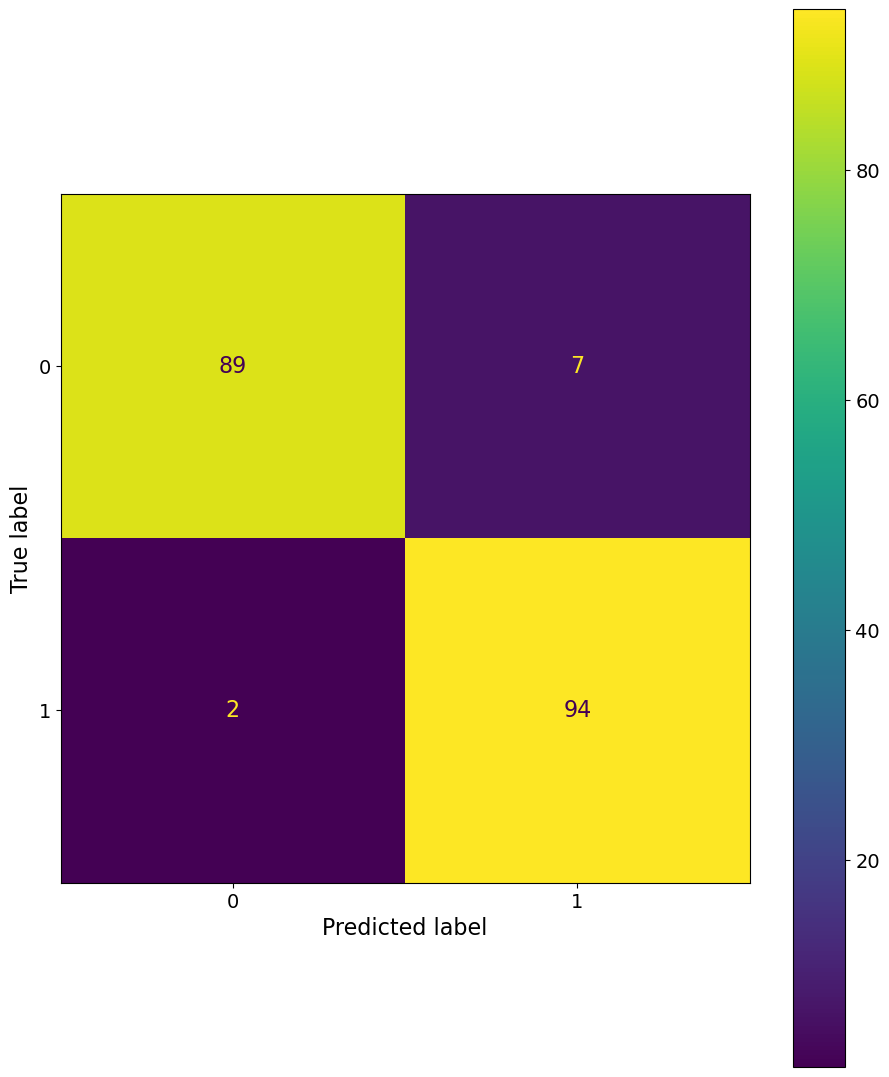

kettle
rp
SVM
0

f1_score: 0.9426943426943426
accuracy: 0.9427083333333334
              precision    recall  f1-score   support

       False       0.96      0.93      0.94        96
        True       0.93      0.96      0.94        96

    accuracy                           0.94       192
   macro avg       0.94      0.94      0.94       192
weighted avg       0.94      0.94      0.94       192



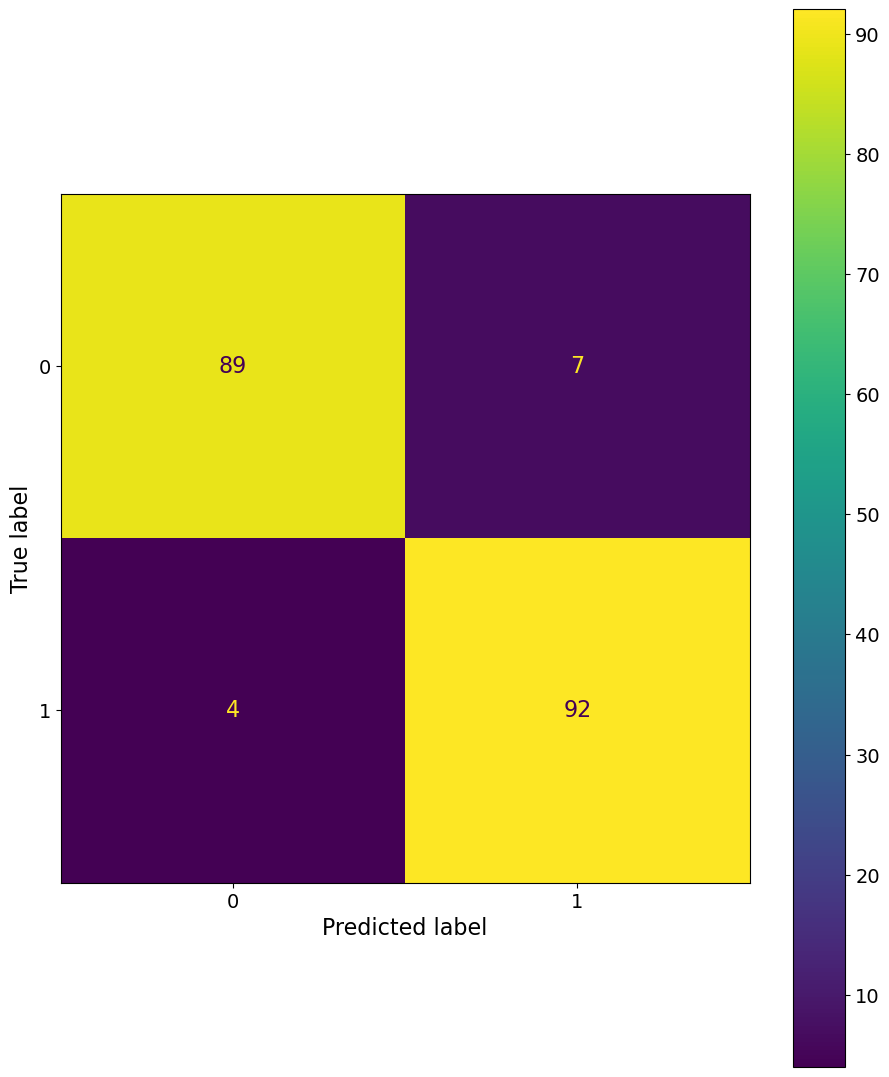

kettle
tbg
MLP
0

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
f1_score: 0.9739576268887502
accuracy: 0.9739583333333334
              precision    recall  f1-score   support

       False       0.98      0.97      0.97        96
        True       0.97      0.98      0.97        96

    accuracy                           0.97       192
   macro avg       0.97      0.97      0.97       192
weighted avg       0.97      0.97      0.97       192



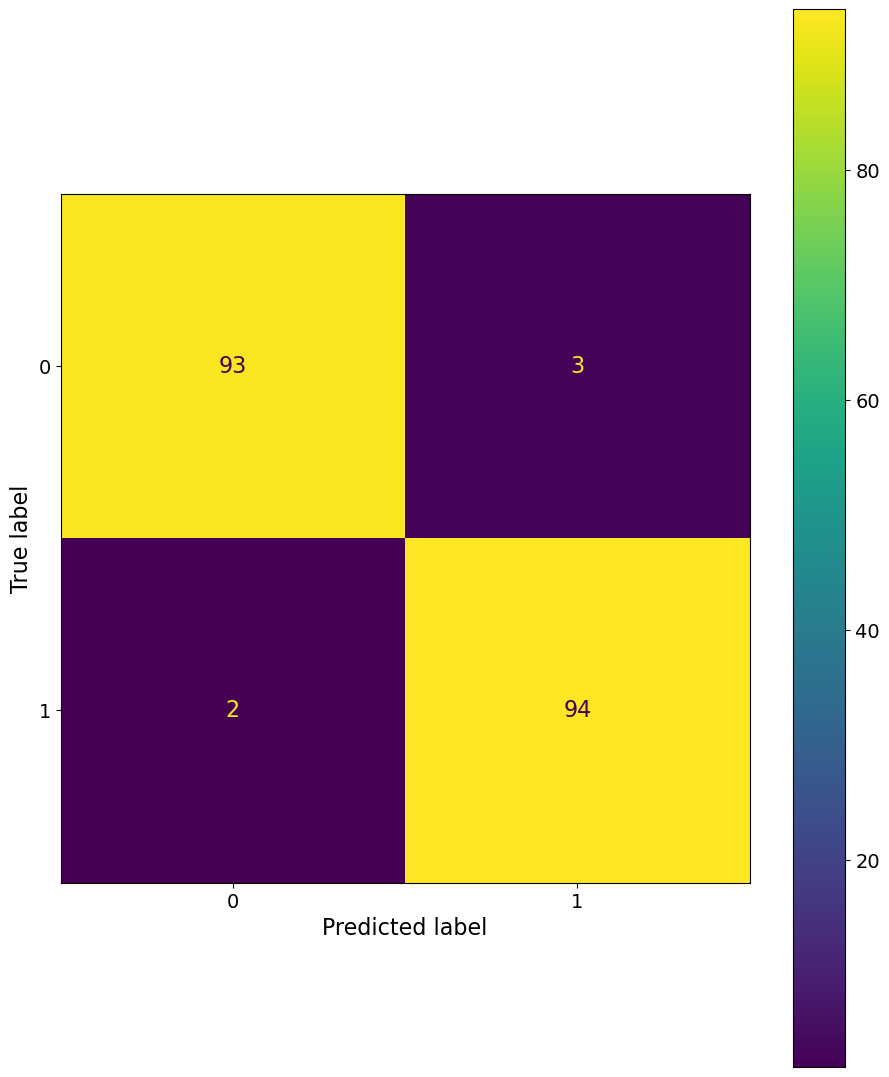

kettle
tbg
MLP
1

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
f1_score: 0.9791666666666666
accuracy: 0.9791666666666666
              precision    recall  f1-score   support

       False       0.98      0.98      0.98        96
        True       0.98      0.98      0.98        96

    accuracy                           0.98       192
   macro avg       0.98      0.98      0.98       192
weighted avg       0.98      0.98      0.98       192



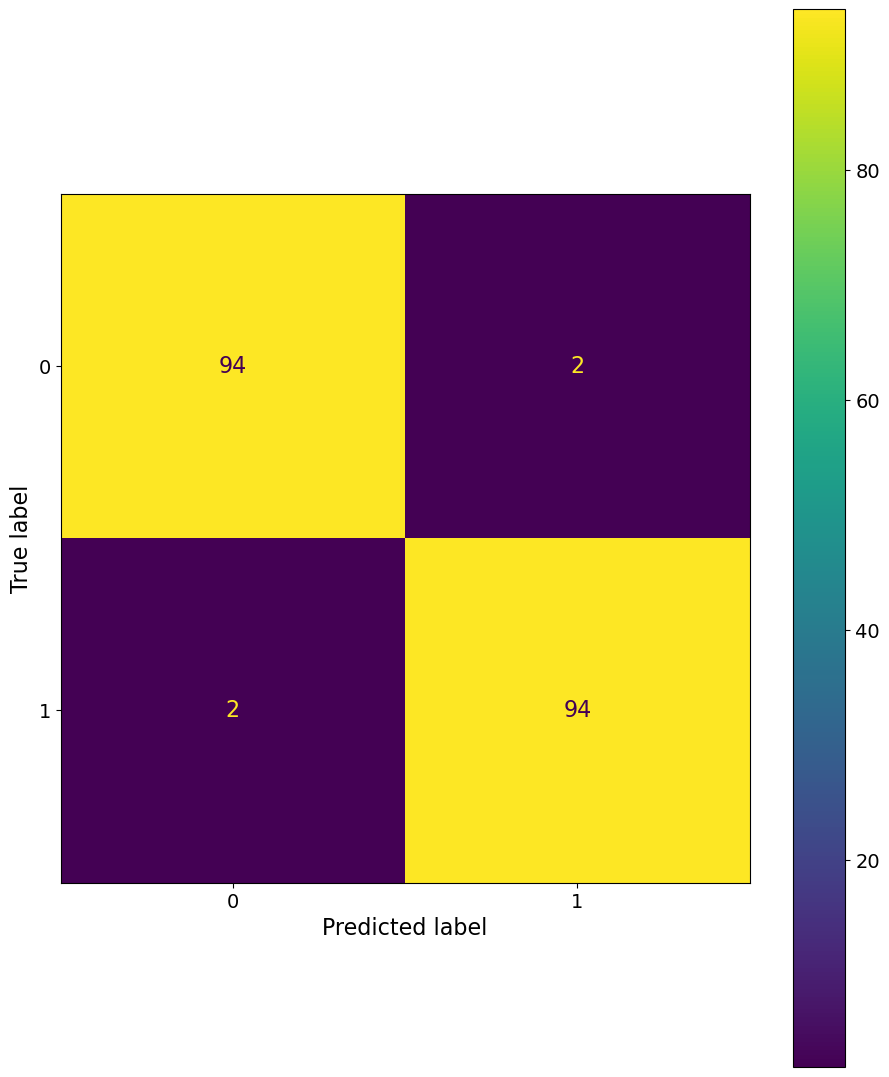

kettle
tbg
MLP
2

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
f1_score: 0.9739576268887502
accuracy: 0.9739583333333334
              precision    recall  f1-score   support

       False       0.98      0.97      0.97        96
        True       0.97      0.98      0.97        96

    accuracy                           0.97       192
   macro avg       0.97      0.97      0.97       192
weighted avg       0.97      0.97      0.97       192



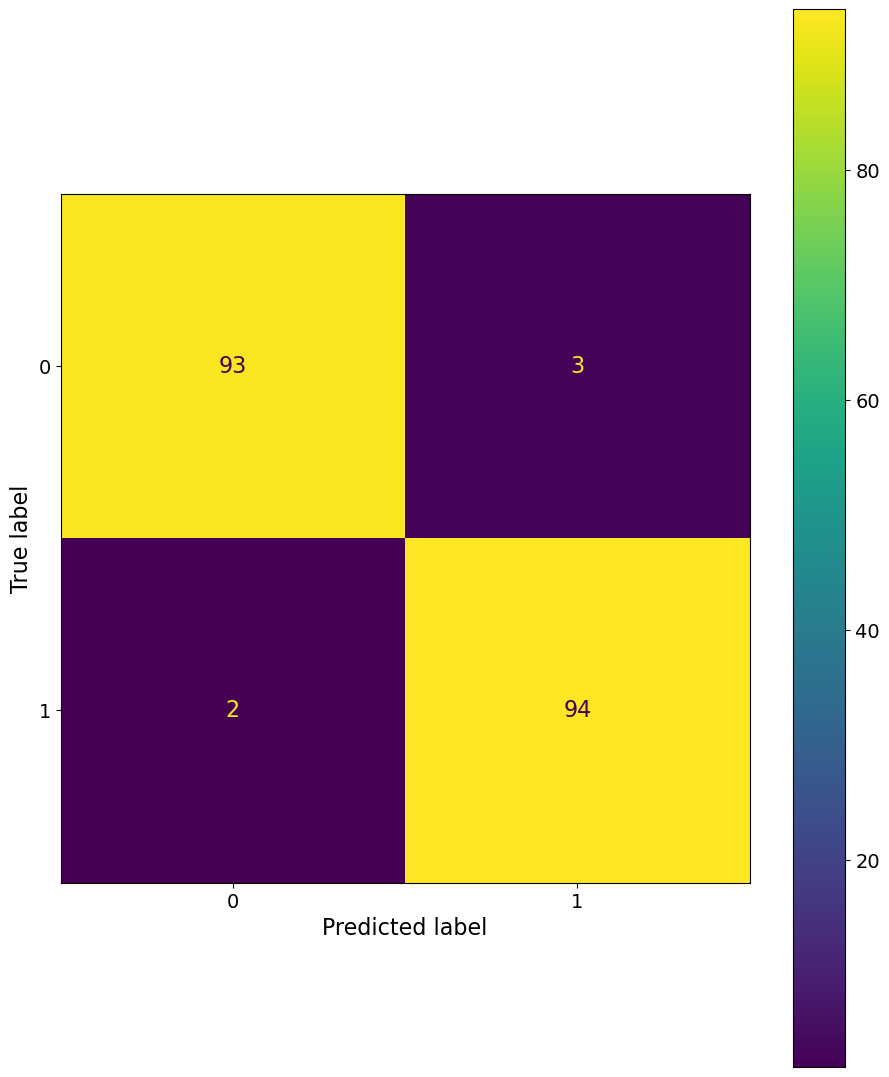

kettle
tbg
MLP
3

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
f1_score: 0.96875
accuracy: 0.96875
              precision    recall  f1-score   support

       False       0.97      0.97      0.97        96
        True       0.97      0.97      0.97        96

    accuracy                           0.97       192
   macro avg       0.97      0.97      0.97       192
weighted avg       0.97      0.97      0.97       192



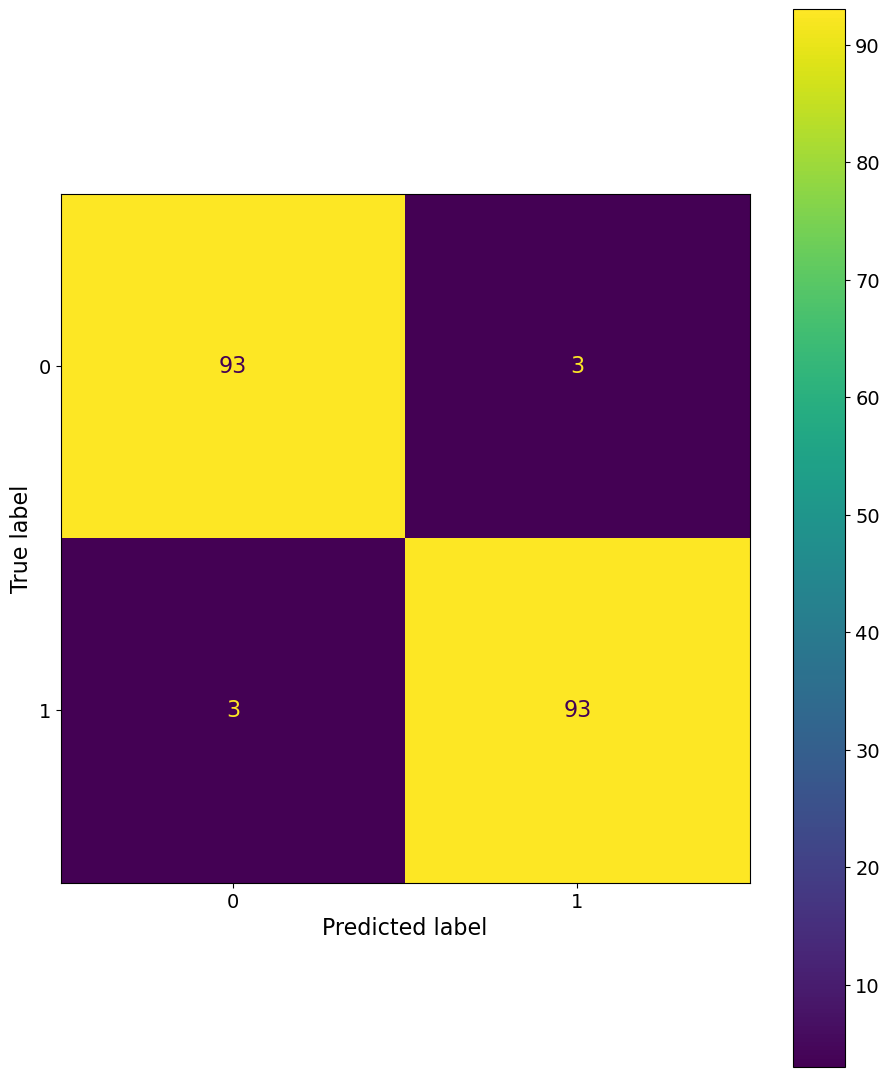

kettle
tbg
MLP
4

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
f1_score: 0.9687466087900163
accuracy: 0.96875
              precision    recall  f1-score   support

       False       0.96      0.98      0.97        96
        True       0.98      0.96      0.97        96

    accuracy                           0.97       192
   macro avg       0.97      0.97      0.97       192
weighted avg       0.97      0.97      0.97       192



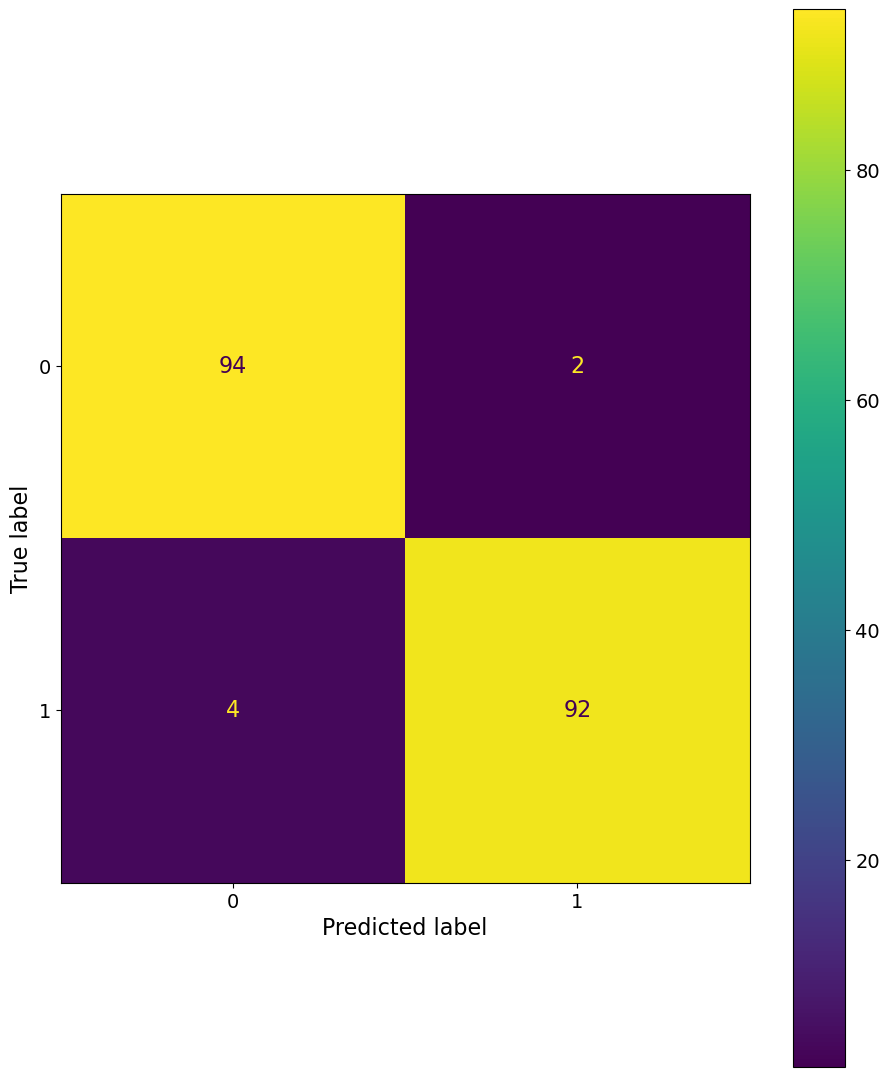

kettle
tbg
XGBoost
0

f1_score: 0.9739576268887502
accuracy: 0.9739583333333334
              precision    recall  f1-score   support

       False       0.98      0.97      0.97        96
        True       0.97      0.98      0.97        96

    accuracy                           0.97       192
   macro avg       0.97      0.97      0.97       192
weighted avg       0.97      0.97      0.97       192



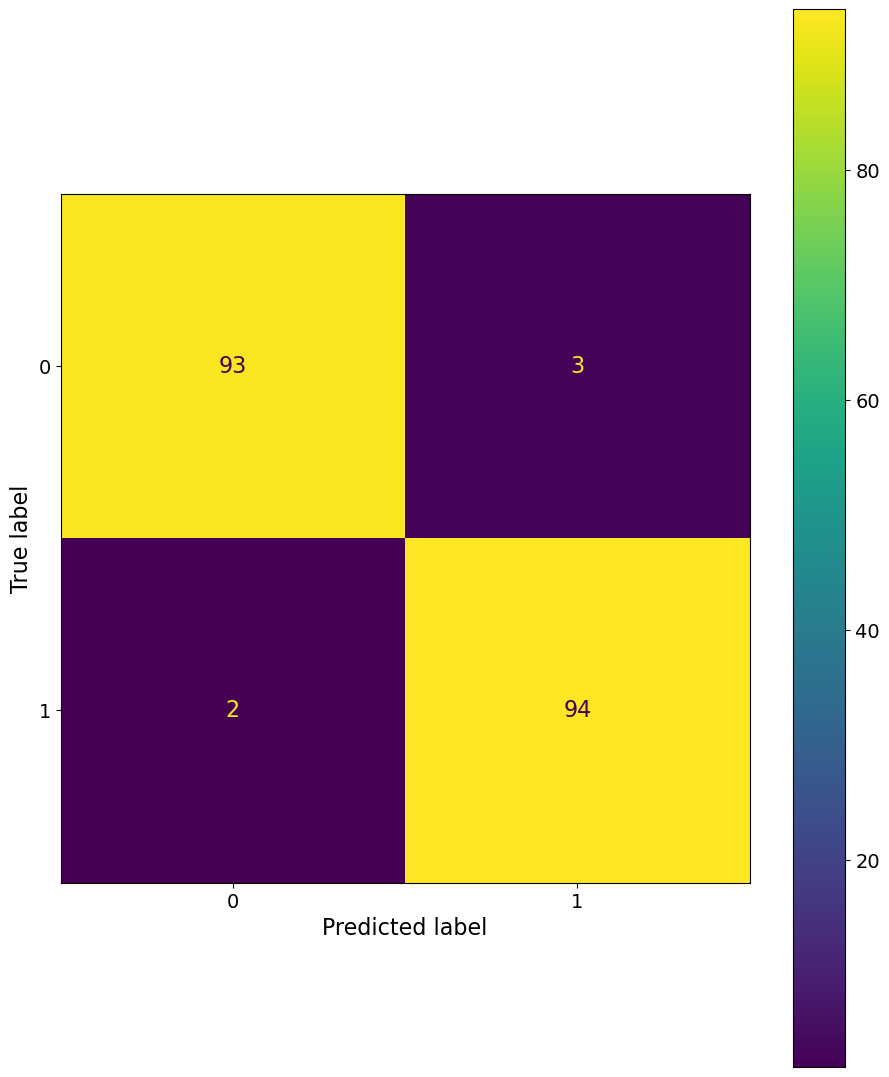

kettle
tbg
SVM
0

f1_score: 0.9739576268887502
accuracy: 0.9739583333333334
              precision    recall  f1-score   support

       False       0.98      0.97      0.97        96
        True       0.97      0.98      0.97        96

    accuracy                           0.97       192
   macro avg       0.97      0.97      0.97       192
weighted avg       0.97      0.97      0.97       192



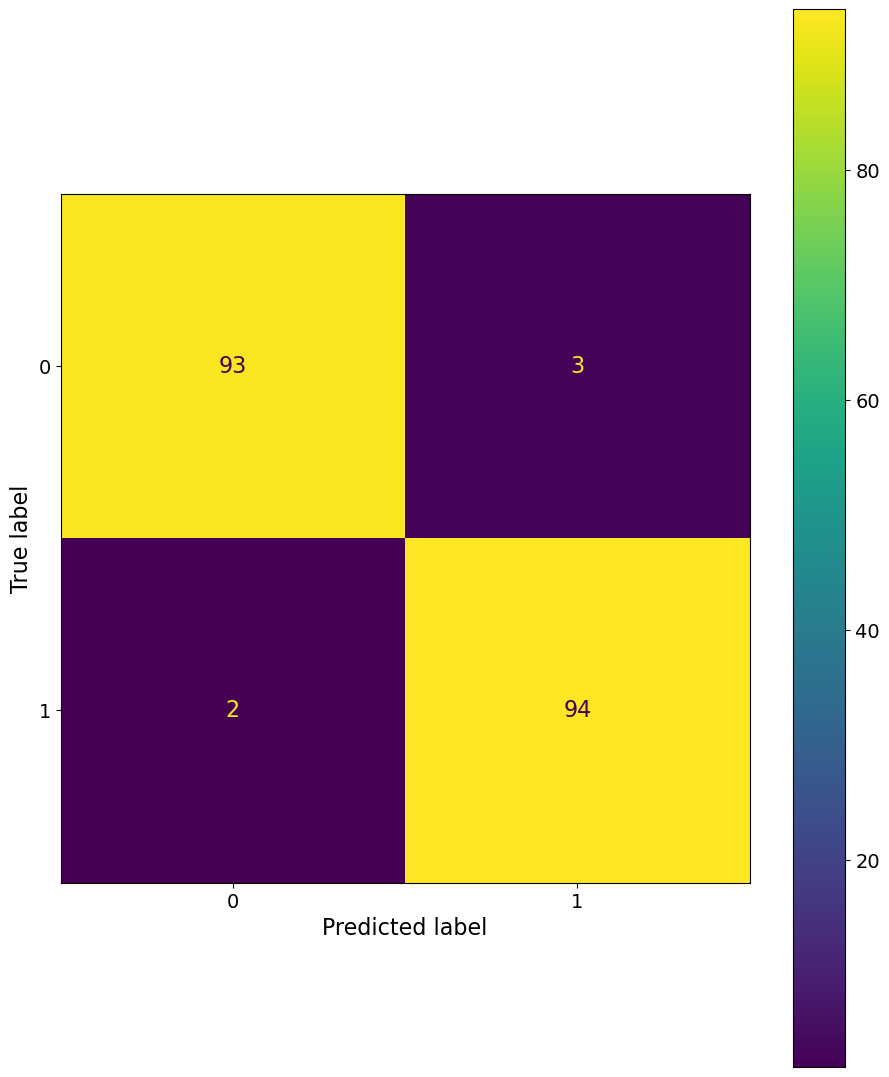

microwave
gasf
MLP
0

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
f1_score: 0.7614035087719297
accuracy: 0.7647058823529411
              precision    recall  f1-score   support

       False       0.71      0.88      0.79        51
        True       0.85      0.65      0.73        51

    accuracy                           0.76       102
   macro avg       0.78      0.76      0.76       102
weighted avg       0.78      0.76      0.76       102



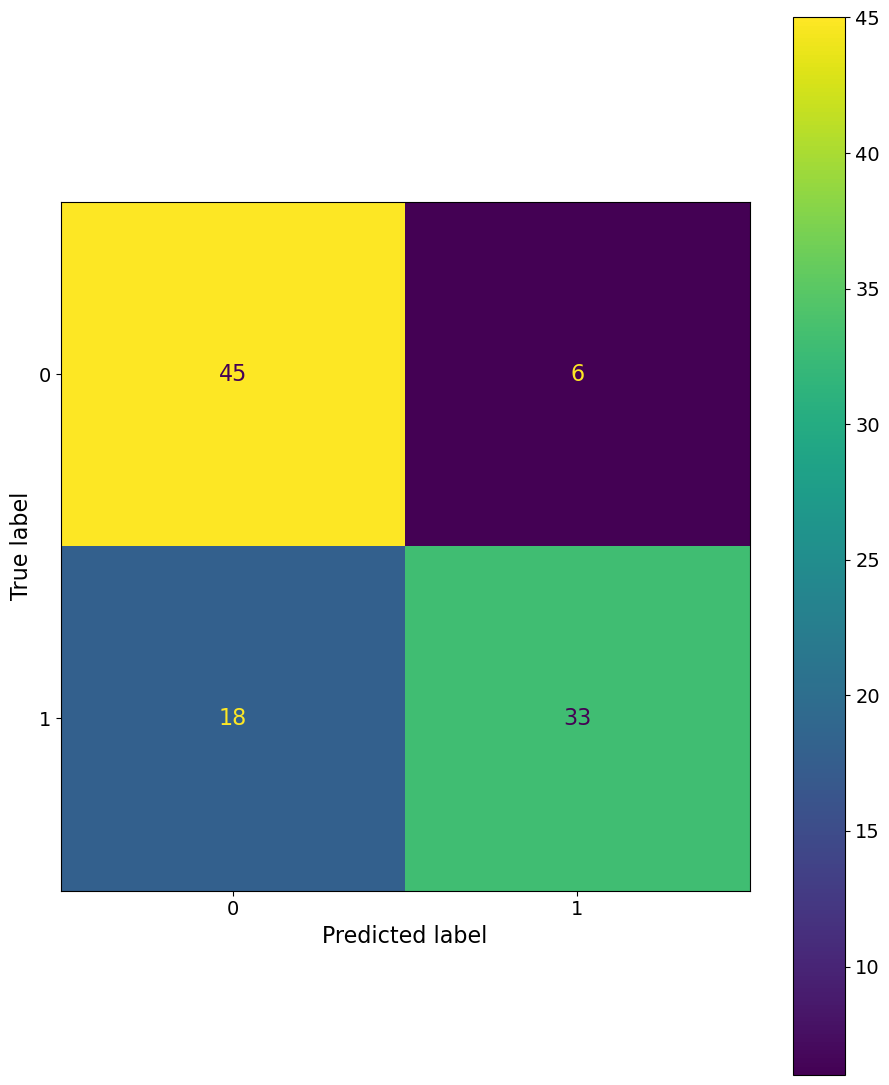

microwave
gasf
MLP
1

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
f1_score: 0.7718564621219488
accuracy: 0.7745098039215687
              precision    recall  f1-score   support

       False       0.73      0.88      0.80        51
        True       0.85      0.67      0.75        51

    accuracy                           0.77       102
   macro avg       0.79      0.77      0.77       102
weighted avg       0.79      0.77      0.77       102



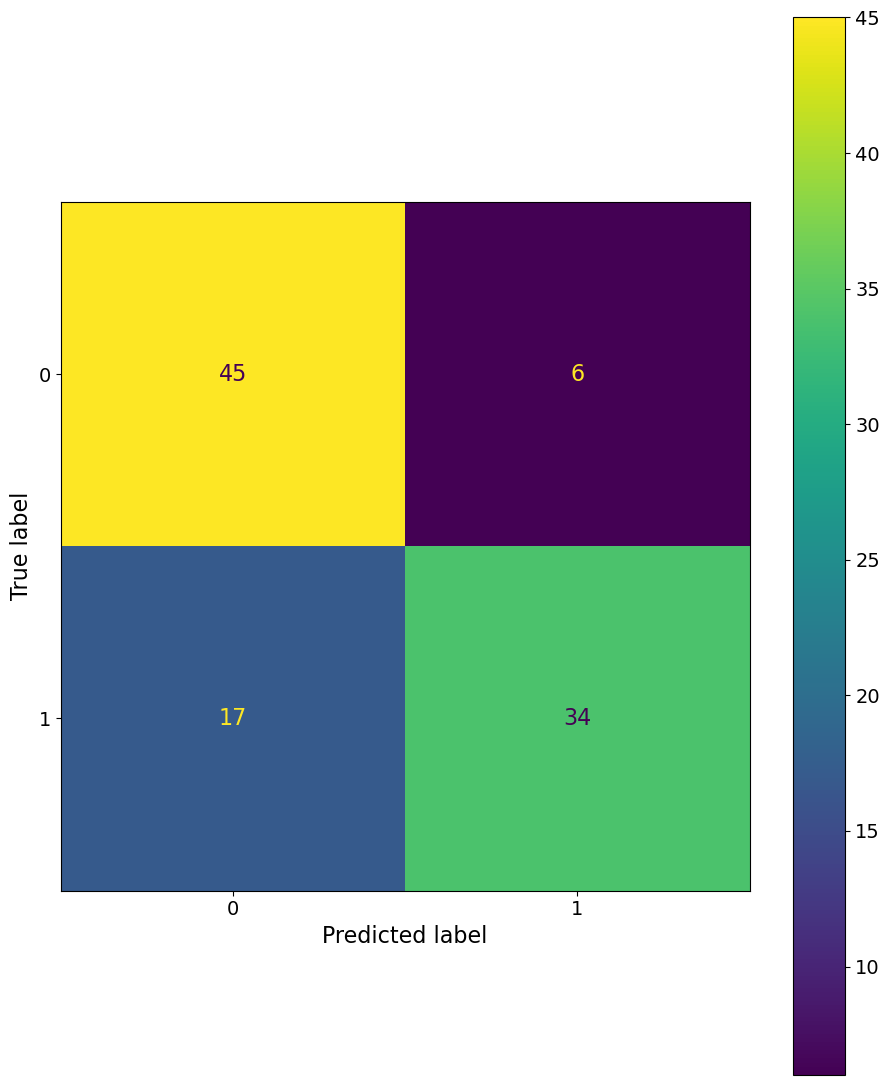

microwave
gasf
MLP
2

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
f1_score: 0.7718564621219488
accuracy: 0.7745098039215687
              precision    recall  f1-score   support

       False       0.73      0.88      0.80        51
        True       0.85      0.67      0.75        51

    accuracy                           0.77       102
   macro avg       0.79      0.77      0.77       102
weighted avg       0.79      0.77      0.77       102



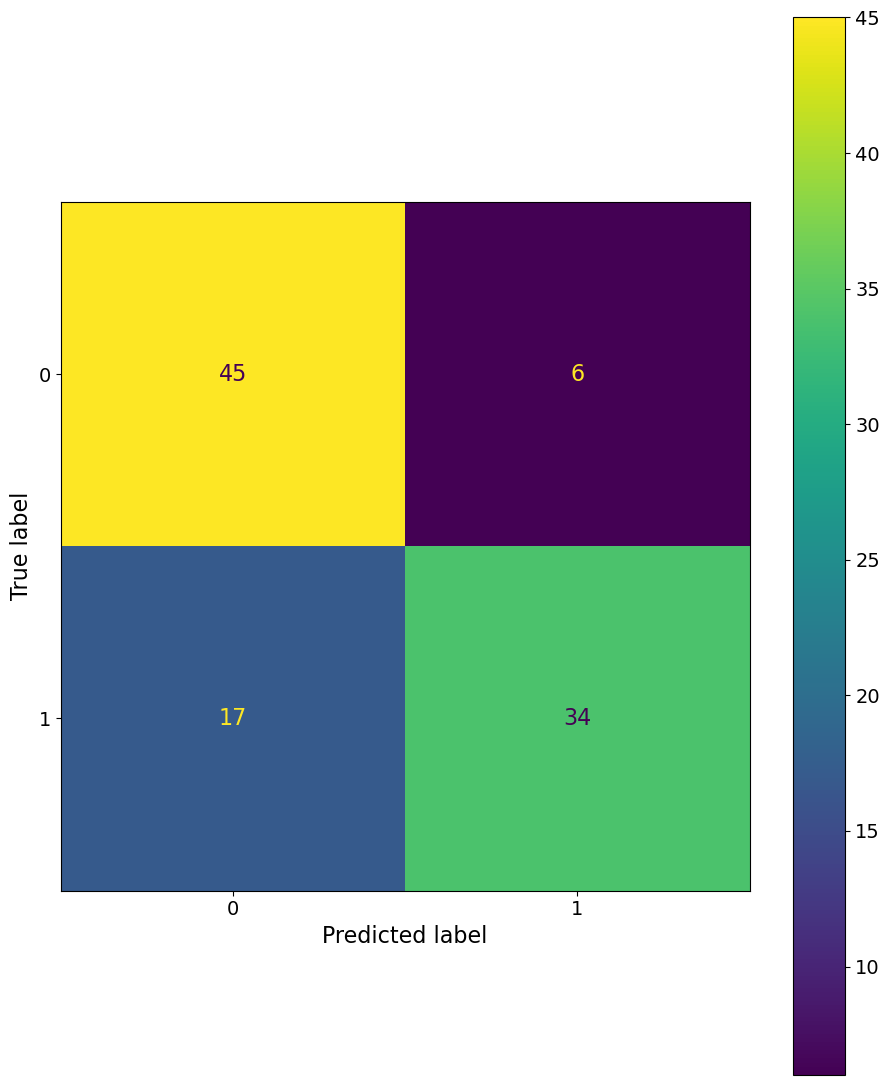

microwave
gasf
MLP
3

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
f1_score: 0.7718564621219488
accuracy: 0.7745098039215687
              precision    recall  f1-score   support

       False       0.73      0.88      0.80        51
        True       0.85      0.67      0.75        51

    accuracy                           0.77       102
   macro avg       0.79      0.77      0.77       102
weighted avg       0.79      0.77      0.77       102



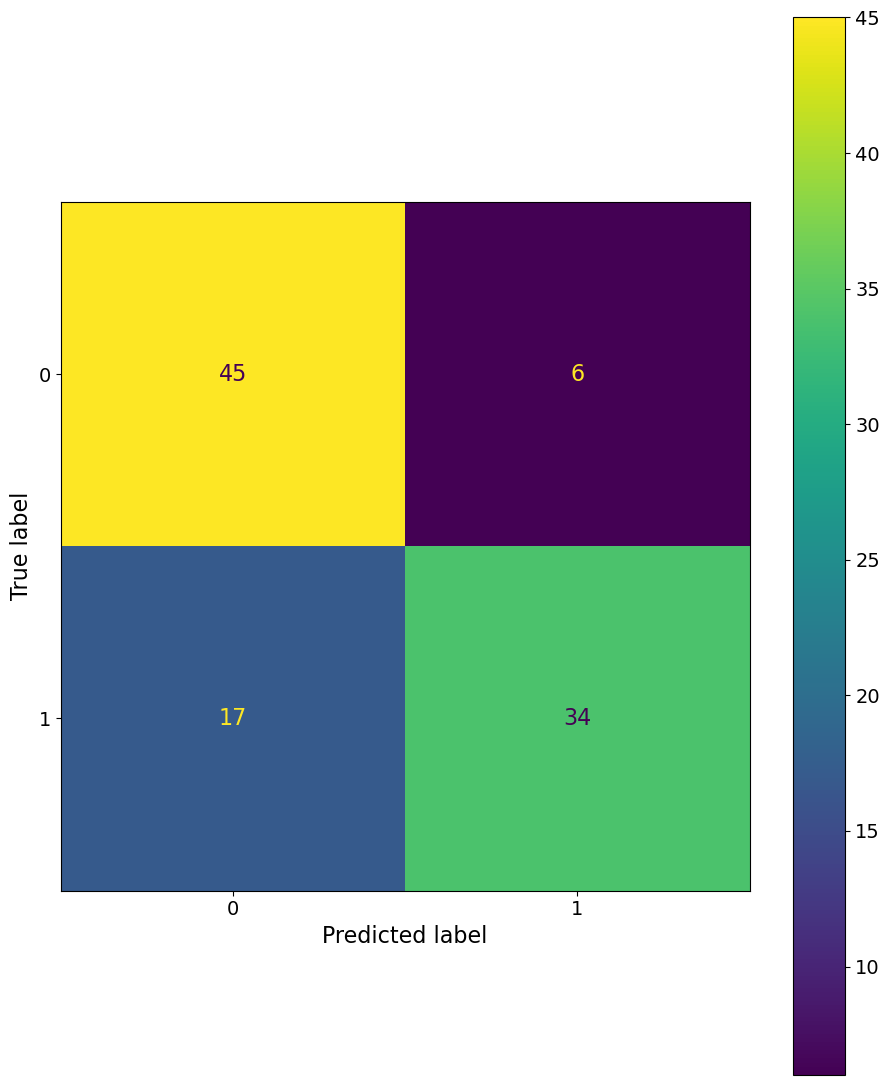

microwave
gasf
MLP
4

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
f1_score: 0.7718564621219488
accuracy: 0.7745098039215687
              precision    recall  f1-score   support

       False       0.73      0.88      0.80        51
        True       0.85      0.67      0.75        51

    accuracy                           0.77       102
   macro avg       0.79      0.77      0.77       102
weighted avg       0.79      0.77      0.77       102



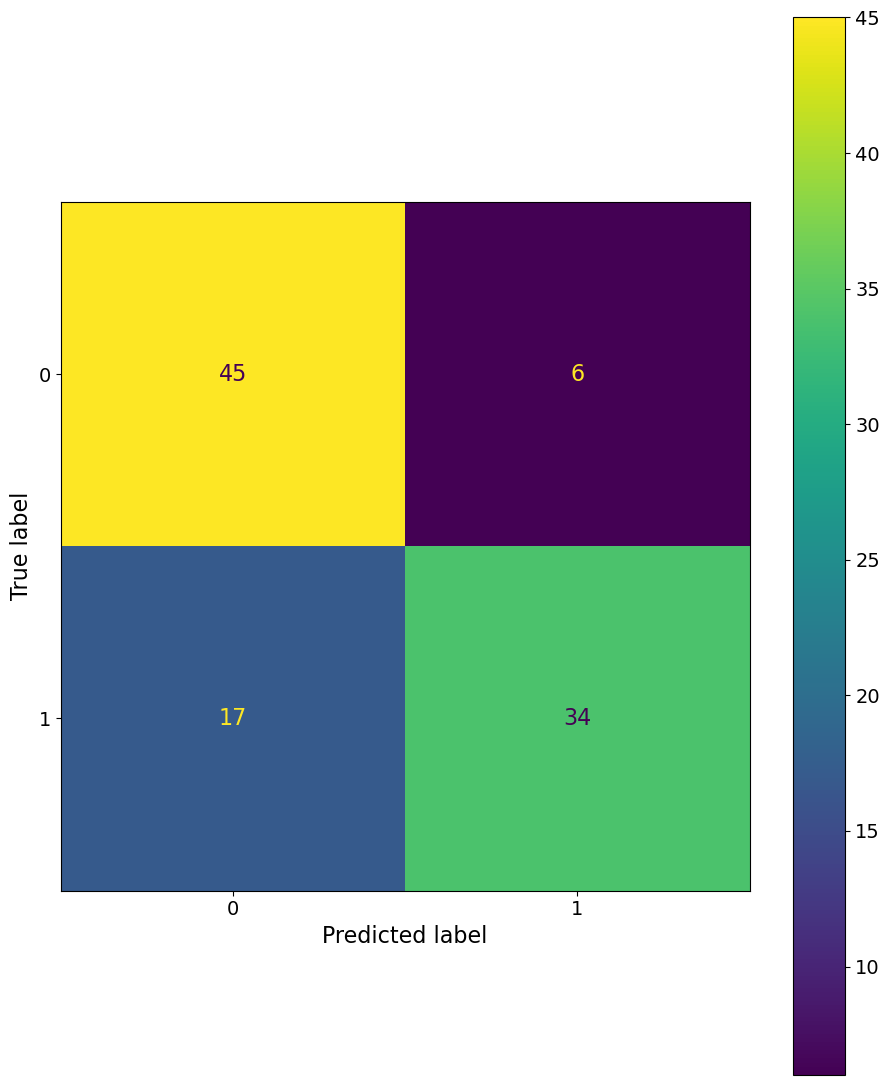

microwave
gasf
XGBoost
0

f1_score: 0.7718564621219488
accuracy: 0.7745098039215687
              precision    recall  f1-score   support

       False       0.73      0.88      0.80        51
        True       0.85      0.67      0.75        51

    accuracy                           0.77       102
   macro avg       0.79      0.77      0.77       102
weighted avg       0.79      0.77      0.77       102



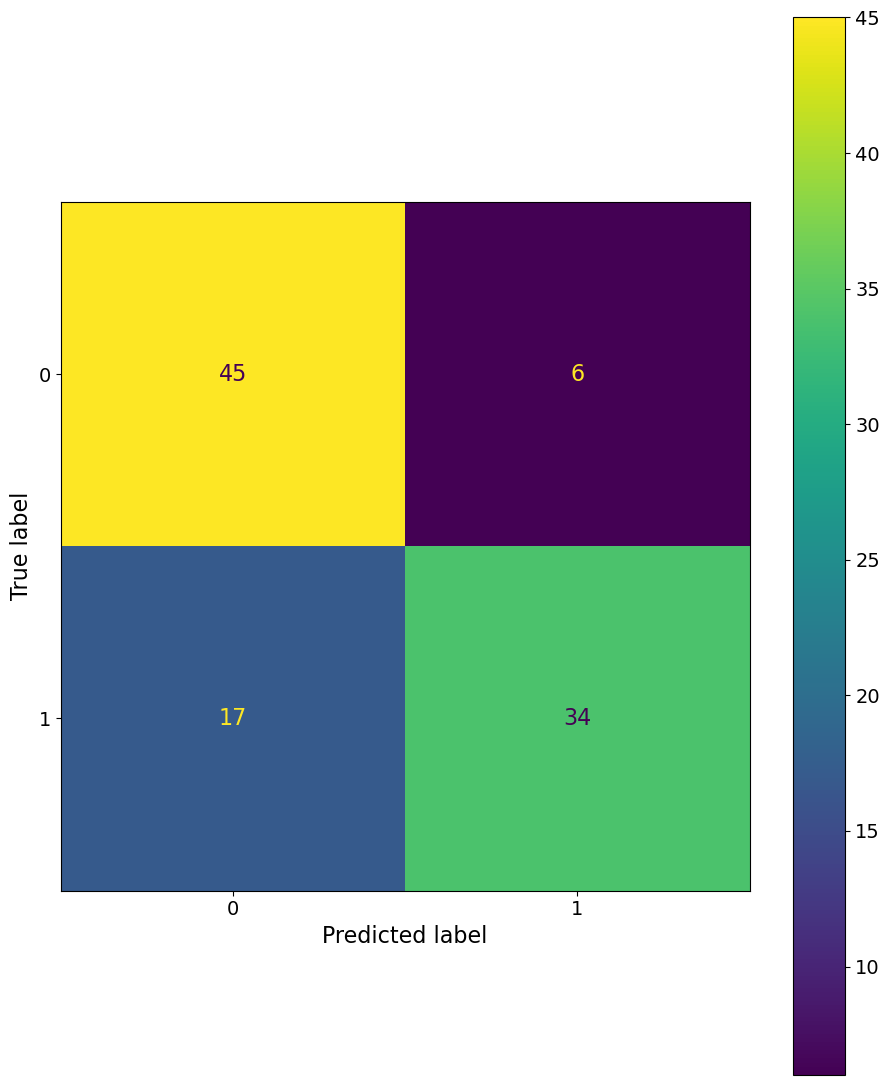

microwave
gasf
SVM
0

f1_score: 0.7508549096238397
accuracy: 0.7549019607843137
              precision    recall  f1-score   support

       False       0.70      0.88      0.78        51
        True       0.84      0.63      0.72        51

    accuracy                           0.75       102
   macro avg       0.77      0.75      0.75       102
weighted avg       0.77      0.75      0.75       102



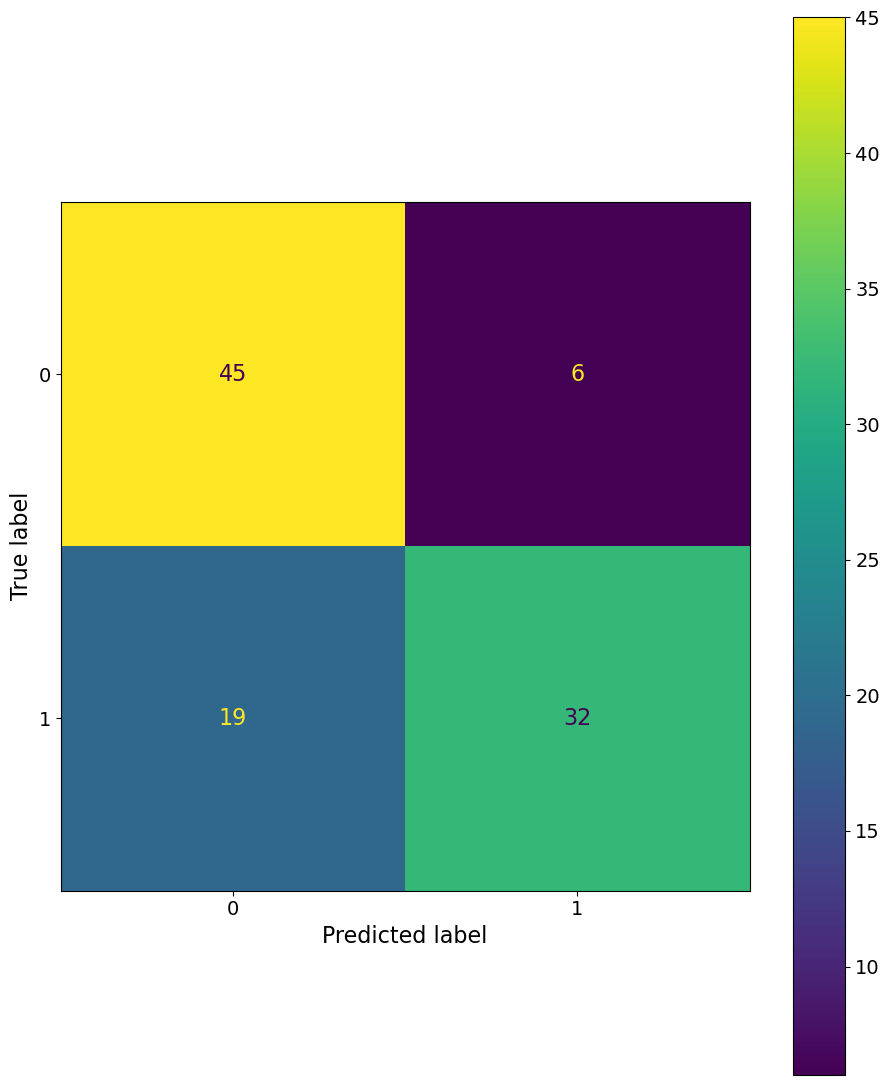

microwave
gadf
MLP
0

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
f1_score: 0.6533386645341863
accuracy: 0.6666666666666666
              precision    recall  f1-score   support

       False       0.62      0.86      0.72        51
        True       0.77      0.47      0.59        51

    accuracy                           0.67       102
   macro avg       0.70      0.67      0.65       102
weighted avg       0.70      0.67      0.65       102



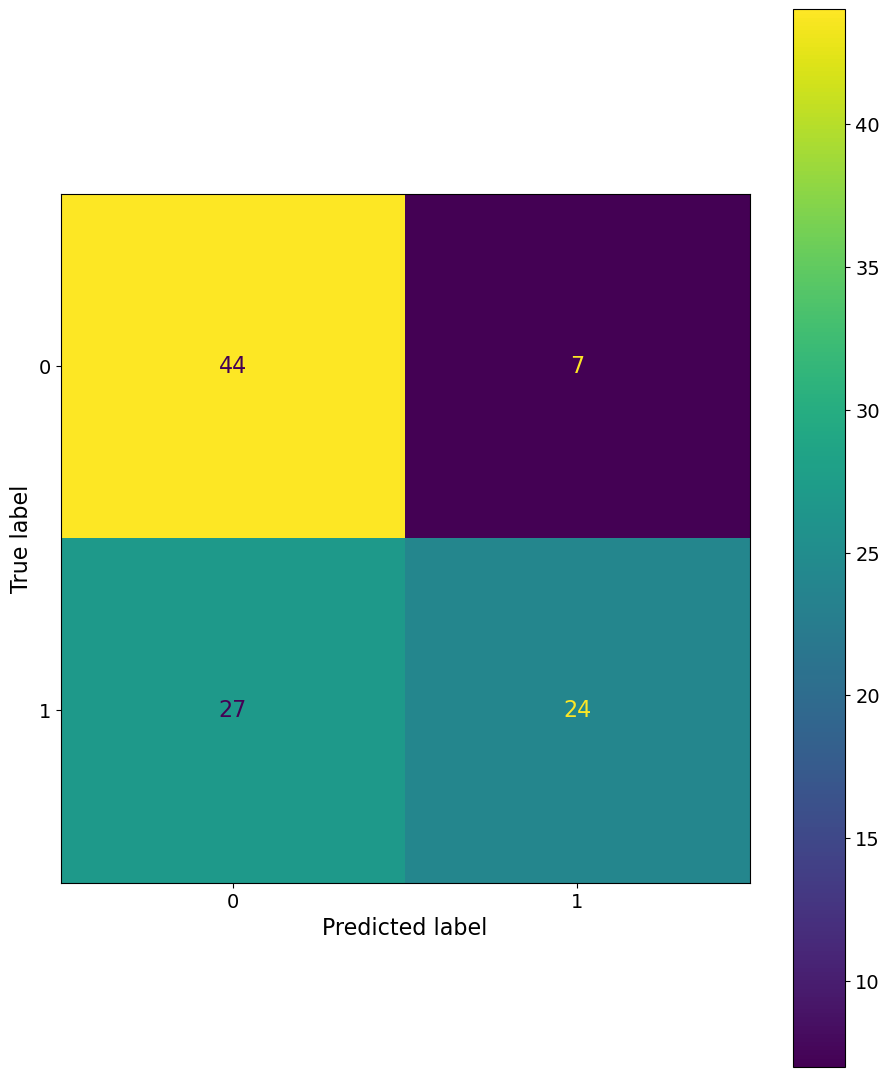

microwave
gadf
MLP
1

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
f1_score: 0.6384810126582279
accuracy: 0.6568627450980392
              precision    recall  f1-score   support

       False       0.61      0.88      0.72        51
        True       0.79      0.43      0.56        51

    accuracy                           0.66       102
   macro avg       0.70      0.66      0.64       102
weighted avg       0.70      0.66      0.64       102



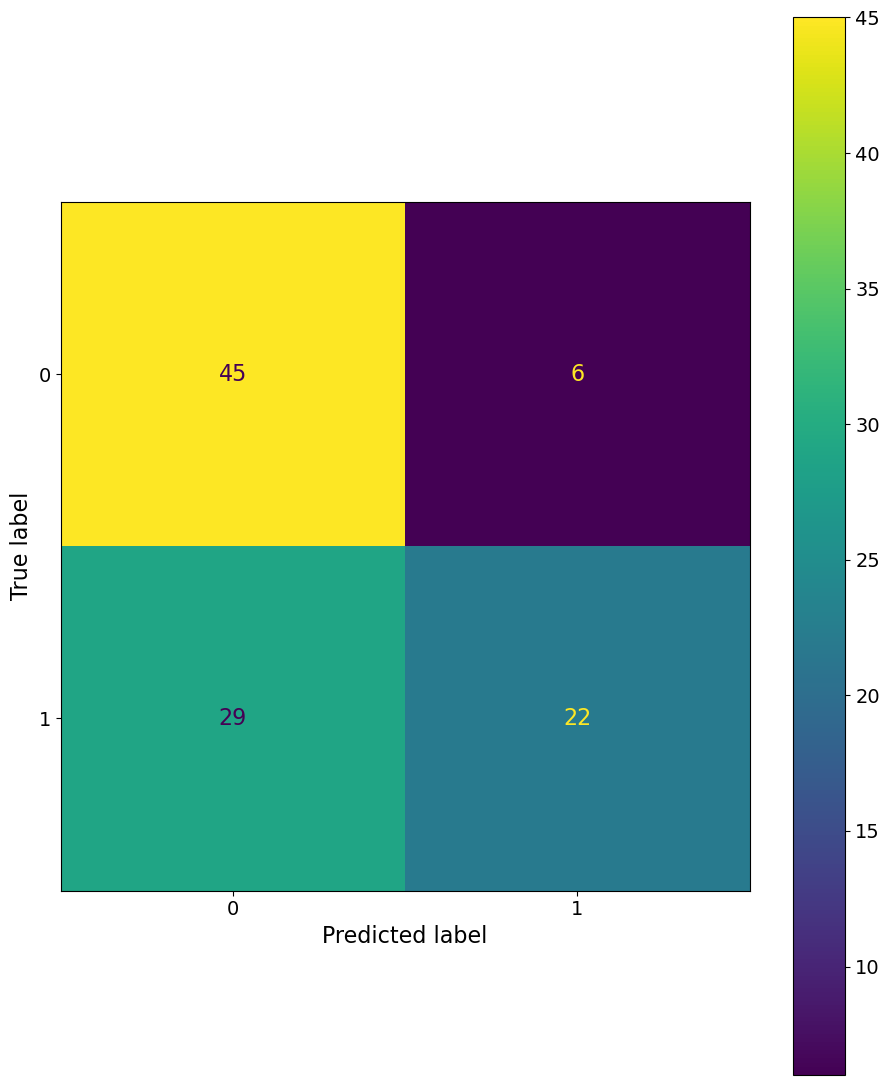

microwave
gadf
MLP
2

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
f1_score: 0.6851538384944738
accuracy: 0.696078431372549
              precision    recall  f1-score   support

       False       0.64      0.88      0.74        51
        True       0.81      0.51      0.63        51

    accuracy                           0.70       102
   macro avg       0.73      0.70      0.69       102
weighted avg       0.73      0.70      0.69       102



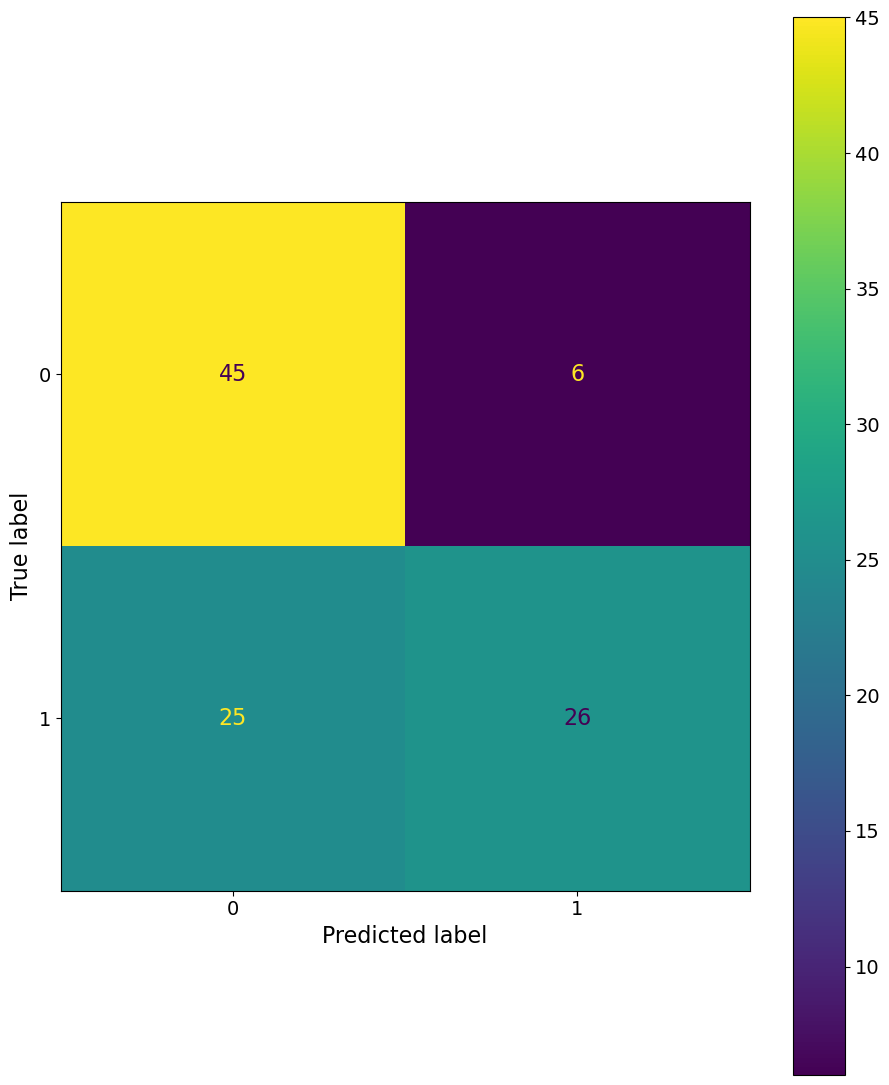

microwave
gadf
MLP
3

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
f1_score: 0.5970893970893971
accuracy: 0.6274509803921569
              precision    recall  f1-score   support

       False       0.58      0.90      0.71        51
        True       0.78      0.35      0.49        51

    accuracy                           0.63       102
   macro avg       0.68      0.63      0.60       102
weighted avg       0.68      0.63      0.60       102



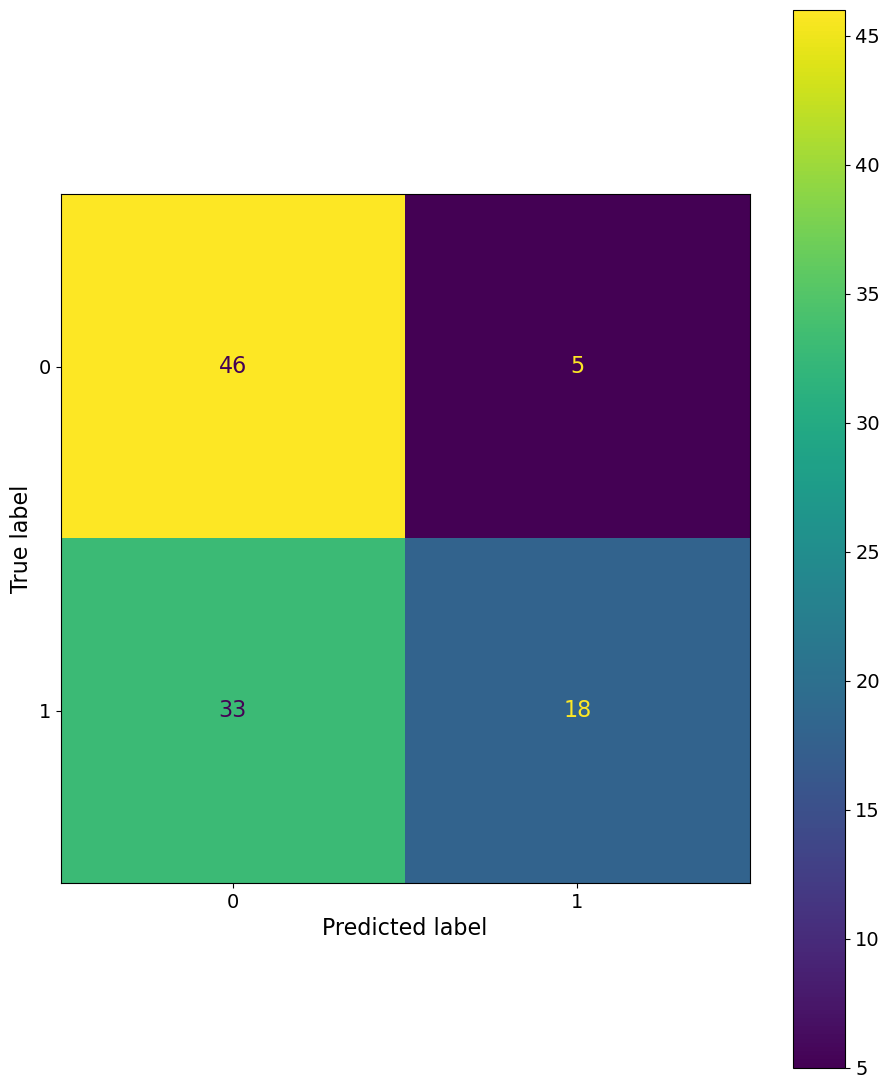

microwave
gadf
MLP
4

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
f1_score: 0.6298387096774194
accuracy: 0.6470588235294118
              precision    recall  f1-score   support

       False       0.60      0.86      0.71        51
        True       0.76      0.43      0.55        51

    accuracy                           0.65       102
   macro avg       0.68      0.65      0.63       102
weighted avg       0.68      0.65      0.63       102



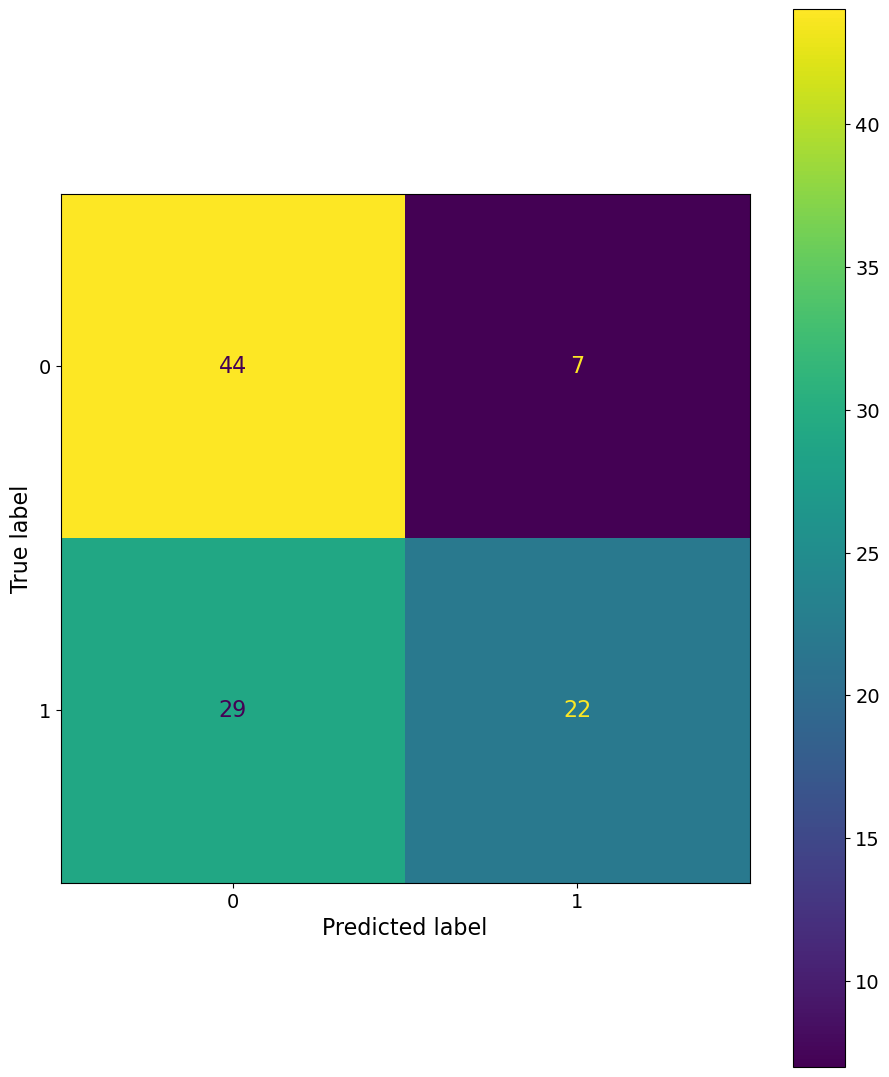

microwave
gadf
XGBoost
0

f1_score: 0.7109916951636541
accuracy: 0.7156862745098039
              precision    recall  f1-score   support

       False       0.67      0.84      0.75        51
        True       0.79      0.59      0.67        51

    accuracy                           0.72       102
   macro avg       0.73      0.72      0.71       102
weighted avg       0.73      0.72      0.71       102



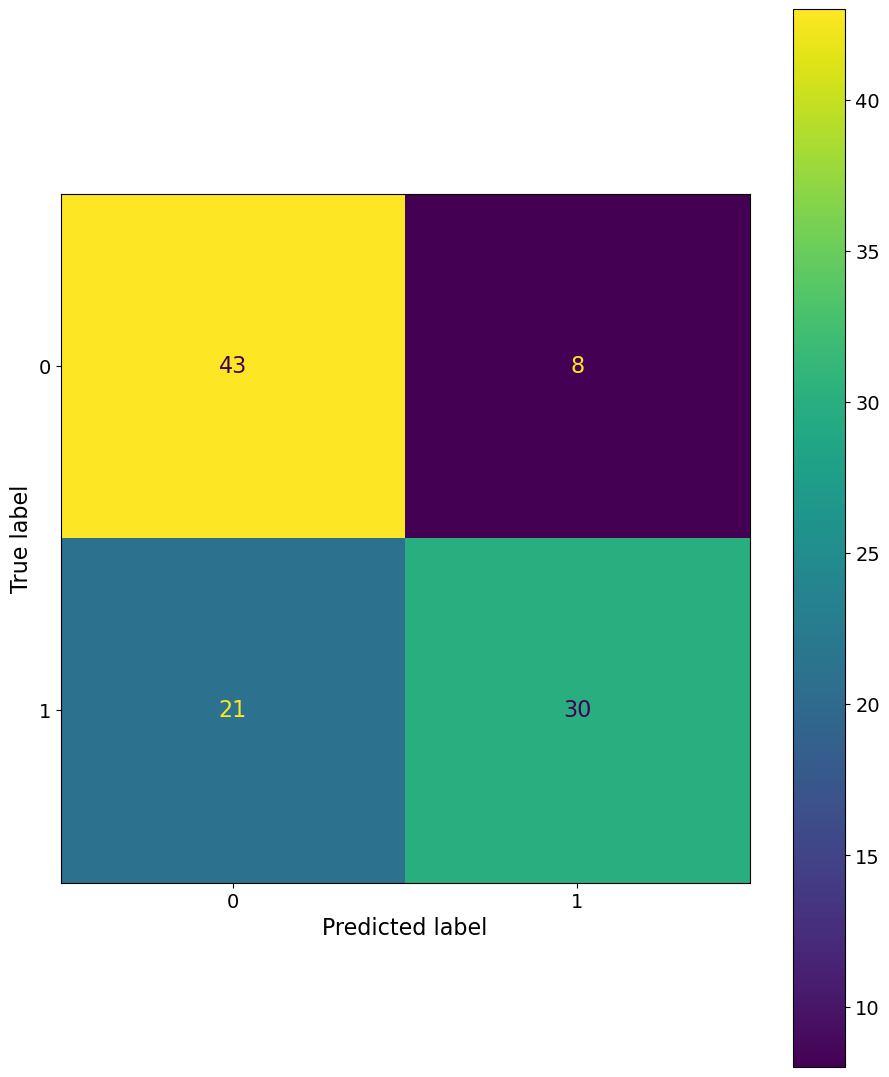

microwave
gadf
SVM
0

f1_score: 0.5072463768115942
accuracy: 0.5686274509803921
              precision    recall  f1-score   support

       False       0.54      0.92      0.68        51
        True       0.73      0.22      0.33        51

    accuracy                           0.57       102
   macro avg       0.64      0.57      0.51       102
weighted avg       0.64      0.57      0.51       102



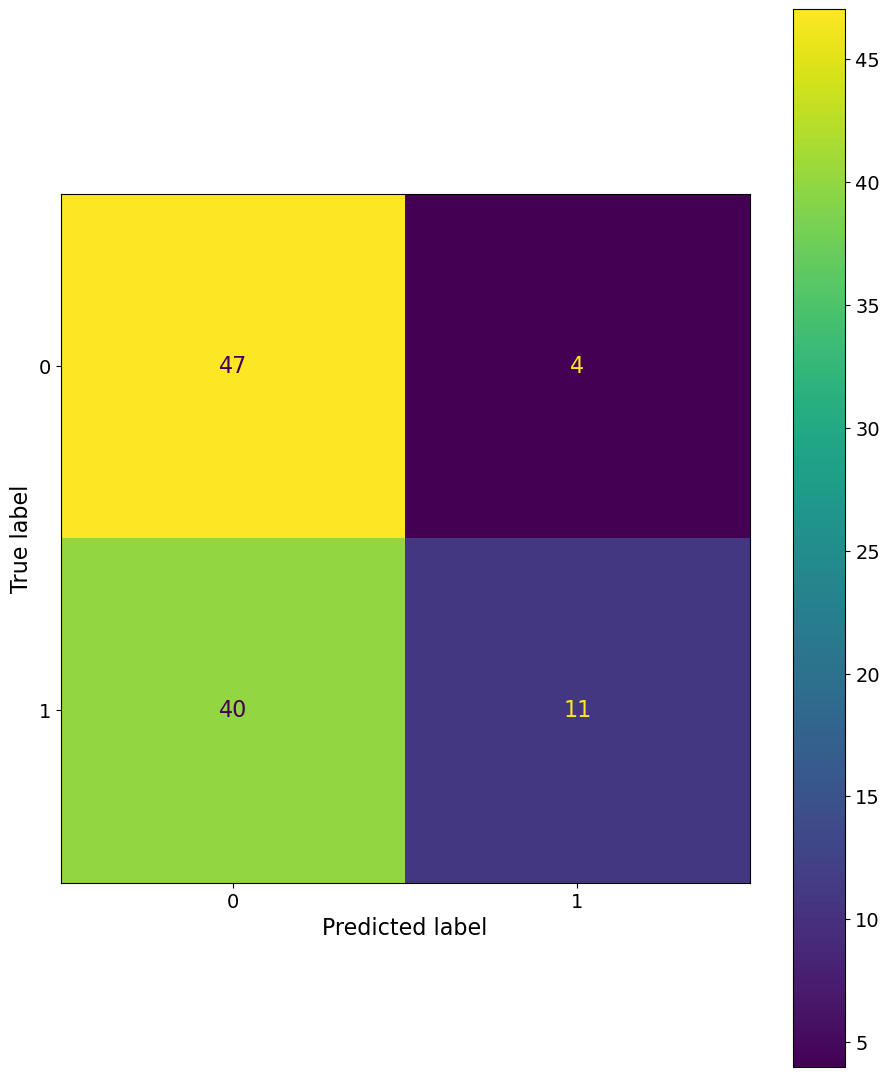

microwave
mtf
MLP
0

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
f1_score: 0.7801724137931034
accuracy: 0.7843137254901961
              precision    recall  f1-score   support

       False       0.72      0.92      0.81        51
        True       0.89      0.65      0.75        51

    accuracy                           0.78       102
   macro avg       0.81      0.78      0.78       102
weighted avg       0.81      0.78      0.78       102



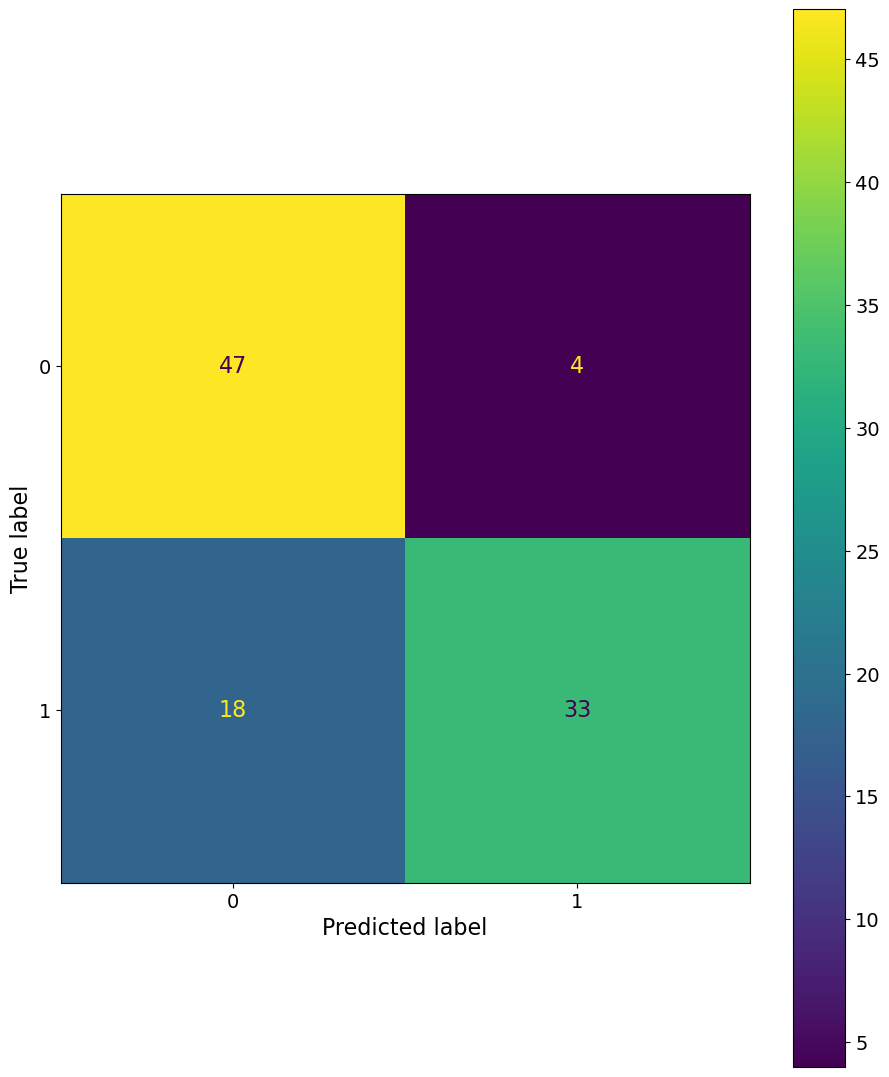

microwave
mtf
MLP
1

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
f1_score: 0.7801724137931034
accuracy: 0.7843137254901961
              precision    recall  f1-score   support

       False       0.72      0.92      0.81        51
        True       0.89      0.65      0.75        51

    accuracy                           0.78       102
   macro avg       0.81      0.78      0.78       102
weighted avg       0.81      0.78      0.78       102



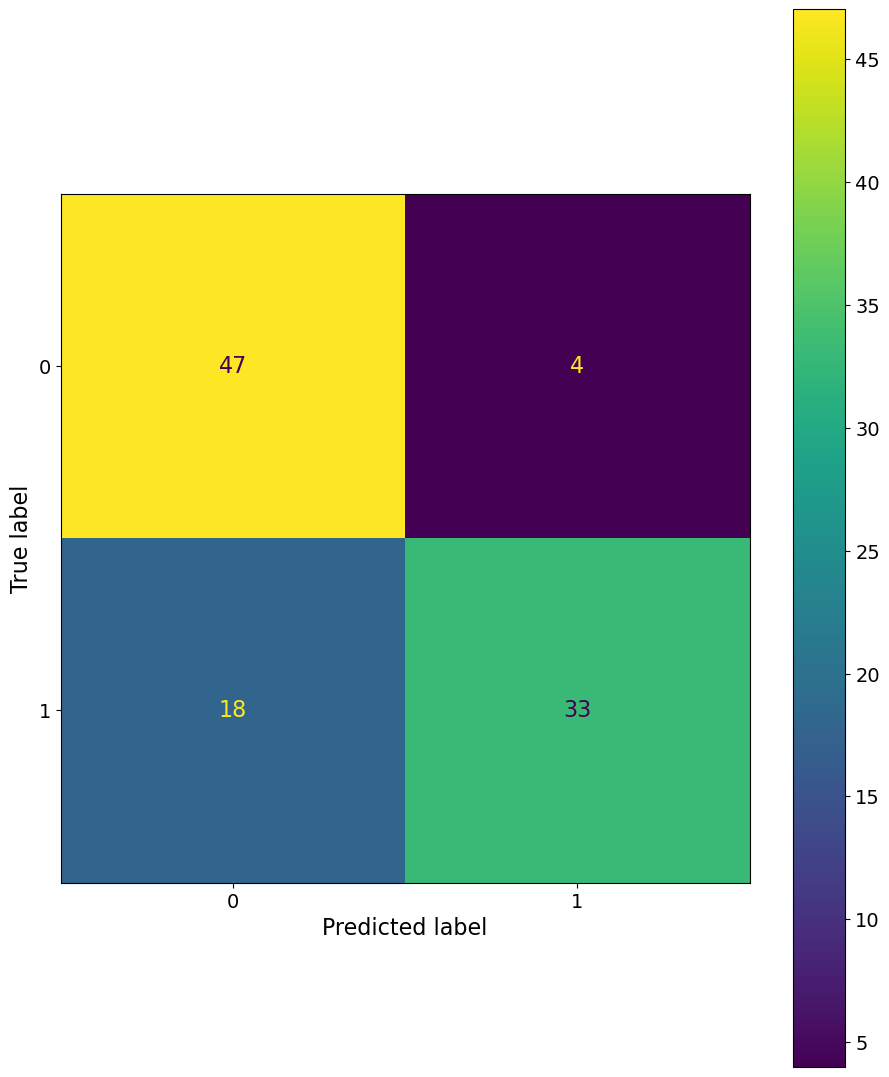

microwave
mtf
MLP
2

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
f1_score: 0.7801724137931034
accuracy: 0.7843137254901961
              precision    recall  f1-score   support

       False       0.72      0.92      0.81        51
        True       0.89      0.65      0.75        51

    accuracy                           0.78       102
   macro avg       0.81      0.78      0.78       102
weighted avg       0.81      0.78      0.78       102



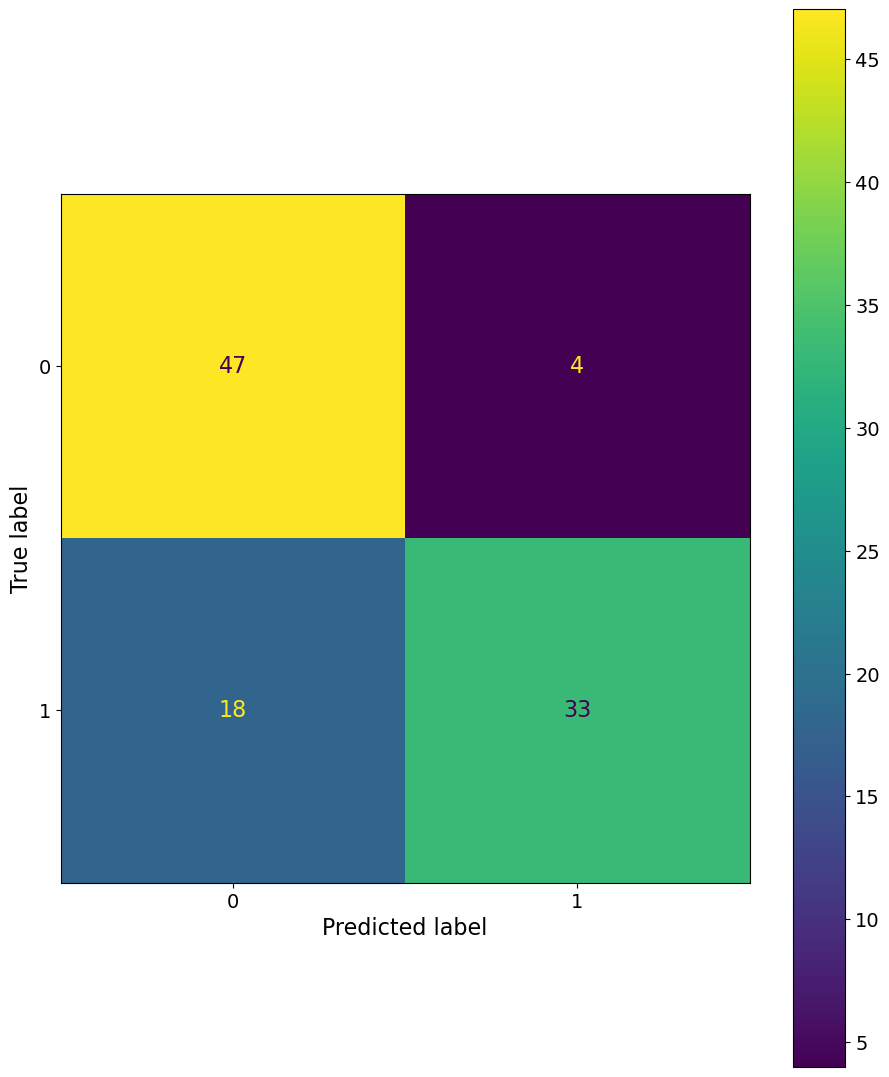

microwave
mtf
MLP
3

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
f1_score: 0.7801724137931034
accuracy: 0.7843137254901961
              precision    recall  f1-score   support

       False       0.72      0.92      0.81        51
        True       0.89      0.65      0.75        51

    accuracy                           0.78       102
   macro avg       0.81      0.78      0.78       102
weighted avg       0.81      0.78      0.78       102



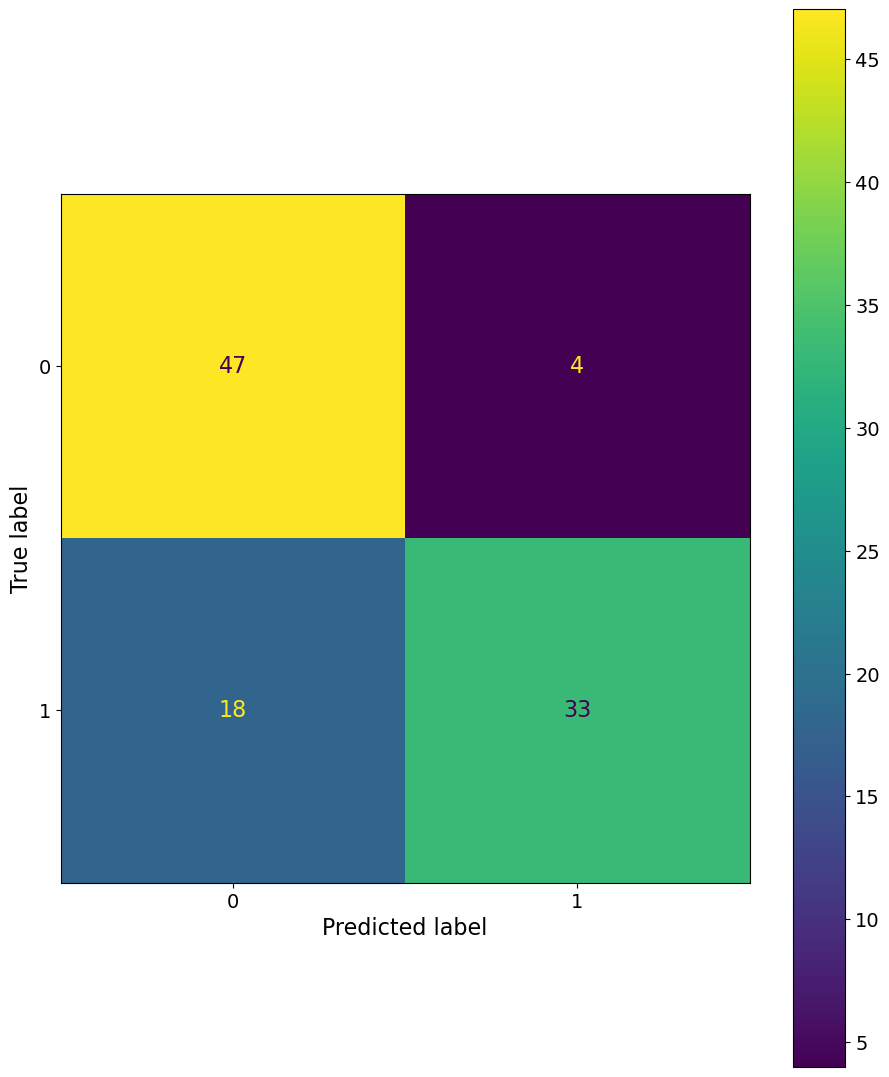

microwave
mtf
MLP
4

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
f1_score: 0.7801724137931034
accuracy: 0.7843137254901961
              precision    recall  f1-score   support

       False       0.72      0.92      0.81        51
        True       0.89      0.65      0.75        51

    accuracy                           0.78       102
   macro avg       0.81      0.78      0.78       102
weighted avg       0.81      0.78      0.78       102



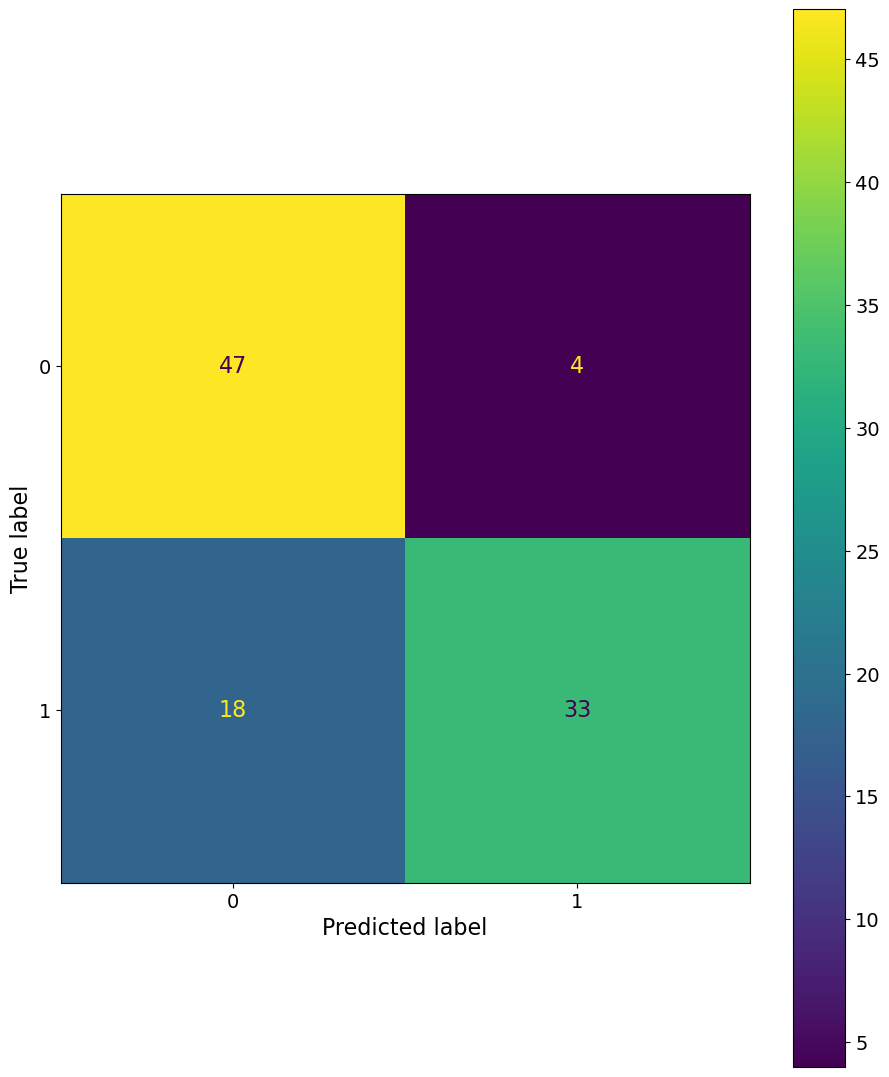

microwave
mtf
XGBoost
0

f1_score: 0.8218167701863355
accuracy: 0.8235294117647058
              precision    recall  f1-score   support

       False       0.77      0.92      0.84        51
        True       0.90      0.73      0.80        51

    accuracy                           0.82       102
   macro avg       0.84      0.82      0.82       102
weighted avg       0.84      0.82      0.82       102



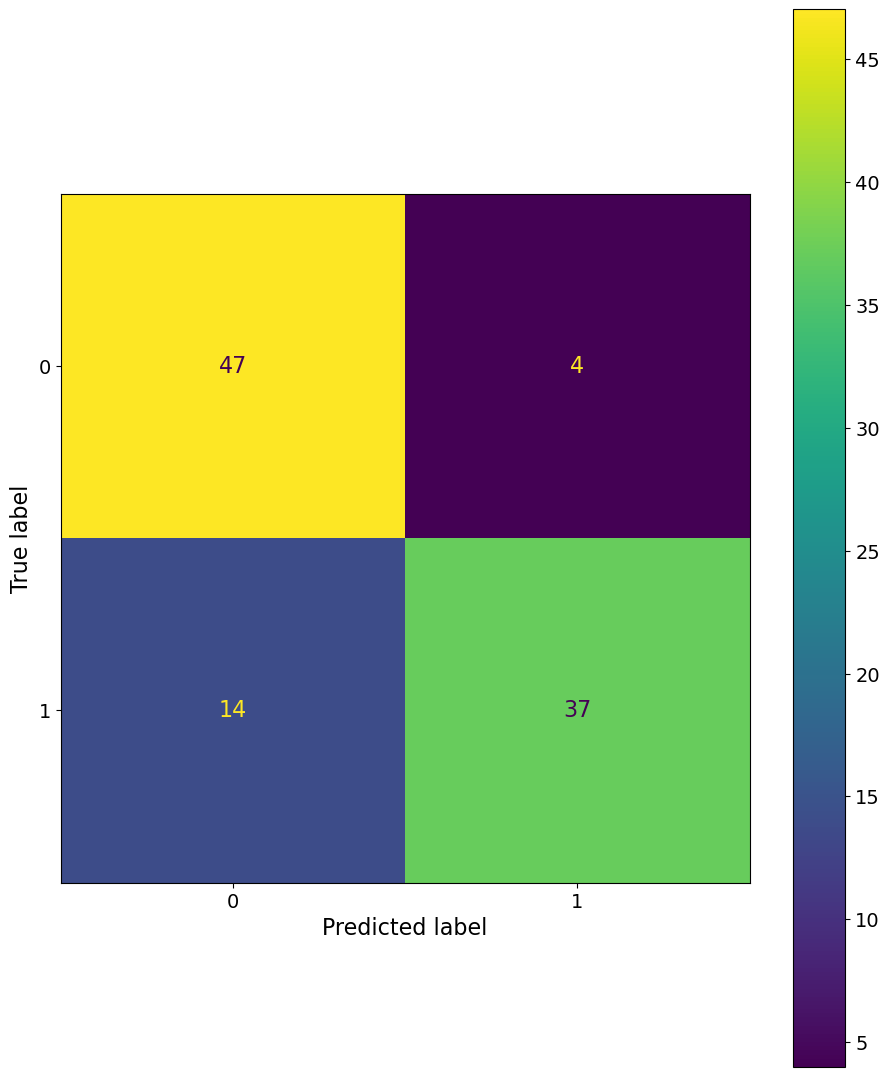

microwave
mtf
SVM
0

f1_score: 0.7801724137931034
accuracy: 0.7843137254901961
              precision    recall  f1-score   support

       False       0.72      0.92      0.81        51
        True       0.89      0.65      0.75        51

    accuracy                           0.78       102
   macro avg       0.81      0.78      0.78       102
weighted avg       0.81      0.78      0.78       102



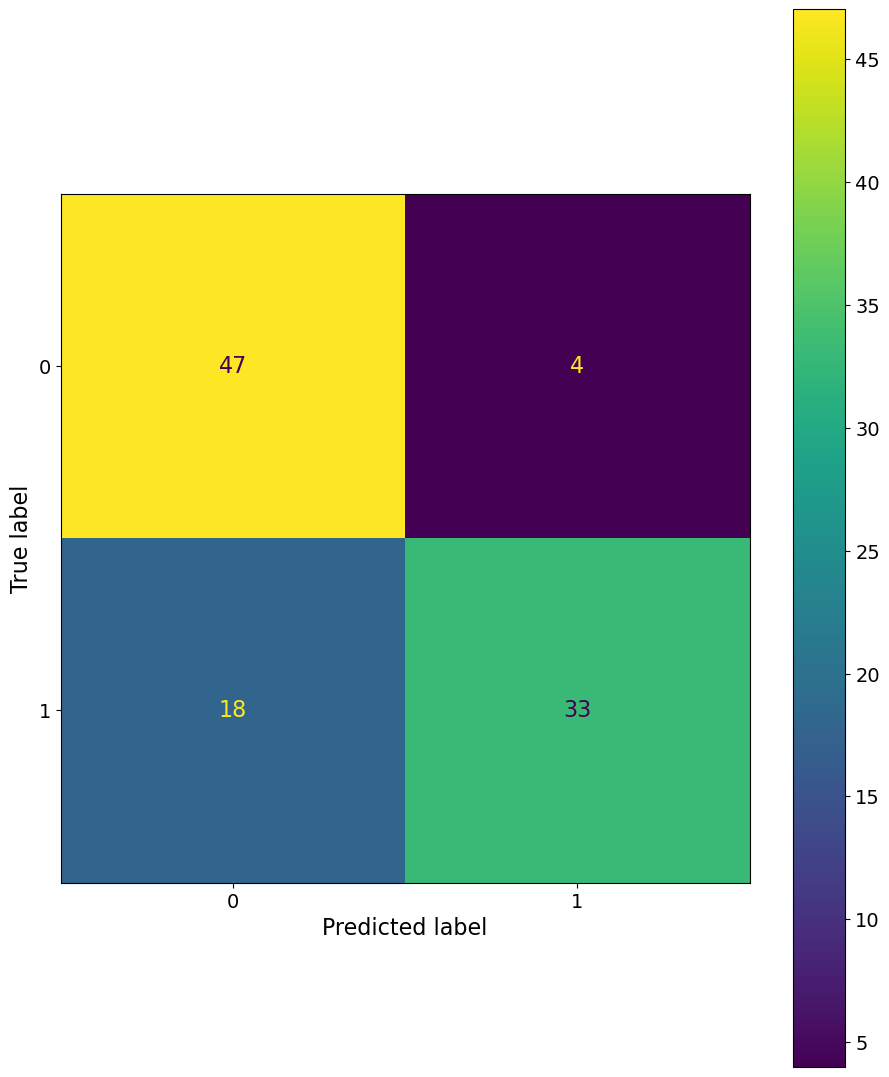

microwave
rp
MLP
0

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
f1_score: 0.6470588235294118
accuracy: 0.6568627450980392
              precision    recall  f1-score   support

       False       0.62      0.82      0.71        51
        True       0.74      0.49      0.59        51

    accuracy                           0.66       102
   macro avg       0.68      0.66      0.65       102
weighted avg       0.68      0.66      0.65       102



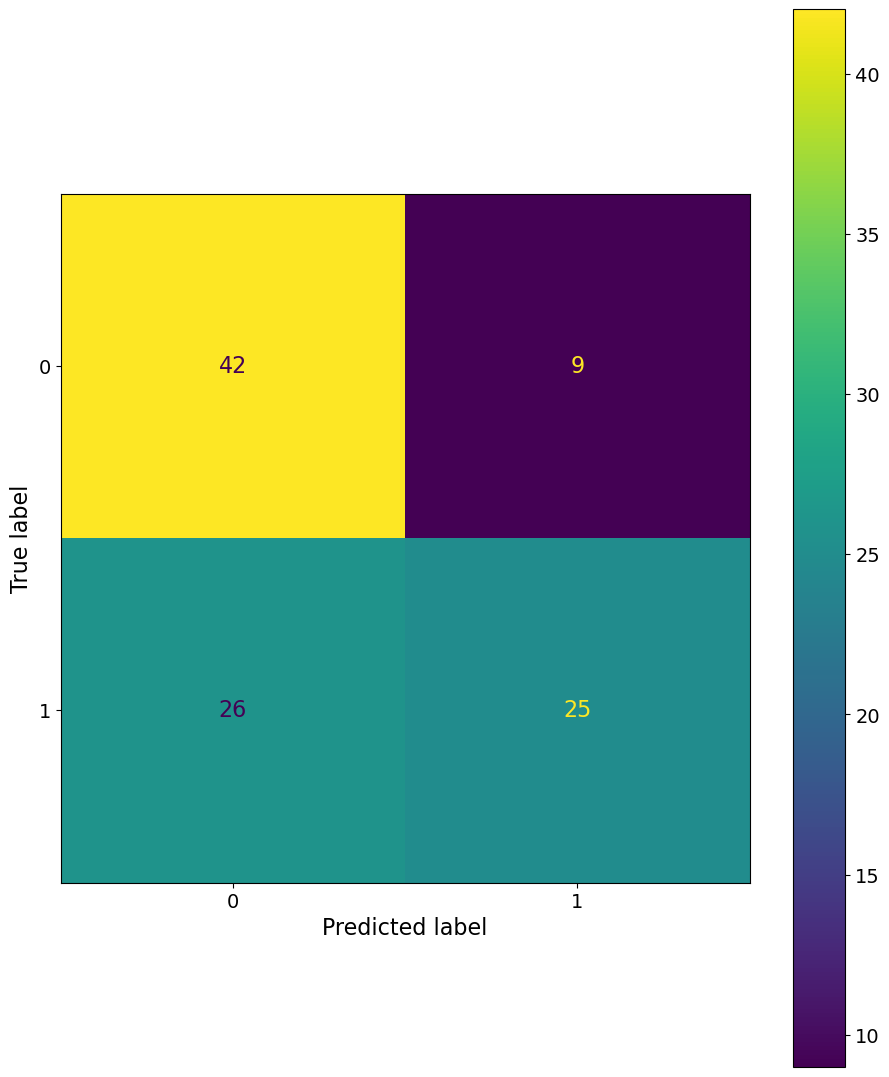

microwave
rp
MLP
1

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
f1_score: 0.6445285273324703
accuracy: 0.6568627450980392
              precision    recall  f1-score   support

       False       0.61      0.84      0.71        51
        True       0.75      0.47      0.58        51

    accuracy                           0.66       102
   macro avg       0.68      0.66      0.64       102
weighted avg       0.68      0.66      0.64       102



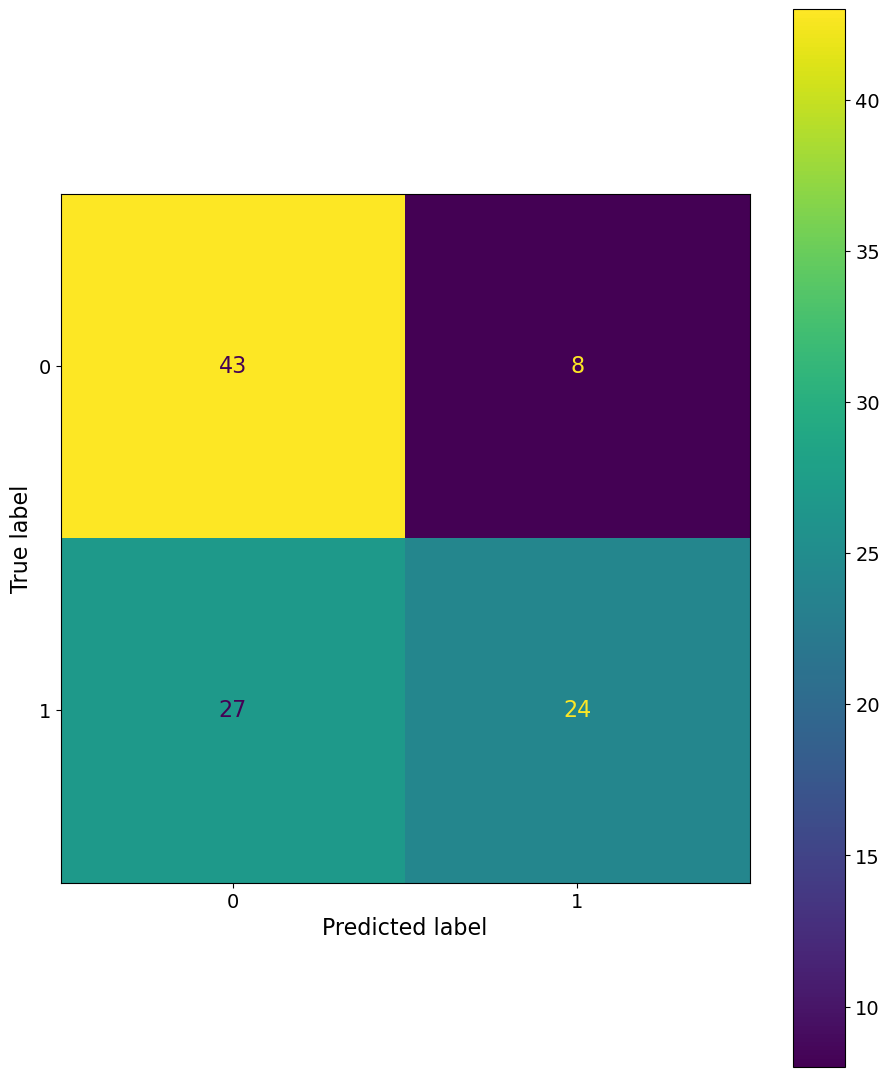

microwave
rp
MLP
2

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
f1_score: 0.641674194519723
accuracy: 0.6568627450980392
              precision    recall  f1-score   support

       False       0.61      0.86      0.72        51
        True       0.77      0.45      0.57        51

    accuracy                           0.66       102
   macro avg       0.69      0.66      0.64       102
weighted avg       0.69      0.66      0.64       102



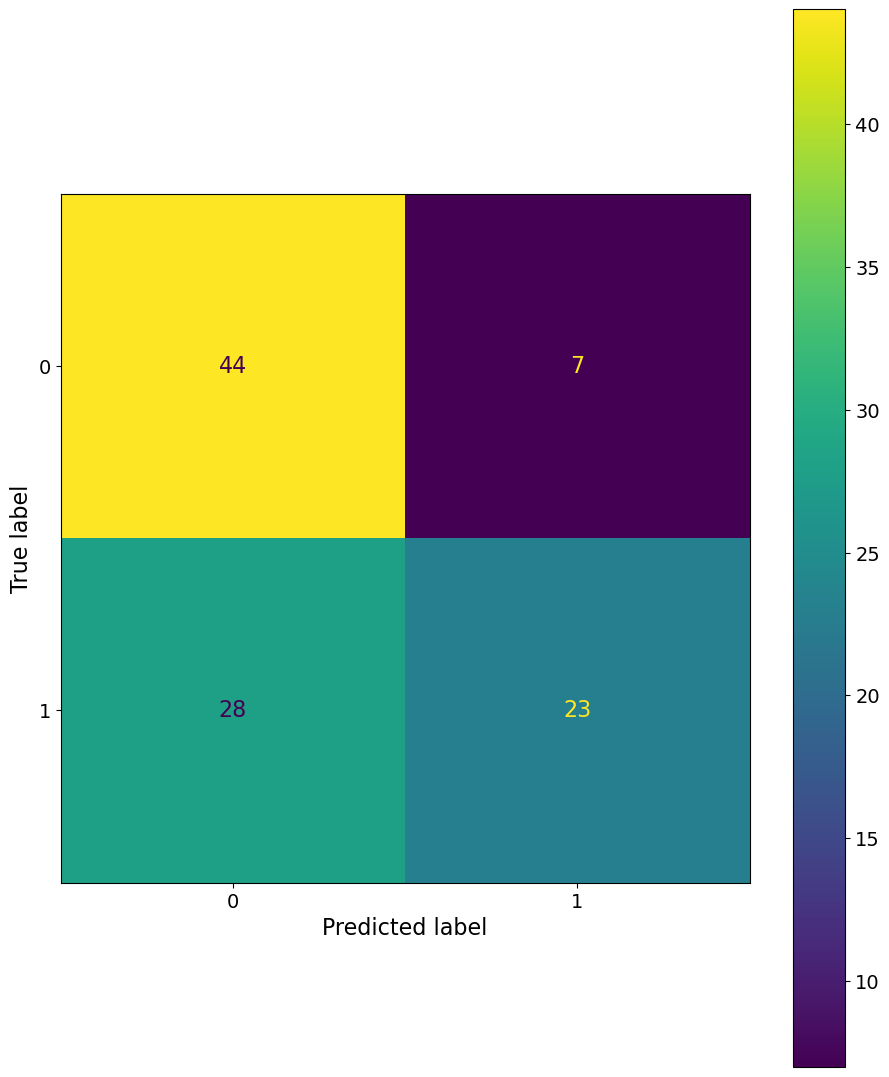

microwave
rp
MLP
3

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
f1_score: 0.6445285273324703
accuracy: 0.6568627450980392
              precision    recall  f1-score   support

       False       0.61      0.84      0.71        51
        True       0.75      0.47      0.58        51

    accuracy                           0.66       102
   macro avg       0.68      0.66      0.64       102
weighted avg       0.68      0.66      0.64       102



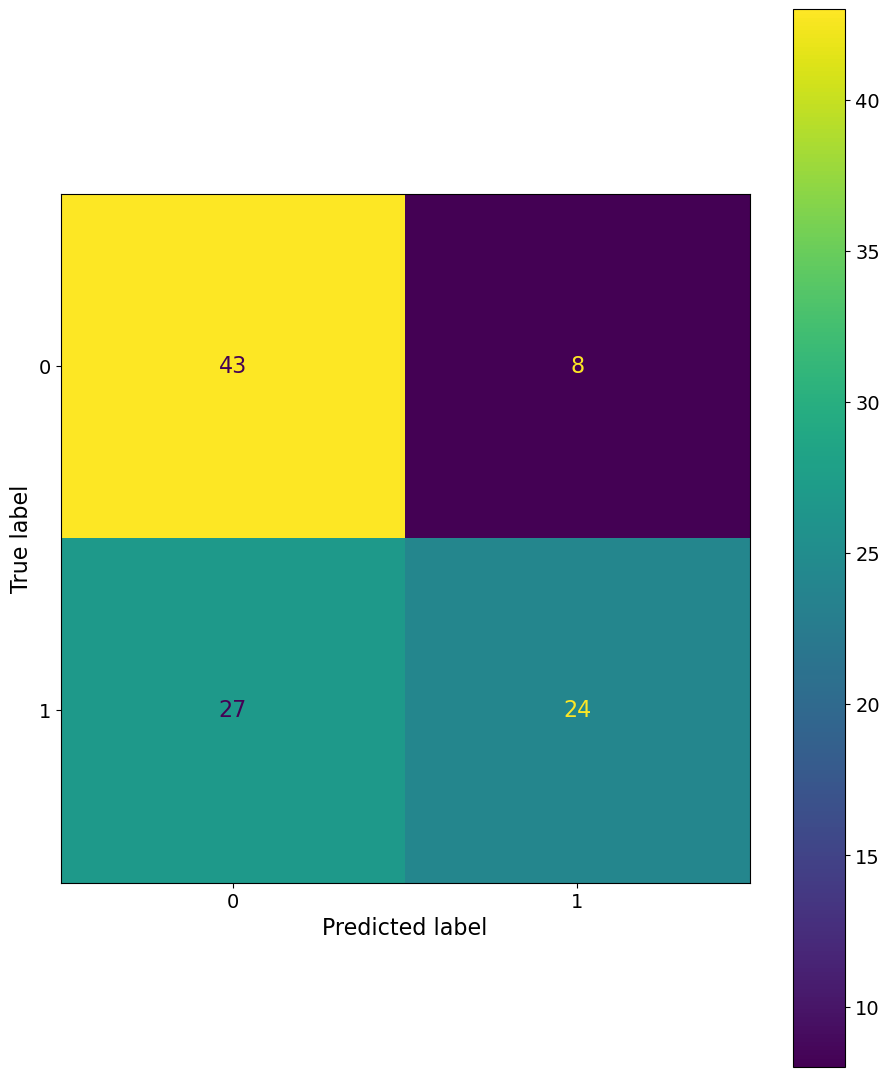

microwave
rp
MLP
4

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
f1_score: 0.6445285273324703
accuracy: 0.6568627450980392
              precision    recall  f1-score   support

       False       0.61      0.84      0.71        51
        True       0.75      0.47      0.58        51

    accuracy                           0.66       102
   macro avg       0.68      0.66      0.64       102
weighted avg       0.68      0.66      0.64       102



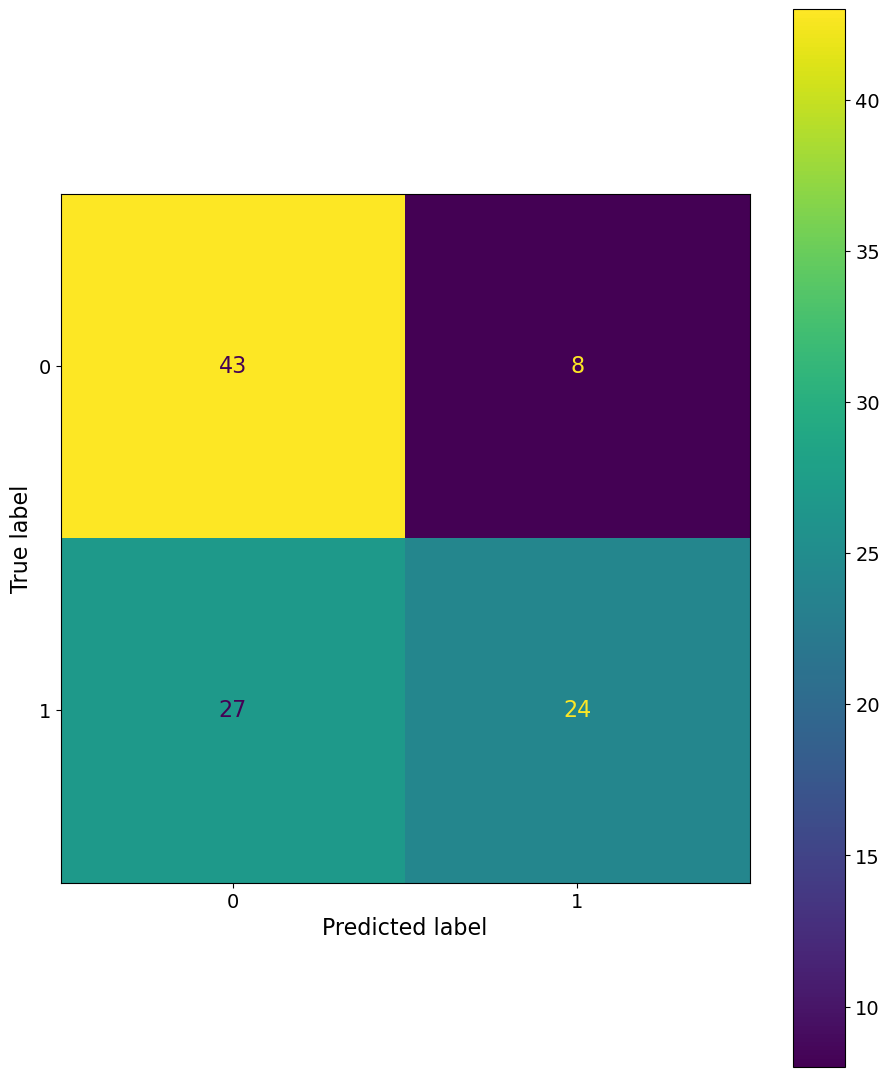

microwave
rp
XGBoost
0

f1_score: 0.7548784004614053
accuracy: 0.7549019607843137
              precision    recall  f1-score   support

       False       0.76      0.75      0.75        51
        True       0.75      0.76      0.76        51

    accuracy                           0.75       102
   macro avg       0.76      0.75      0.75       102
weighted avg       0.75      0.75      0.75       102



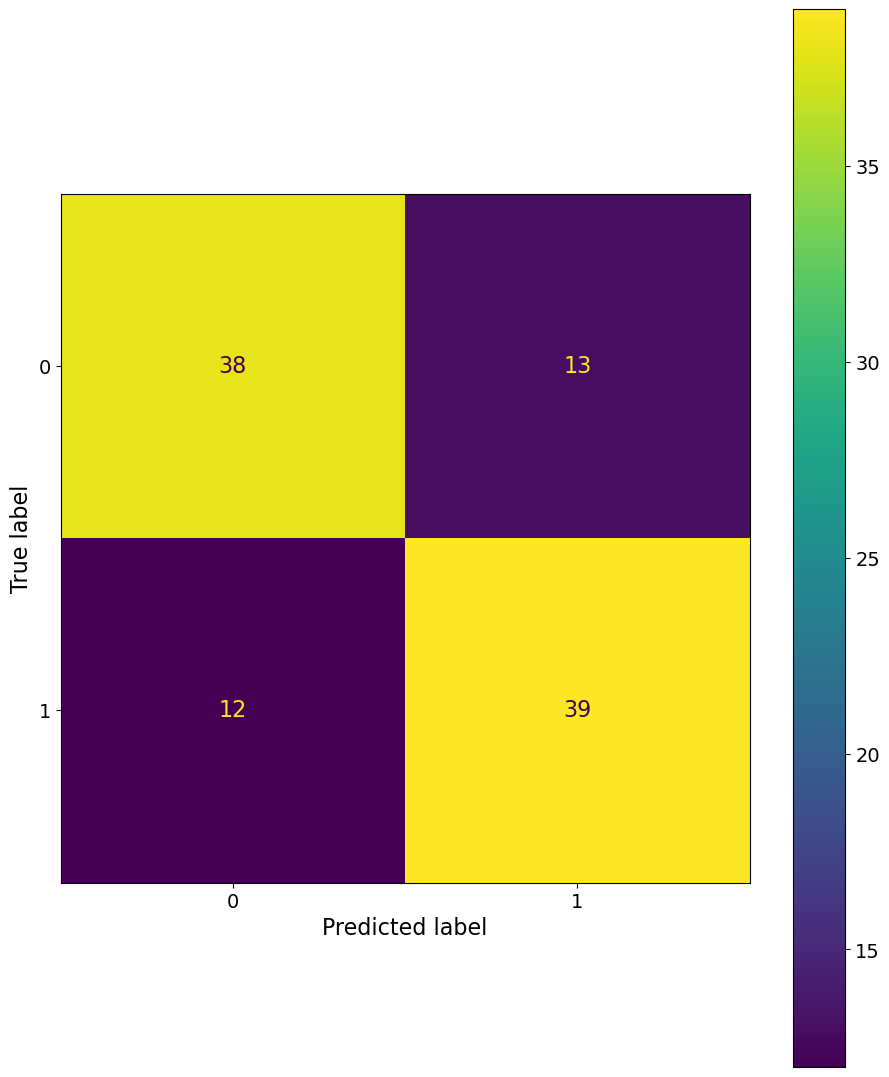

microwave
rp
SVM
0

f1_score: 0.5200250967269685
accuracy: 0.5588235294117647
              precision    recall  f1-score   support

       False       0.54      0.84      0.66        51
        True       0.64      0.27      0.38        51

    accuracy                           0.56       102
   macro avg       0.59      0.56      0.52       102
weighted avg       0.59      0.56      0.52       102



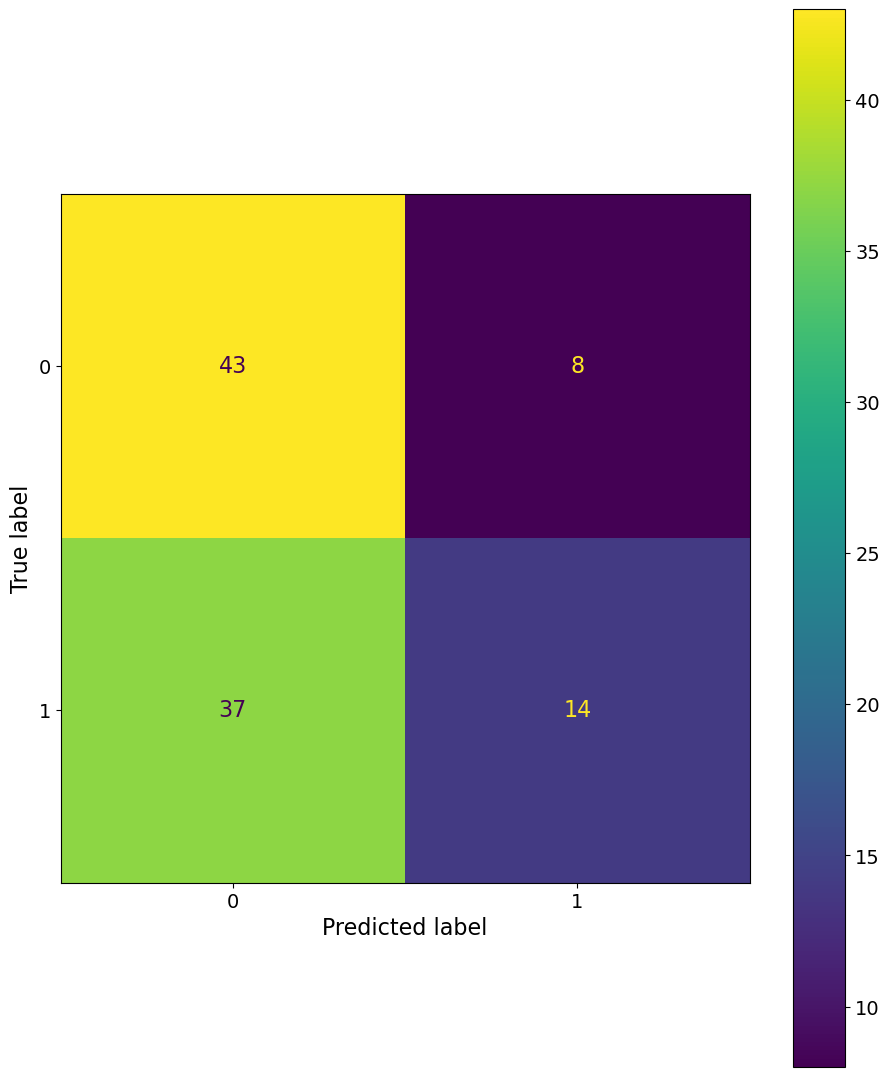

microwave
tbg
MLP
0

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
f1_score: 0.9117562241661059
accuracy: 0.9117647058823529
              precision    recall  f1-score   support

       False       0.92      0.90      0.91        51
        True       0.90      0.92      0.91        51

    accuracy                           0.91       102
   macro avg       0.91      0.91      0.91       102
weighted avg       0.91      0.91      0.91       102



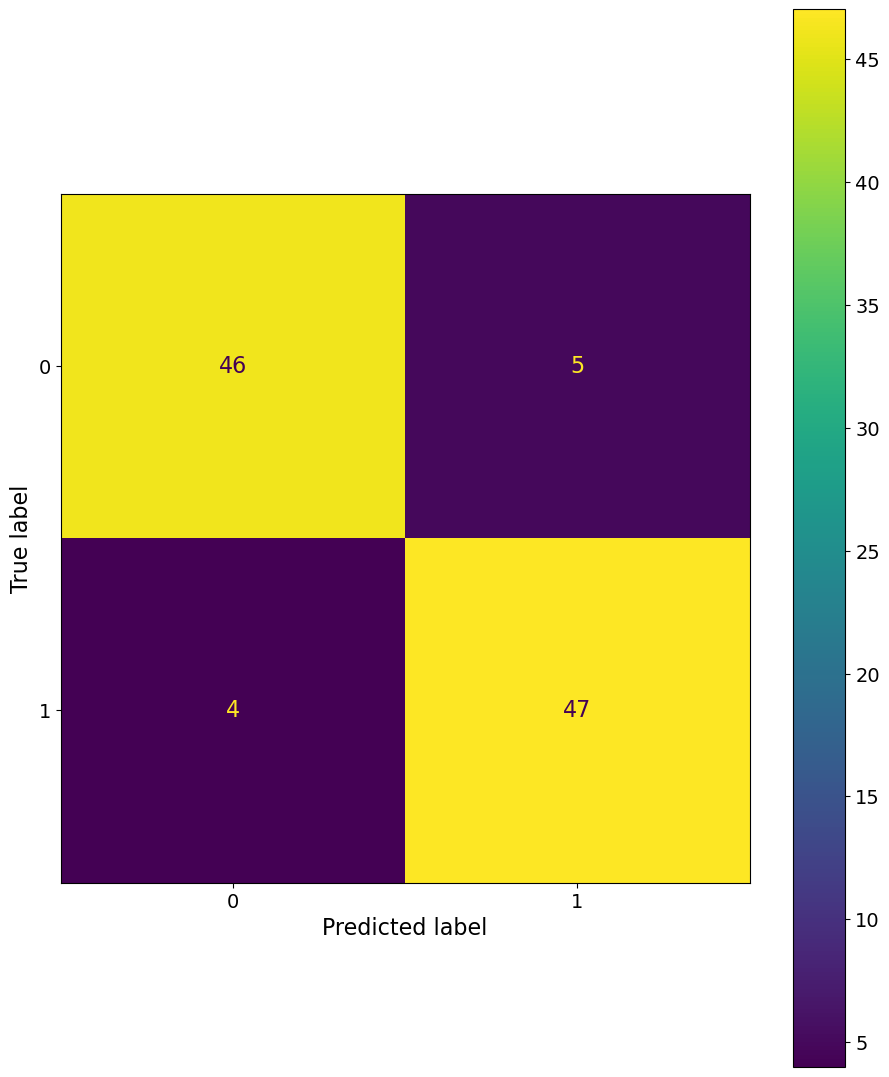

microwave
tbg
MLP
1

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
f1_score: 0.9117562241661059
accuracy: 0.9117647058823529
              precision    recall  f1-score   support

       False       0.92      0.90      0.91        51
        True       0.90      0.92      0.91        51

    accuracy                           0.91       102
   macro avg       0.91      0.91      0.91       102
weighted avg       0.91      0.91      0.91       102



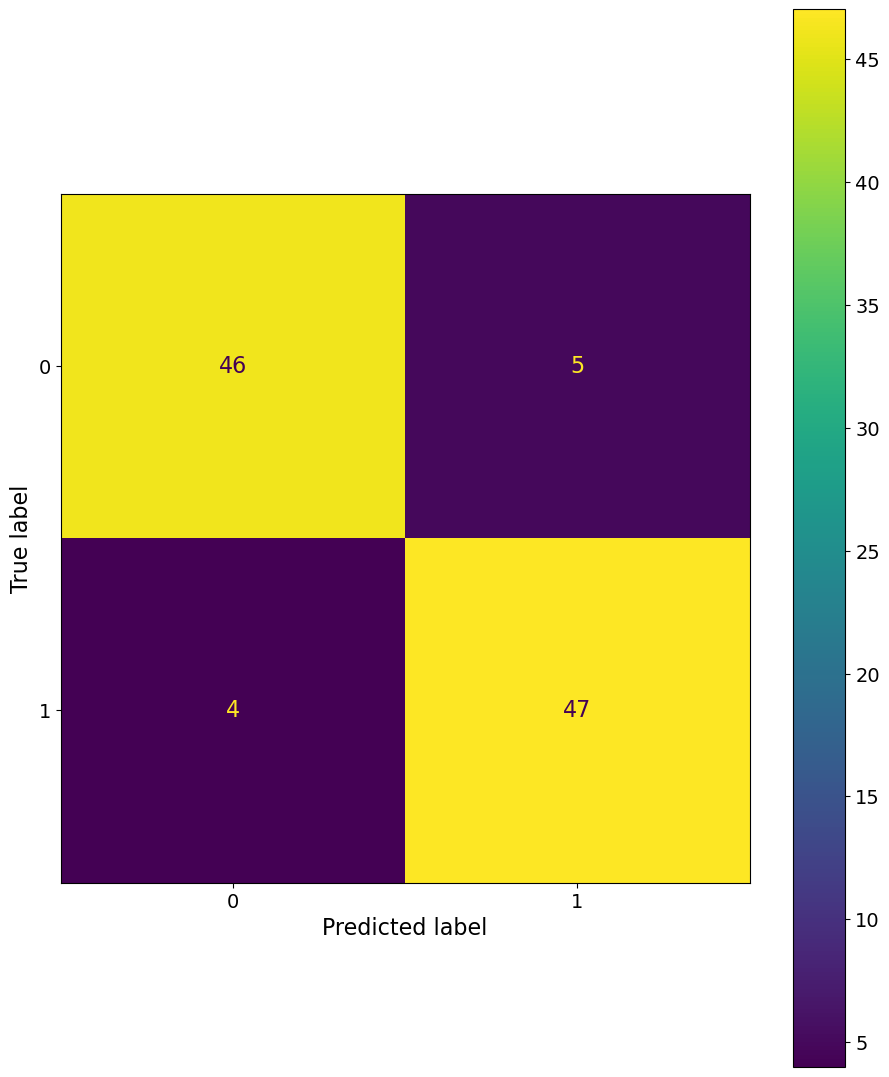

microwave
tbg
MLP
2

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
f1_score: 0.9019607843137255
accuracy: 0.9019607843137255
              precision    recall  f1-score   support

       False       0.90      0.90      0.90        51
        True       0.90      0.90      0.90        51

    accuracy                           0.90       102
   macro avg       0.90      0.90      0.90       102
weighted avg       0.90      0.90      0.90       102



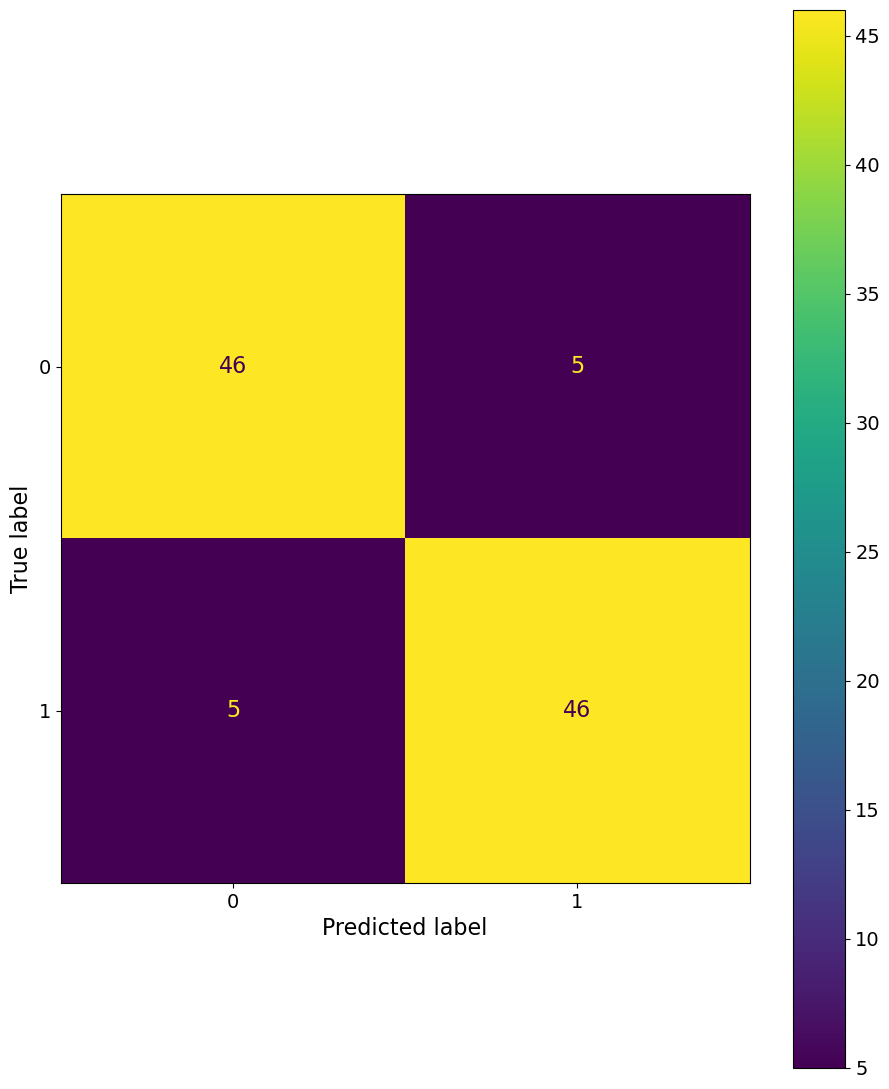

microwave
tbg
MLP
3

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
f1_score: 0.9117562241661059
accuracy: 0.9117647058823529
              precision    recall  f1-score   support

       False       0.92      0.90      0.91        51
        True       0.90      0.92      0.91        51

    accuracy                           0.91       102
   macro avg       0.91      0.91      0.91       102
weighted avg       0.91      0.91      0.91       102



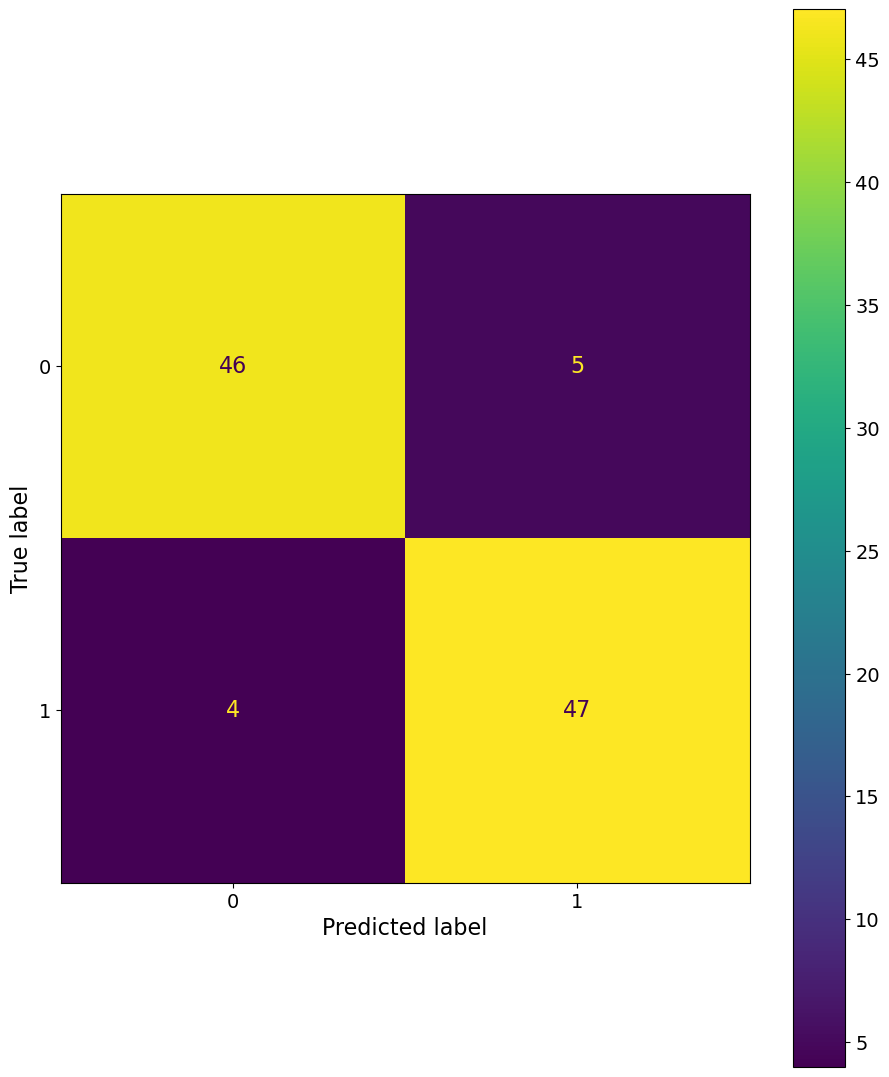

microwave
tbg
MLP
4

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
f1_score: 0.941085868309588
accuracy: 0.9411764705882353
              precision    recall  f1-score   support

       False       0.98      0.90      0.94        51
        True       0.91      0.98      0.94        51

    accuracy                           0.94       102
   macro avg       0.94      0.94      0.94       102
weighted avg       0.94      0.94      0.94       102



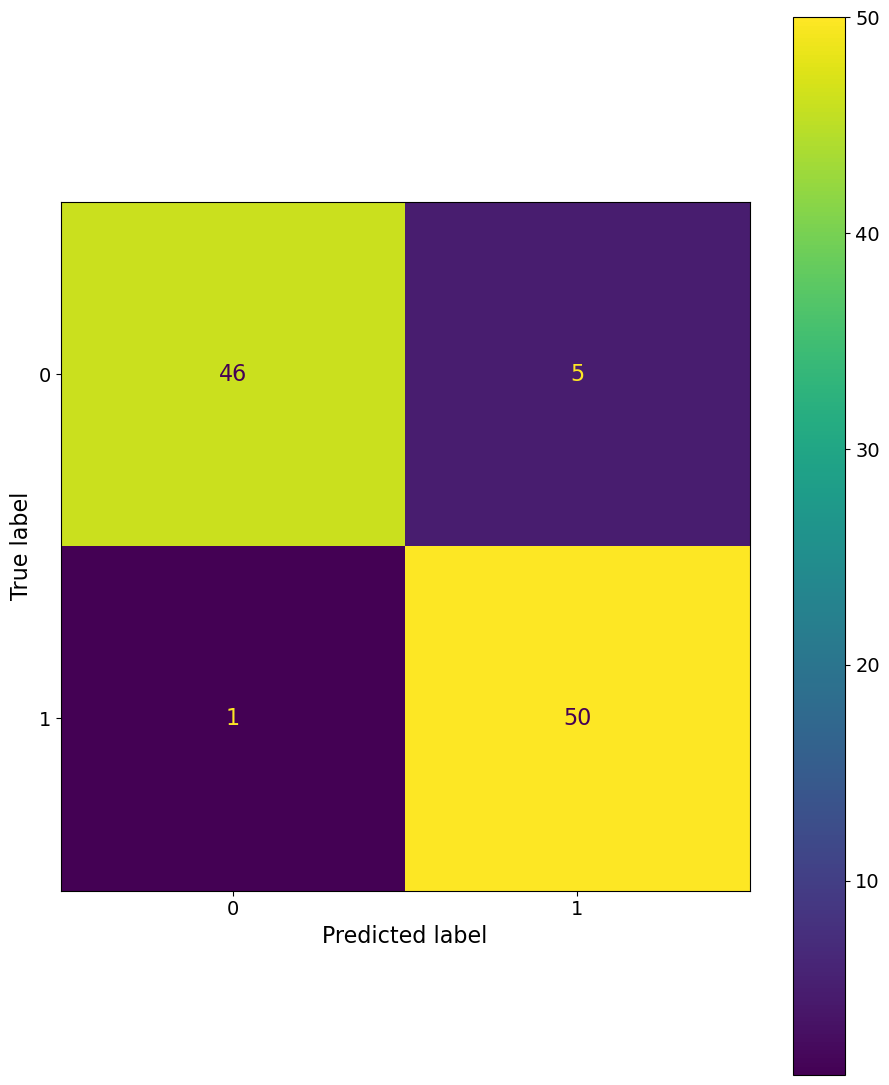

microwave
tbg
XGBoost
0

f1_score: 0.9215384615384616
accuracy: 0.9215686274509803
              precision    recall  f1-score   support

       False       0.94      0.90      0.92        51
        True       0.91      0.94      0.92        51

    accuracy                           0.92       102
   macro avg       0.92      0.92      0.92       102
weighted avg       0.92      0.92      0.92       102



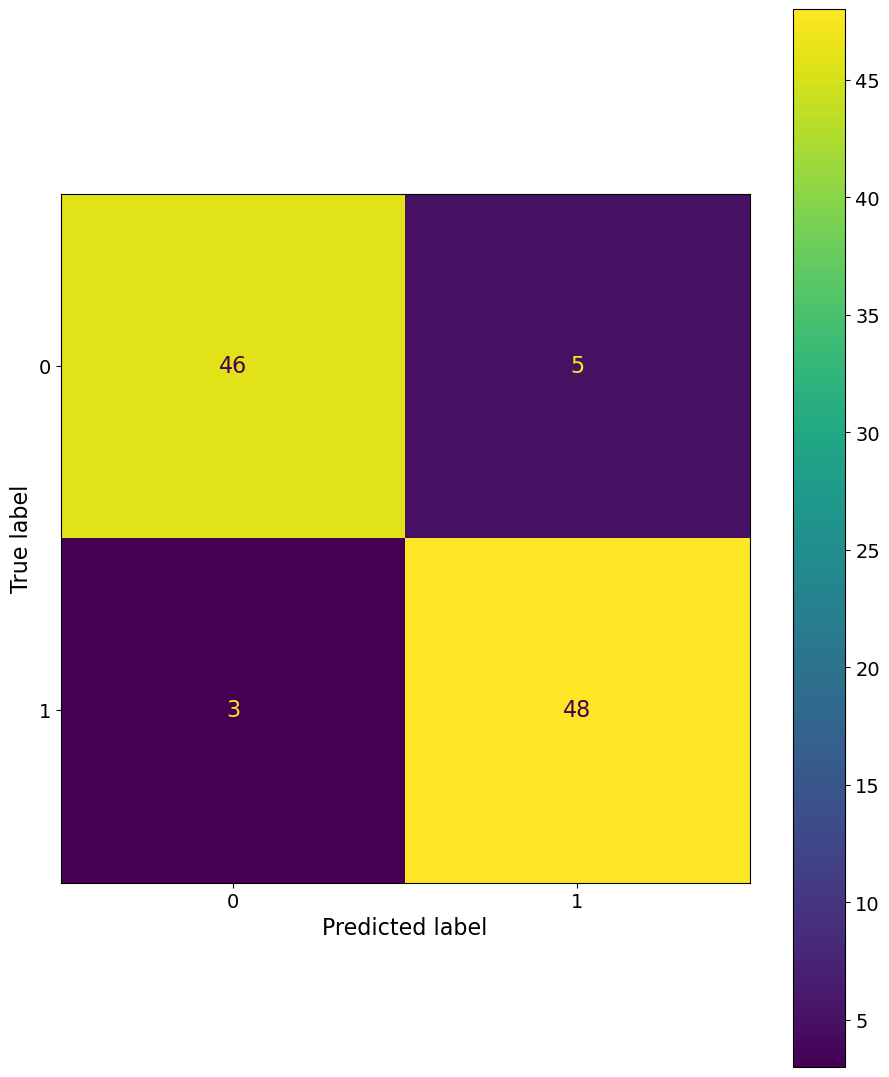

microwave
tbg
SVM
0

f1_score: 0.7916950306330838
accuracy: 0.7941176470588235
              precision    recall  f1-score   support

       False       0.74      0.90      0.81        51
        True       0.88      0.69      0.77        51

    accuracy                           0.79       102
   macro avg       0.81      0.79      0.79       102
weighted avg       0.81      0.79      0.79       102



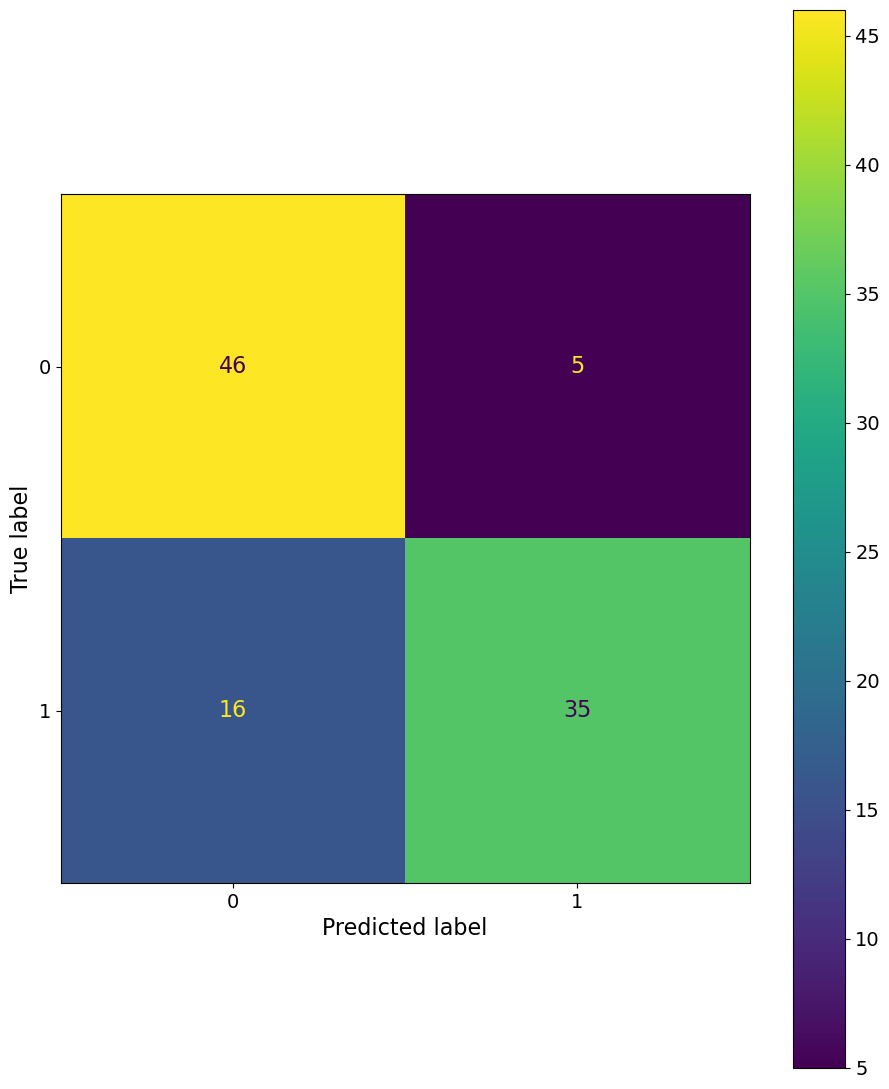

washing machine
gasf
MLP
0

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
f1_score: 0.7928571428571429
accuracy: 0.7931034482758621
              precision    recall  f1-score   support

       False       0.81      0.76      0.79        29
        True       0.77      0.83      0.80        29

    accuracy                           0.79        58
   macro avg       0.79      0.79      0.79        58
weighted avg       0.79      0.79      0.79        58



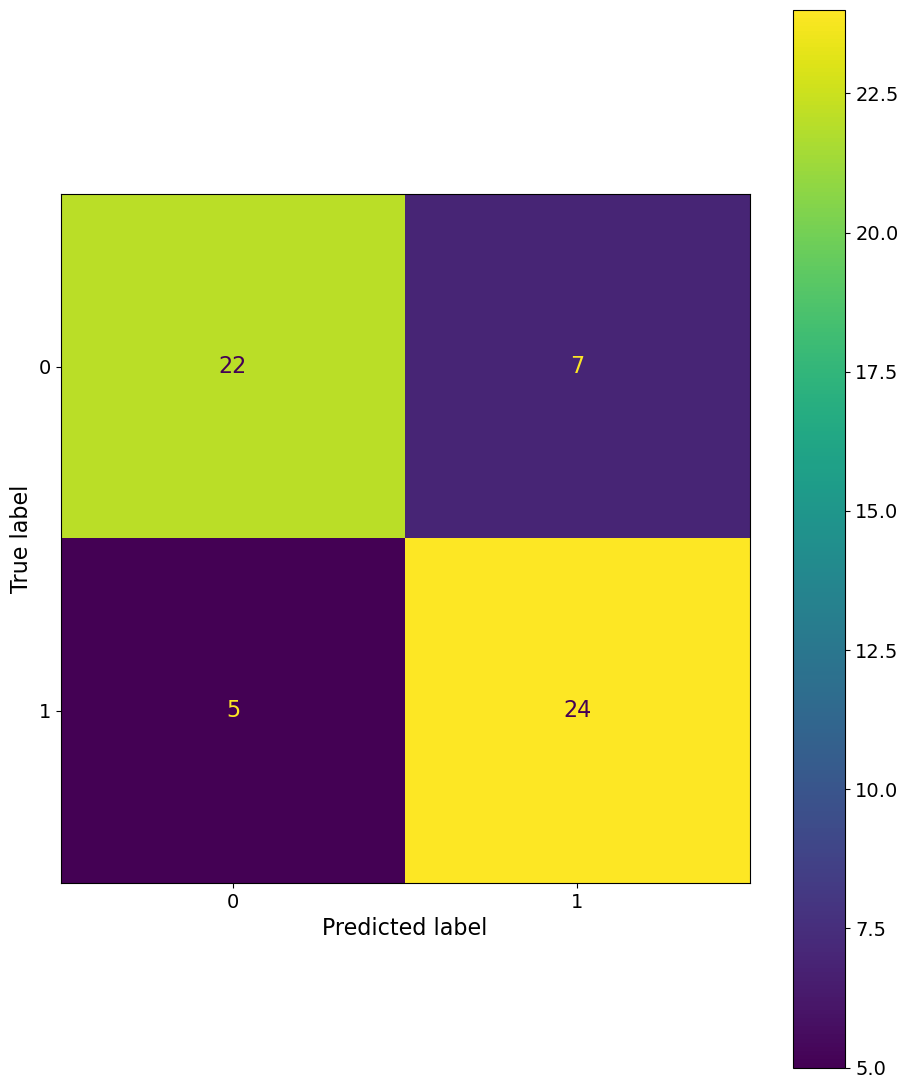

washing machine
gasf
MLP
1

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
f1_score: 0.8447814451382694
accuracy: 0.8448275862068966
              precision    recall  f1-score   support

       False       0.83      0.86      0.85        29
        True       0.86      0.83      0.84        29

    accuracy                           0.84        58
   macro avg       0.85      0.84      0.84        58
weighted avg       0.85      0.84      0.84        58



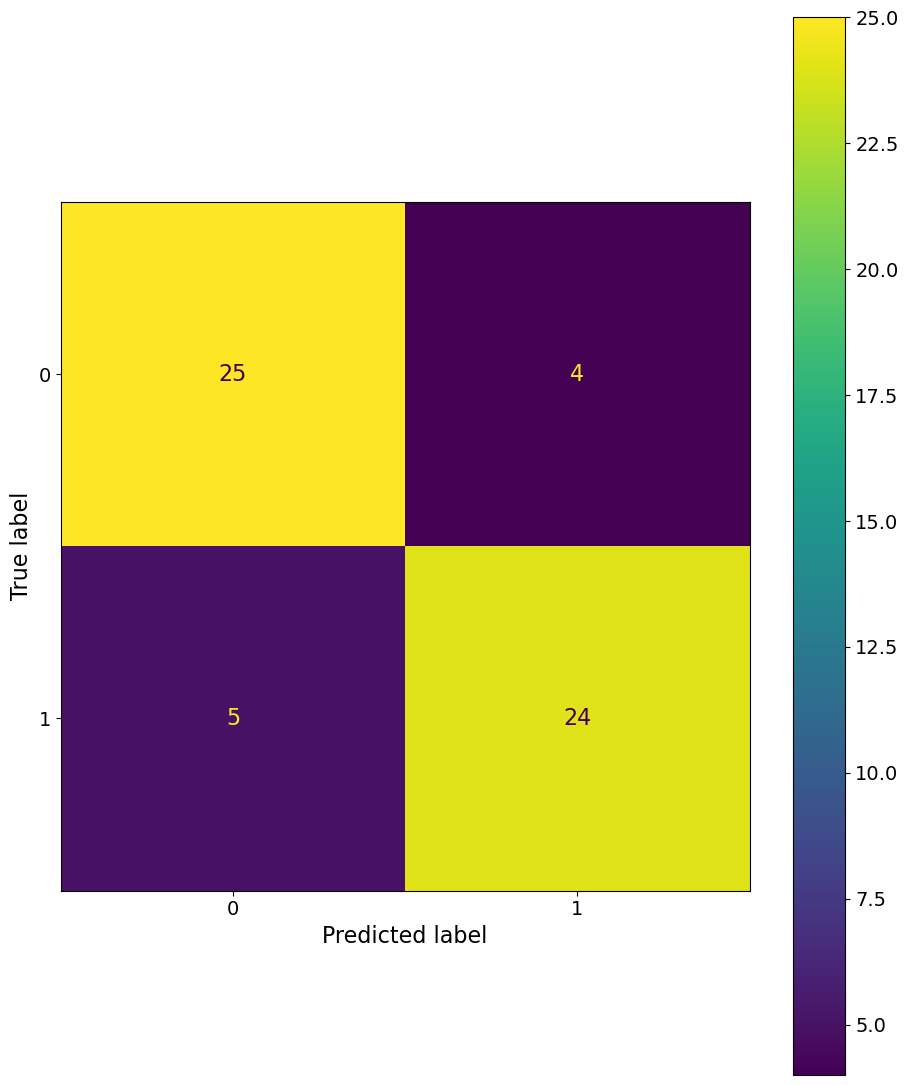

washing machine
gasf
MLP
2

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
f1_score: 0.8614097968936678
accuracy: 0.8620689655172413
              precision    recall  f1-score   support

       False       0.82      0.93      0.87        29
        True       0.92      0.79      0.85        29

    accuracy                           0.86        58
   macro avg       0.87      0.86      0.86        58
weighted avg       0.87      0.86      0.86        58



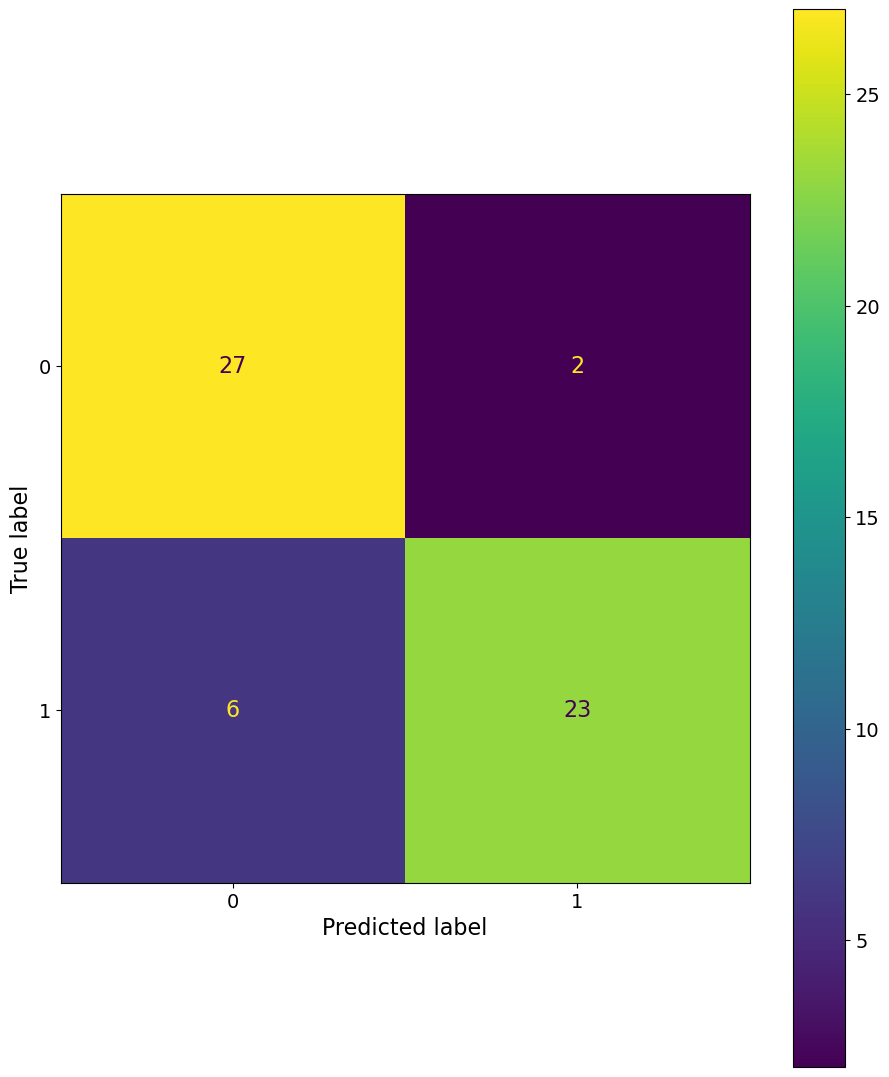

washing machine
gasf
MLP
3

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
f1_score: 0.8620689655172413
accuracy: 0.8620689655172413
              precision    recall  f1-score   support

       False       0.86      0.86      0.86        29
        True       0.86      0.86      0.86        29

    accuracy                           0.86        58
   macro avg       0.86      0.86      0.86        58
weighted avg       0.86      0.86      0.86        58



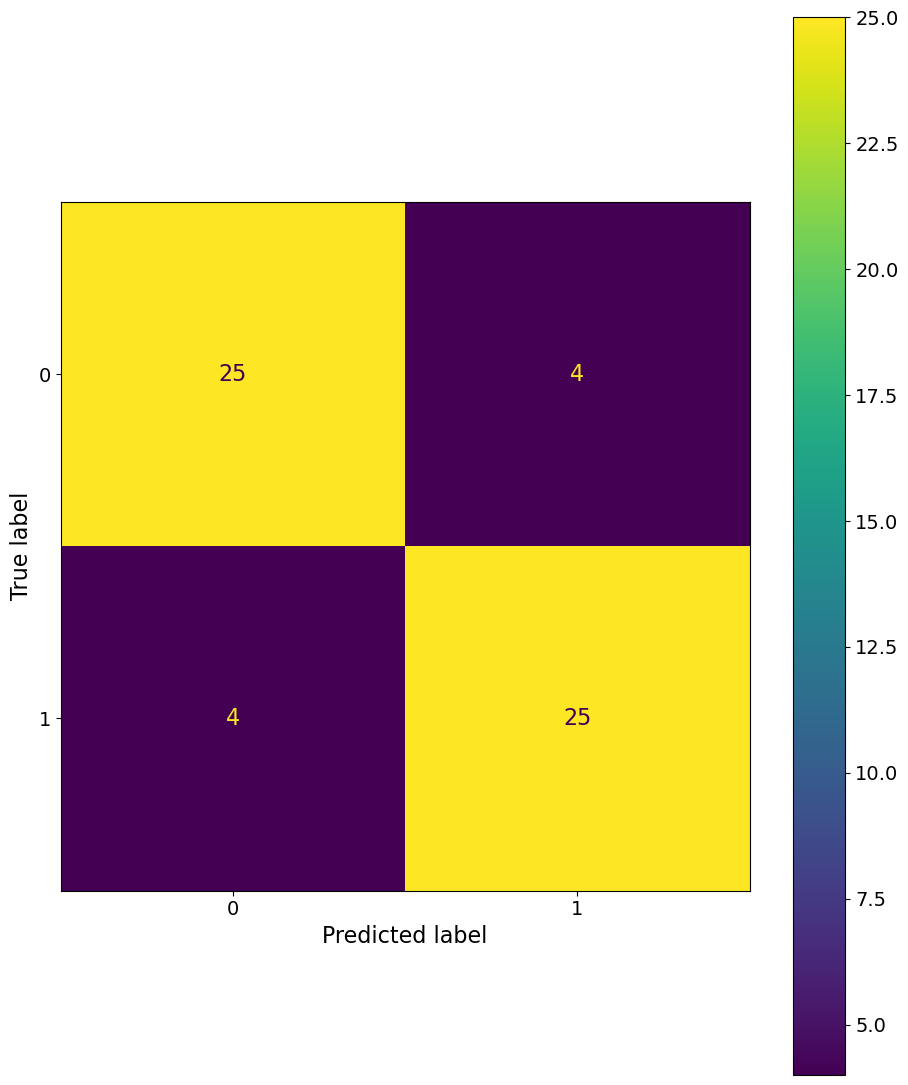

washing machine
gasf
MLP
4

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
f1_score: 0.8620689655172413
accuracy: 0.8620689655172413
              precision    recall  f1-score   support

       False       0.86      0.86      0.86        29
        True       0.86      0.86      0.86        29

    accuracy                           0.86        58
   macro avg       0.86      0.86      0.86        58
weighted avg       0.86      0.86      0.86        58



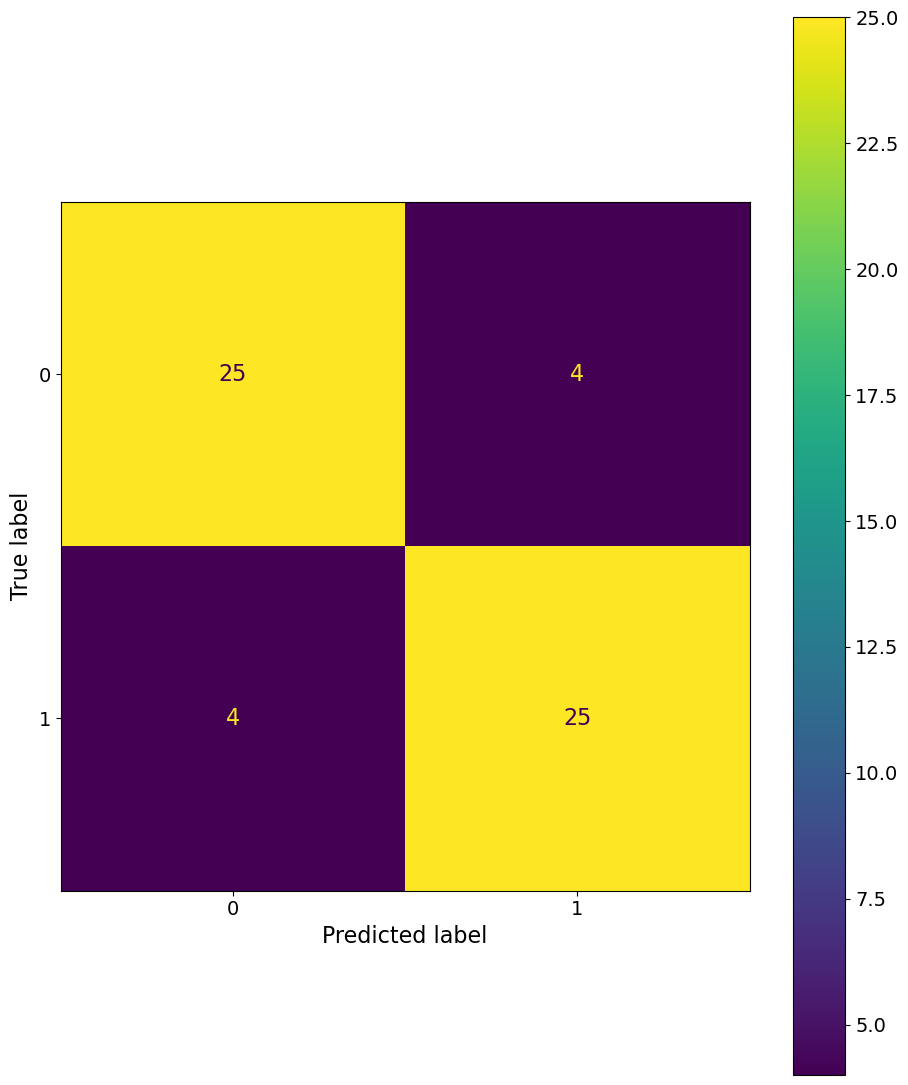

washing machine
gasf
XGBoost
0

f1_score: 0.8257211538461539
accuracy: 0.8275862068965517
              precision    recall  f1-score   support

       False       0.77      0.93      0.84        29
        True       0.91      0.72      0.81        29

    accuracy                           0.83        58
   macro avg       0.84      0.83      0.83        58
weighted avg       0.84      0.83      0.83        58



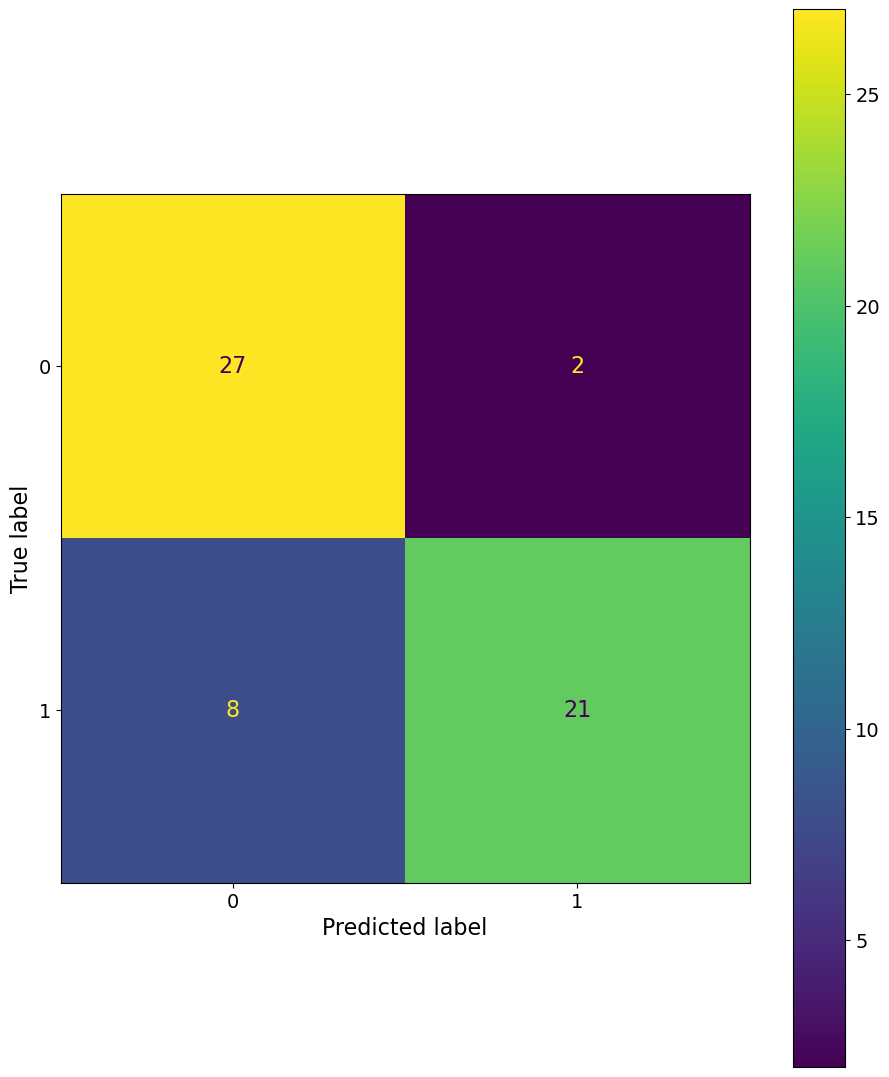

washing machine
gasf
SVM
0

f1_score: 0.7640062597809076
accuracy: 0.7758620689655172
              precision    recall  f1-score   support

       False       0.69      1.00      0.82        29
        True       1.00      0.55      0.71        29

    accuracy                           0.78        58
   macro avg       0.85      0.78      0.76        58
weighted avg       0.85      0.78      0.76        58



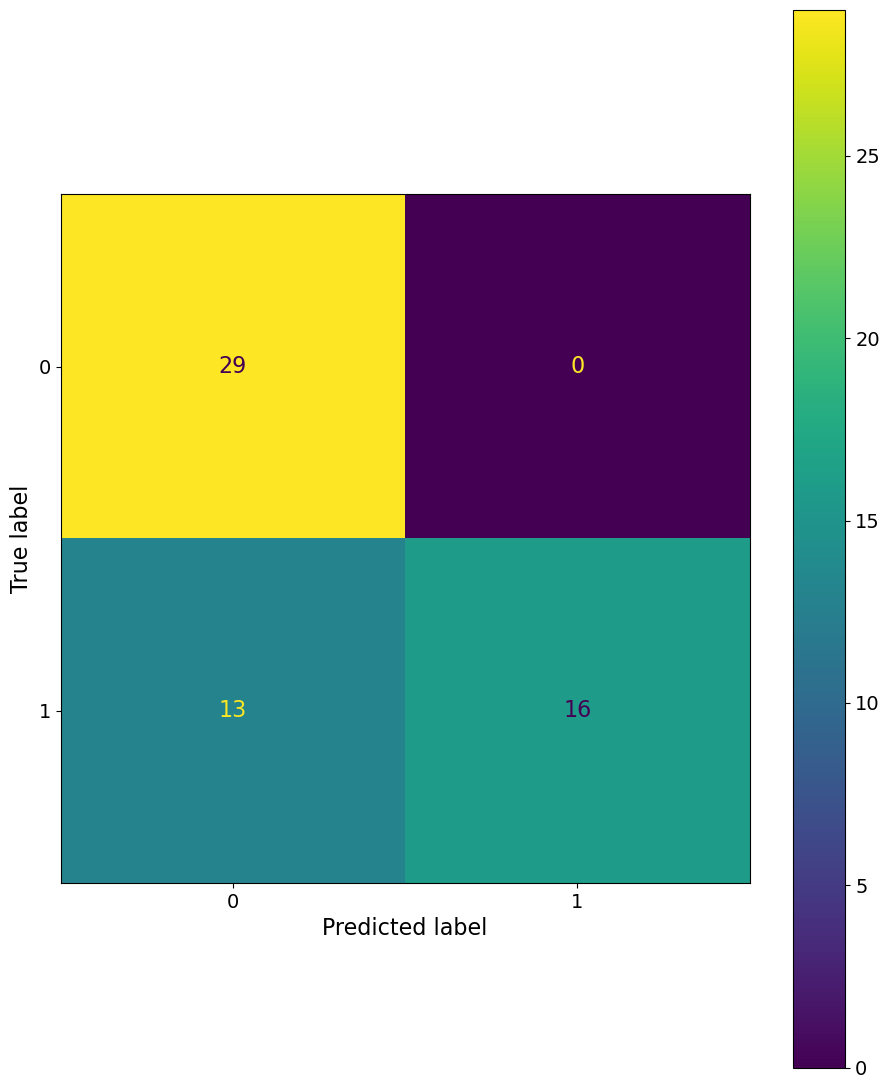

washing machine
gadf
MLP
0

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
f1_score: 0.8605769230769231
accuracy: 0.8620689655172413
              precision    recall  f1-score   support

       False       0.80      0.97      0.88        29
        True       0.96      0.76      0.85        29

    accuracy                           0.86        58
   macro avg       0.88      0.86      0.86        58
weighted avg       0.88      0.86      0.86        58



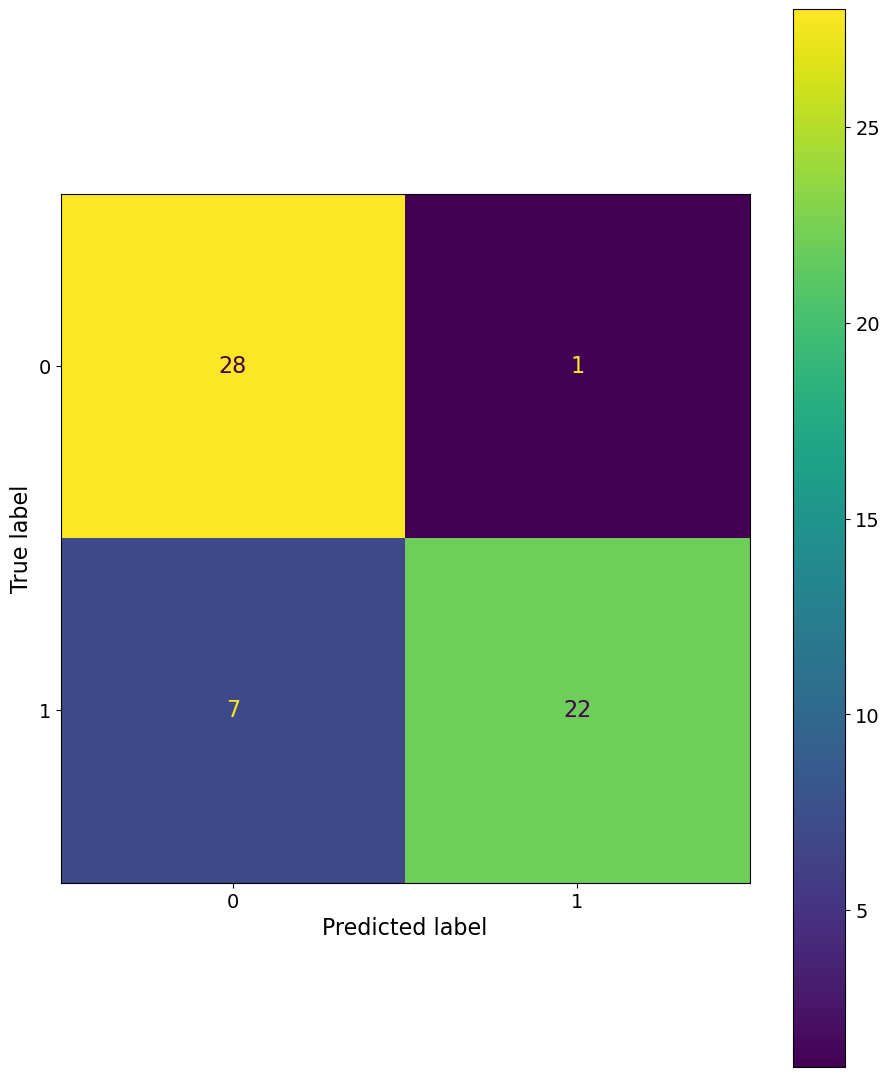

washing machine
gadf
MLP
1

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
f1_score: 0.8784067085953878
accuracy: 0.8793103448275862
              precision    recall  f1-score   support

       False       0.82      0.97      0.89        29
        True       0.96      0.79      0.87        29

    accuracy                           0.88        58
   macro avg       0.89      0.88      0.88        58
weighted avg       0.89      0.88      0.88        58



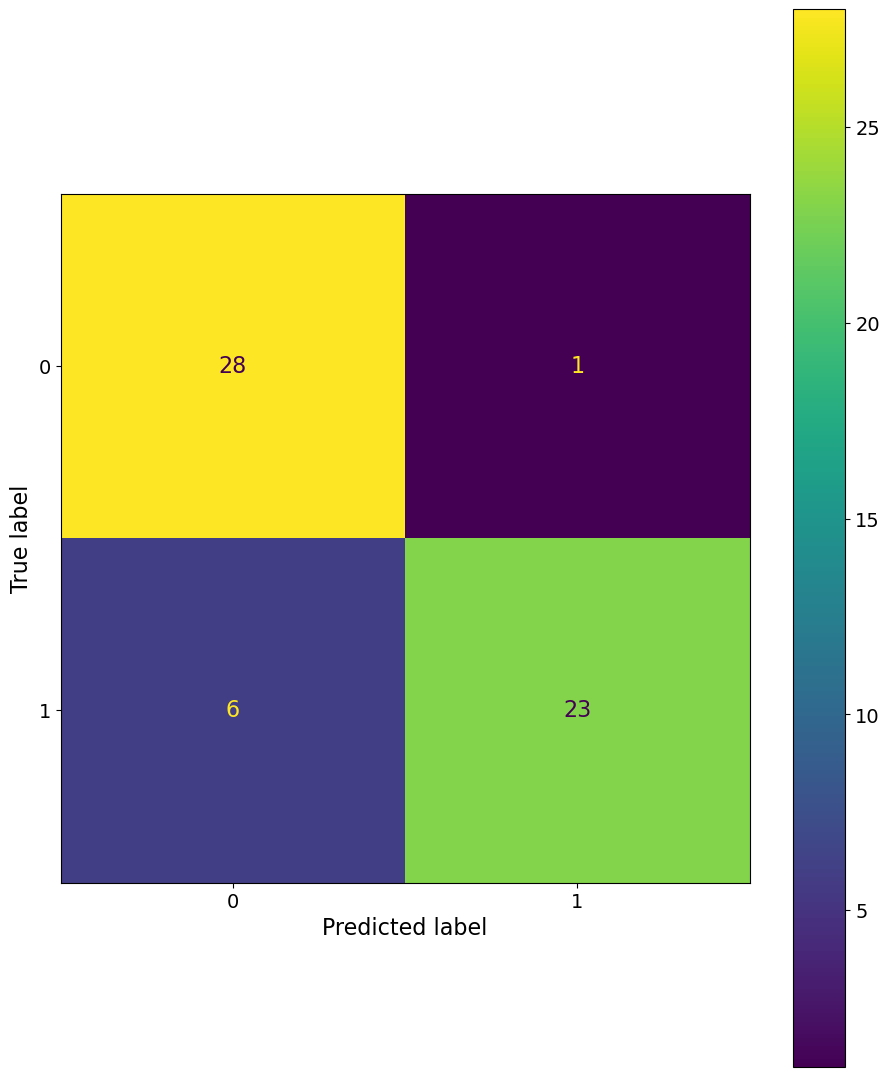

washing machine
gadf
MLP
2

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
f1_score: 0.8784067085953878
accuracy: 0.8793103448275862
              precision    recall  f1-score   support

       False       0.82      0.97      0.89        29
        True       0.96      0.79      0.87        29

    accuracy                           0.88        58
   macro avg       0.89      0.88      0.88        58
weighted avg       0.89      0.88      0.88        58



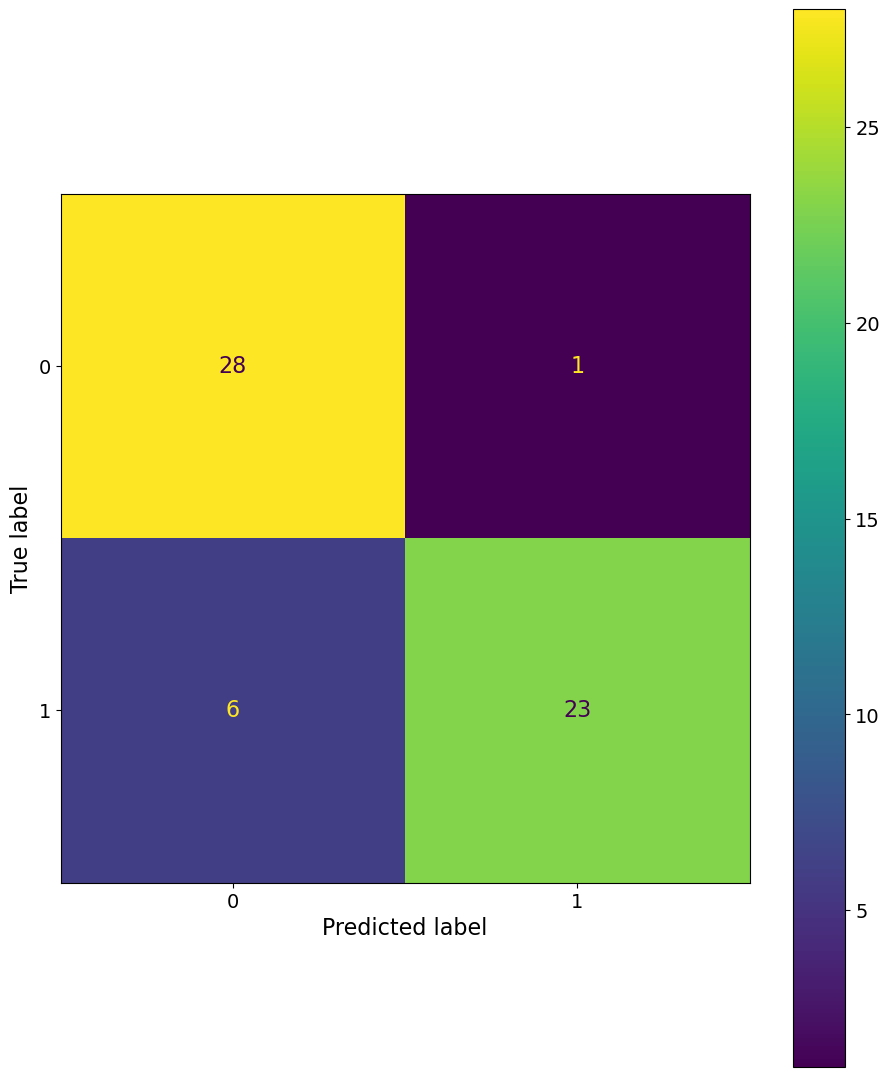

washing machine
gadf
MLP
3

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
f1_score: 0.8605769230769231
accuracy: 0.8620689655172413
              precision    recall  f1-score   support

       False       0.80      0.97      0.88        29
        True       0.96      0.76      0.85        29

    accuracy                           0.86        58
   macro avg       0.88      0.86      0.86        58
weighted avg       0.88      0.86      0.86        58



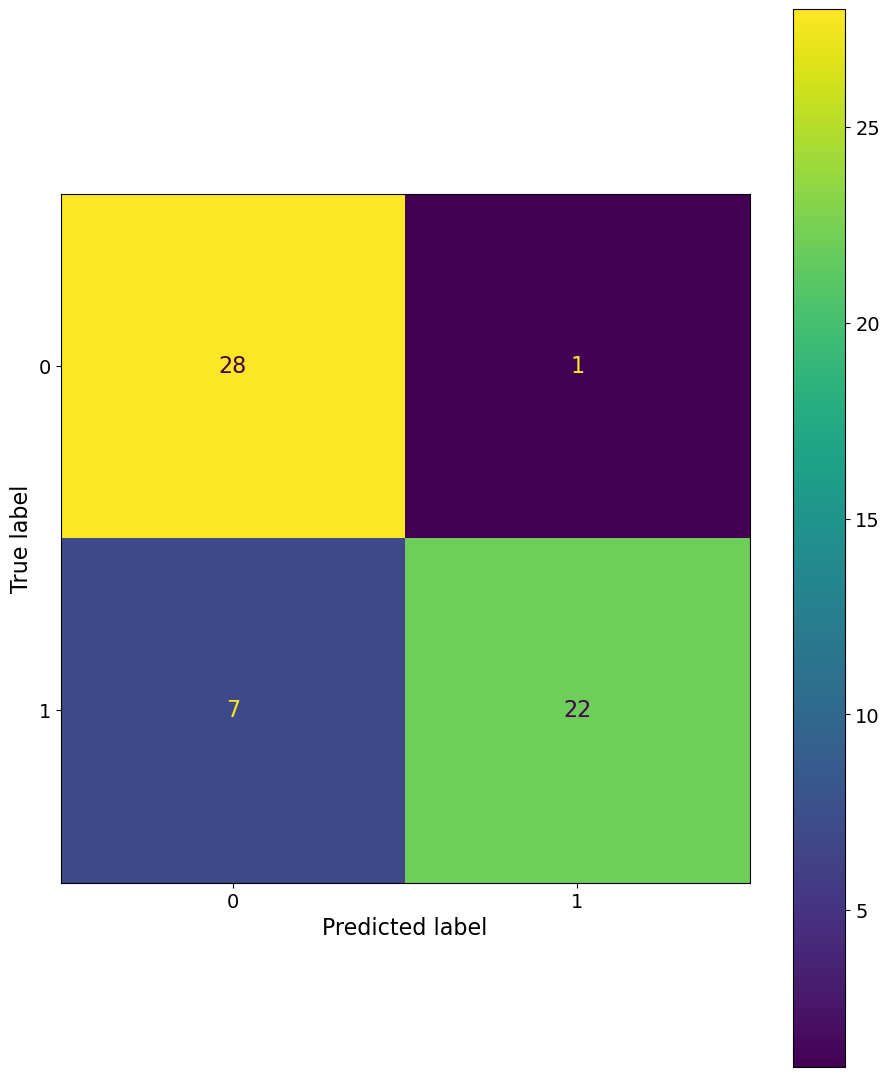

washing machine
gadf
MLP
4

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
f1_score: 0.8605769230769231
accuracy: 0.8620689655172413
              precision    recall  f1-score   support

       False       0.80      0.97      0.88        29
        True       0.96      0.76      0.85        29

    accuracy                           0.86        58
   macro avg       0.88      0.86      0.86        58
weighted avg       0.88      0.86      0.86        58



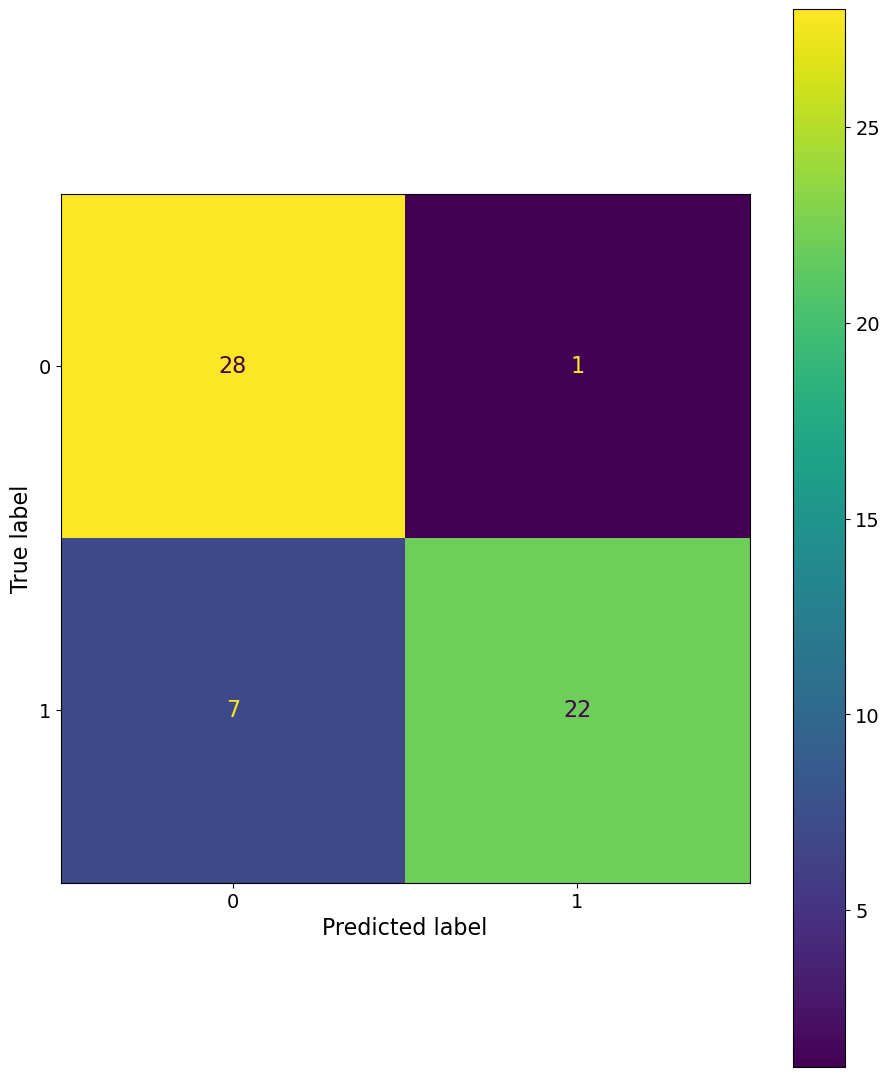

washing machine
gadf
XGBoost
0

f1_score: 0.8789865871833085
accuracy: 0.8793103448275862
              precision    recall  f1-score   support

       False       0.84      0.93      0.89        29
        True       0.92      0.83      0.87        29

    accuracy                           0.88        58
   macro avg       0.88      0.88      0.88        58
weighted avg       0.88      0.88      0.88        58



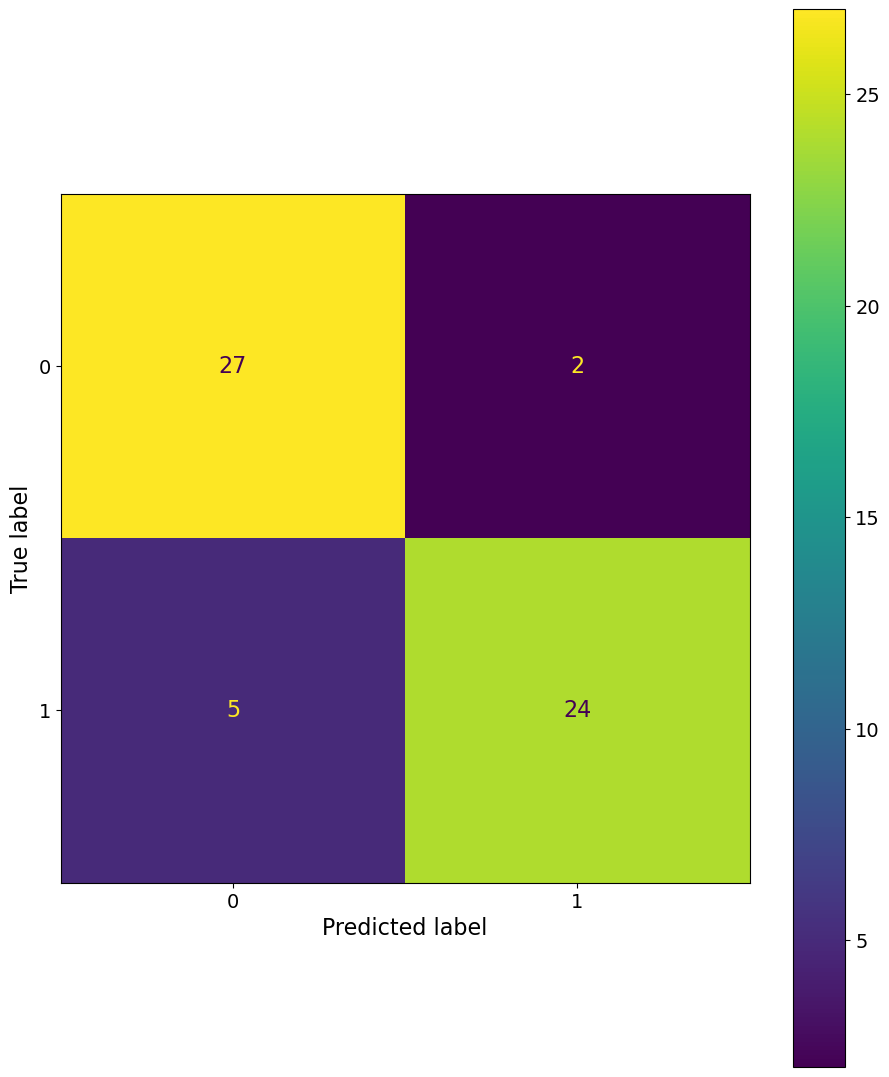

washing machine
gadf
SVM
0

f1_score: 0.8223039215686274
accuracy: 0.8275862068965517
              precision    recall  f1-score   support

       False       0.74      1.00      0.85        29
        True       1.00      0.66      0.79        29

    accuracy                           0.83        58
   macro avg       0.87      0.83      0.82        58
weighted avg       0.87      0.83      0.82        58



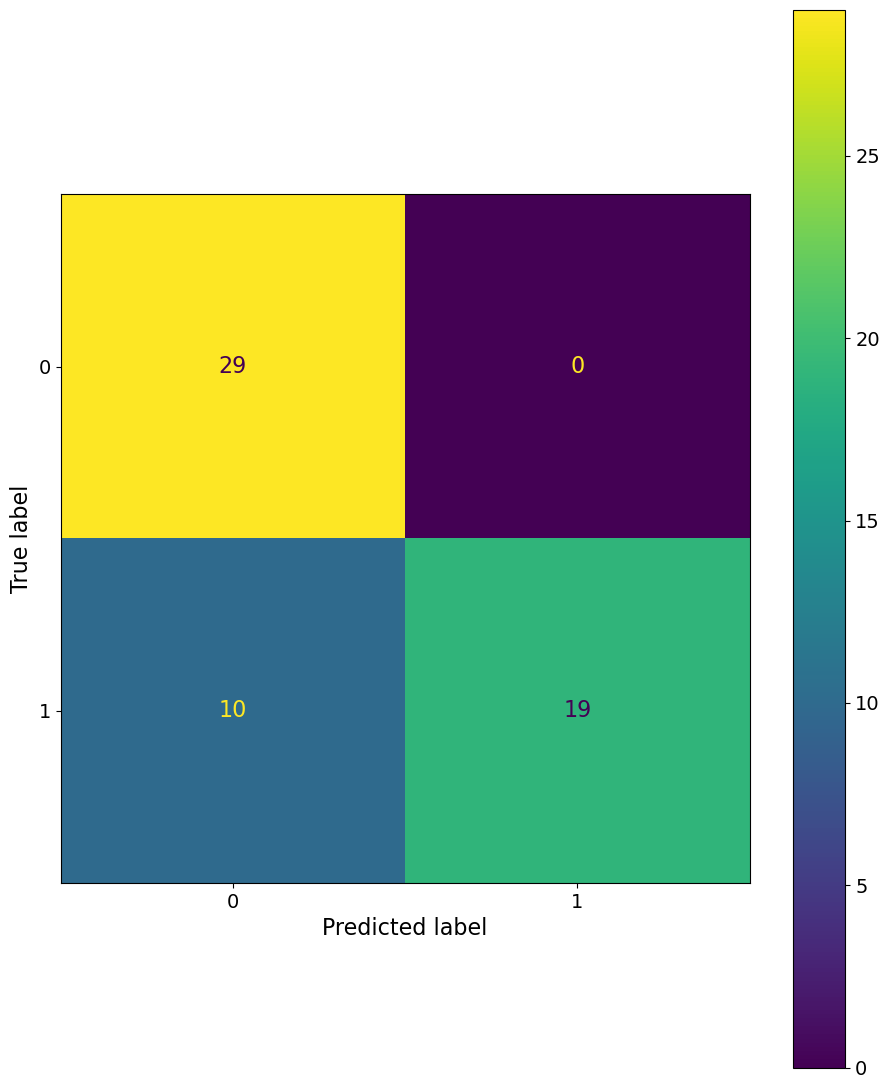

washing machine
mtf
MLP
0

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
f1_score: 0.7703320134023759
accuracy: 0.7758620689655172
              precision    recall  f1-score   support

       False       0.71      0.93      0.81        29
        True       0.90      0.62      0.73        29

    accuracy                           0.78        58
   macro avg       0.81      0.78      0.77        58
weighted avg       0.81      0.78      0.77        58



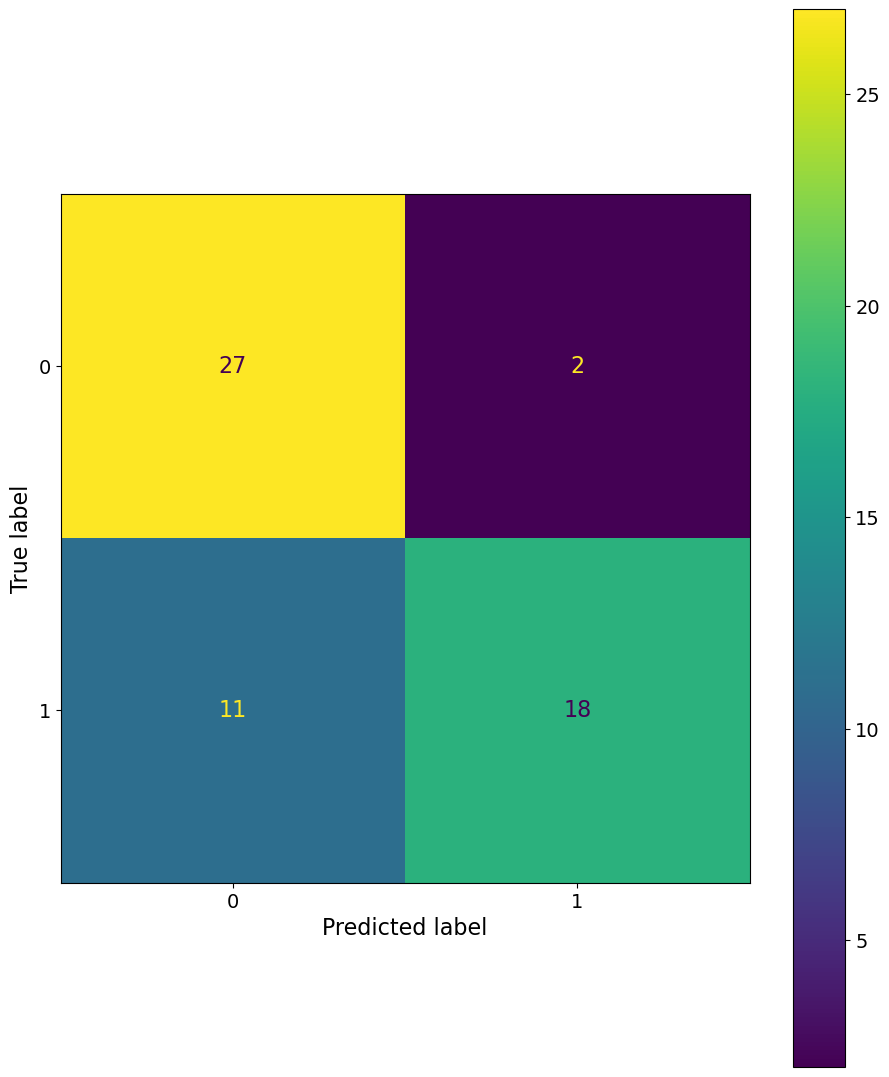

washing machine
mtf
MLP
1

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
f1_score: 0.7539393939393939
accuracy: 0.7586206896551724
              precision    recall  f1-score   support

       False       0.70      0.90      0.79        29
        True       0.86      0.62      0.72        29

    accuracy                           0.76        58
   macro avg       0.78      0.76      0.75        58
weighted avg       0.78      0.76      0.75        58



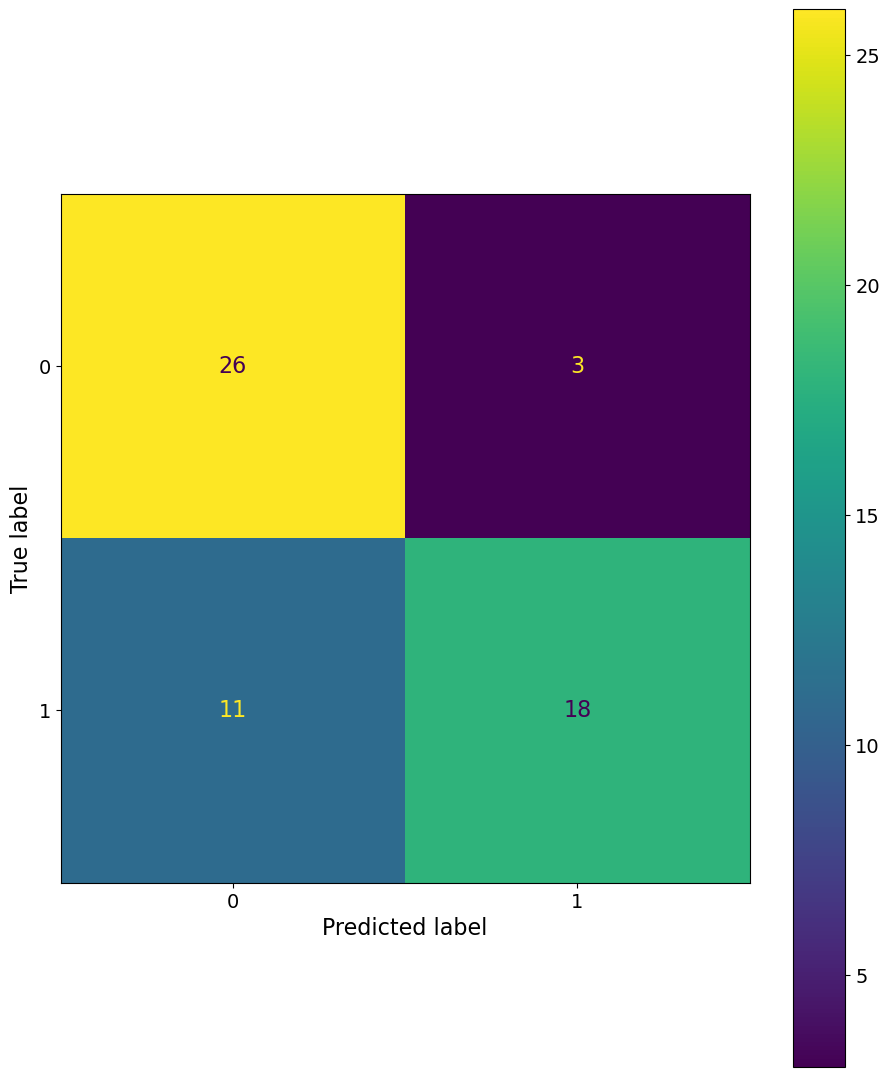

washing machine
mtf
MLP
2

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
f1_score: 0.7187878787878788
accuracy: 0.7241379310344828
              precision    recall  f1-score   support

       False       0.68      0.86      0.76        29
        True       0.81      0.59      0.68        29

    accuracy                           0.72        58
   macro avg       0.74      0.72      0.72        58
weighted avg       0.74      0.72      0.72        58



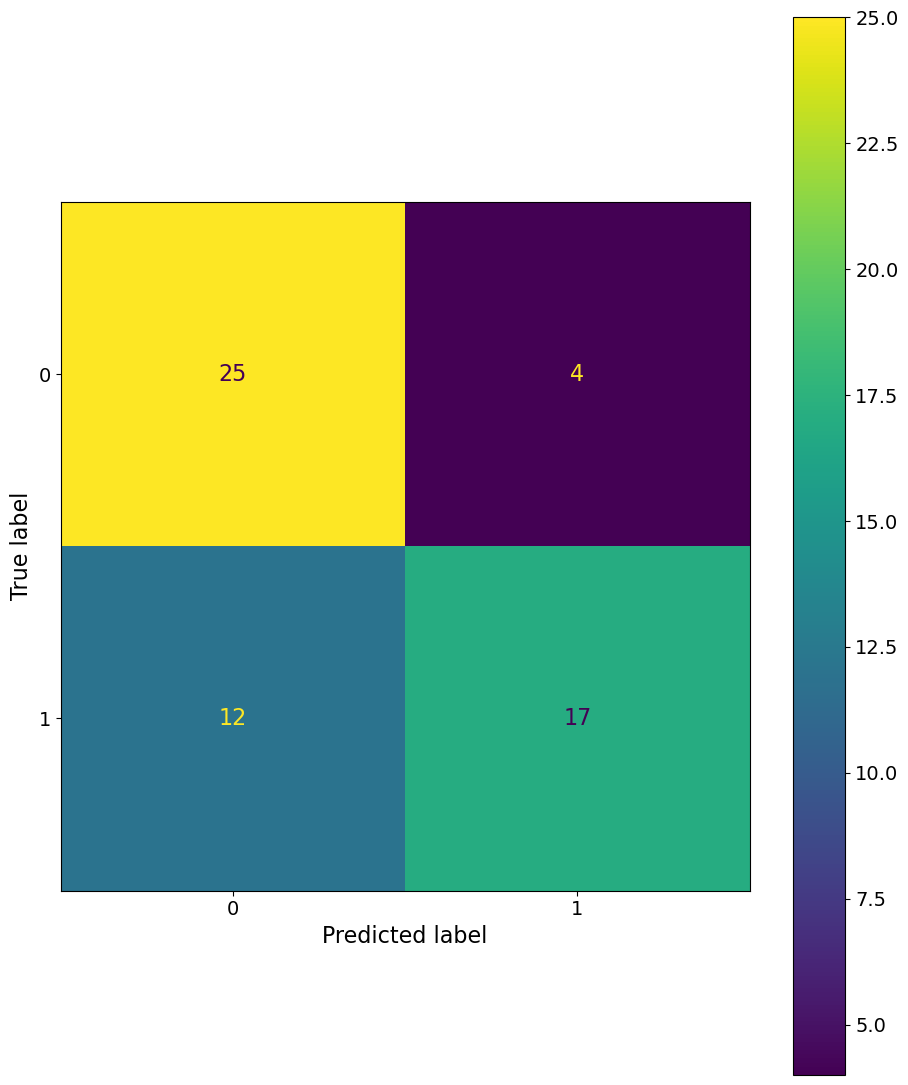

washing machine
mtf
MLP
3

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
f1_score: 0.7725490196078432
accuracy: 0.7758620689655172
              precision    recall  f1-score   support

       False       0.72      0.90      0.80        29
        True       0.86      0.66      0.75        29

    accuracy                           0.78        58
   macro avg       0.79      0.78      0.77        58
weighted avg       0.79      0.78      0.77        58



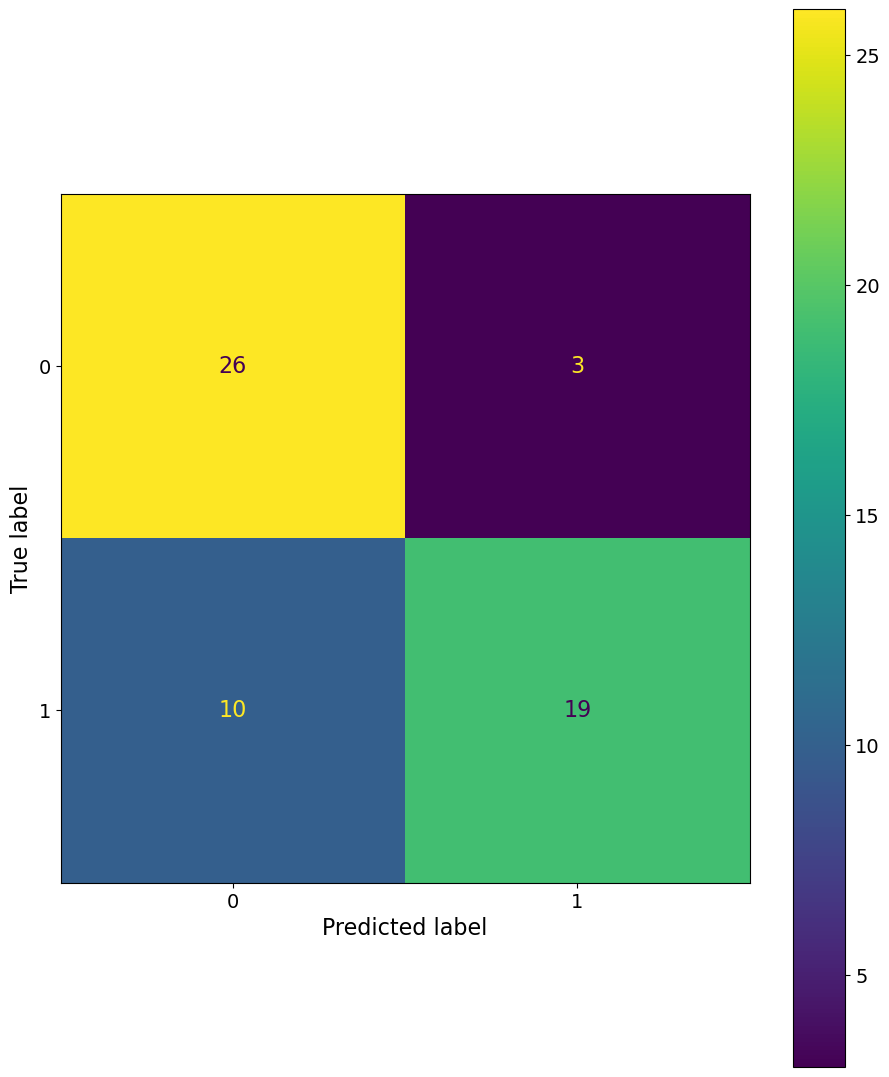

washing machine
mtf
MLP
4

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
f1_score: 0.7539393939393939
accuracy: 0.7586206896551724
              precision    recall  f1-score   support

       False       0.70      0.90      0.79        29
        True       0.86      0.62      0.72        29

    accuracy                           0.76        58
   macro avg       0.78      0.76      0.75        58
weighted avg       0.78      0.76      0.75        58



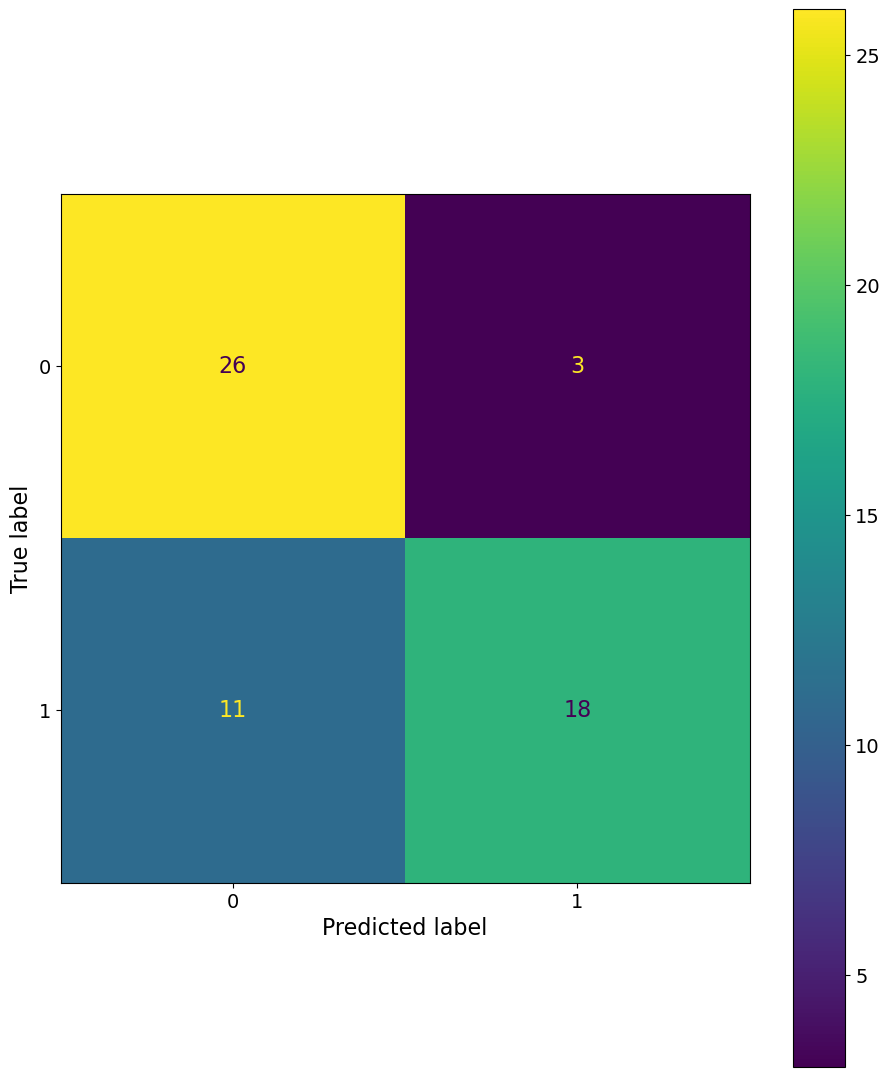

washing machine
mtf
XGBoost
0

f1_score: 0.8273809523809523
accuracy: 0.8275862068965517
              precision    recall  f1-score   support

       False       0.81      0.86      0.83        29
        True       0.85      0.79      0.82        29

    accuracy                           0.83        58
   macro avg       0.83      0.83      0.83        58
weighted avg       0.83      0.83      0.83        58



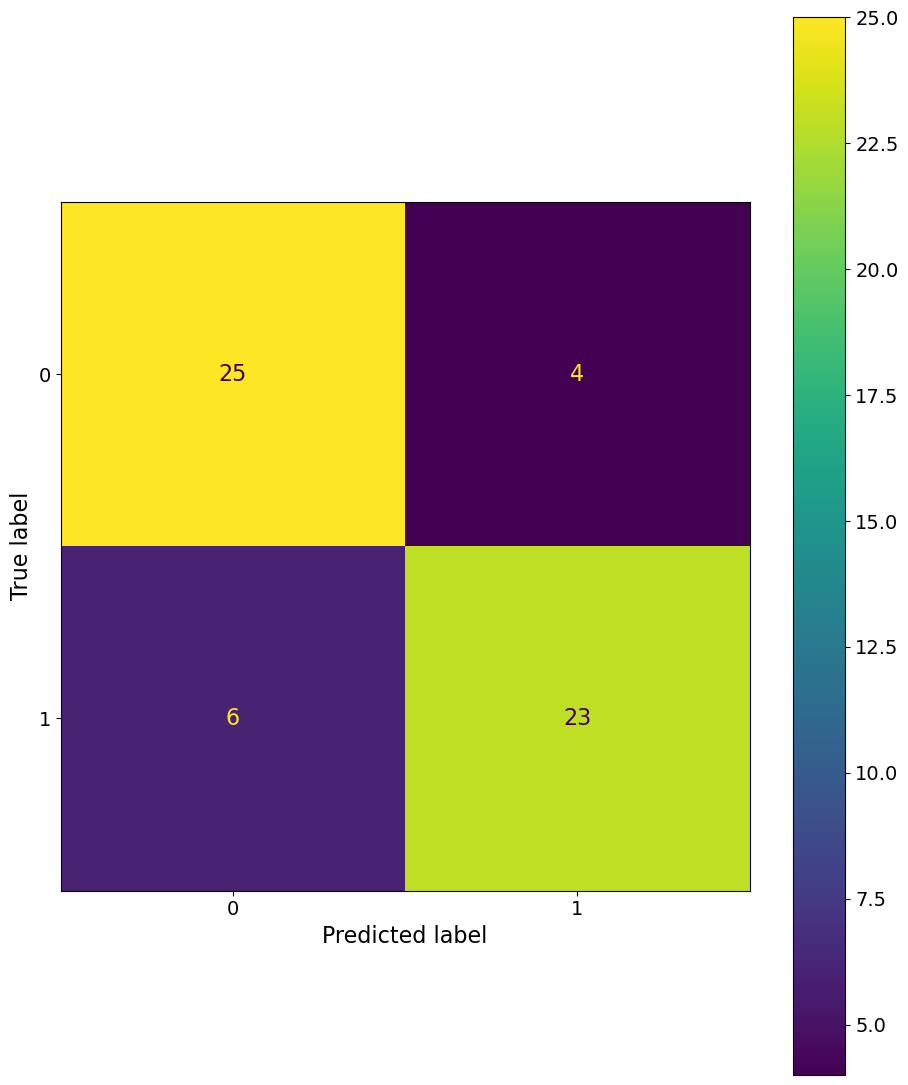

washing machine
mtf
SVM
0

f1_score: 0.7838509316770186
accuracy: 0.7931034482758621
              precision    recall  f1-score   support

       False       0.71      1.00      0.83        29
        True       1.00      0.59      0.74        29

    accuracy                           0.79        58
   macro avg       0.85      0.79      0.78        58
weighted avg       0.85      0.79      0.78        58



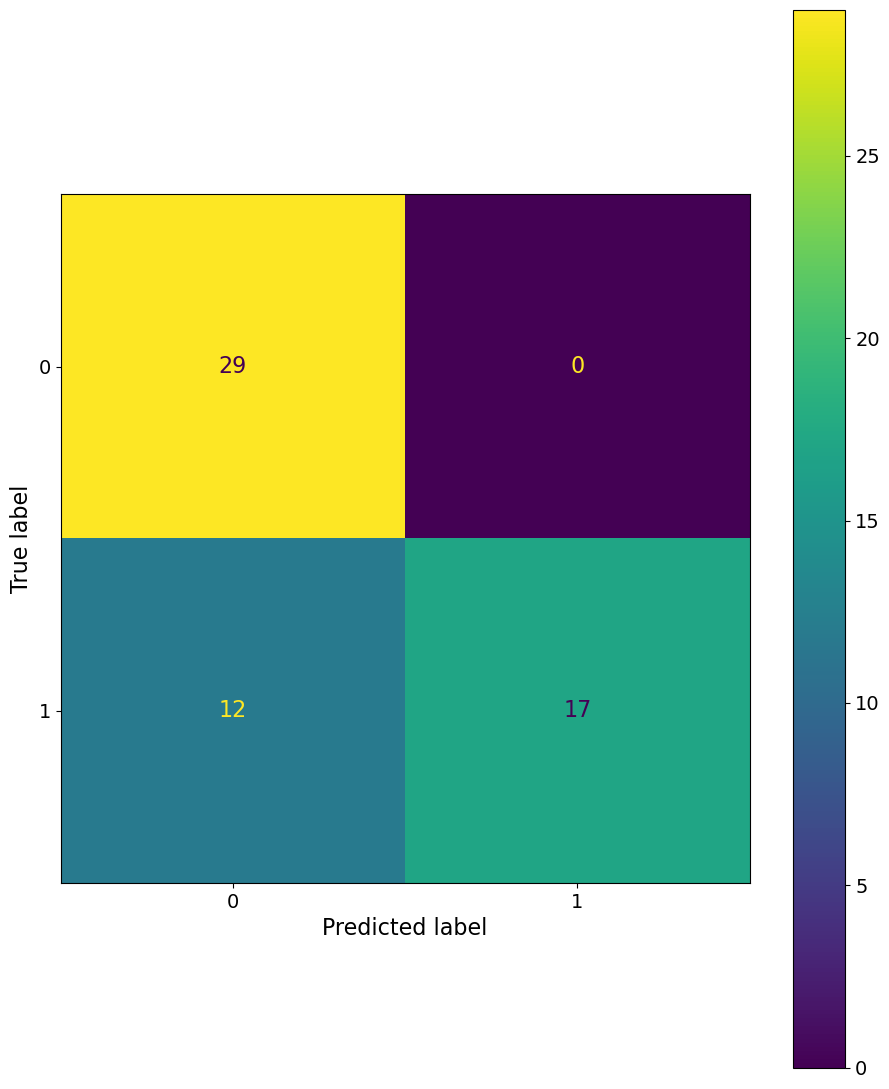

washing machine
rp
MLP
0

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
f1_score: 0.7890909090909091
accuracy: 0.7931034482758621
              precision    recall  f1-score   support

       False       0.73      0.93      0.82        29
        True       0.90      0.66      0.76        29

    accuracy                           0.79        58
   macro avg       0.82      0.79      0.79        58
weighted avg       0.82      0.79      0.79        58



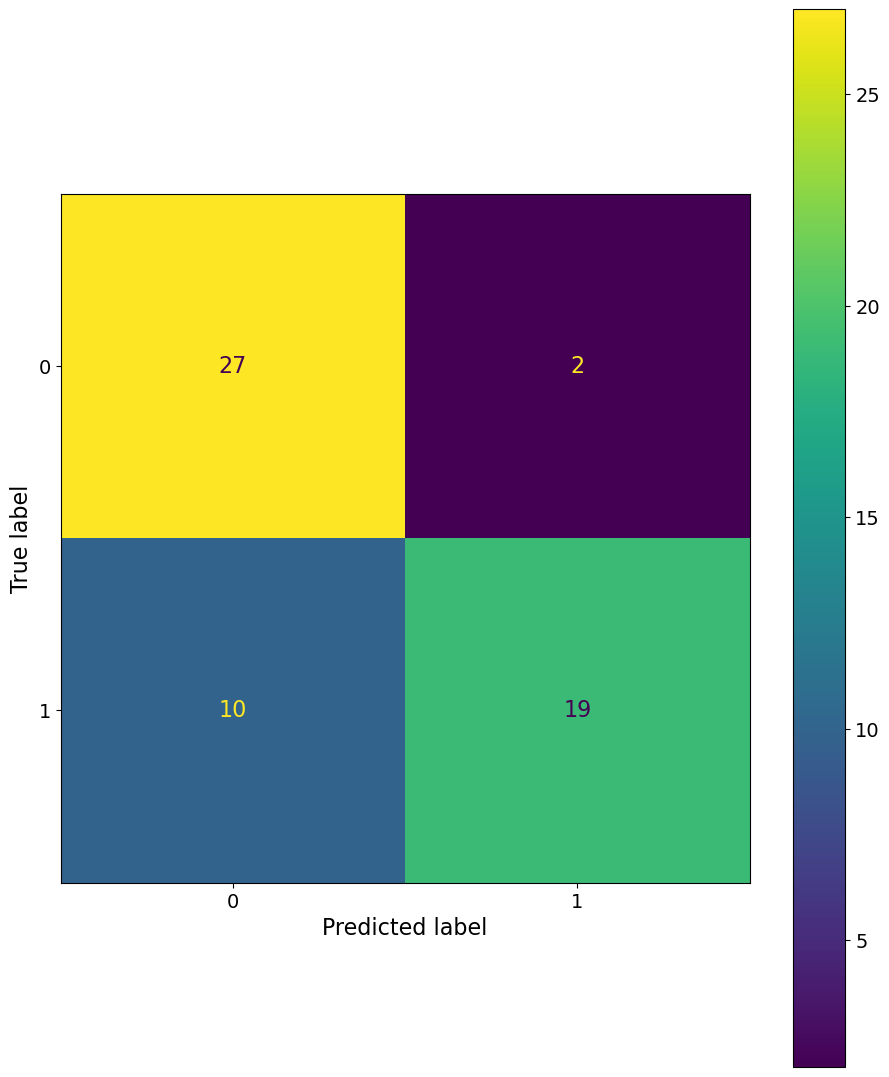

washing machine
rp
MLP
1

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
f1_score: 0.7890909090909091
accuracy: 0.7931034482758621
              precision    recall  f1-score   support

       False       0.73      0.93      0.82        29
        True       0.90      0.66      0.76        29

    accuracy                           0.79        58
   macro avg       0.82      0.79      0.79        58
weighted avg       0.82      0.79      0.79        58



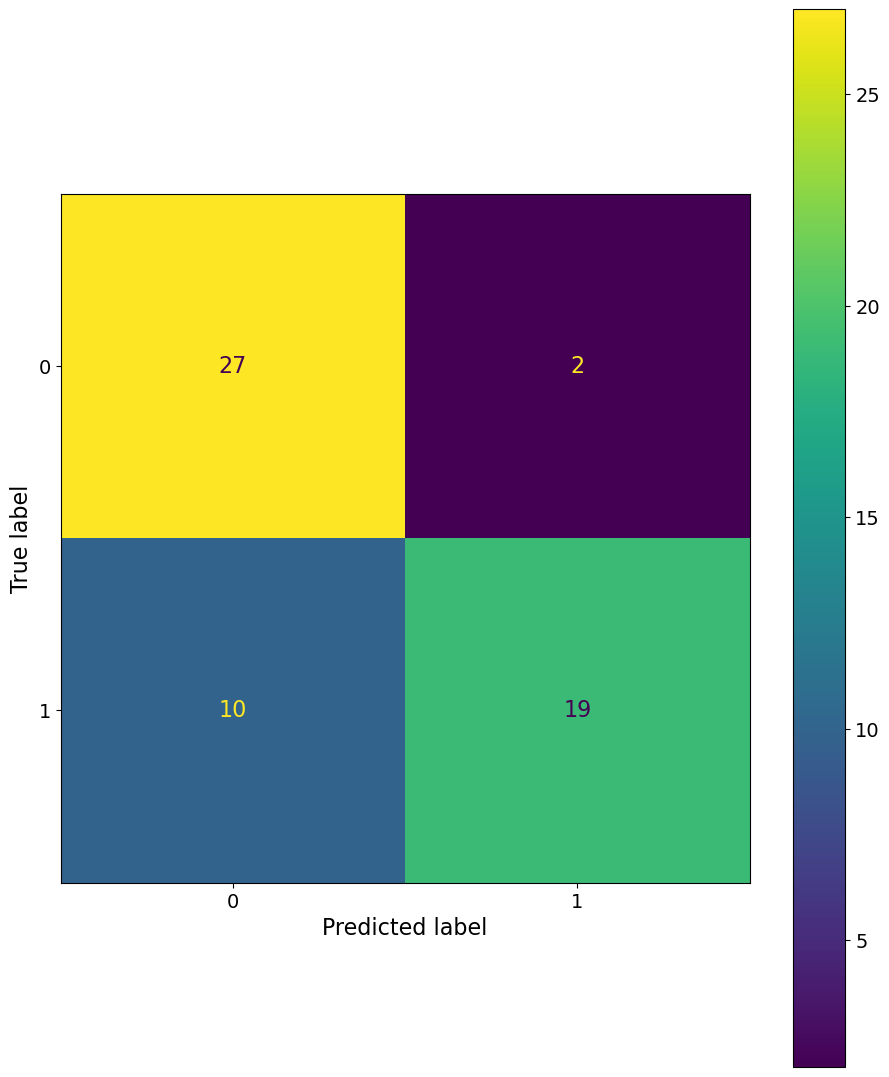

washing machine
rp
MLP
2

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
f1_score: 0.8075414781297134
accuracy: 0.8103448275862069
              precision    recall  f1-score   support

       False       0.75      0.93      0.83        29
        True       0.91      0.69      0.78        29

    accuracy                           0.81        58
   macro avg       0.83      0.81      0.81        58
weighted avg       0.83      0.81      0.81        58



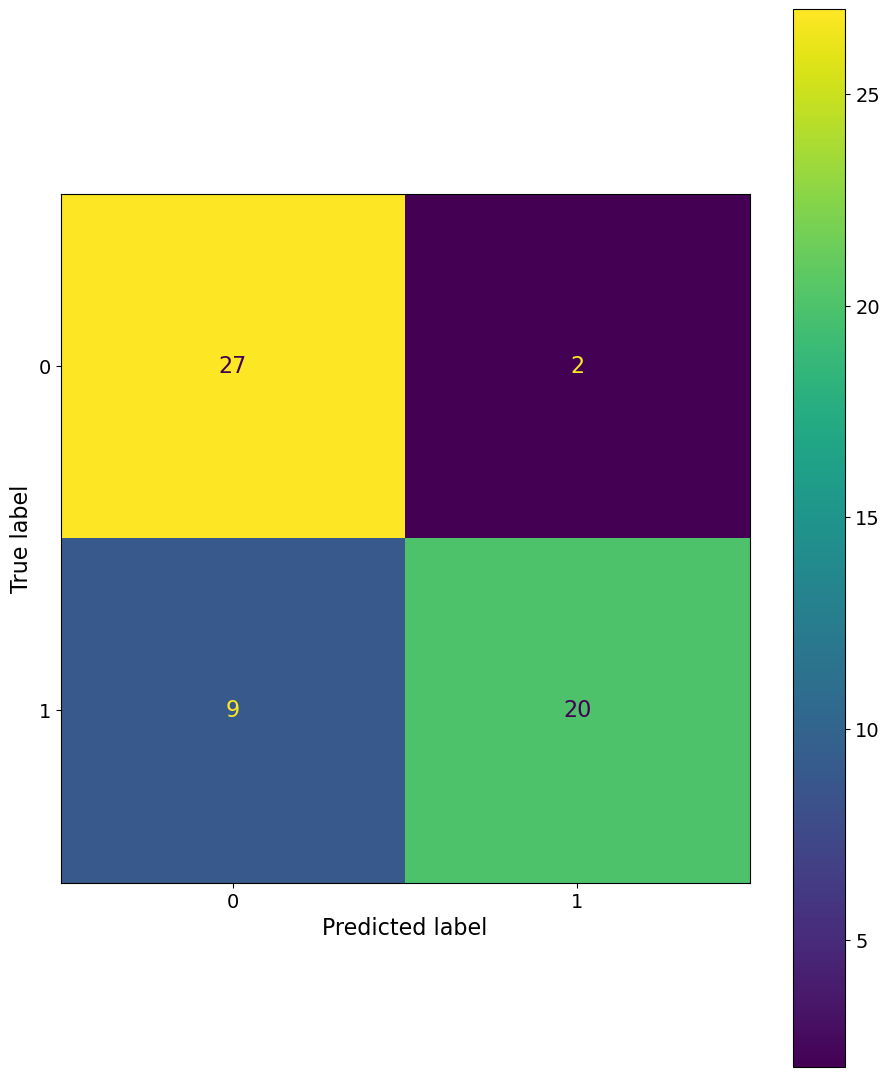

washing machine
rp
MLP
3

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
f1_score: 0.8075414781297134
accuracy: 0.8103448275862069
              precision    recall  f1-score   support

       False       0.75      0.93      0.83        29
        True       0.91      0.69      0.78        29

    accuracy                           0.81        58
   macro avg       0.83      0.81      0.81        58
weighted avg       0.83      0.81      0.81        58



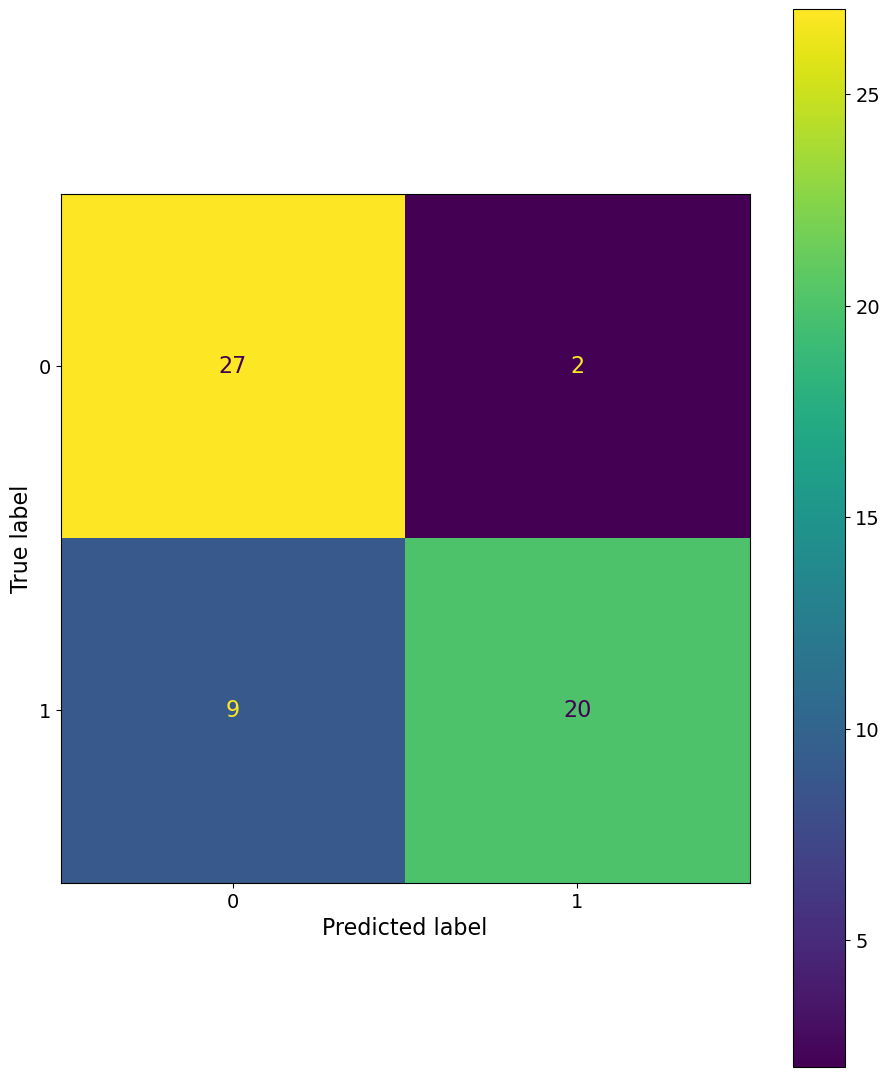

washing machine
rp
MLP
4

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
f1_score: 0.7890909090909091
accuracy: 0.7931034482758621
              precision    recall  f1-score   support

       False       0.73      0.93      0.82        29
        True       0.90      0.66      0.76        29

    accuracy                           0.79        58
   macro avg       0.82      0.79      0.79        58
weighted avg       0.82      0.79      0.79        58



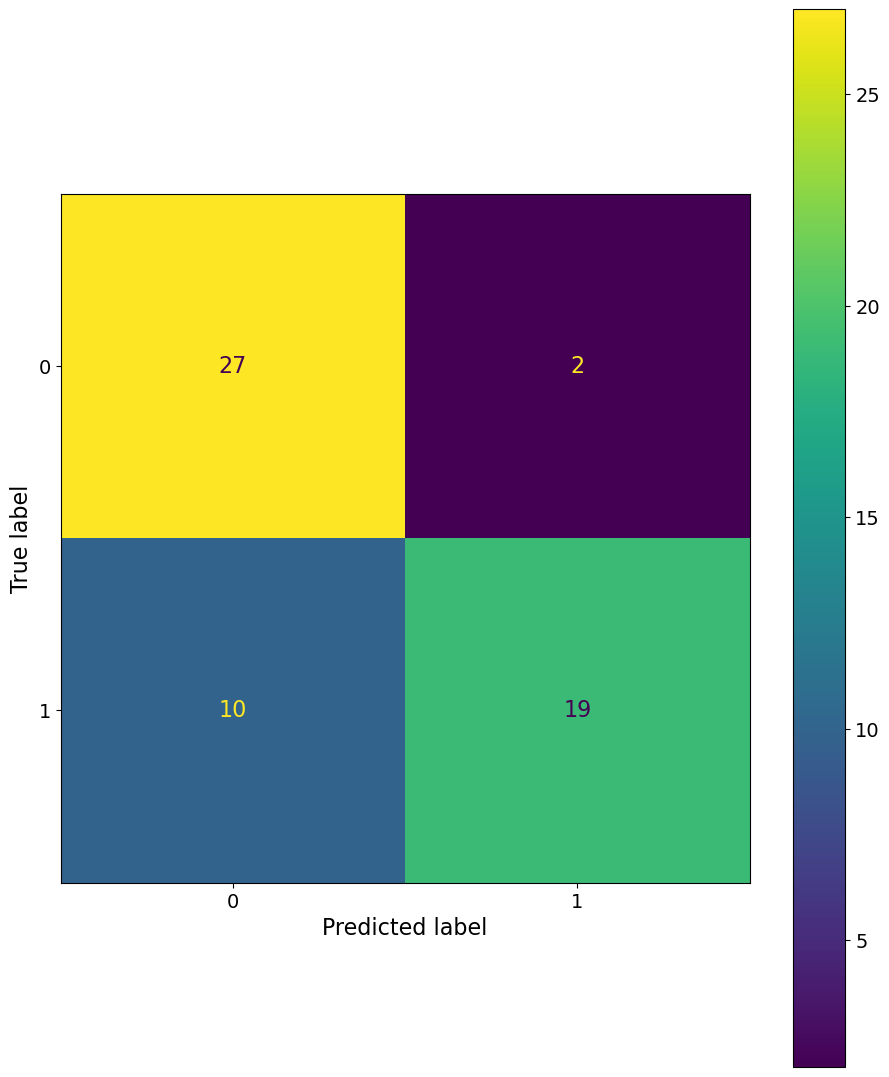

washing machine
rp
XGBoost
0

f1_score: 0.8267622461170848
accuracy: 0.8275862068965517
              precision    recall  f1-score   support

       False       0.79      0.90      0.84        29
        True       0.88      0.76      0.81        29

    accuracy                           0.83        58
   macro avg       0.83      0.83      0.83        58
weighted avg       0.83      0.83      0.83        58



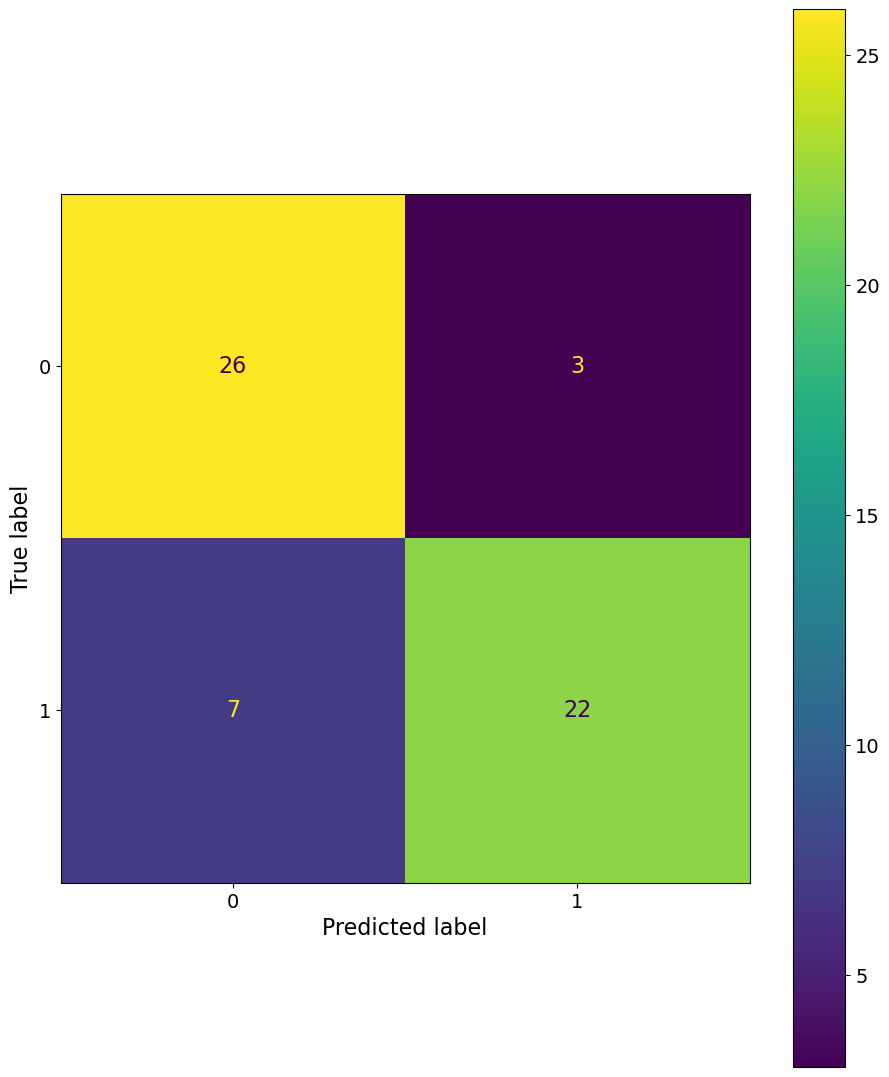

washing machine
rp
SVM
0

f1_score: 0.7703320134023759
accuracy: 0.7758620689655172
              precision    recall  f1-score   support

       False       0.71      0.93      0.81        29
        True       0.90      0.62      0.73        29

    accuracy                           0.78        58
   macro avg       0.81      0.78      0.77        58
weighted avg       0.81      0.78      0.77        58



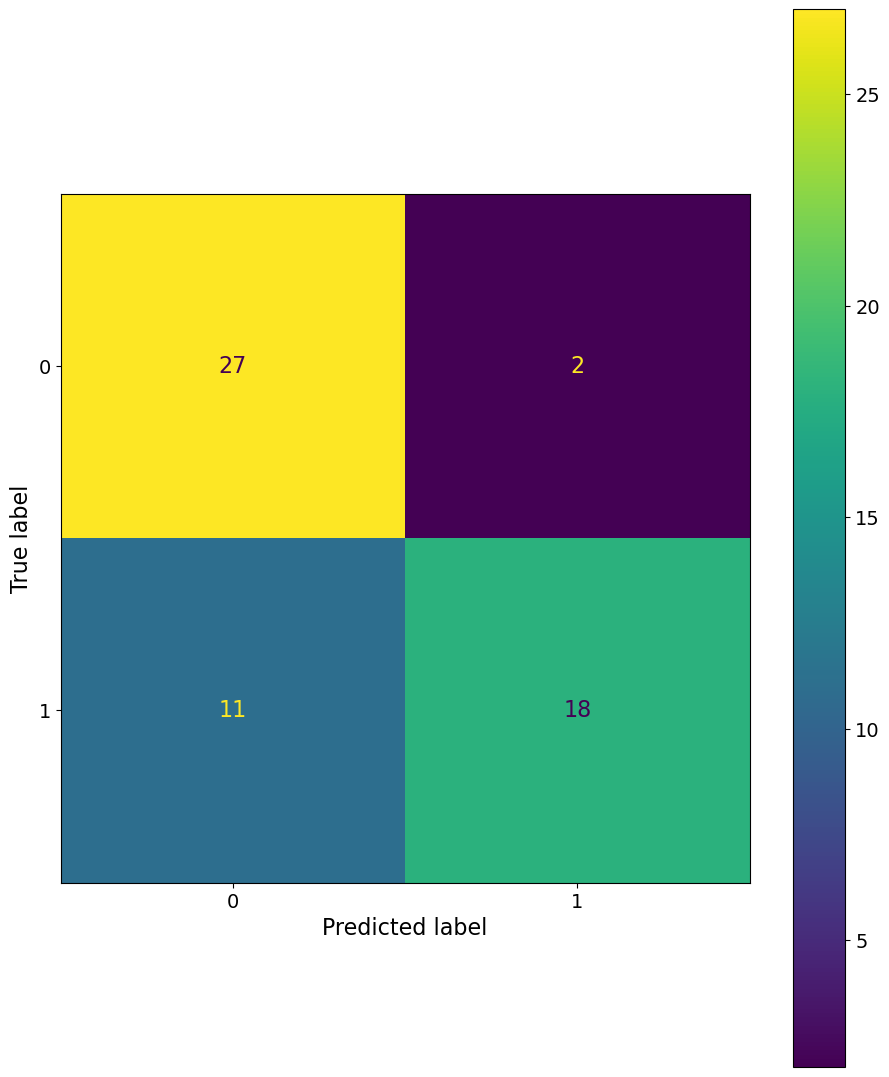

washing machine
tbg
MLP
0

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
f1_score: 0.9135618479880775
accuracy: 0.9137931034482759
              precision    recall  f1-score   support

       False       0.88      0.97      0.92        29
        True       0.96      0.86      0.91        29

    accuracy                           0.91        58
   macro avg       0.92      0.91      0.91        58
weighted avg       0.92      0.91      0.91        58



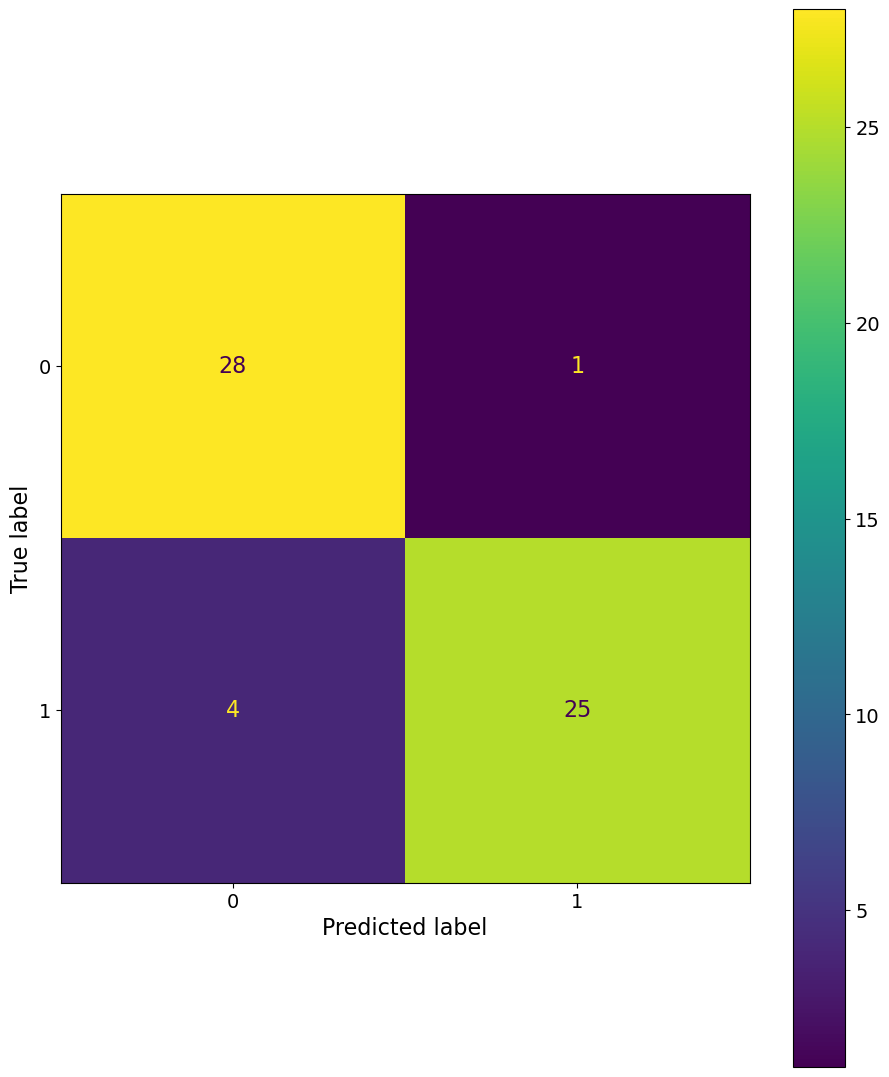

washing machine
tbg
MLP
1

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
f1_score: 0.930952380952381
accuracy: 0.9310344827586207
              precision    recall  f1-score   support

       False       0.90      0.97      0.93        29
        True       0.96      0.90      0.93        29

    accuracy                           0.93        58
   macro avg       0.93      0.93      0.93        58
weighted avg       0.93      0.93      0.93        58



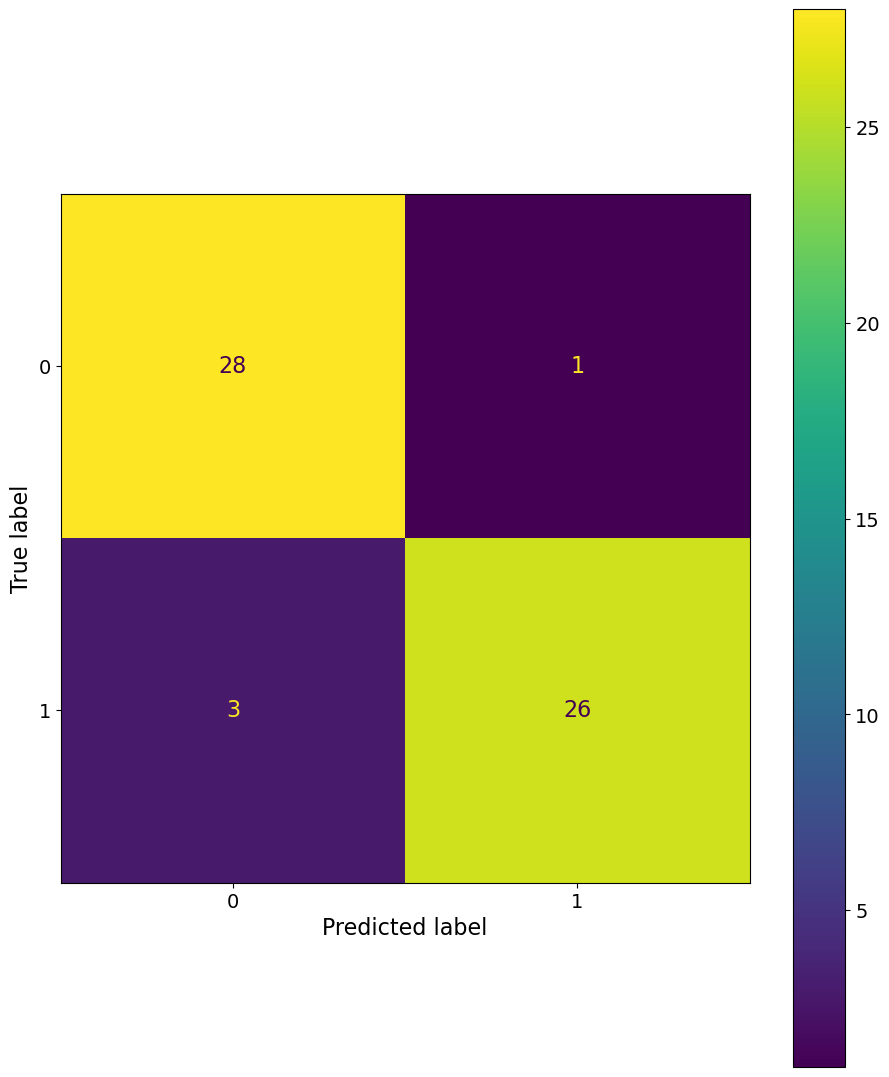

washing machine
tbg
MLP
2

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
f1_score: 0.9135618479880775
accuracy: 0.9137931034482759
              precision    recall  f1-score   support

       False       0.88      0.97      0.92        29
        True       0.96      0.86      0.91        29

    accuracy                           0.91        58
   macro avg       0.92      0.91      0.91        58
weighted avg       0.92      0.91      0.91        58



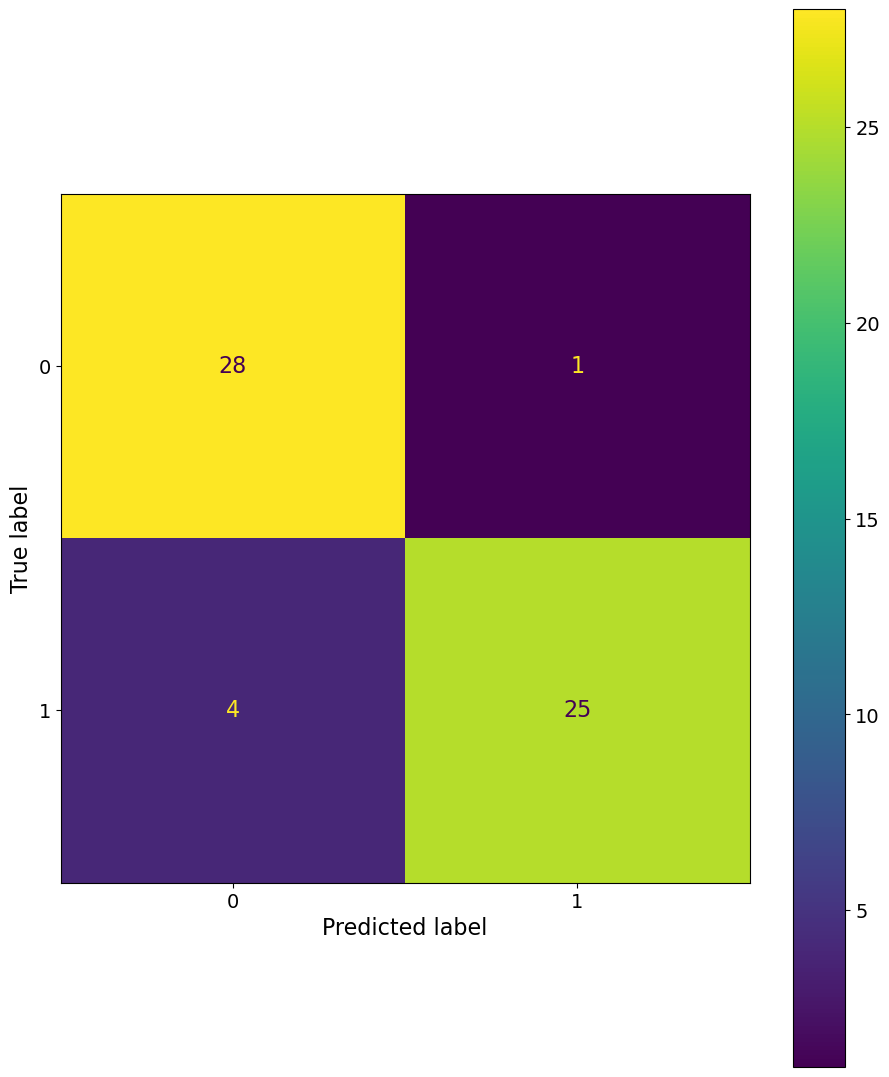

washing machine
tbg
MLP
3

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
f1_score: 0.930952380952381
accuracy: 0.9310344827586207
              precision    recall  f1-score   support

       False       0.90      0.97      0.93        29
        True       0.96      0.90      0.93        29

    accuracy                           0.93        58
   macro avg       0.93      0.93      0.93        58
weighted avg       0.93      0.93      0.93        58



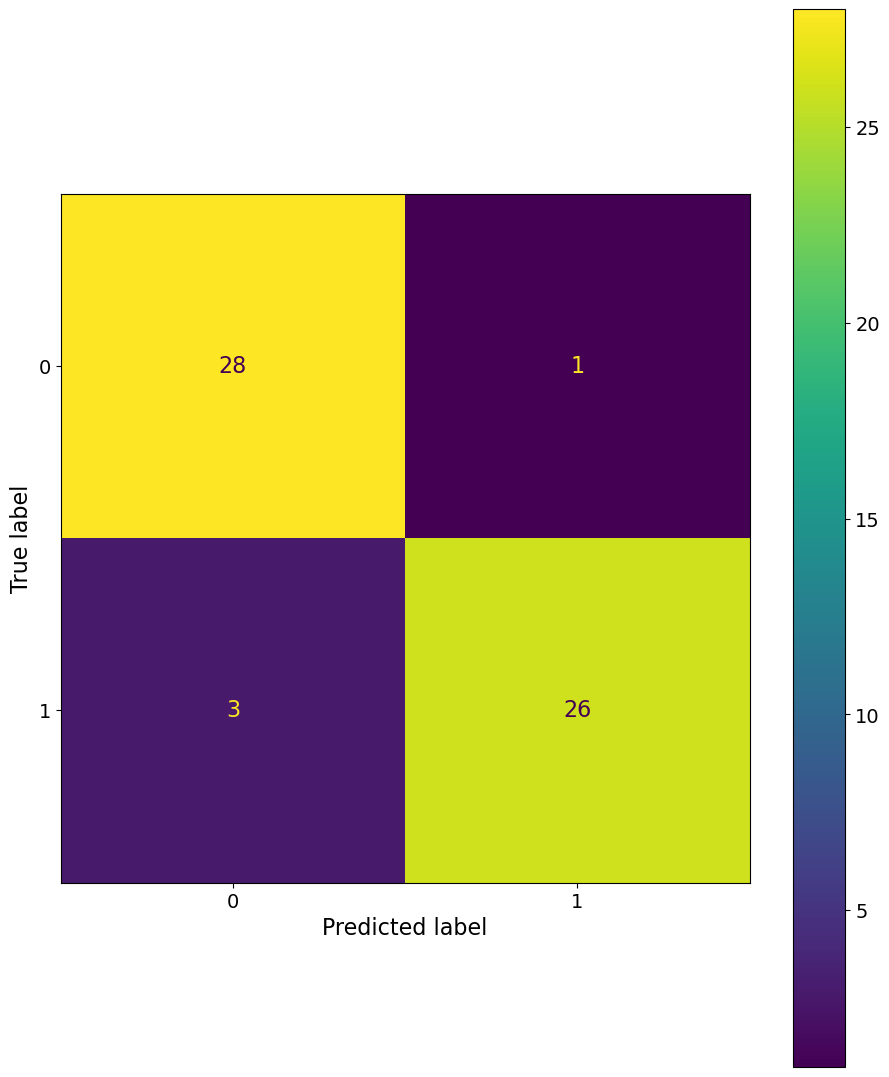

washing machine
tbg
MLP
4

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
f1_score: 0.930952380952381
accuracy: 0.9310344827586207
              precision    recall  f1-score   support

       False       0.90      0.97      0.93        29
        True       0.96      0.90      0.93        29

    accuracy                           0.93        58
   macro avg       0.93      0.93      0.93        58
weighted avg       0.93      0.93      0.93        58



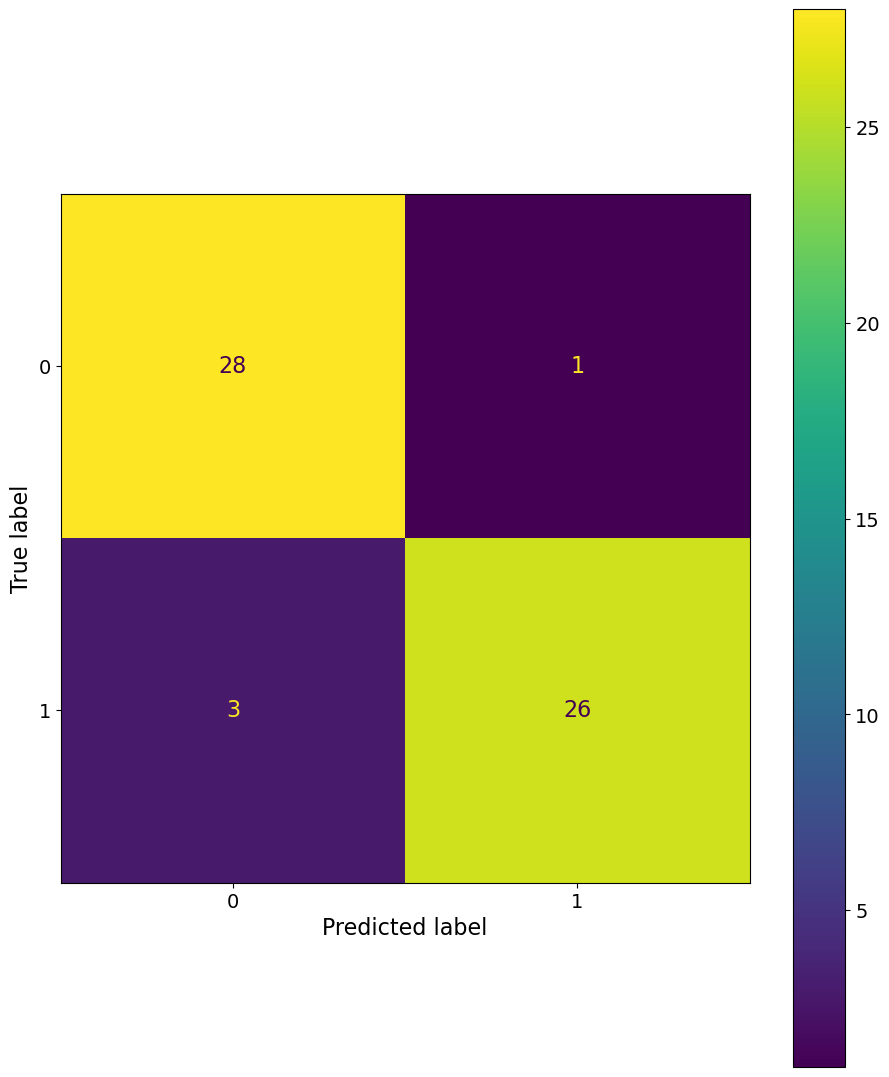

washing machine
tbg
XGBoost
0

f1_score: 0.9655172413793104
accuracy: 0.9655172413793104
              precision    recall  f1-score   support

       False       0.97      0.97      0.97        29
        True       0.97      0.97      0.97        29

    accuracy                           0.97        58
   macro avg       0.97      0.97      0.97        58
weighted avg       0.97      0.97      0.97        58



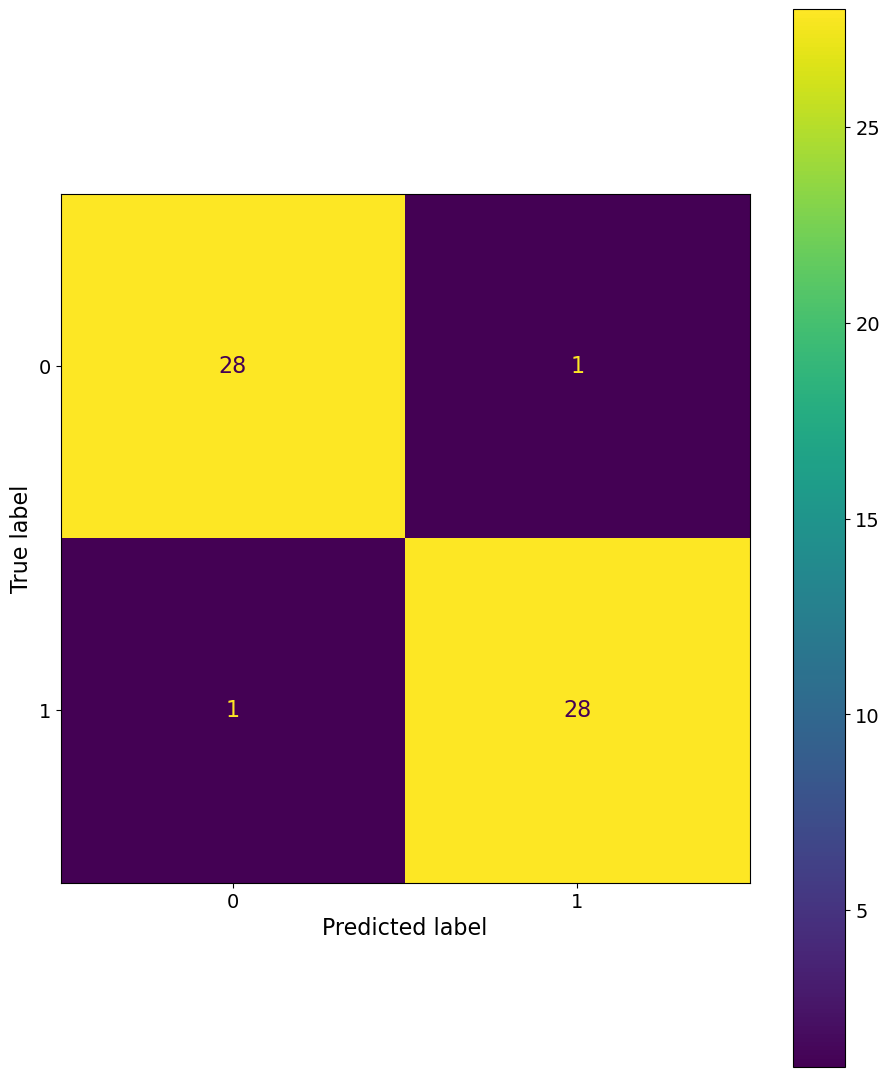

washing machine
tbg
SVM
0

f1_score: 0.8242424242424242
accuracy: 0.8275862068965517
              precision    recall  f1-score   support

       False       0.76      0.97      0.85        29
        True       0.95      0.69      0.80        29

    accuracy                           0.83        58
   macro avg       0.85      0.83      0.82        58
weighted avg       0.85      0.83      0.82        58



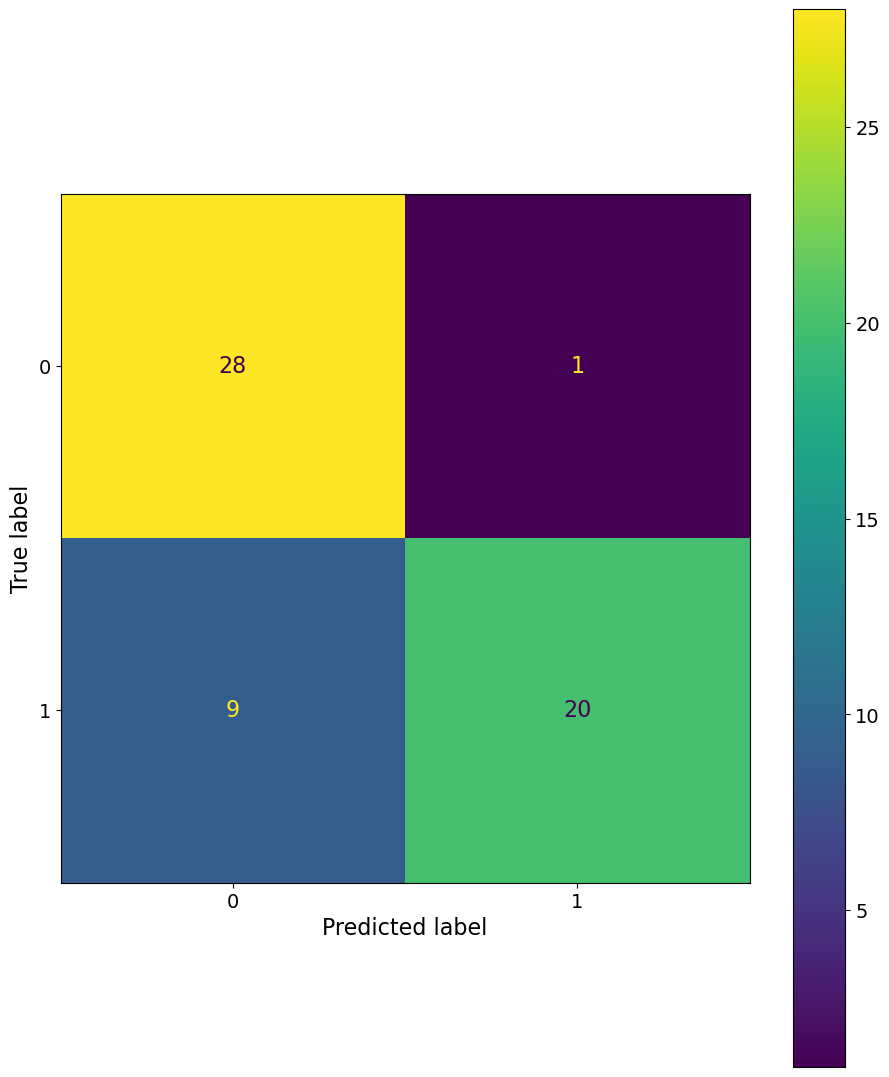

fridge
gasf
MLP
0

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
f1_score: 0.5235460354567302
accuracy: 0.5740037950664136
              precision    recall  f1-score   support

       False       0.71      0.25      0.37       527
        True       0.54      0.90      0.68       527

    accuracy                           0.57      1054
   macro avg       0.63      0.57      0.52      1054
weighted avg       0.63      0.57      0.52      1054



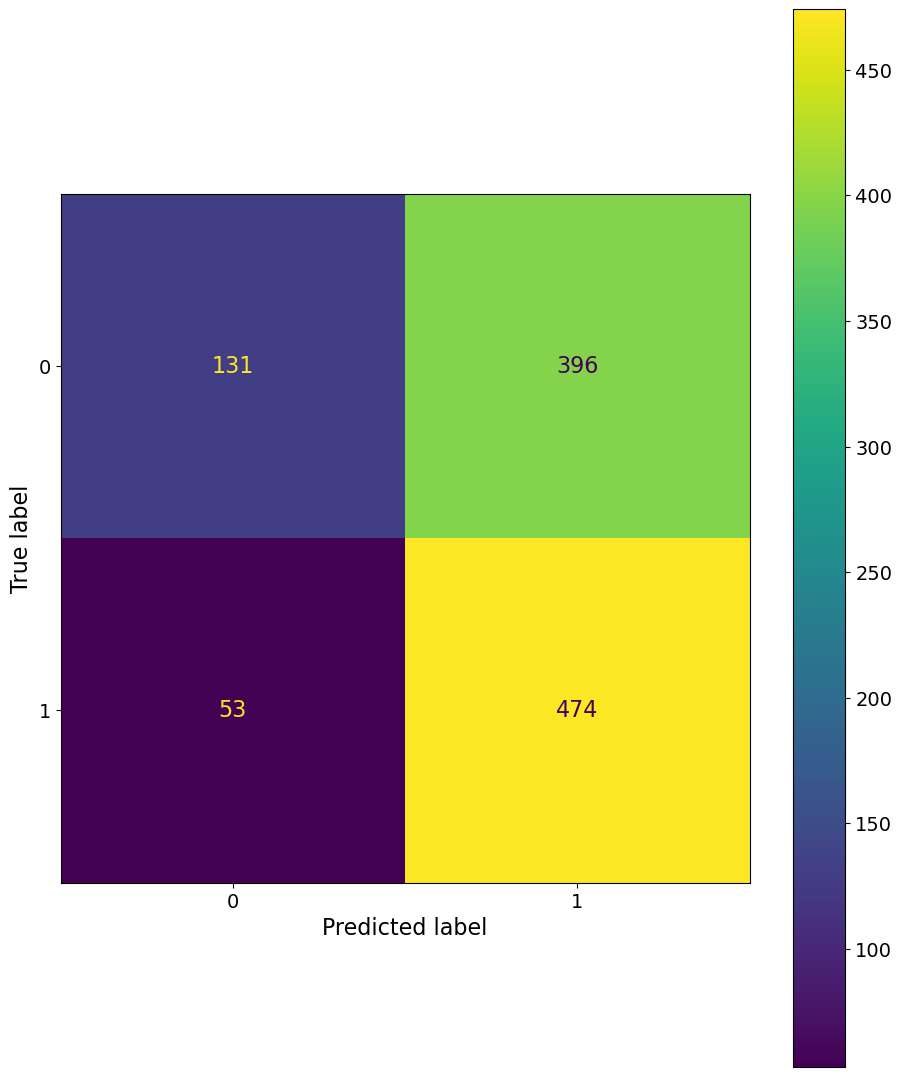

fridge
gasf
MLP
1

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
f1_score: 0.6562872689326178
accuracy: 0.6679316888045541
              precision    recall  f1-score   support

       False       0.77      0.48      0.59       527
        True       0.62      0.85      0.72       527

    accuracy                           0.67      1054
   macro avg       0.69      0.67      0.66      1054
weighted avg       0.69      0.67      0.66      1054



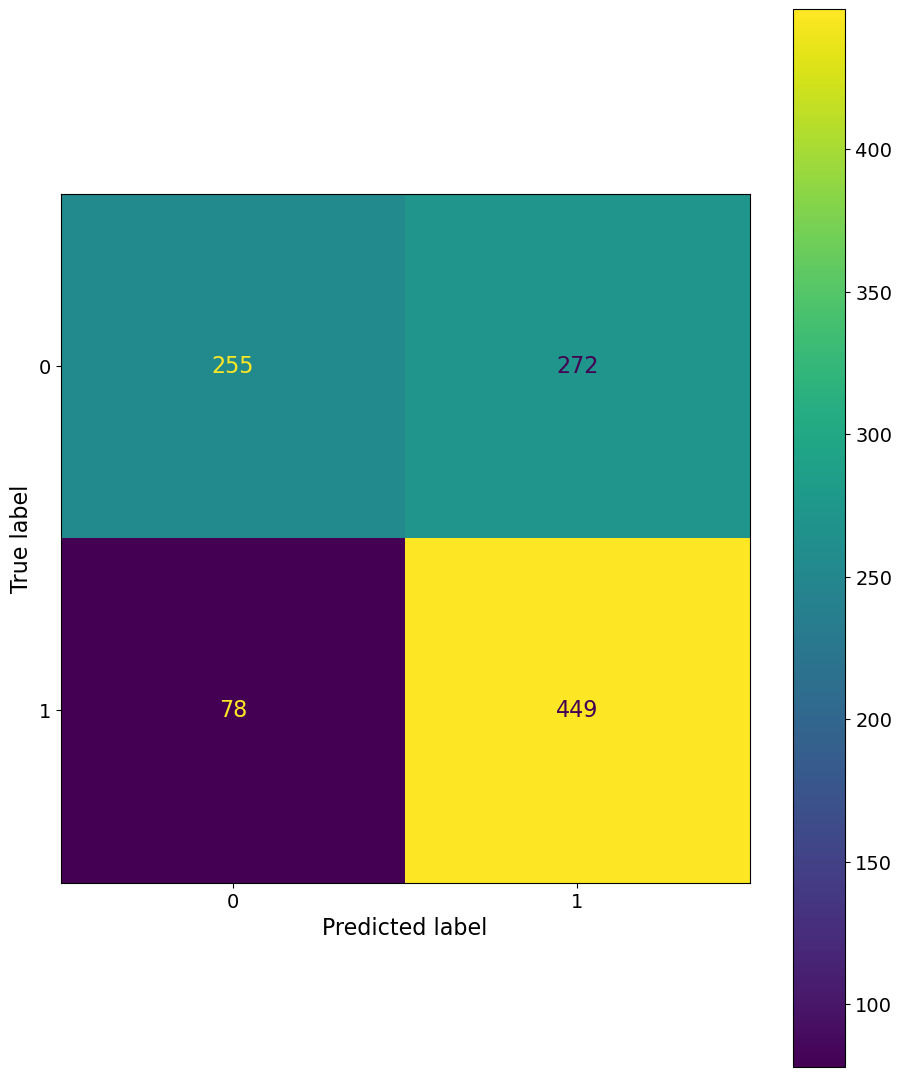

fridge
gasf
MLP
2

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
f1_score: 0.6418925505405408
accuracy: 0.6593927893738141
              precision    recall  f1-score   support

       False       0.79      0.44      0.56       527
        True       0.61      0.88      0.72       527

    accuracy                           0.66      1054
   macro avg       0.70      0.66      0.64      1054
weighted avg       0.70      0.66      0.64      1054



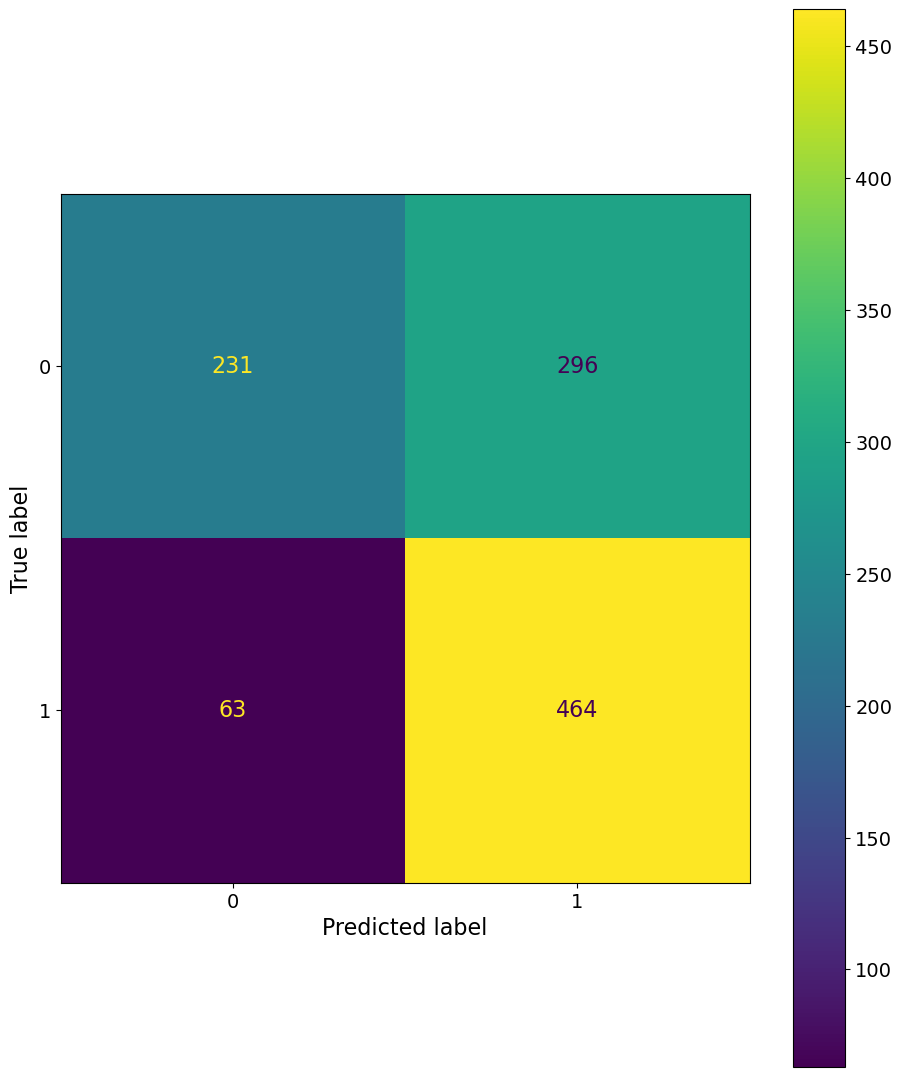

fridge
gasf
MLP
3

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
f1_score: 0.3932314331302582
accuracy: 0.5180265654648957
              precision    recall  f1-score   support

       False       0.51      0.97      0.67       527
        True       0.69      0.06      0.12       527

    accuracy                           0.52      1054
   macro avg       0.60      0.52      0.39      1054
weighted avg       0.60      0.52      0.39      1054



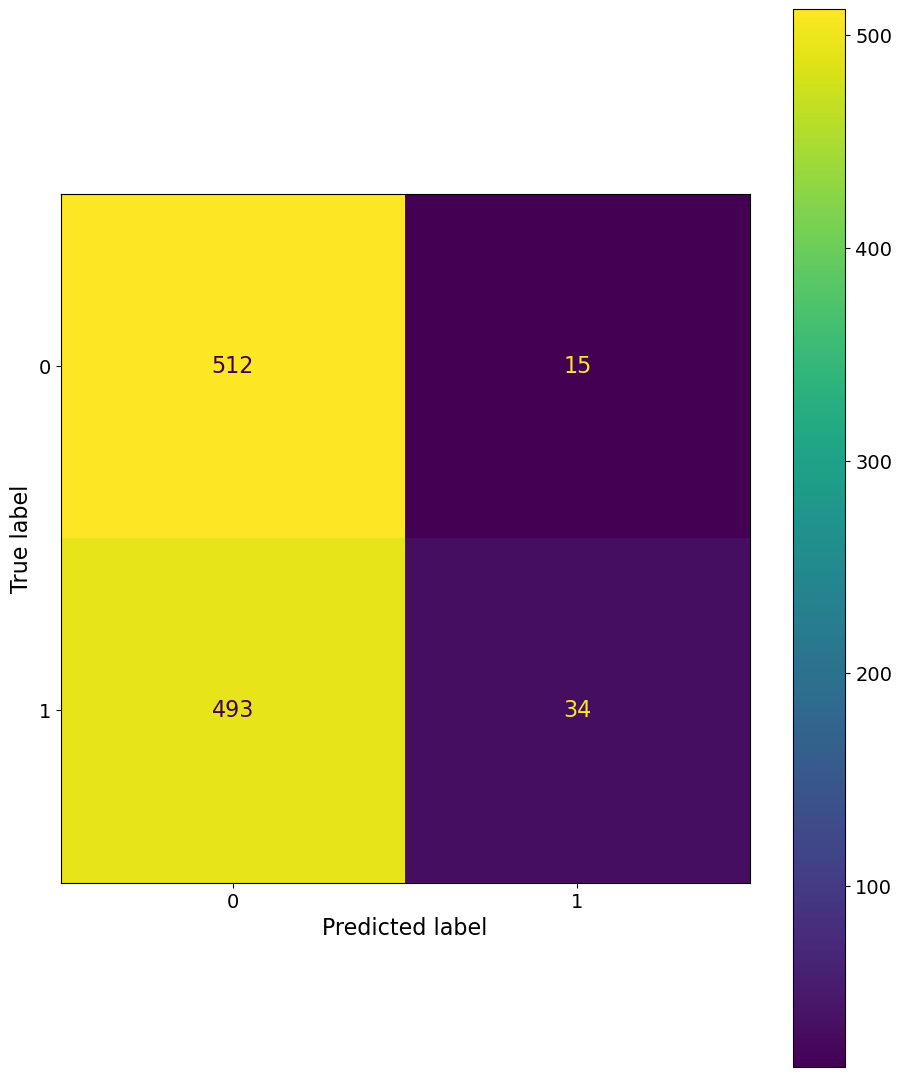

fridge
gasf
MLP
4

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
f1_score: 0.5474385549304116
accuracy: 0.5597722960151803
              precision    recall  f1-score   support

       False       0.59      0.39      0.47       527
        True       0.54      0.72      0.62       527

    accuracy                           0.56      1054
   macro avg       0.57      0.56      0.55      1054
weighted avg       0.57      0.56      0.55      1054



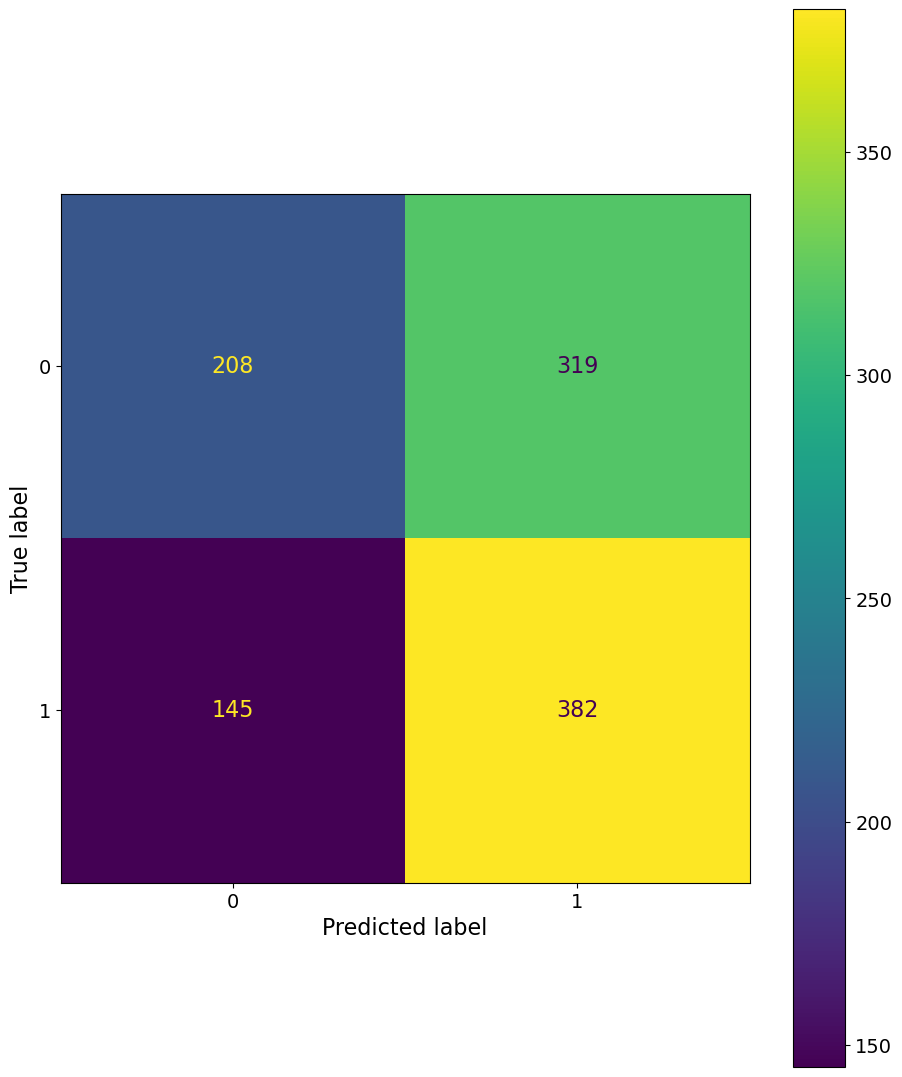

fridge
gasf
XGBoost
0

f1_score: 0.7059096019179456
accuracy: 0.706831119544592
              precision    recall  f1-score   support

       False       0.73      0.65      0.69       527
        True       0.69      0.76      0.72       527

    accuracy                           0.71      1054
   macro avg       0.71      0.71      0.71      1054
weighted avg       0.71      0.71      0.71      1054



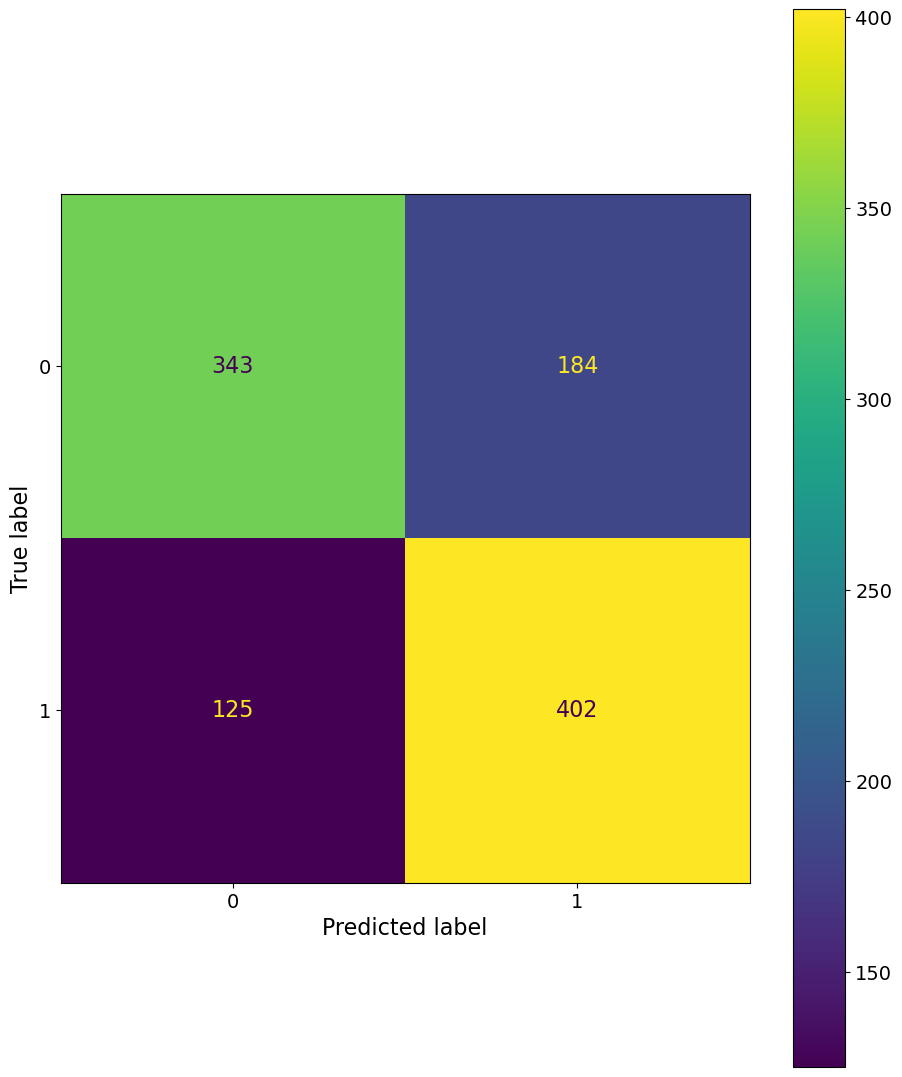

fridge
gasf
SVM
0

f1_score: 0.38858667405841796
accuracy: 0.5075901328273245
              precision    recall  f1-score   support

       False       0.50      0.95      0.66       527
        True       0.56      0.07      0.12       527

    accuracy                           0.51      1054
   macro avg       0.53      0.51      0.39      1054
weighted avg       0.53      0.51      0.39      1054



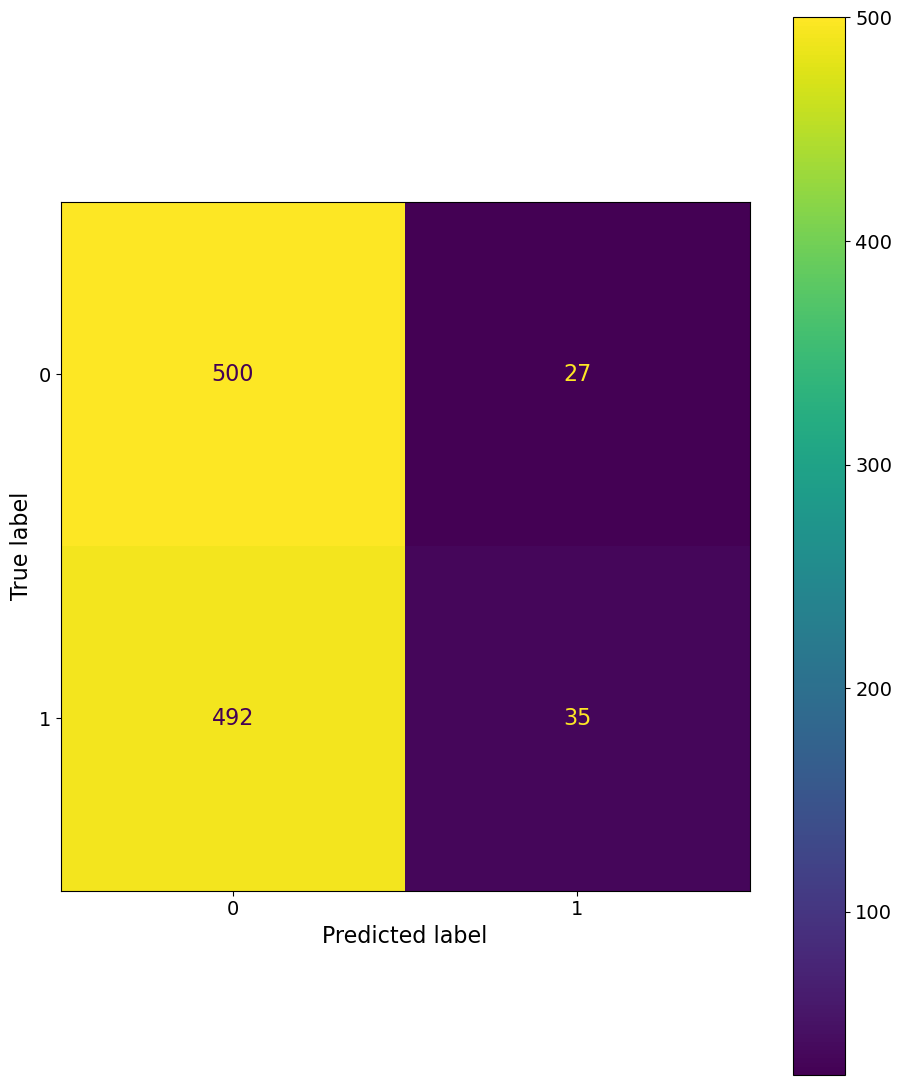

fridge
gadf
MLP
0

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
f1_score: 0.39503009039243975
accuracy: 0.5284629981024668
              precision    recall  f1-score   support

       False       0.97      0.06      0.11       527
        True       0.51      1.00      0.68       527

    accuracy                           0.53      1054
   macro avg       0.74      0.53      0.40      1054
weighted avg       0.74      0.53      0.40      1054



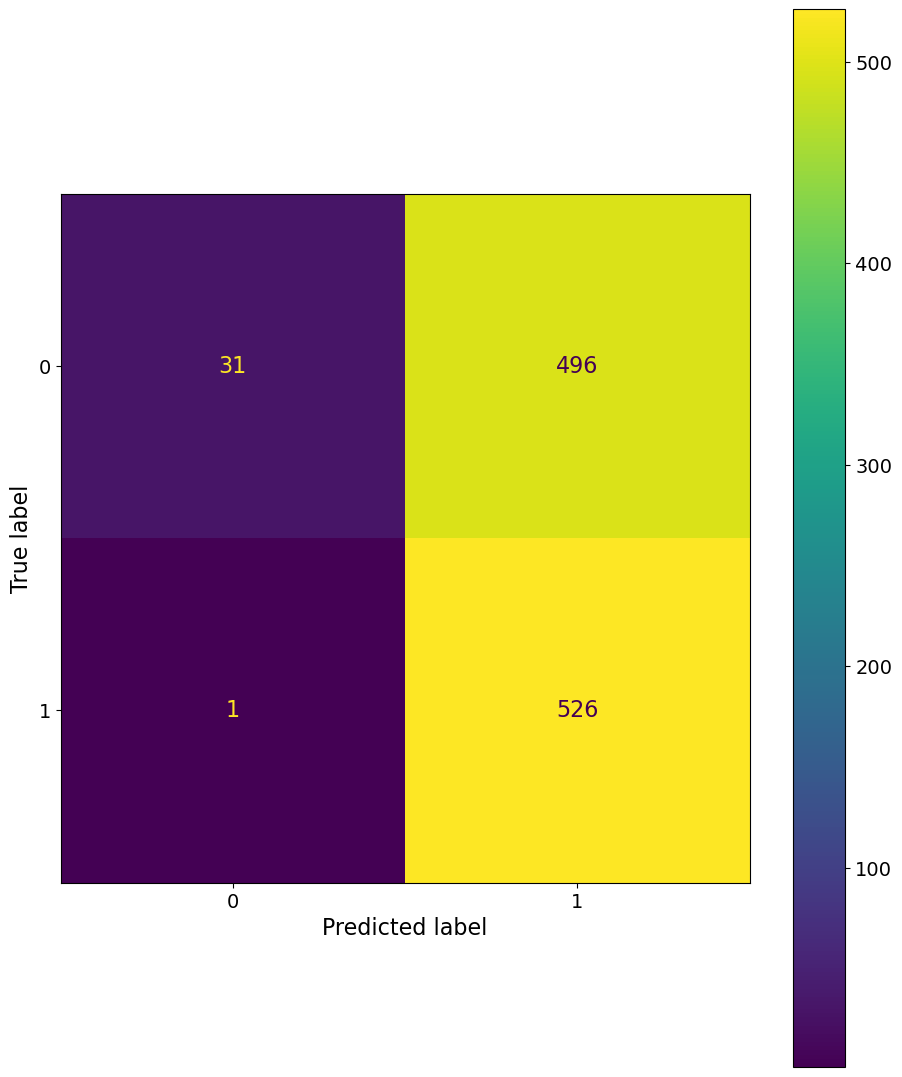

fridge
gadf
MLP
1

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
f1_score: 0.5405478314034621
accuracy: 0.5569259962049335
              precision    recall  f1-score   support

       False       0.59      0.37      0.45       527
        True       0.54      0.75      0.63       527

    accuracy                           0.56      1054
   macro avg       0.57      0.56      0.54      1054
weighted avg       0.57      0.56      0.54      1054



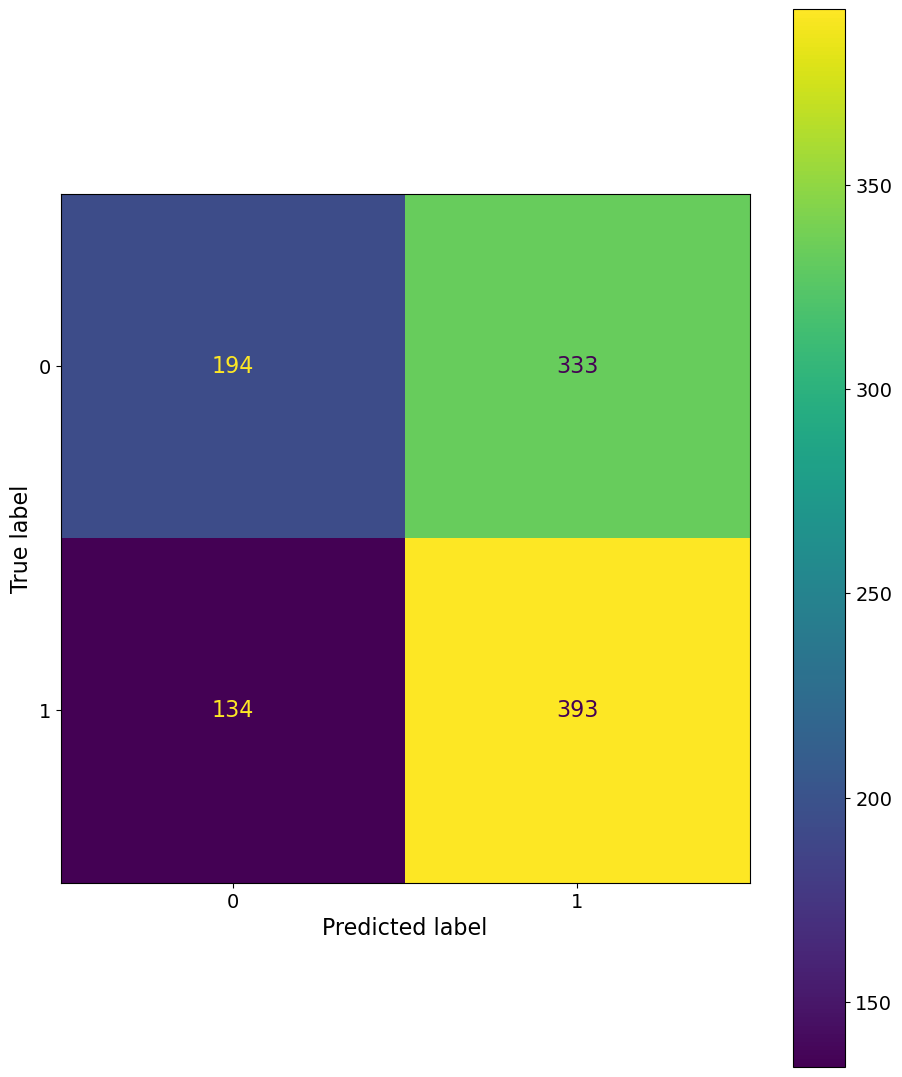

fridge
gadf
MLP
2

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
f1_score: 0.5513828017975666
accuracy: 0.6005692599620494
              precision    recall  f1-score   support

       False       0.80      0.27      0.40       527
        True       0.56      0.93      0.70       527

    accuracy                           0.60      1054
   macro avg       0.68      0.60      0.55      1054
weighted avg       0.68      0.60      0.55      1054



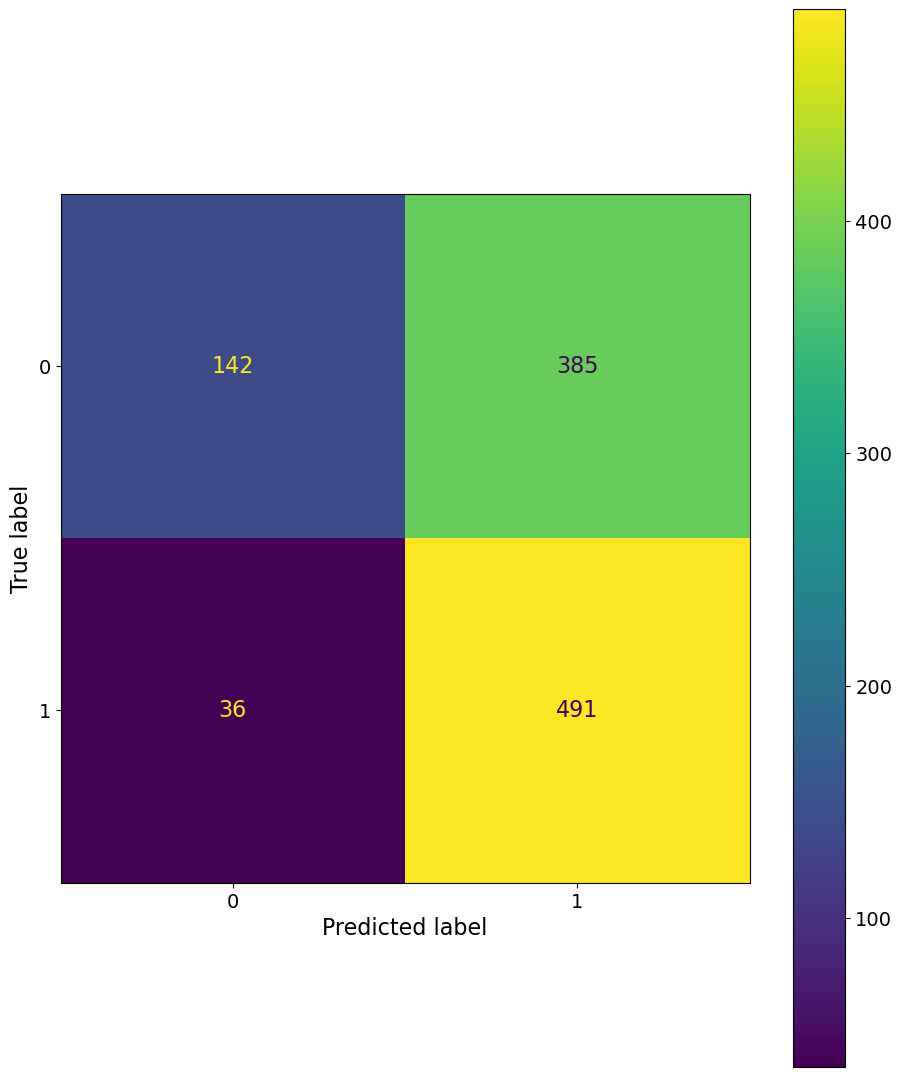

fridge
gadf
MLP
3

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
f1_score: 0.6885847809089369
accuracy: 0.6888045540796964
              precision    recall  f1-score   support

       False       0.68      0.72      0.70       527
        True       0.70      0.66      0.68       527

    accuracy                           0.69      1054
   macro avg       0.69      0.69      0.69      1054
weighted avg       0.69      0.69      0.69      1054



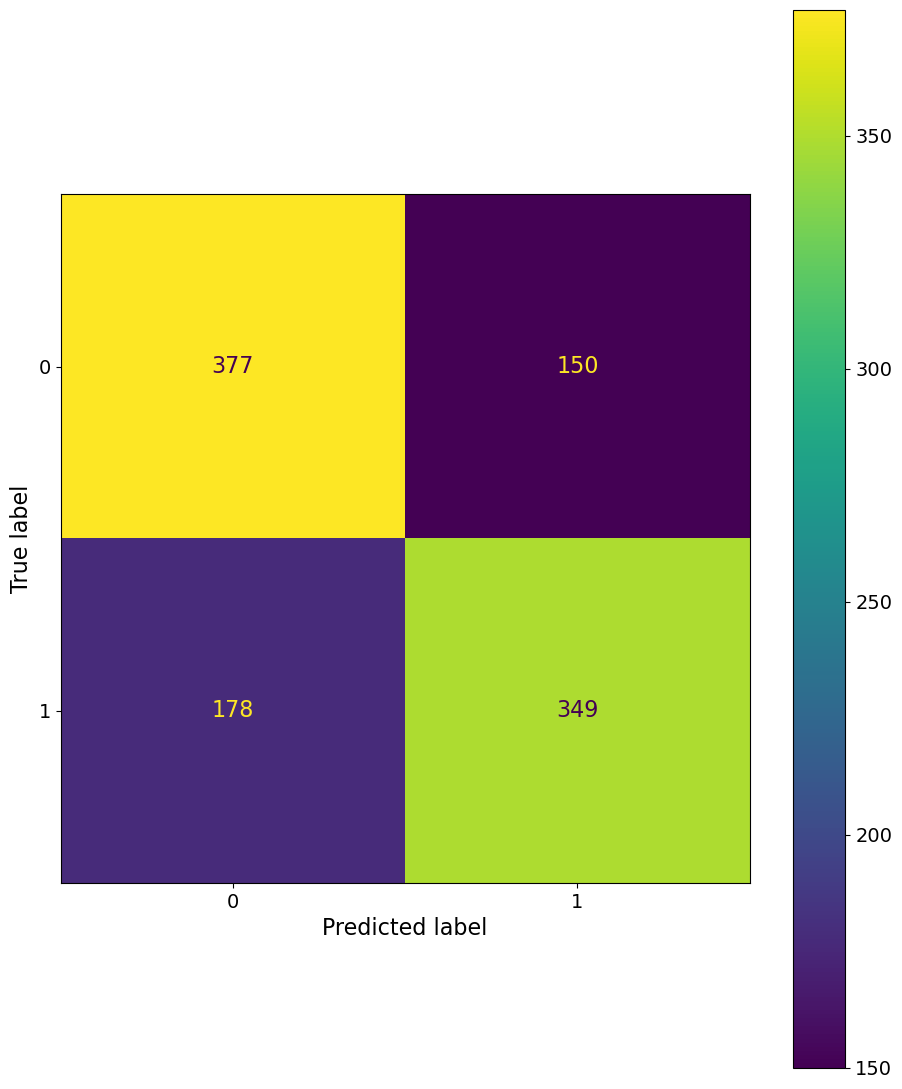

fridge
gadf
MLP
4

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
f1_score: 0.582445453097627
accuracy: 0.6223908918406073
              precision    recall  f1-score   support

       False       0.82      0.31      0.45       527
        True       0.58      0.93      0.71       527

    accuracy                           0.62      1054
   macro avg       0.70      0.62      0.58      1054
weighted avg       0.70      0.62      0.58      1054



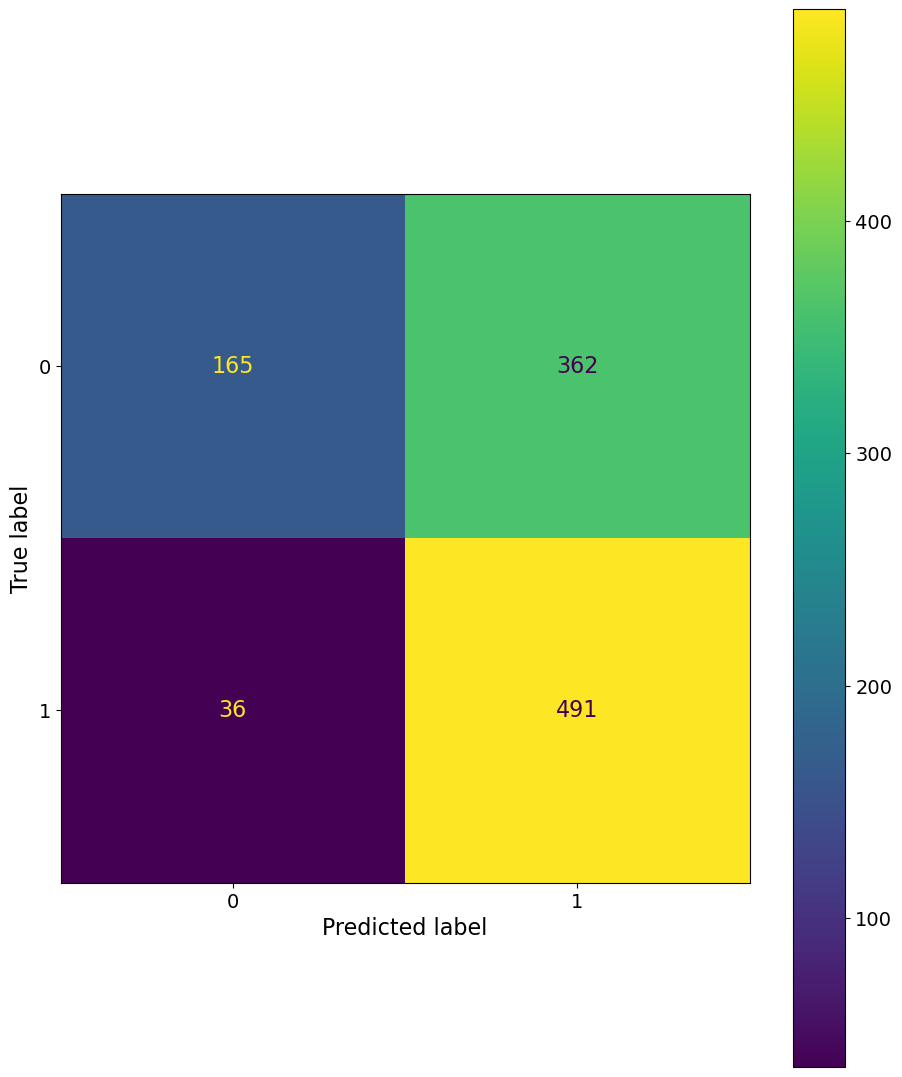

fridge
gadf
XGBoost
0

f1_score: 0.7493369503786594
accuracy: 0.7504743833017078
              precision    recall  f1-score   support

       False       0.79      0.68      0.73       527
        True       0.72      0.82      0.77       527

    accuracy                           0.75      1054
   macro avg       0.76      0.75      0.75      1054
weighted avg       0.76      0.75      0.75      1054



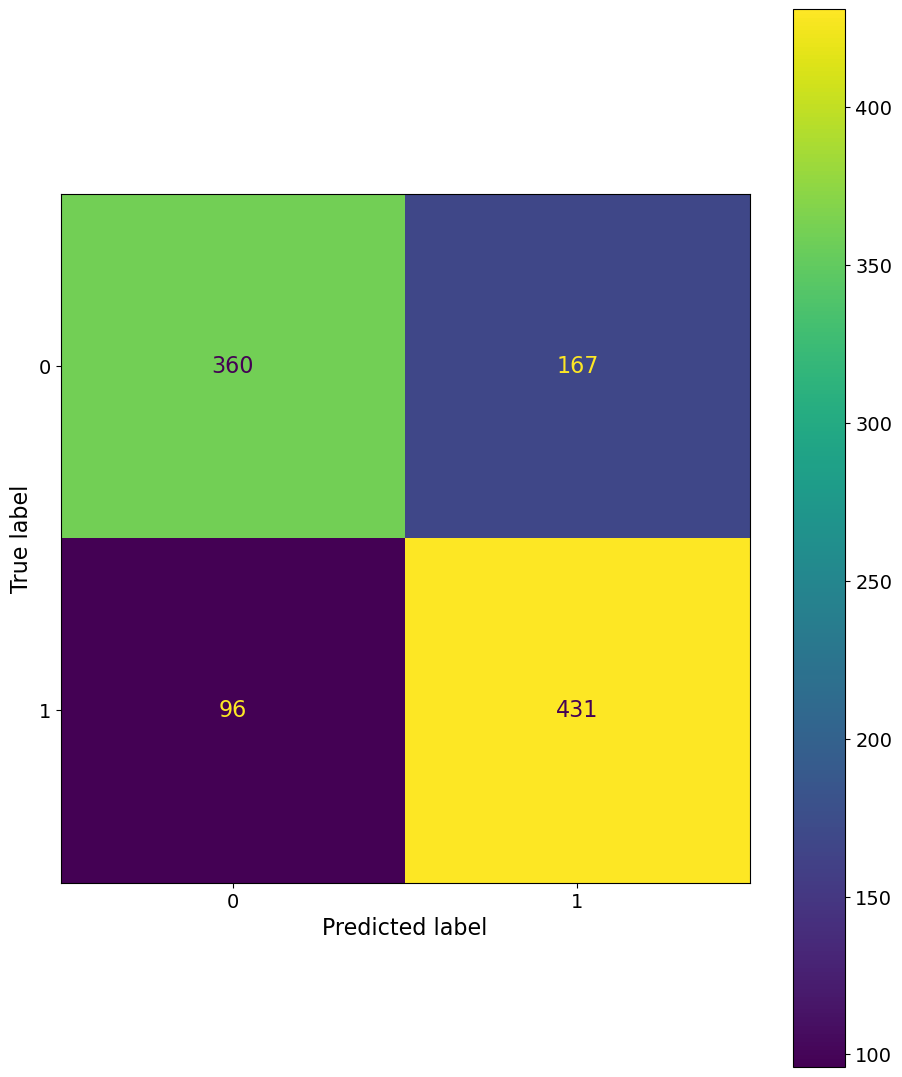

fridge
gadf
SVM
0

f1_score: 0.37170746246414066
accuracy: 0.5142314990512334
              precision    recall  f1-score   support

       False       0.51      0.99      0.67       527
        True       0.80      0.04      0.07       527

    accuracy                           0.51      1054
   macro avg       0.65      0.51      0.37      1054
weighted avg       0.65      0.51      0.37      1054



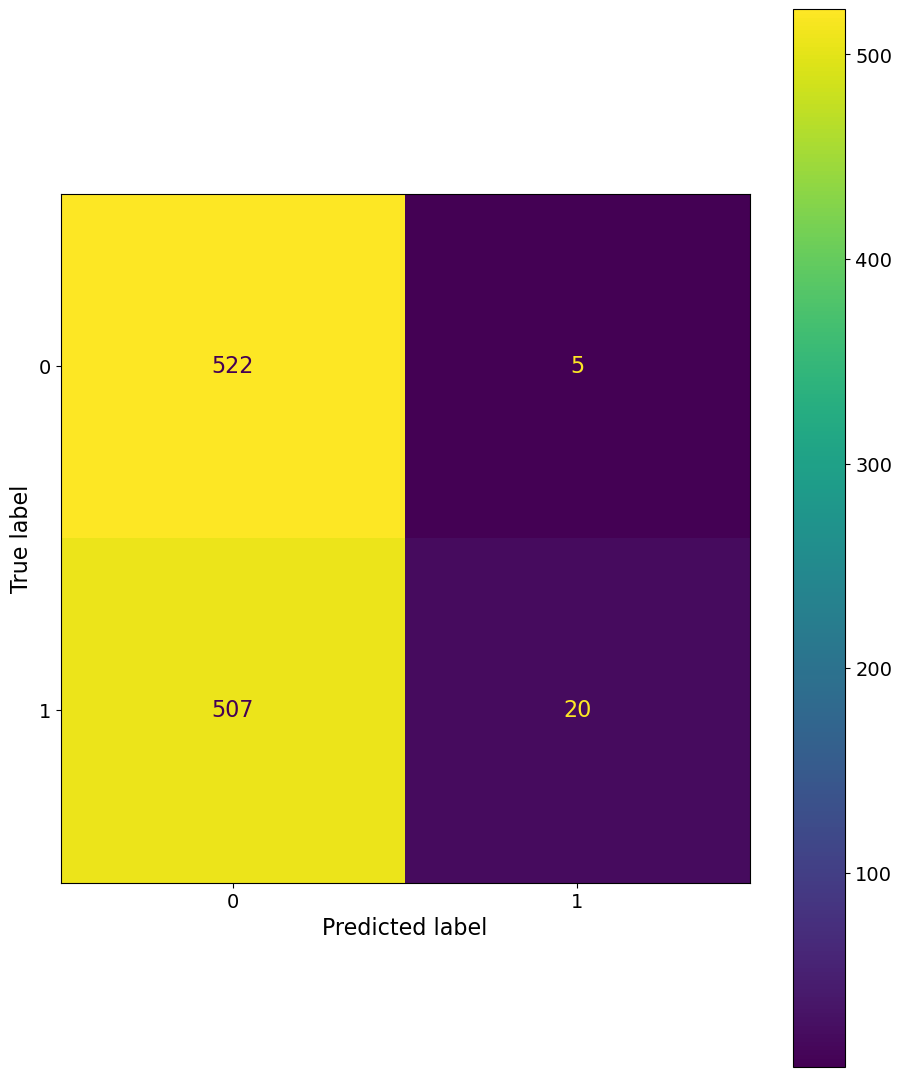

fridge
mtf
MLP
0

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
f1_score: 0.5957541054451168
accuracy: 0.5958254269449715
              precision    recall  f1-score   support

       False       0.60      0.58      0.59       527
        True       0.59      0.61      0.60       527

    accuracy                           0.60      1054
   macro avg       0.60      0.60      0.60      1054
weighted avg       0.60      0.60      0.60      1054



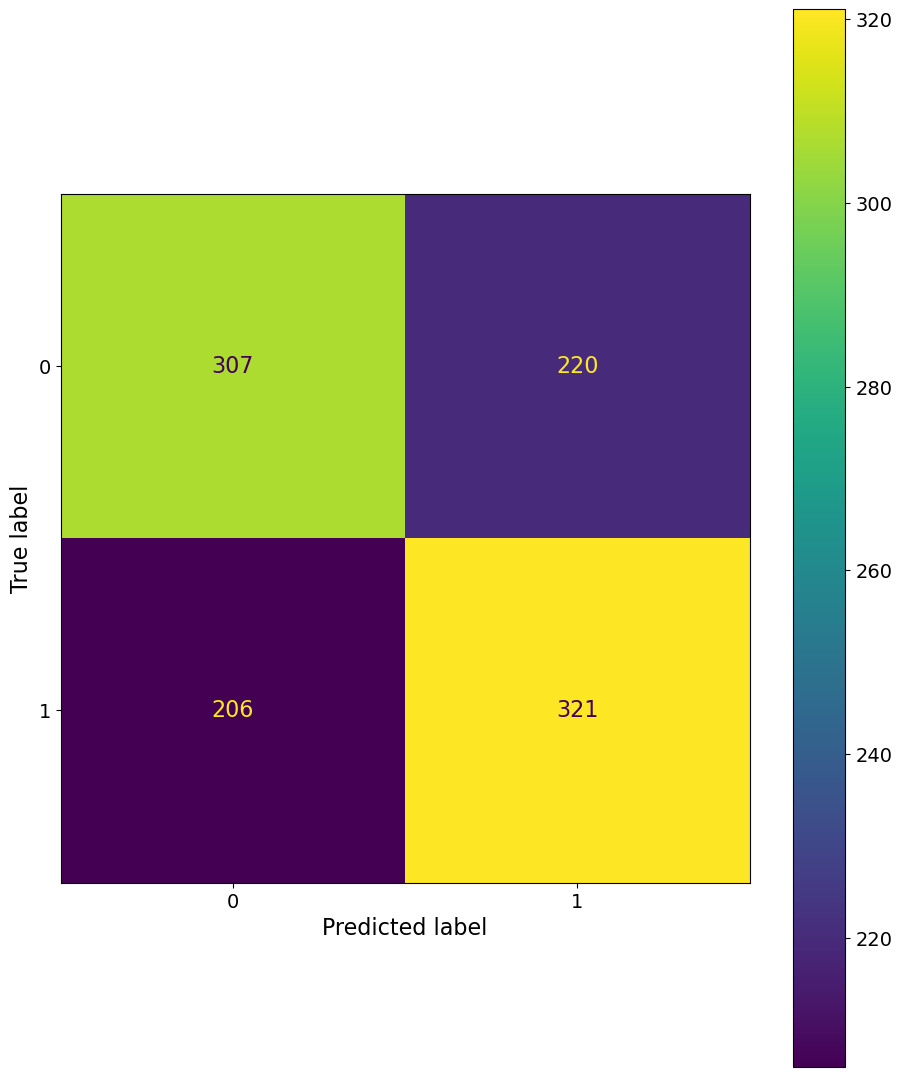

fridge
mtf
MLP
1

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
f1_score: 0.6213347012688876
accuracy: 0.6252371916508539
              precision    recall  f1-score   support

       False       0.66      0.52      0.58       527
        True       0.60      0.73      0.66       527

    accuracy                           0.63      1054
   macro avg       0.63      0.63      0.62      1054
weighted avg       0.63      0.63      0.62      1054



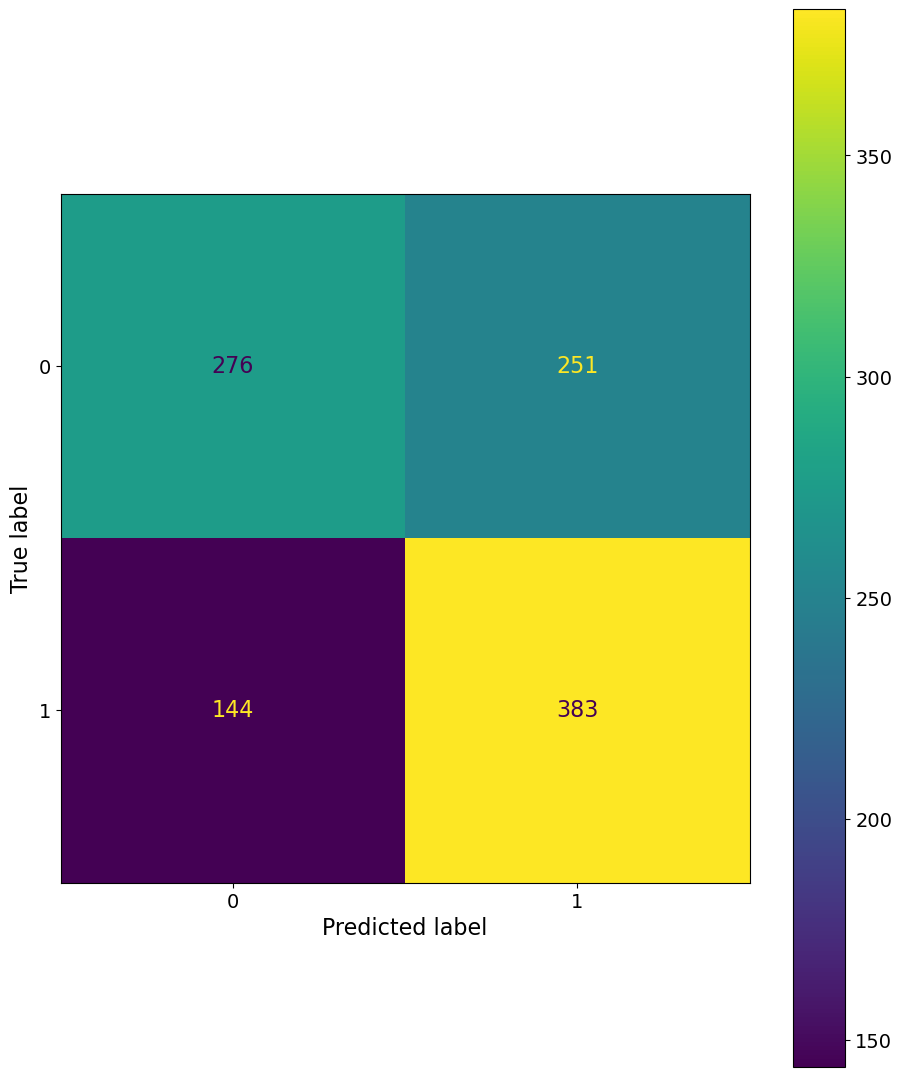

fridge
mtf
MLP
2

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
f1_score: 0.6019479228781555
accuracy: 0.603415559772296
              precision    recall  f1-score   support

       False       0.62      0.54      0.58       527
        True       0.59      0.66      0.63       527

    accuracy                           0.60      1054
   macro avg       0.60      0.60      0.60      1054
weighted avg       0.60      0.60      0.60      1054



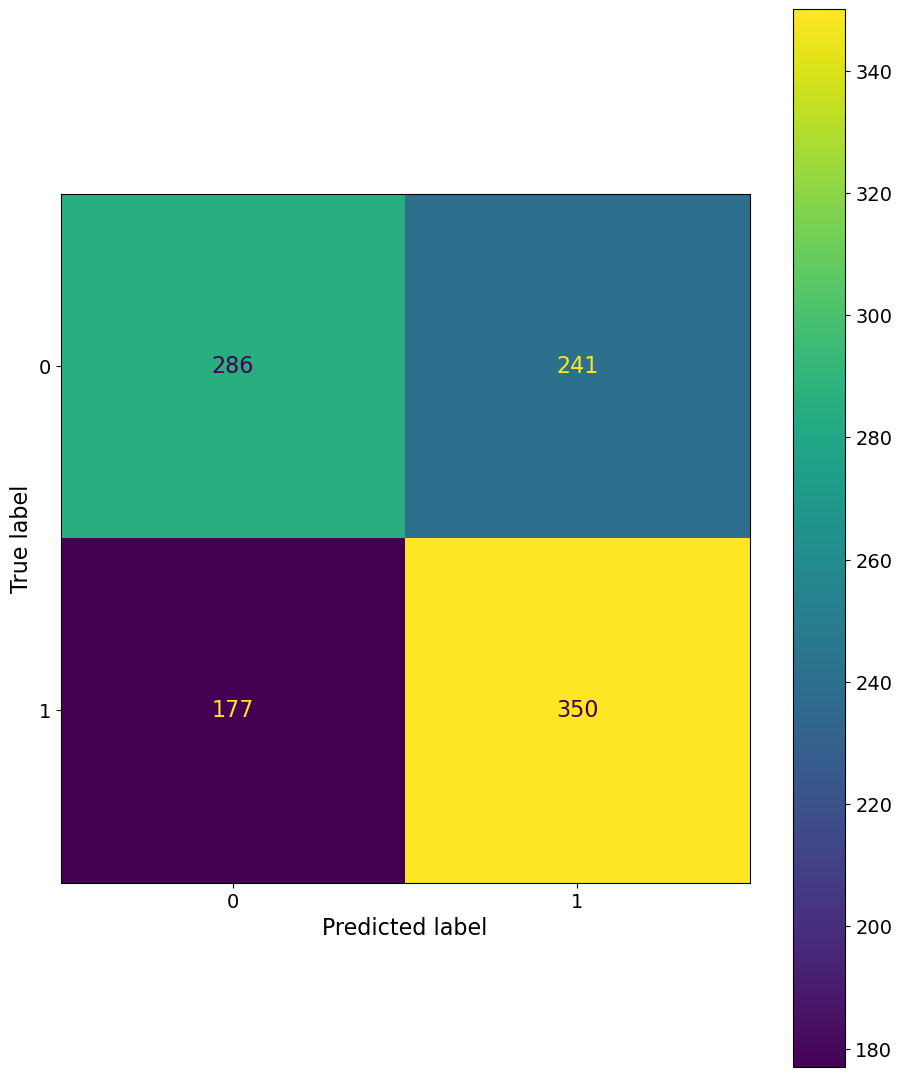

fridge
mtf
MLP
3

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
f1_score: 0.5877578957661094
accuracy: 0.5901328273244781
              precision    recall  f1-score   support

       False       0.61      0.51      0.56       527
        True       0.58      0.67      0.62       527

    accuracy                           0.59      1054
   macro avg       0.59      0.59      0.59      1054
weighted avg       0.59      0.59      0.59      1054



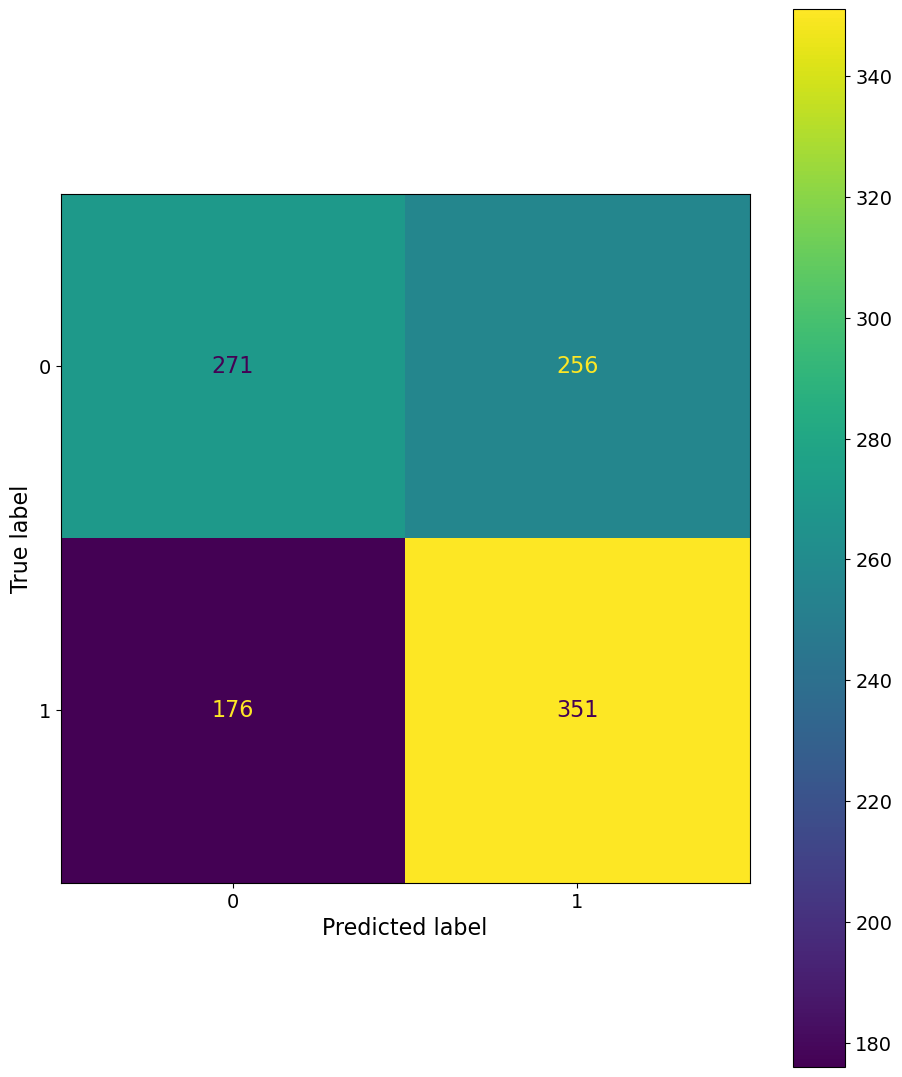

fridge
mtf
MLP
4

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
f1_score: 0.6245768556945368
accuracy: 0.627134724857685
              precision    recall  f1-score   support

       False       0.65      0.54      0.59       527
        True       0.61      0.71      0.66       527

    accuracy                           0.63      1054
   macro avg       0.63      0.63      0.62      1054
weighted avg       0.63      0.63      0.62      1054



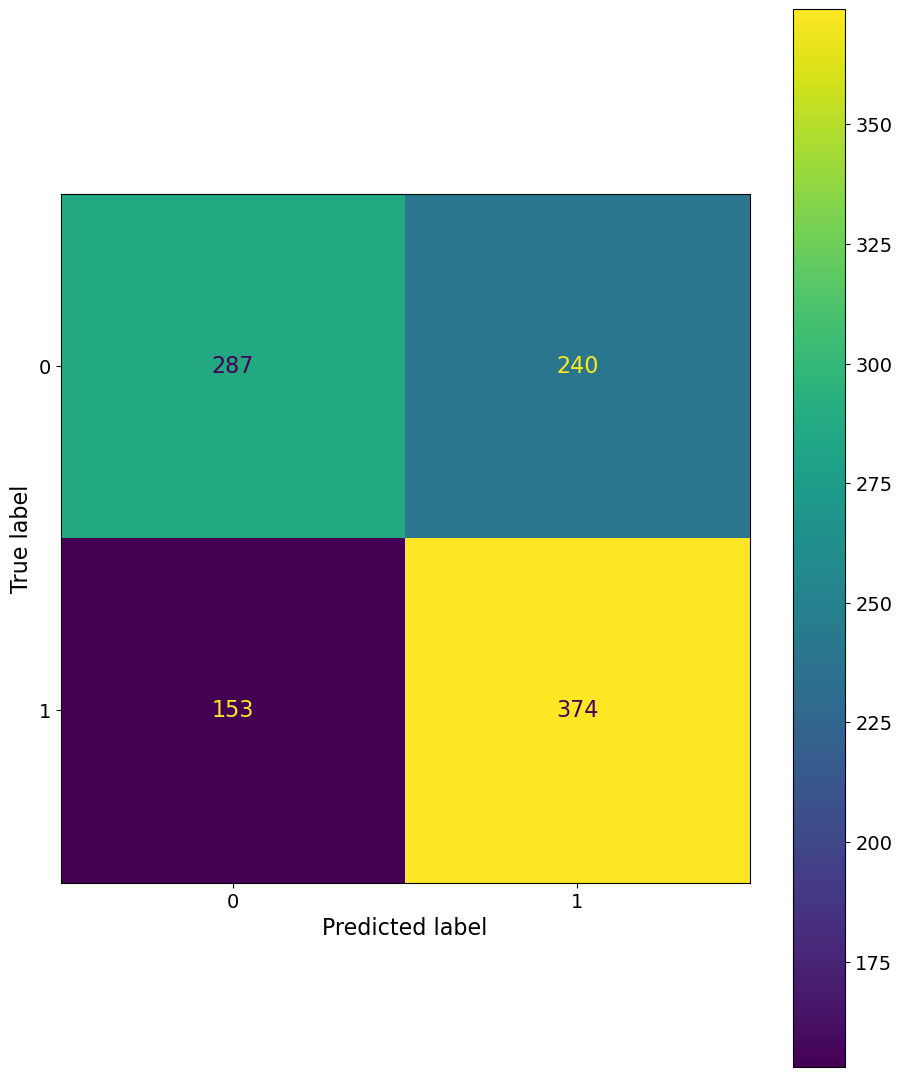

fridge
mtf
XGBoost
0

f1_score: 0.595836965919409
accuracy: 0.5977229601518027
              precision    recall  f1-score   support

       False       0.61      0.53      0.57       527
        True       0.59      0.67      0.62       527

    accuracy                           0.60      1054
   macro avg       0.60      0.60      0.60      1054
weighted avg       0.60      0.60      0.60      1054



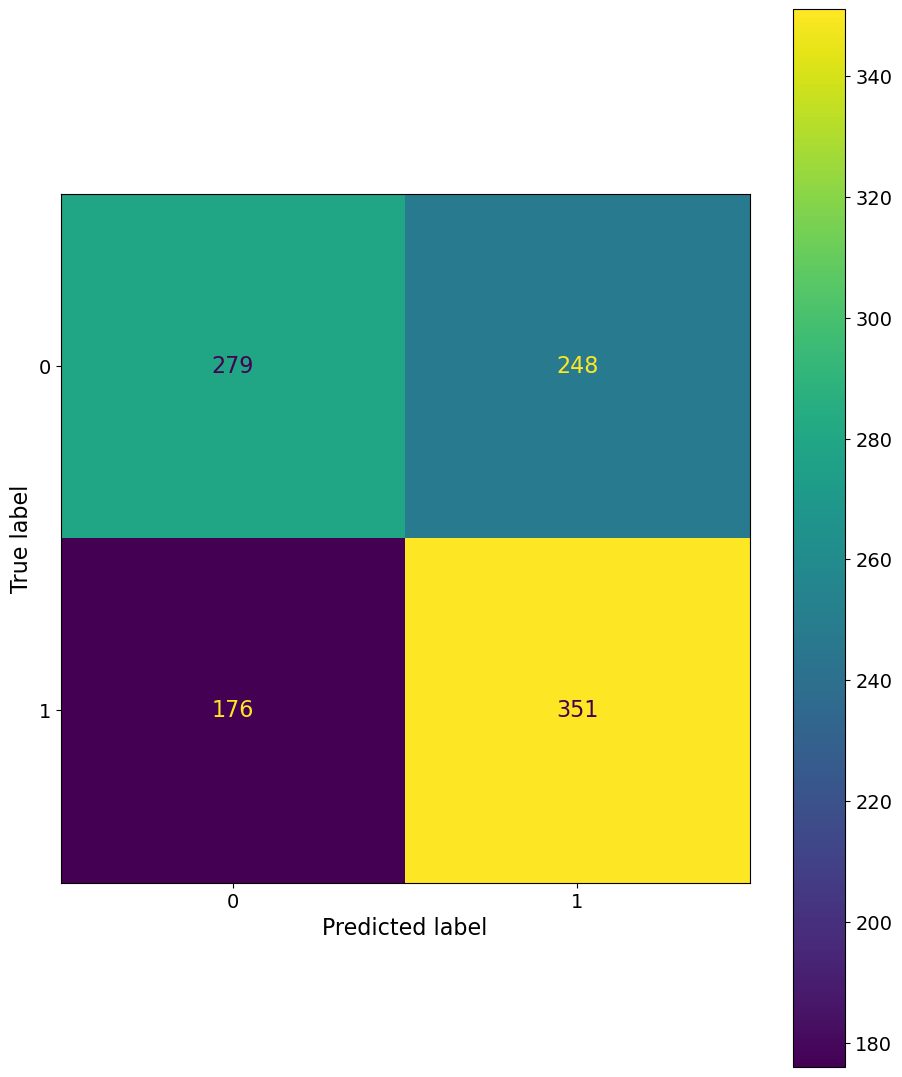

fridge
mtf
SVM
0

f1_score: 0.6356074966046656
accuracy: 0.642314990512334
              precision    recall  f1-score   support

       False       0.70      0.51      0.59       527
        True       0.61      0.78      0.69       527

    accuracy                           0.64      1054
   macro avg       0.65      0.64      0.64      1054
weighted avg       0.65      0.64      0.64      1054



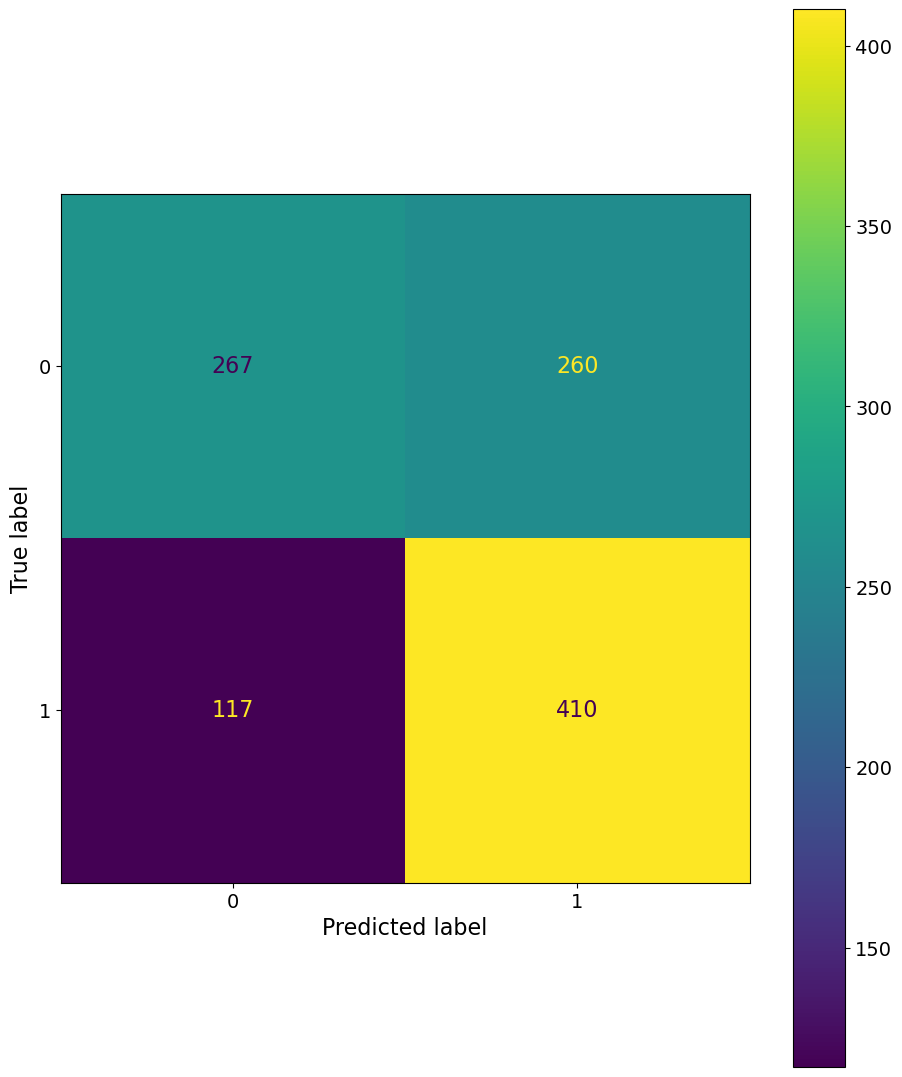

fridge
rp
MLP
0

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
f1_score: 0.5122707450313835
accuracy: 0.5123339658444023
              precision    recall  f1-score   support

       False       0.51      0.50      0.51       527
        True       0.51      0.52      0.52       527

    accuracy                           0.51      1054
   macro avg       0.51      0.51      0.51      1054
weighted avg       0.51      0.51      0.51      1054



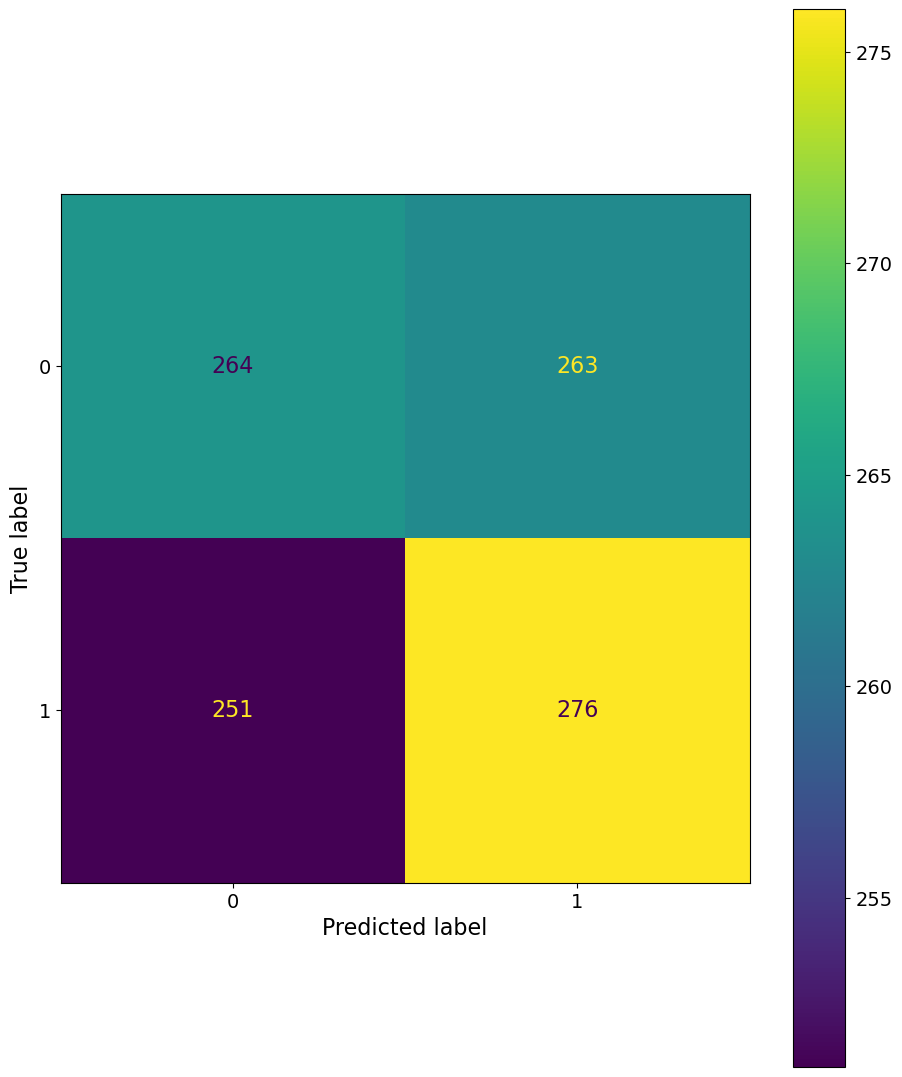

fridge
rp
MLP
1

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
f1_score: 0.41555523128556837
accuracy: 0.5132827324478179
              precision    recall  f1-score   support

       False       0.57      0.10      0.18       527
        True       0.51      0.92      0.65       527

    accuracy                           0.51      1054
   macro avg       0.54      0.51      0.42      1054
weighted avg       0.54      0.51      0.42      1054



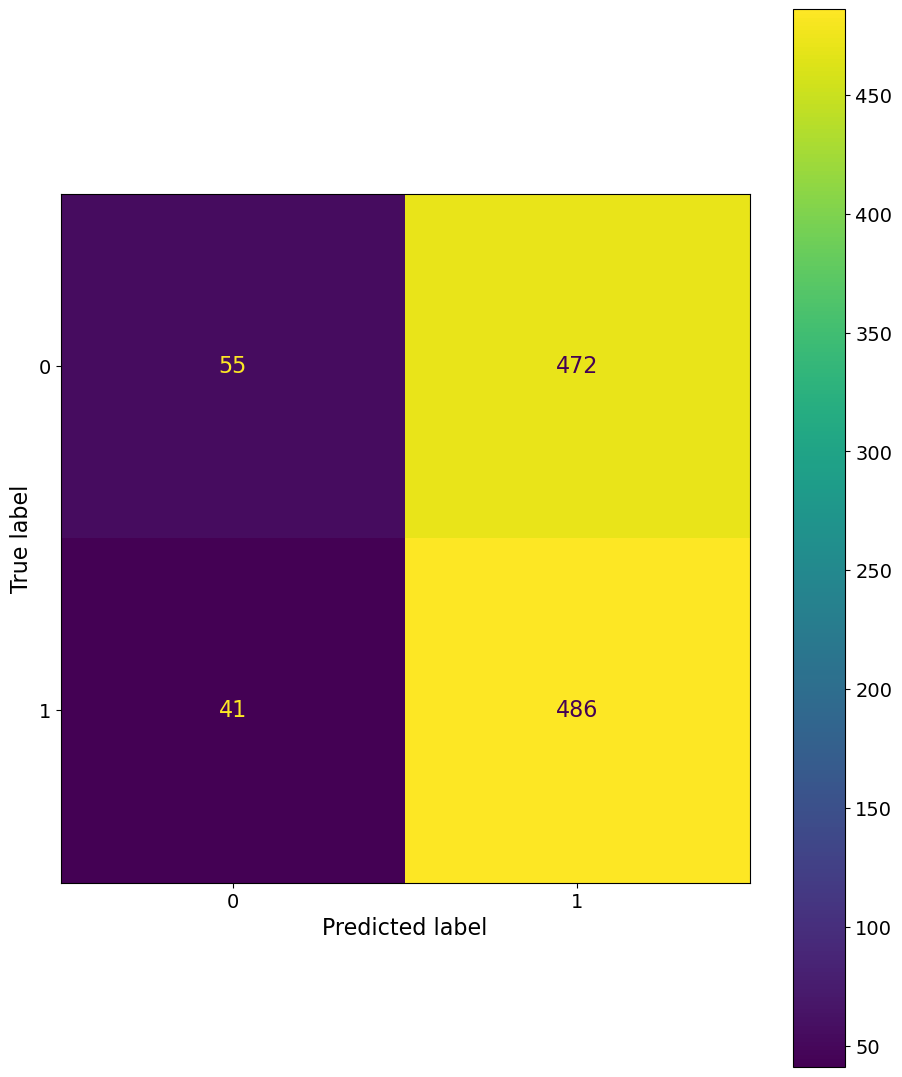

fridge
rp
MLP
2

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
f1_score: 0.3638124649073554
accuracy: 0.5104364326375711
              precision    recall  f1-score   support

       False       0.51      0.99      0.67       527
        True       0.76      0.03      0.06       527

    accuracy                           0.51      1054
   macro avg       0.63      0.51      0.36      1054
weighted avg       0.63      0.51      0.36      1054



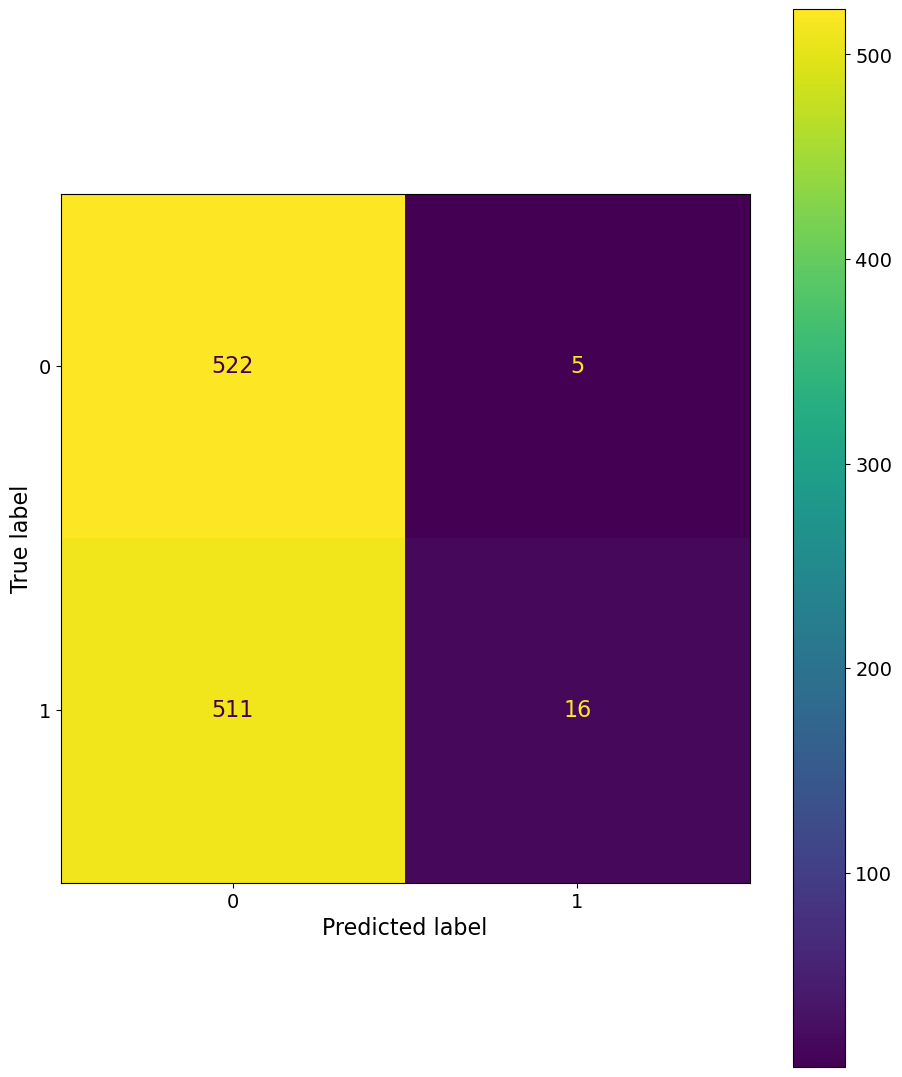

fridge
rp
MLP
3

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
f1_score: 0.5264204611798994
accuracy: 0.5436432637571158
              precision    recall  f1-score   support

       False       0.57      0.35      0.44       527
        True       0.53      0.73      0.62       527

    accuracy                           0.54      1054
   macro avg       0.55      0.54      0.53      1054
weighted avg       0.55      0.54      0.53      1054



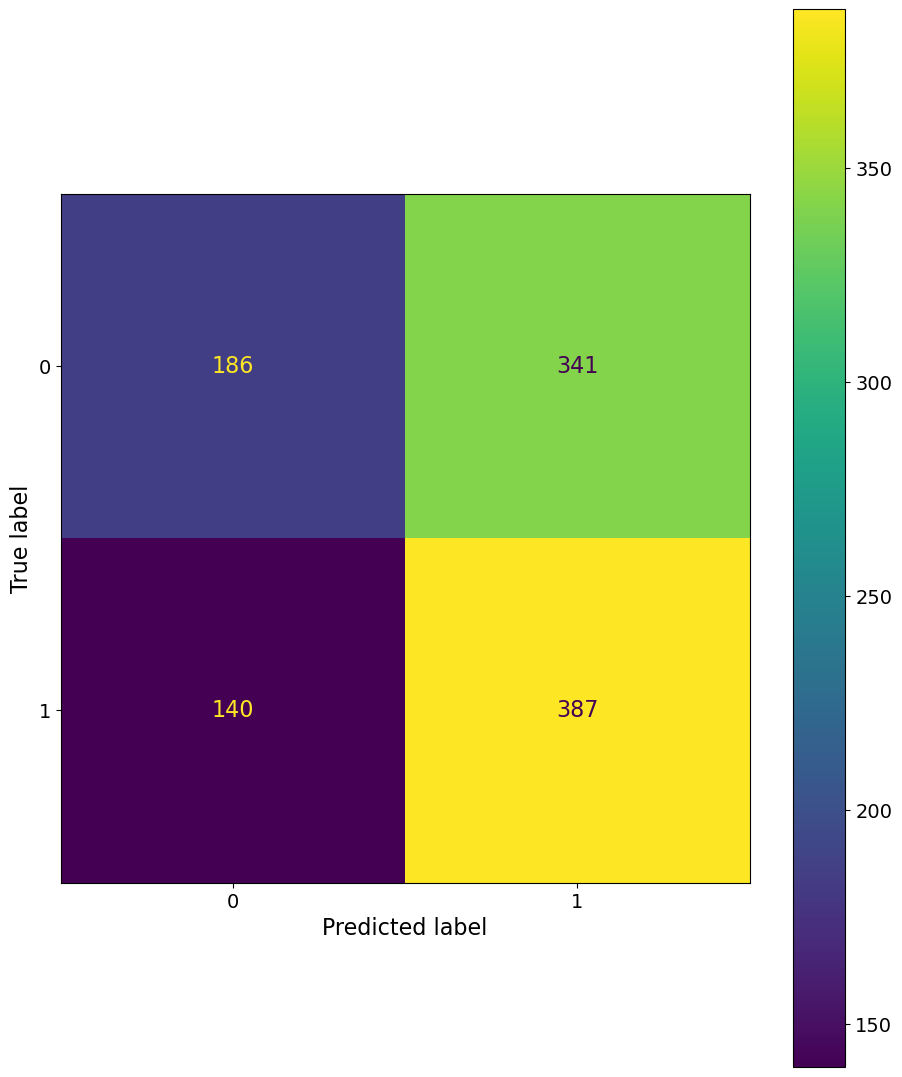

fridge
rp
MLP
4

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
f1_score: 0.35688579134689596
accuracy: 0.5056925996204934
              precision    recall  f1-score   support

       False       0.50      0.99      0.67       527
        True       0.65      0.02      0.05       527

    accuracy                           0.51      1054
   macro avg       0.58      0.51      0.36      1054
weighted avg       0.58      0.51      0.36      1054



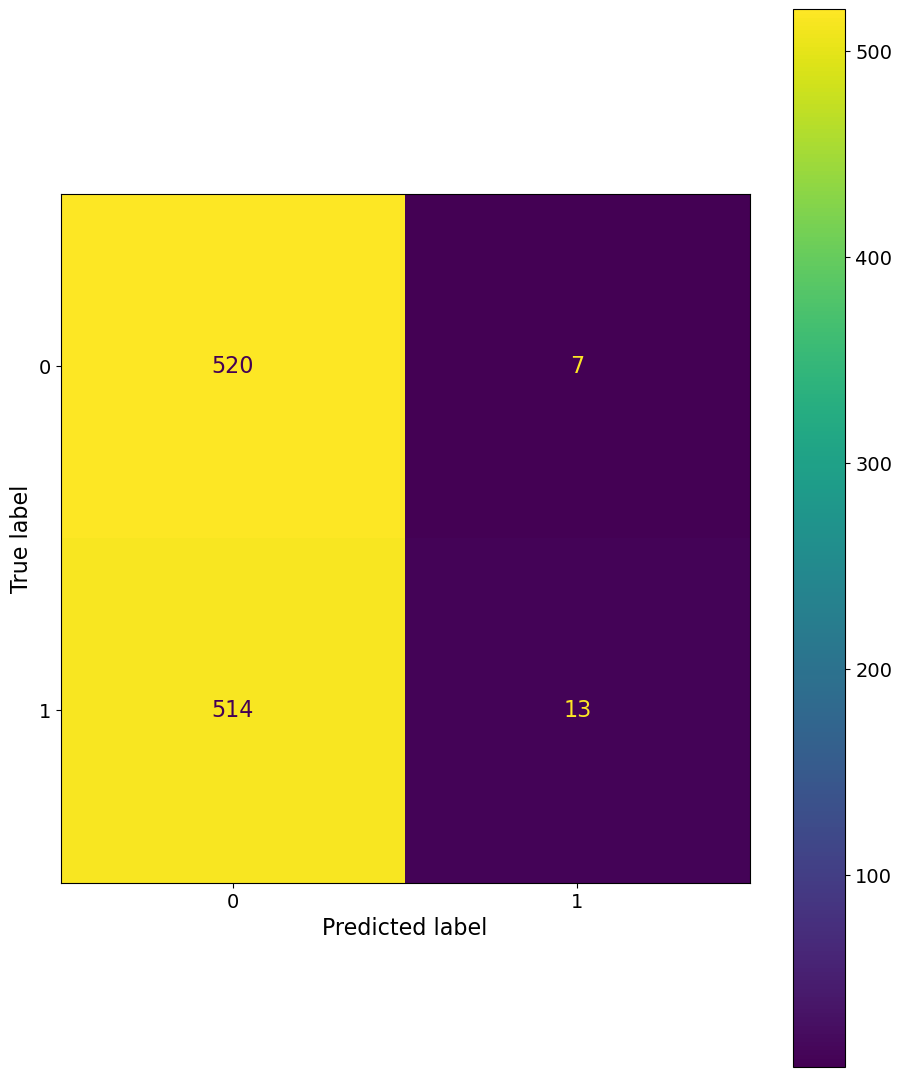

fridge
rp
XGBoost
0

f1_score: 0.7040680998892266
accuracy: 0.7049335863377609
              precision    recall  f1-score   support

       False       0.73      0.65      0.69       527
        True       0.68      0.76      0.72       527

    accuracy                           0.70      1054
   macro avg       0.71      0.70      0.70      1054
weighted avg       0.71      0.70      0.70      1054



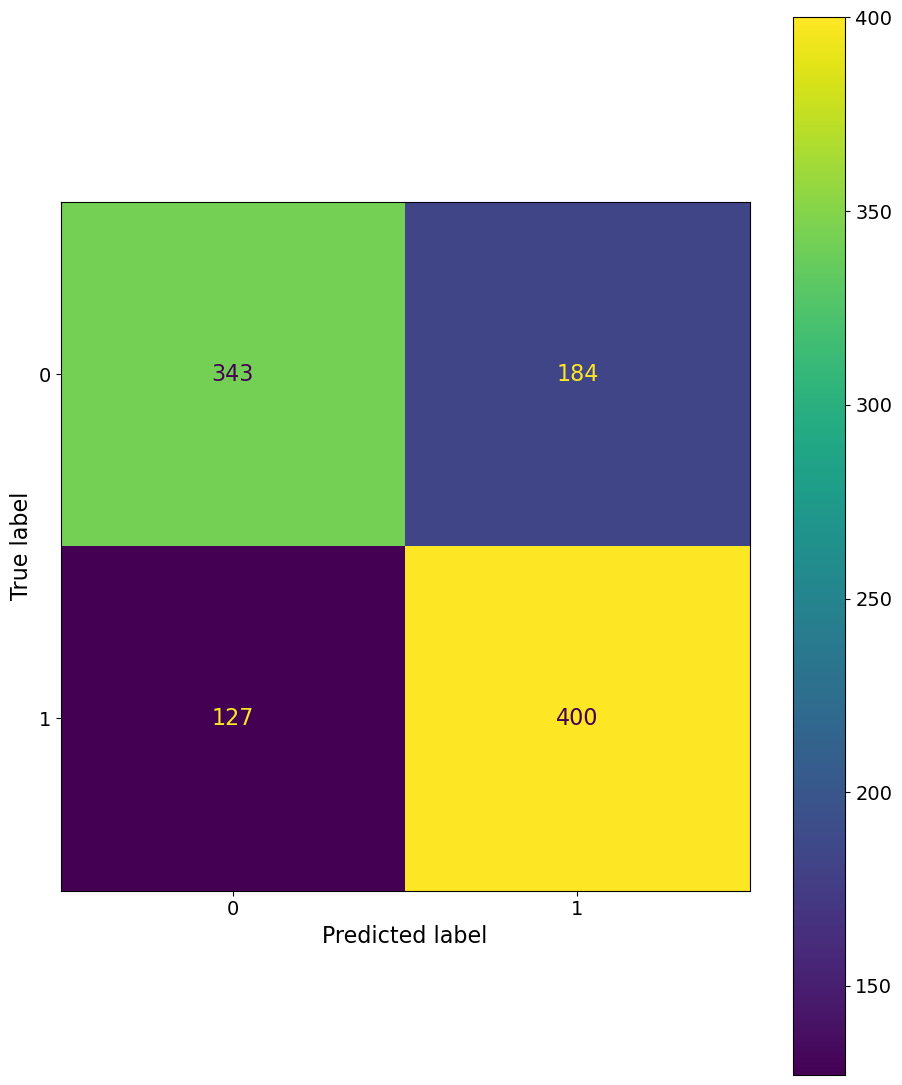

fridge
rp
SVM
0

f1_score: 0.37650946475195823
accuracy: 0.5047438330170778
              precision    recall  f1-score   support

       False       0.55      0.05      0.09       527
        True       0.50      0.96      0.66       527

    accuracy                           0.50      1054
   macro avg       0.53      0.50      0.38      1054
weighted avg       0.53      0.50      0.38      1054



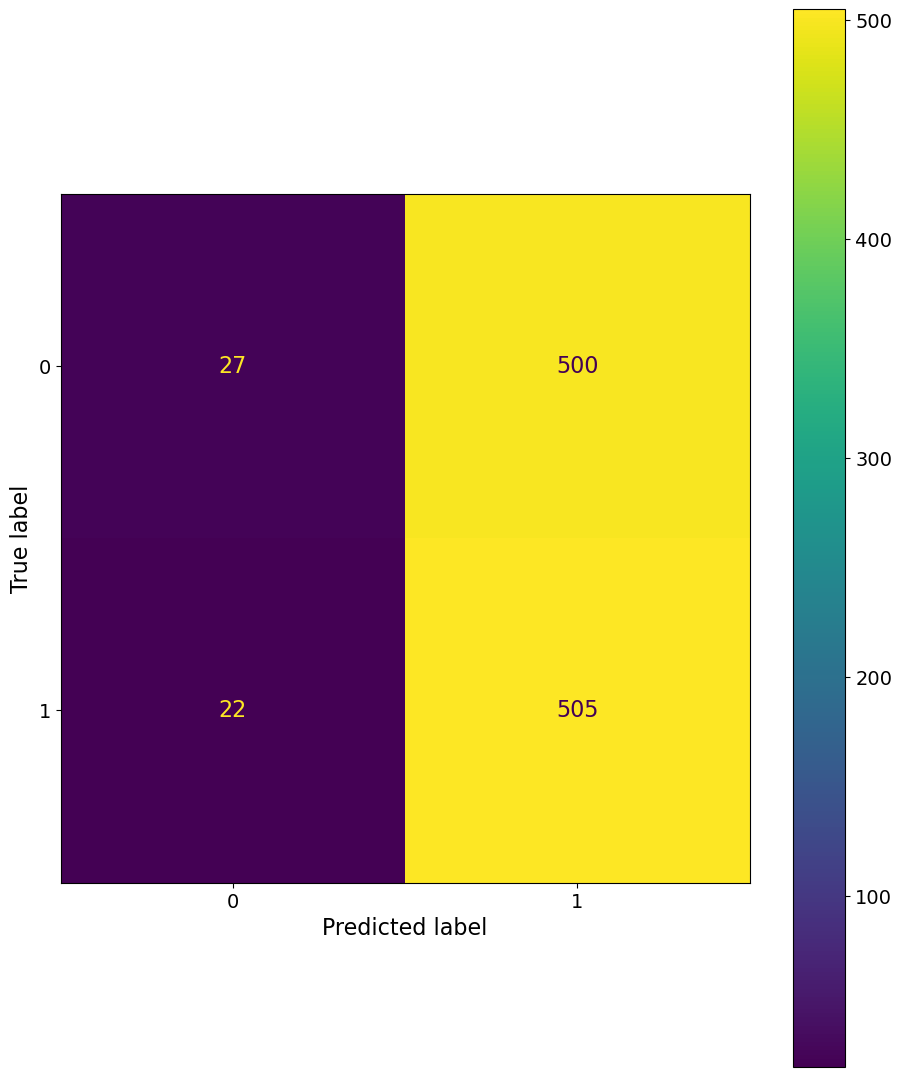

fridge
tbg
MLP
0

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
f1_score: 0.45698093766099945
accuracy: 0.5379506641366224
              precision    recall  f1-score   support

       False       0.52      0.92      0.67       527
        True       0.67      0.15      0.25       527

    accuracy                           0.54      1054
   macro avg       0.59      0.54      0.46      1054
weighted avg       0.59      0.54      0.46      1054



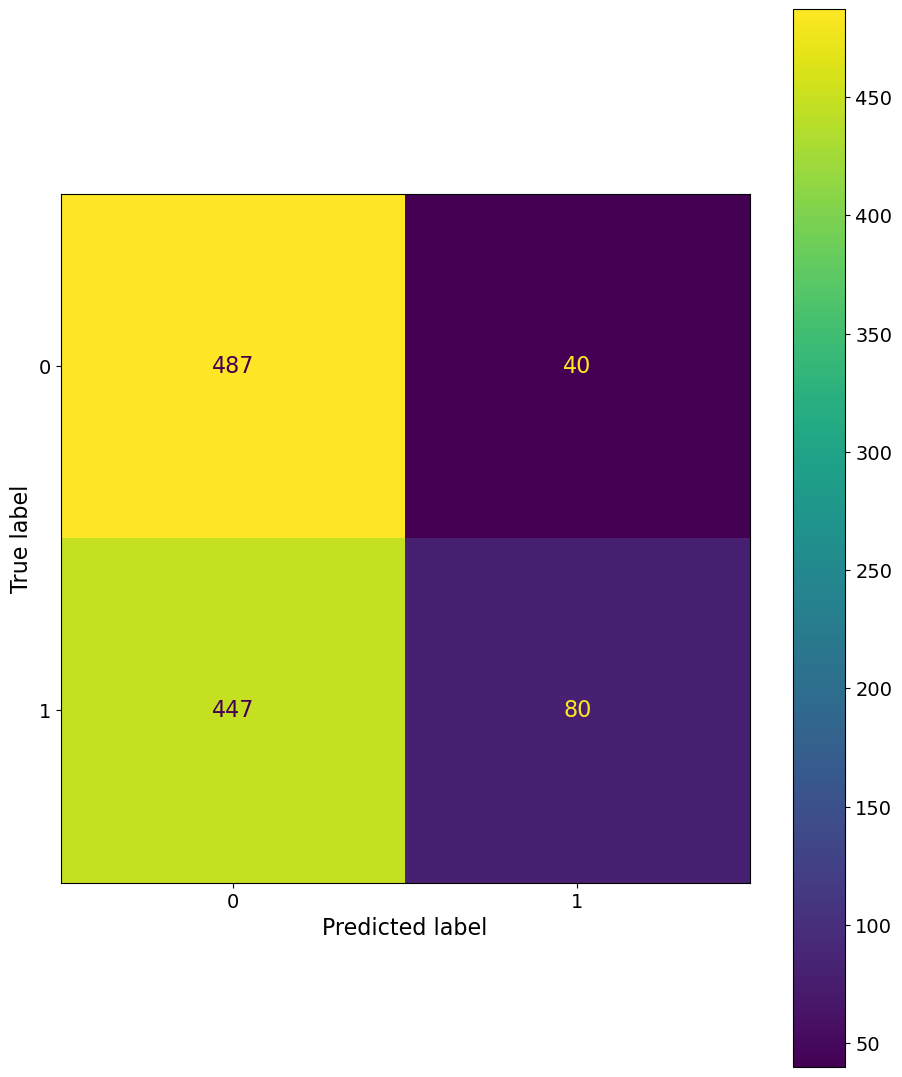

fridge
tbg
MLP
1

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
f1_score: 0.4428388599018101
accuracy: 0.5313092979127134
              precision    recall  f1-score   support

       False       0.52      0.93      0.66       527
        True       0.65      0.13      0.22       527

    accuracy                           0.53      1054
   macro avg       0.59      0.53      0.44      1054
weighted avg       0.59      0.53      0.44      1054



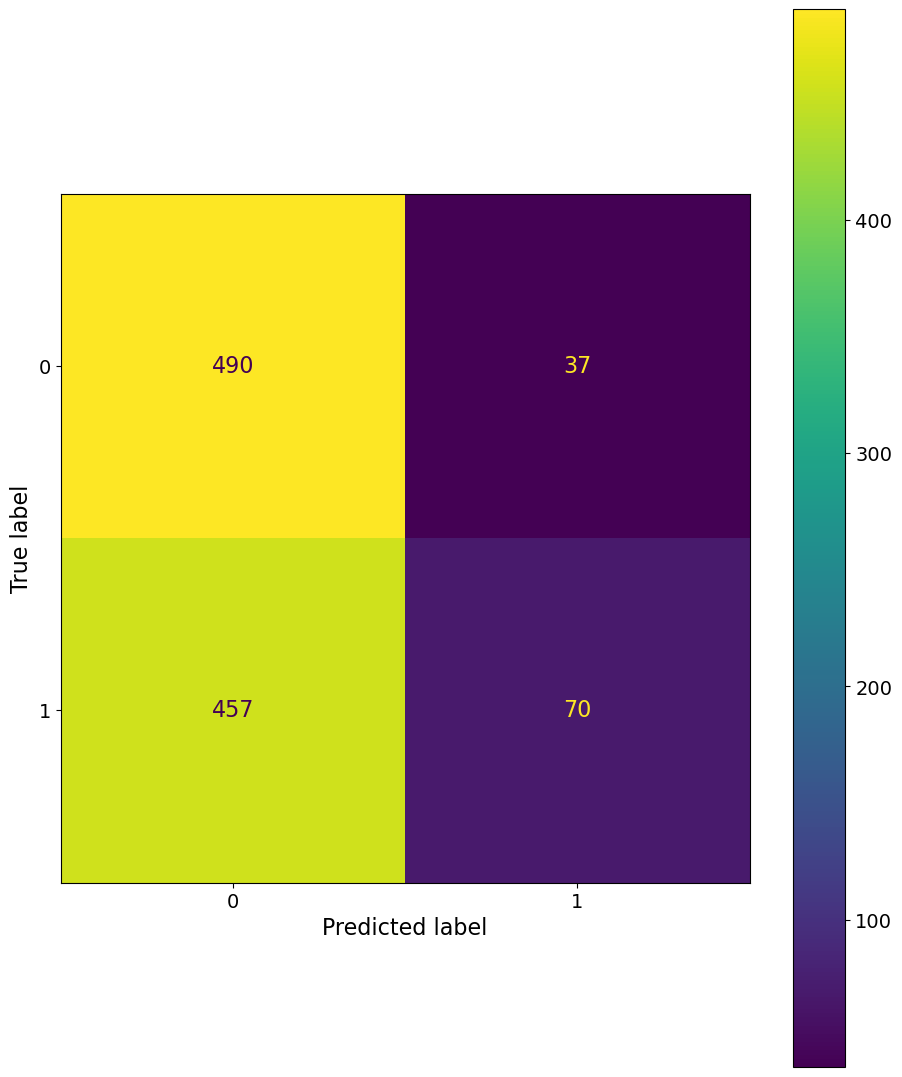

fridge
tbg
MLP
2

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
f1_score: 0.4631128812493449
accuracy: 0.538899430740038
              precision    recall  f1-score   support

       False       0.52      0.91      0.66       527
        True       0.66      0.16      0.26       527

    accuracy                           0.54      1054
   macro avg       0.59      0.54      0.46      1054
weighted avg       0.59      0.54      0.46      1054



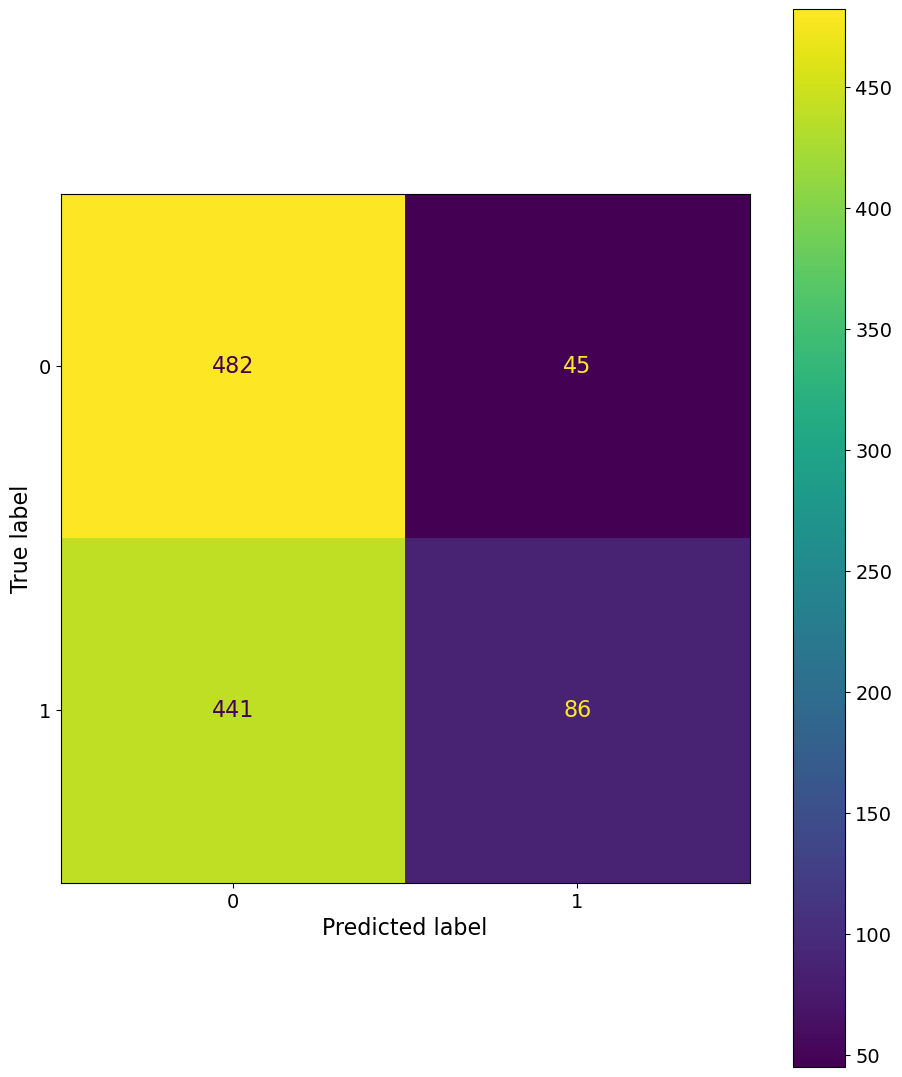

fridge
tbg
MLP
3

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
f1_score: 0.4668689934243804
accuracy: 0.5417457305502846
              precision    recall  f1-score   support

       False       0.52      0.92      0.67       527
        True       0.67      0.17      0.27       527

    accuracy                           0.54      1054
   macro avg       0.60      0.54      0.47      1054
weighted avg       0.60      0.54      0.47      1054



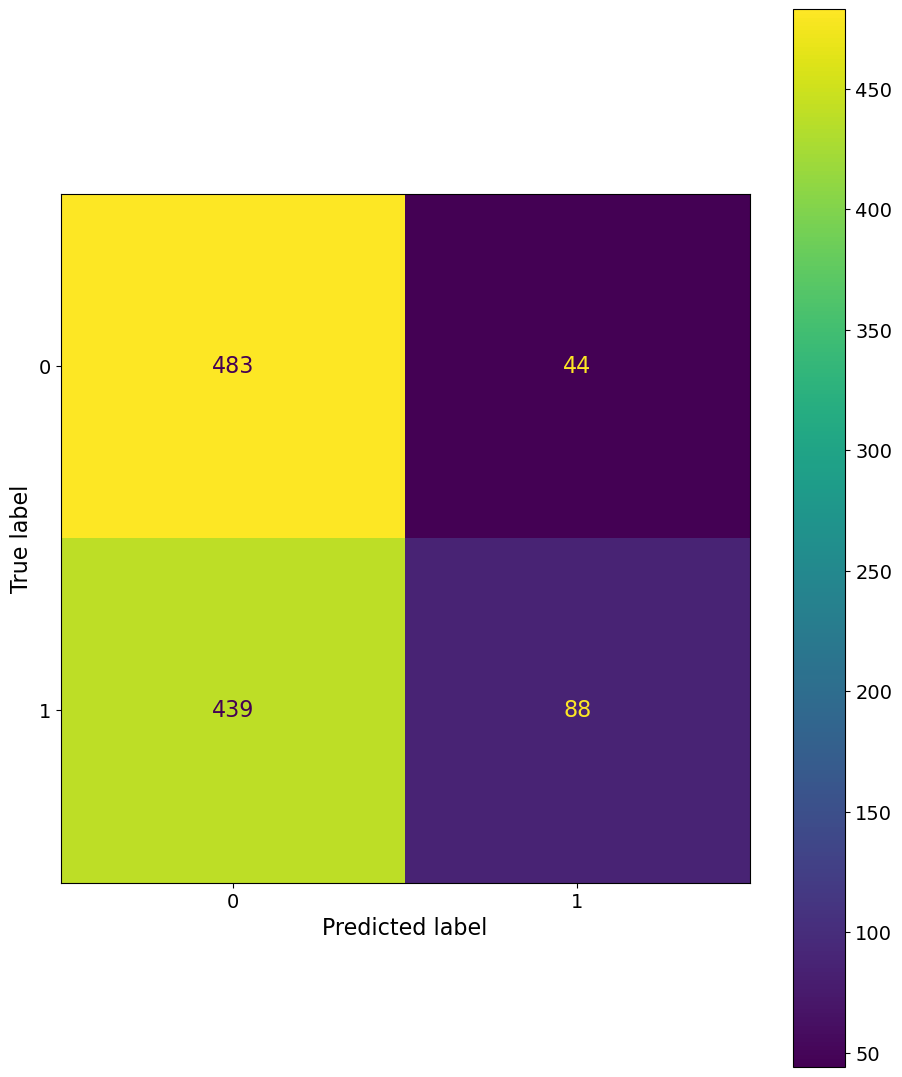

fridge
tbg
MLP
4

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
f1_score: 0.42370375684686185
accuracy: 0.5227703984819735
              precision    recall  f1-score   support

       False       0.51      0.94      0.66       527
        True       0.63      0.11      0.18       527

    accuracy                           0.52      1054
   macro avg       0.57      0.52      0.42      1054
weighted avg       0.57      0.52      0.42      1054



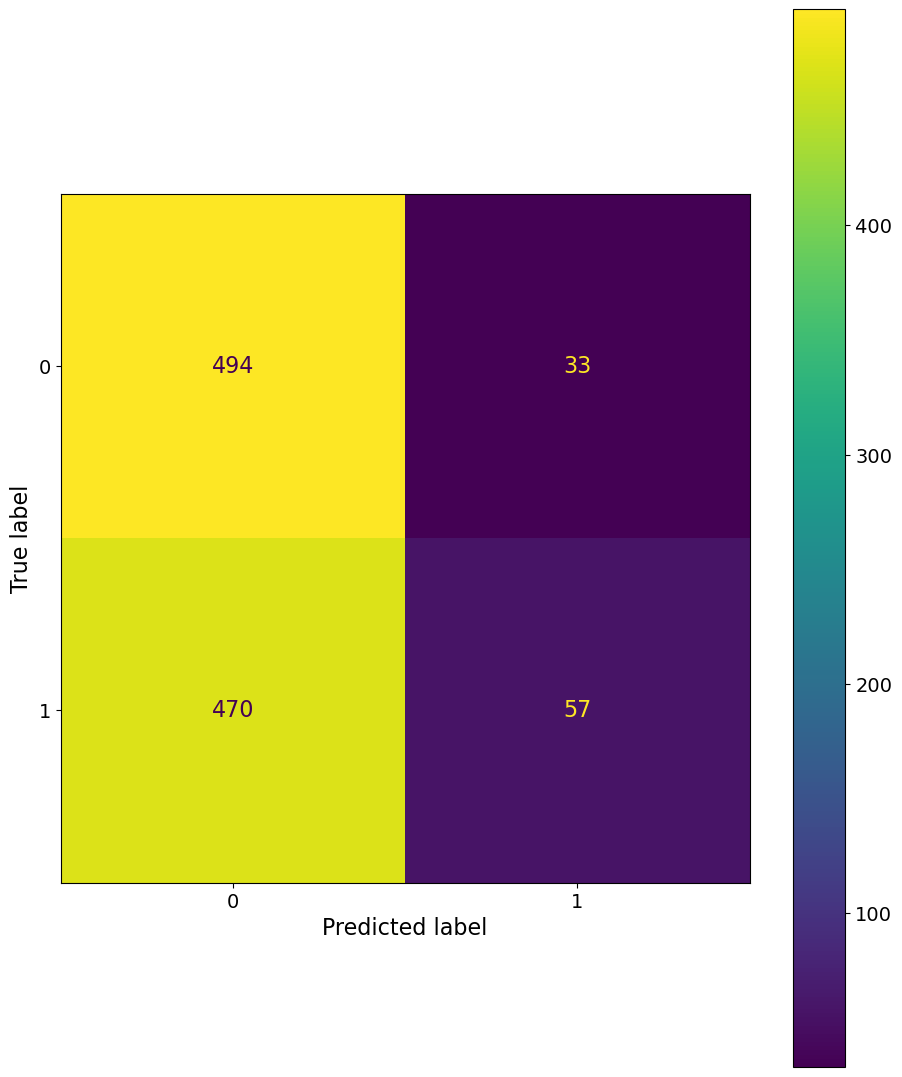

fridge
tbg
XGBoost
0

f1_score: 0.6894587516368398
accuracy: 0.6925996204933587
              precision    recall  f1-score   support

       False       0.66      0.79      0.72       527
        True       0.74      0.59      0.66       527

    accuracy                           0.69      1054
   macro avg       0.70      0.69      0.69      1054
weighted avg       0.70      0.69      0.69      1054



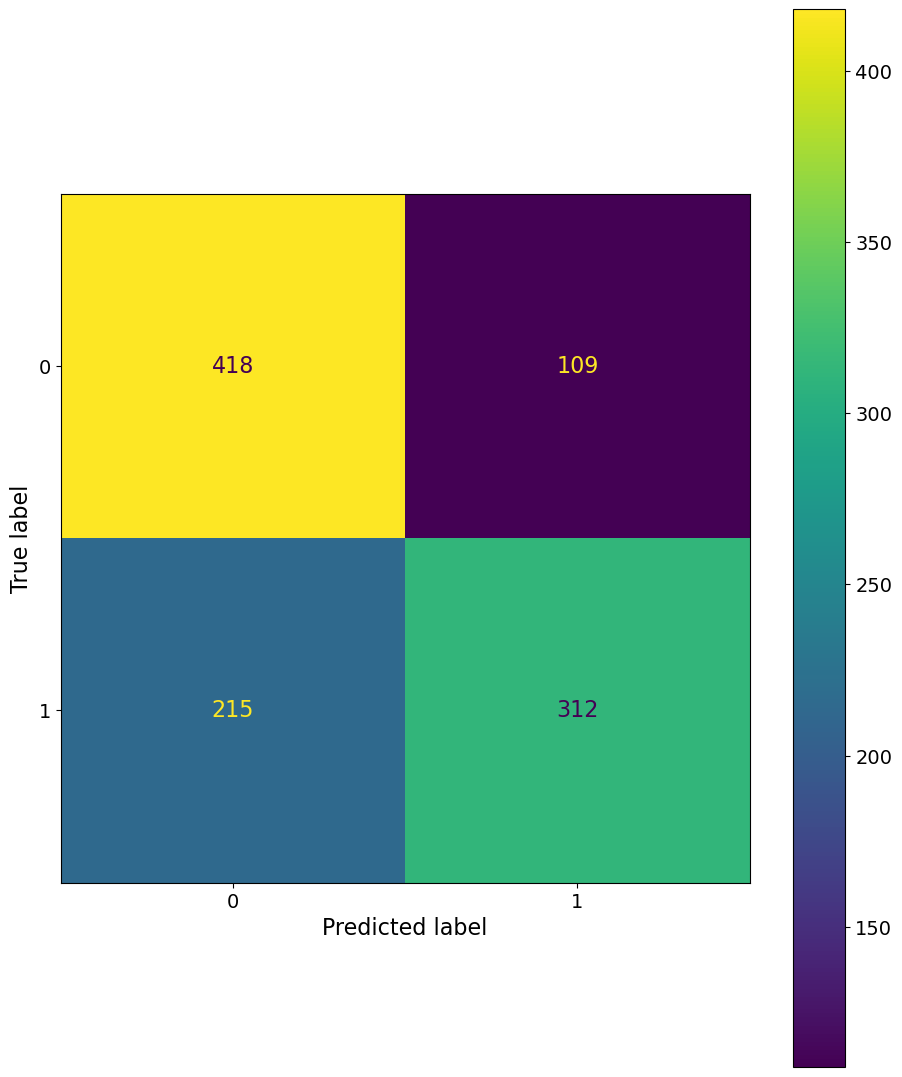

fridge
tbg
SVM
0

f1_score: 0.4076071954743938
accuracy: 0.5189753320683111
              precision    recall  f1-score   support

       False       0.51      0.95      0.66       527
        True       0.64      0.09      0.15       527

    accuracy                           0.52      1054
   macro avg       0.58      0.52      0.41      1054
weighted avg       0.58      0.52      0.41      1054



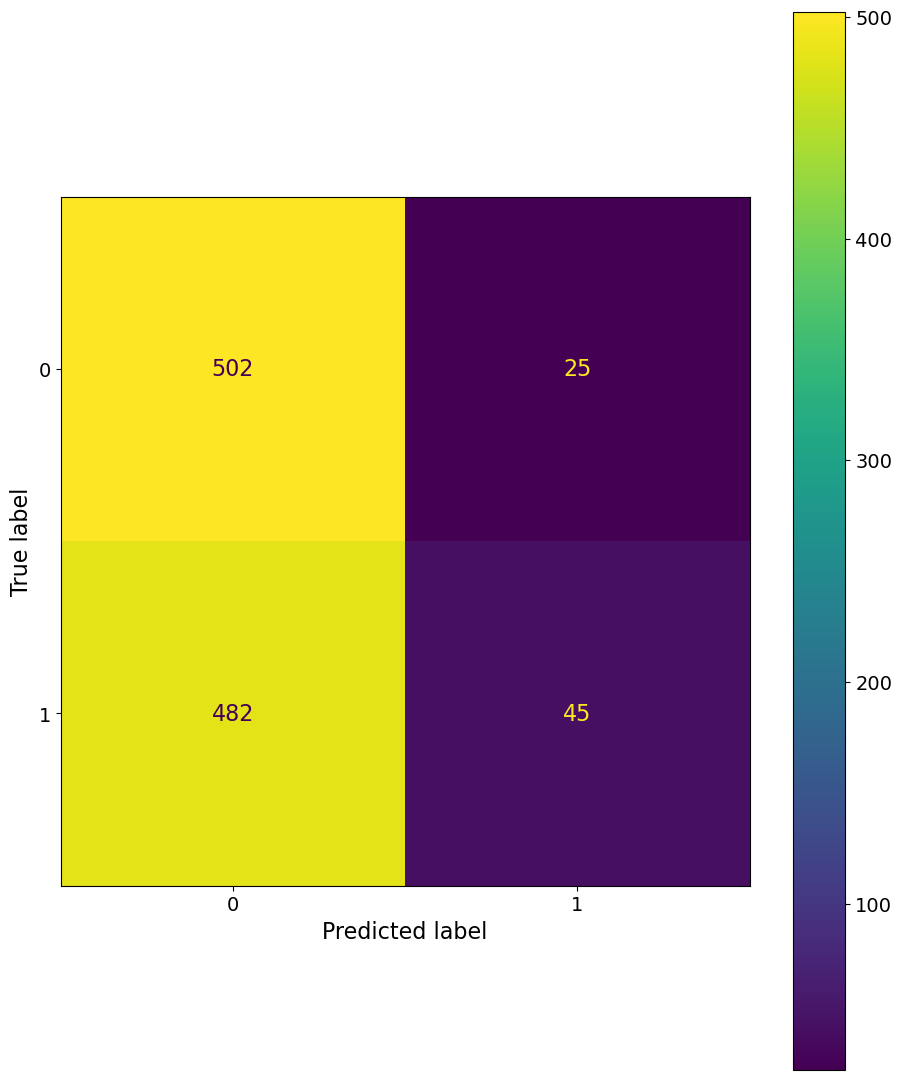

In [19]:
folder_X = 'FE_output'
folder_y = 'pickle_data'

mdl_index = 0
for disp in DISPOSITIVOS:
    for img in IMAGENS:
        for tipo_modelo in MODELS:
            runs_aux = RUNS if tipo_modelo == 'MLP' else ['0']
            for exec in runs_aux:
                if tipo_modelo == 'XGBoost':
                    checkpoint_filepath = f'ckpt/{disp}/{img}/{tipo_modelo}/model.json'
                    mdl = XGBClassifier()
                    mdl.load_model(checkpoint_filepath)
                elif tipo_modelo == 'SVM':
                    checkpoint_filepath = f'ckpt/{disp}/{img}/{tipo_modelo}/model.joblib'
                    mdl = joblib.load(checkpoint_filepath)
                else:
                    checkpoint_filepath = f'ckpt/{disp}/{img}/{tipo_modelo}/{exec}/checkpoint.model.keras'
                    mdl = tf.keras.models.load_model(checkpoint_filepath)

                X = pickle.load(open(f"{folder_X}/XFE_{img}_test({disp}).pickle","rb"))
                y = pickle.load(open(f"{folder_y}/y_test({disp}).pickle","rb"))


                y_pred = test_data_eval(model = mdl,
                                        X_test = X,
                                        y_test = y,
                                        dispositivo = disp,
                                        imagem = img,
                                        tipo_modelo = tipo_modelo,
                                        execucao = exec)


### Resultados

In [20]:
resultados

f1_score  \
dispositivo imagem modelo                                                       
dish washer gasf   MLP      [0.8699324324324325, 0.8234169957956428, 0.801...   
                   XGBoost                               [0.7629958960328318]   
                   SVM                                   [0.7727430555555556]   
            gadf   MLP      [0.7567763691467111, 0.7225939269171384, 0.770...   
                   XGBoost                               [0.6373626373626373]   
...                                                                       ...   
fridge      rp     XGBoost                               [0.7040680998892266]   
                   SVM                                  [0.37650946475195823]   
            tbg    MLP      [0.45698093766099945, 0.4428388599018101, 0.46...   
                   XGBoost                               [0.6894587516368398]   
                   SVM                                   [0.4076071954743938]   

                                                                     accuracy  
dispositivo imagem modelo                                                      
dish washer gasf   MLP      [0.8701298701298701, 0.8246753246753247, 0.805...  
                   XGBoost                               [0.7662337662337663]  
                   SVM                                   [0.7792207792207793]  
            gadf   MLP      [0.7597402597402597, 0.7272727272727273, 0.772...  
                   XGBoost                               [0.6493506493506493]  
...                                                                       ...  
fridge      rp     XGBoost                               [0.7049335863377609]  
                   SVM                                   [0.5047438330170778]  
            tbg    MLP      [0.5379506641366224, 0.5313092979127134, 0.538...  
                   XGBoost                               [0.6925996204933587]  
                   SVM                                   [0.5189753320683111]  

[75 rows x 2 columns]

In [21]:
# Cria um novo DataFrame vazio, mas aproveitando o mesmo MultiIndex (dispositivo, imagem, modelo)
df_final = pd.DataFrame(index=resultados.index)

# Extrai a média e o desvio padrão (dp) para o f1_score
df_final['f1_score_mean'] = resultados['f1_score'].apply(np.mean)
df_final['f1_score_dp'] = resultados['f1_score'].apply(np.std)

# Extrai a média e o desvio padrão (dp) para a acurácia
df_final['acc_mean'] = resultados['accuracy'].apply(np.mean)
df_final['acc_dp'] = resultados['accuracy'].apply(np.std)

print(df_final)

                            f1_score_mean  f1_score_dp  acc_mean    acc_dp
dispositivo imagem modelo                                                 
dish washer gasf   MLP           0.817809     0.037579  0.820779  0.034507
                   XGBoost       0.762996     0.000000  0.766234  0.000000
                   SVM           0.772743     0.000000  0.779221  0.000000
            gadf   MLP           0.714415     0.086246  0.729870  0.062365
                   XGBoost       0.637363     0.000000  0.649351  0.000000
...                                   ...          ...       ...       ...
fridge      rp     XGBoost       0.704068     0.000000  0.704934  0.000000
                   SVM           0.376509     0.000000  0.504744  0.000000
            tbg    MLP           0.450701     0.015783  0.534535  0.006805
                   XGBoost       0.689459     0.000000  0.692600  0.000000
                   SVM           0.407607     0.000000  0.518975  0.000000

[75 rows x 4 columns]


In [22]:
df_final.to_csv('resultados_rgb.csv')

In [23]:
from matplotlib import rcParams
from matplotlib.colors import LinearSegmentedColormap

from io import BytesIO
from matplotlib.backends.backend_agg import FigureCanvasAgg

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

def get_figsize(
    columnwidth=4, wf=1.0, hf_rel=(5.0 ** 0.5 - 1.0) / 2.0, hf_abs=None, unit="inch"
):
    """A função aceita uma série de argumentos para a precisa customização da
    largura e altura de uma figura que será produzida com Matplotlib.

    Maiores detalhes em:
    www.fschuch/blog/2020/10/14/graficos-com-qualidade-de-publicacao-em-python-com-matplotlib

    © 2020 Felipe N. Schuch, sob os termos da CC BY SA 4.0.
    (www.creativecommons.org/licenses/by-sa/4.0)

    Parâmetros
    ----------
    columnwidth : float
        Largura da página ou da coluna de texto (o padrão é 4)
        Obtenha isso em LaTeX usando \the\columnwidth
    wf : float
        A fração da largura que será utilizada pela figura (o padrão é 1.0)
    hf_rel : float
        Altura da figura, valor relativo em relação à largura (o padrão é a proporção áurea)
    hf_abs : float
        Altura da figura em termos absolutos, caso desejado (o padrão é None)
        Obtenha isso em LaTeX usando \the\textheight
    unit : float
        Unidade de comprimento utilizada para `columnwidth` e `hf_abs`,
        as opções suportadas são "inch" (polegada), "mm", "cm" e "pt" (Pontos tipográfico)
        (o padrão é "inch")
    Retorno
    -------
    set
        Retorna um set contendo a largura e a altura especificada para a figura.
    Apura
    -------
    ValueError
        Caso a unidade não seja suportada pela função.
    Exemplos
    -------

    >>> import matplotlib.pyplot as plt

    >>> get_figsize()
    (4.0, 2.4721359549995796)
    >>> get_figsize(columnwidth=16, unit='cm', hf_abs=9)
    (6.299212598425196, 3.543307086614173)
    >>> get_figsize(columnwidth=4, unit='inch', hf_rel = 1.0)
    (4.0, 4.0)

    >>> plt.rcParams.update({
    ... 'figure.figsize' : get_figsize(columnwidth=160, wf=0.75, unit='mm', hf_rel=1)
    ... })
    """

    # Dessa maneira, unit não será sensível a letras maiúsculas e minúsculas
    unit = unit.lower()

    # Converte unidades para polegadas, conforme esperado por Matplotlib
    conversion = dict(inch=1.0, mm=25.4, cm=2.54, pt=72.0,)

    if unit in conversion.keys():
        fig_width = columnwidth / conversion[unit]
        if hf_abs is not None:
            fig_height = hf_abs / conversion[unit]
    else:
        raise ValueError(f"unit deve ser: {conversion.keys()}")

    # A figura será apenas uma fração da largura útil da página
    fig_width *= wf

    # Caso hf_abs não seja definido, a altura será uma fração da largura
    if hf_abs is None:
        fig_height = fig_width * hf_rel

    # Retorna a largura e altura especificada para a figura
    return (fig_width, fig_height)

In [24]:
plt.rcParams.update({
    'figure.figsize' : get_figsize(columnwidth=800, unit='pt',hf_rel = 2*(5.0 ** 0.5 - 1.0) / 2),
    #
    "axes.labelsize": 16,
    "font.size": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

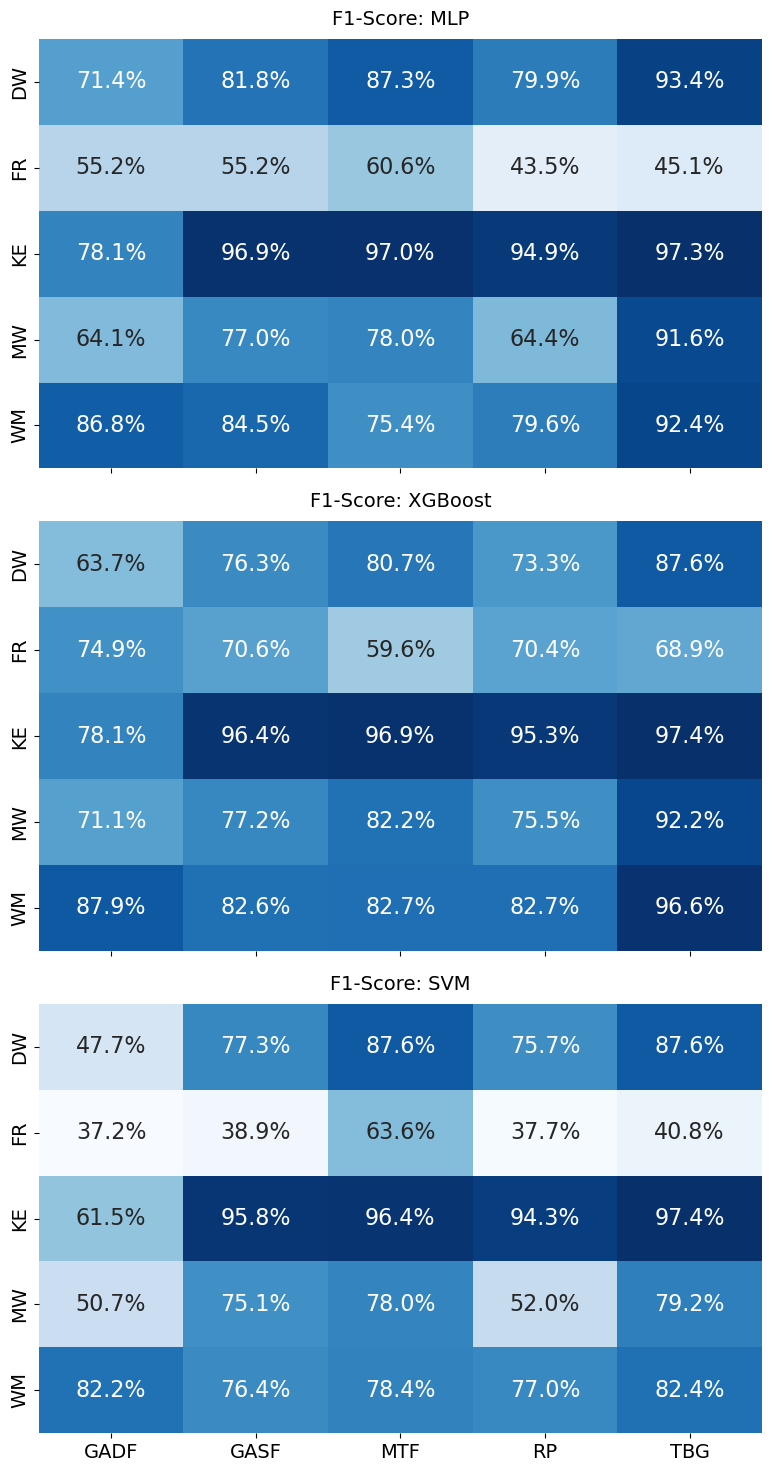

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 'Blues' para V1 (RGB) e 'Greys' para V2 (Escala de Cinza)
paleta_cores = 'Blues'

# Dicionário para renomear os dispositivos para as siglas
mapa_dispositivos = {
    'dish washer': 'DW',
    'fridge': 'FR',
    'kettle': 'KE',
    'microwave': 'MW',
    'washing machine': 'WM'
}

# Ordem exata que você solicitou para o eixo Y
ordem_y = ['DW', 'FR', 'KE', 'MW', 'WM']

# Limites globais (garanta que o df_final aqui é o da versão correspondente)
vmin = df_final['f1_score_mean'].min()
vmax = df_final['f1_score_mean'].max()


fig, axes = plt.subplots(3, 1, figsize=(8, 15), sharex=True)
modelos_para_plot = ['MLP', 'XGBoost', 'SVM']

for i, model in enumerate(modelos_para_plot):
    # Extrai e formata os dados
    df_heatmap = df_final.xs(model, level='modelo')['f1_score_mean'].unstack(level='imagem')

    # 3. Renomeia o eixo Y (dispositivos) usando o dicionário
    df_heatmap = df_heatmap.rename(index=mapa_dispositivos)

    # 3. Garante a ordem exata das siglas no eixo Y
    df_heatmap = df_heatmap.reindex(ordem_y)

    # 3. Coloca o nome das imagens no eixo X tudo em maiúsculo
    df_heatmap.columns = [col.upper() for col in df_heatmap.columns]

    # Plota o heatmap
    sns.heatmap(
        df_heatmap,
        ax=axes[i],
        cmap=paleta_cores,
        vmin=vmin,
        vmax=vmax,
        annot=True,
        fmt=".1%",       # 4. Formata automaticamente para porcentagem com 1 casa decimal (ex: 95.5%)
        cbar=False
    )

    # Ajusta o título
    axes[i].set_title(f'F1-Score: {model}', fontsize=14, pad=10)

    # 2. Remove "Imagens" e "Dispositivos" dos eixos
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.rcParams.update({
    'figure.figsize' : get_figsize(columnwidth=800, unit='pt', hf_rel = (5.0 ** 0.5 - 1.0) / 2),

    "axes.labelsize": 16,
    "font.size": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

plt.tight_layout()
plt.savefig('heatmap-rgb.pdf')
plt.show()

In [6]:
#resultados.to_pickle('output/df_resultados.pkl')
resultados = pd.read_pickle('output/df_resultados.pkl')